## 0. Executive Summary

Este proyecto desarrolla un **pipeline end-to-end de Credit Scoring** siguiendo las prácticas profesionales utilizadas en departamentos de **Risk Analytics**, **Credit Underwriting** y **Model Risk Management (MRM)** en instituciones financieras.

**Objetivo:** construir un modelo de estimación de la **Probabilidad de Default (PD)** que sea robusto, auditable y operacionalizable — no solo técnicamente correcto, sino documentado con el rigor que exige un entorno bancario regulado.

> **Nota metodológica:** este proyecto utiliza un dataset académico (Kaggle) para demostrar dominio del framework profesional de credit scoring. El objetivo no es replicar un entorno productivo bancario real — lo cual requeriría datos históricos, dimensión temporal y variables comportamentales — sino demostrar competencia metodológica en cada etapa del ciclo de vida del modelo. Las métricas obtenidas sobreestiman el desempeño esperable en una cartera real, donde la señal de default es más débil y el ruido estadístico mayor.

---

### Pipeline del proyecto

| Capítulo | Contenido | Entregable |
|---|---|---|
| 2–3 | Gobierno de datos (3 tiers) + Imputación | 32.386 registros, 195 exclusiones documentadas |
| 4 | EDA orientado a poder discriminante | Perfilado buen/mal pagador, IV por variable |
| 5 | Feature Engineering | 13 predictores seleccionados, `is_high_dti` derivada |
| 6 | Modelado: Logística + XGBoost | Diagnóstico VIF, chequeo de signos, tuning CV |
| 7 | Métricas regulatorias | Gini, KS, AUC sobre conjunto de prueba |
| 8 | Scorecard + Política de Corte | Score 380–863, 3 escenarios de originación |
| 9 | Champion vs. Challenger | Decisión formal con evidencia multidimensional |
| 10 | Model Governance + PSI | Monitoreo, riesgos y condiciones de redevelopment |

---

### Resultados del proyecto

**Discriminación (conjunto de prueba — datos no vistos durante el modelado):**

| Métrica | Regresión Logística | XGBoost | Diferencia |
|---|---|---|---|
| AUC | 0,8610 | 0,9499 | +0,0889 |
| Gini | 72,20% ✦ Excelente | 89,98% ✦ Excelente | +17,78 pp |
| KS | 0,5734 | 0,7520 | +0,1786 |
| Brecha generalización | 0,0088 | 0,0336 | — |

**Scorecard (modelo logístico calibrado):**
- Rango: 380 – 863 puntos | Score base (riesgo promedio): 600
- Separación buenos vs. malos: 78 puntos de mediana

**Política de corte — proyección a 10.000 solicitudes:**

| Escenario | Score corte | Aprobación | Bad rate | Buenos clientes |
|---|---|---|---|---|
| Conservador | ≥ 585 | 75,7% | 9,7% | 6.834 |
| Moderado | ≥ 550 | 89,5% | 15,0% | 7.610 |
| Agresivo | ≥ 505 | 97,4% | 19,9% | 7.800 |

**PSI (estabilidad del modelo):** 0,00120 — diagnóstico **Verde**, sin acción requerida.

---

### Decisión Champion–Challenger

| Contexto | Champion recomendado | Fundamento |
|---|---|---|
| Banco regulado (Basilea, SR 11-7, TRIM) | **Regresión Logística** | Coeficientes auditables, scorecard directa, Gini 72% suficiente para originación robusta |
| Fintech / menor restricción regulatoria | **XGBoost** | +978 buenos clientes/10K solicitudes en escenario conservador, Gini 90% |

---

### Competencias que demuestra el proyecto

Gobierno de datos · Estadística aplicada (η², IV/WoE, VIF) · Modelado regulatorio (scorecard, calibración) · Machine Learning aplicado a crédito · Métricas regulatorias (AUC, Gini, KS, PSI) · Model Risk Management (SR 11-7, TRIM-ECB, Basilea III)


## 1. Data Ingestion & Data Governance (ETL)

### 1.1 Definición de Fuente y Metadata

El dataset utilizado corresponde al **Credit Risk Dataset** (Kaggle), un conjunto de datos ampliamente empleado para ejercicios de **scoring crediticio** y análisis de riesgo.  
Incluye información demográfica, laboral, crediticia y de la solicitud de préstamo.

**Variables principales:**

- Datos personales: `person_age`, `person_income`, `person_home_ownership`  
- Estabilidad laboral: `person_emp_length`  
- Información crediticia: `cb_person_default_on_file`, `cb_person_cred_hist_length`  
- Detalles del préstamo: `loan_intent`, `loan_grade`, `loan_amnt`, `loan_int_rate`, `loan_percent_income`  
- Variable objetivo: **`loan_status`** — 1 = Default, 0 = No Default

Este dataset es adecuado para construir un modelo de **Probabilidad de Default (PD)** siguiendo prácticas profesionales de riesgo.

---

### 1.2 Carga del Dataset

En esta sección realizamos la carga inicial del dataset desde un repositorio público y establecemos configuraciones de visualización para exploración profesional.

---

### 1.3 Perfilado Inicial

Realizamos un diagnóstico preliminar de las características del dataset:

- Tipos de variables  
- Cantidad de registros  
- Estructura  
- Estadísticos descriptivos iniciales  

Este perfilado permite identificar posibles anomalías tempranas y preparar el terreno para las auditorías de calidad (Tier 1, Tier 2, Tier 3).


In [1]:
# ============================
# 1.2 CARGA DEL DATASET
# ============================

import pandas as pd
import numpy as np

# Configuración de display profesional
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")

# URL del dataset (Kaggle mirror)
url = 'https://raw.githubusercontent.com/MLEIV90/credit-scoring-end-to-end/refs/heads/main/credit_risk_dataset.csv'


df = pd.read_csv(url)

print("✓ Datos cargados correctamente.")
print(f"Registros totales: {df.shape[0]}")
df.head()


✓ Datos cargados correctamente.
Registros totales: 32581


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0000,PERSONAL,D,35000,16.0200,1,0.5900,Y,3
1,21,9600,OWN,5.0000,EDUCATION,B,1000,11.1400,0,0.1000,N,2
2,25,9600,MORTGAGE,1.0000,MEDICAL,C,5500,12.8700,1,0.5700,N,3
3,23,65500,RENT,4.0000,MEDICAL,C,35000,15.2300,1,0.5300,N,2
4,24,54400,RENT,8.0000,MEDICAL,C,35000,14.2700,1,0.5500,Y,4


In [2]:
# ============================
# 1.3 PERFILADO INICIAL
# ============================

print("=== Información General del Dataset ===")
df.info()

print("\n=== Estadísticas Descriptivas Iniciales ===")
df.describe(include="all").T


=== Información General del Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage:

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
person_age,"32,581.0000",NaN,NaN,NaN,27.7346,6.3481,20.0000,23.0000,26.0000,30.0000,144.0000
person_income,"32,581.0000",NaN,NaN,NaN,"66,074.8485","61,983.1192","4,000.0000","38,500.0000","55,000.0000","79,200.0000","6,000,000.0000"
person_home_ownership,32581,4,RENT,16446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
person_emp_length,"31,686.0000",NaN,NaN,NaN,4.7897,4.1426,0.0000,2.0000,4.0000,7.0000,123.0000
loan_intent,32581,6,EDUCATION,6453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_grade,32581,7,A,10777,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan_amnt,"32,581.0000",NaN,NaN,NaN,"9,589.3711","6,322.0866",500.0000,"5,000.0000","8,000.0000","12,200.0000","35,000.0000"
loan_int_rate,"29,465.0000",NaN,NaN,NaN,11.0117,3.2405,5.4200,7.9000,10.9900,13.4700,23.2200
loan_status,"32,581.0000",NaN,NaN,NaN,0.2182,0.4130,0.0000,0.0000,0.0000,0.0000,1.0000
loan_percent_income,"32,581.0000",NaN,NaN,NaN,0.1702,0.1068,0.0000,0.0900,0.1500,0.2300,0.8300


## 2. Gobierno de Datos — Tier 1 (Validaciones Físicas)

El objetivo de Tier 1 es detectar y excluir **inconsistencias físicas básicas** en la data cruda, antes de realizar cualquier análisis estadístico o modelado.

Estas validaciones se centran en reglas imposibles o extremadamente improbables desde la perspectiva de riesgo de crédito y comportamiento humano.

### **Validaciones incluidas**

- Edades imposibles (> 100 años)  
- Antigüedad laboral imposible (> 80 años)  
- Duplicados exactos  
- Anomalías obvias detectadas en el perfilado inicial  
- Conservación de nulos (se imputan más adelante)

El resultado final es un **dataset purificado**, apto para avanzar hacia auditorías lógicas (Tier 2) y auditorías económicas (Tier 3).

A continuación se ejecuta el diagnóstico profesional y el reporte de conciliación del saneamiento físico.


## 2.1 Tier 1 — Validaciones Físicas

Tier 1 identifica y cuantifica anomalías físicas o biológicamente imposibles dentro de la base cruda, sin modificar aún los datos.

El objetivo es generar un **diagnóstico previo**, y luego ejecutar un **saneamiento controlado**, siguiendo prácticas de Gobierno de Datos.

### Diagnóstico Tier 1
- Edades imposibles (> 100 años)  
- Antigüedad laboral imposible (> 80 años)  
- Duplicados exactos  
- Conservación de nulos.

### Ejecución Tier 1
Una vez validada la operación por el analista, se aplica el filtro físico y se genera el reporte de conciliación.


In [3]:
# =======================================
# 2.1 TIER 1 — DIAGNÓSTICO (NO MODIFICA)
# =======================================

print("=== TIER 1 — Diagnóstico Inicial ===\n")

total_inicial = df.shape[0]
print(f"Registros iniciales en la base: {total_inicial}\n")

duplicados = df.duplicated().sum()
edad_imposible = (df['person_age'] > 100).sum()
labor_imposible = (df['person_emp_length'] > 80).sum()

print("Anomalías detectadas:")
print(f"🔸 Duplicados: {duplicados}")
print(f"🔸 Edades > 100 años: {edad_imposible}")
print(f"🔸 Antigüedad laboral > 80 años: {labor_imposible}")

print("\nNota: No se ha modificado la base. La ejecución se realiza en el siguiente bloque.")



=== TIER 1 — Diagnóstico Inicial ===

Registros iniciales en la base: 32581

Anomalías detectadas:
🔸 Duplicados: 165
🔸 Edades > 100 años: 5
🔸 Antigüedad laboral > 80 años: 2

Nota: No se ha modificado la base. La ejecución se realiza en el siguiente bloque.


### Interpretación del Diagnóstico Tier 1

El diagnóstico muestra la presencia de registros físicamente imposibles o altamente improbables:

- Clientes con edades superiores a 100 años.  
- Antigüedad laboral mayor a 80 años.  
- Registros duplicados exactos.

Estas observaciones indican errores de captura o inconsistencias en los datos fuente.  
No es posible inferir el valor real de dichas variables mediante imputación, por lo que requieren un saneamiento explícito.


### Justificación del Saneamiento

Los límites utilizados no son arbitrarios: forman parte de las reglas estándar de Gobierno de Datos aplicadas en modelos de riesgo.

- **Edad máxima razonable (100 años):** valores por encima de este umbral suelen corresponder a errores de registro.  
- **Antigüedad laboral máxima (80 años):** es biológicamente imposible acumular más de 80 años de actividad laboral formal.  
- **Duplicados:** representan registros redundantes o inconsistentes.

Estas reglas eliminan únicamente casos que no pueden interpretarse estadísticamente ni recuperarse mediante imputación, y aseguran la integridad del dataset para las fases siguientes.


In [4]:
# =======================================
# 2.1 TIER 1 — EJECUCIÓN (APLICA FILTROS)
# =======================================

df_tier1 = df.drop_duplicates().copy()

df_tier1 = df_tier1[
    (df_tier1['person_age'] <= 100) &
    ((df_tier1['person_emp_length'] <= 80) | df_tier1['person_emp_length'].isnull())
].copy()

# Reporte de conciliación
reg_final = df_tier1.shape[0]
reg_eliminados = total_inicial - reg_final
pct = (reg_eliminados / total_inicial) * 100

print("=== REPORTE DE CONCILIACIÓN TIER 1 ===")
print(f"📉 Registros eliminados: {reg_eliminados}  ({pct:.2f}%)")
print(f"📊 Registros válidos tras Tier 1: {reg_final}")


=== REPORTE DE CONCILIACIÓN TIER 1 ===
📉 Registros eliminados: 172  (0.53%)
📊 Registros válidos tras Tier 1: 32409


## 2.2 Tier 2 — Validaciones Cruzadas

En **Tier 2** evaluamos la consistencia lógica entre variables relacionadas mediante diferencias de tiempo. El objetivo es detectar incoherencias imposibles o altamente improbables desde el punto de vista de:

- la **trayectoria laboral**, y
- el **historial crediticio**.

Para ello reconstruimos dos variables de auditoría:

- **Edad de inicio laboral** = `person_age` − `person_emp_length`
- **Edad de inicio crediticio** = `person_age` − `cb_person_cred_hist_length`

### Marco metodológico

Las validaciones cruzadas siguen lineamientos de **Model Risk Management (MRM)** acordes a las guías regulatorias **SR 11-7 (Federal Reserve)** y **TRIM (ECB)**, que exigen trazabilidad y justificación documental de cualquier filtro aplicado sobre el universo de modelado.

### Umbrales aplicados

Evaluamos **ambas colas** de cada distribución para capturar inconsistencias en los dos extremos:

| Variable | Cola inferior | Cola superior | Justificación |
|---|---|---|---|
| Edad inicio laboral | **15 años** | **70 años** | Convenio 138 OIT (mínimo) — edad post-jubilación (máximo) |
| Edad inicio crediticio | **17 años** | **70 años** | Mayoría de edad operativa — edad post-jubilación |

Los umbrales superiores son tan importantes como los inferiores: capturan errores de carga difíciles de detectar a simple vista (por ejemplo, un registro con edad declarada de 94 años y antigüedad laboral de 1 año implica un inicio laboral a los 93 años, lo cual es operativamente imposible).

### Justificación de los umbrales superiores (70 años)

El umbral de 70 años para edad máxima de inicio (tanto laboral como crediticio) se fundamenta en tres criterios convergentes:

1. **Criterio actuarial**: la edad de jubilación estándar en la mayoría de jurisdicciones (60-67 años) marca el fin de la vida laboral formal. Iniciar actividad laboral o abrir primer producto crediticio después de los 70 años es operativamente improbable.

2. **Criterio de bancarización**: según estudios de inclusión financiera (Banco Mundial, Findex), más del 95% de la población bancarizada en países desarrollados abrió su primer producto financiero antes de los 35 años. Aperturas iniciales después de los 70 representan casos extremos no modelables con técnicas estadísticas estándar.

3. **Criterio empírico**: la distribución observada en el dataset muestra que los registros con inicio post-70 años son consistentes con errores de carga en la variable `person_age` (registros con edades declaradas de 73, 80, 84 y 94 años), no con un segmento poblacional real.

**Nota metodológica**: este umbral filtra inconsistencias en la **fecha de apertura** del primer producto crediticio, no la edad actual del cliente. Una persona de 75 años con historial crediticio de 40 años (es decir, primer producto abierto a los 35) es un cliente válido y se preserva en el dataset.

### Diagnóstico (no destructivo)

El bloque siguiente ejecuta un **diagnóstico sin modificar la base**, que incluye:

1. **Cuantificación** de inconsistencias por cola y por variable
2. **Estadísticos descriptivos** con percentiles extremos (0.1%, 0.5%, 1%, 99%, 99.9%)
3. **Análisis de riesgo diferencial**: tasa de default en registros inconsistentes vs. población base
4. **Visualización dual** (lineal + logarítmica) con zonas inválidas sombreadas
5. **Muestra trazable** de registros con motivo de exclusión
6. **Recomendación automática** sintetizando la decisión propuesta

El filtro efectivo se aplica recién en la sección 2.2.2, separando explícitamente el análisis de la ejecución.

══════════════════════════════════════════════════════════════════════
 CUANTIFICACIÓN TIER 2 — VALIDACIONES CRUZADAS
══════════════════════════════════════════════════════════════════════

 Registros evaluados tras Tier 1:  32,409

 Validación                                           N          %
 ───────────────────────────────────────────────────────────────────
 Inicio laboral  < 15 años (precoz)                   0    0.0000%
 Inicio laboral  > 70 años (post-jubilación)          5    0.0154%
 Inicio crediticio < 17 años (menor de edad)          5    0.0154%
 Inicio crediticio > 70 años (post-jubilación)        0    0.0000%
 ───────────────────────────────────────────────────────────────────
 TOTAL con al menos una inconsistencia               10    0.0309%

=== ESTADÍSTICOS DE VARIABLES DE AUDITORÍA ===


,count,mean,std,min,0.1%,0.5%,1%,5%,25%,50%,75%,95%,99%,99.9%,max
edad_inicio_laboral,"31,522.0000",22.9597,6.8053,15.0000,15.0000,15.0000,15.0000,16.0000,18.0000,22.0000,26.0000,36.0000,46.0000,62.0000,93.0000
edad_inicio_credito,"32,409.0000",21.9196,3.2818,16.0000,17.0000,17.0000,17.0000,18.0000,20.0000,21.0000,23.0000,28.0000,34.0000,41.5920,67.0000



=== ANÁLISIS DE RIESGO DIFERENCIAL ===
  Tasa de default — población base:            21.87%
  Tasa de default — registros inconsistentes:  20.00%
  Ratio outliers / baseline:                    0.91x


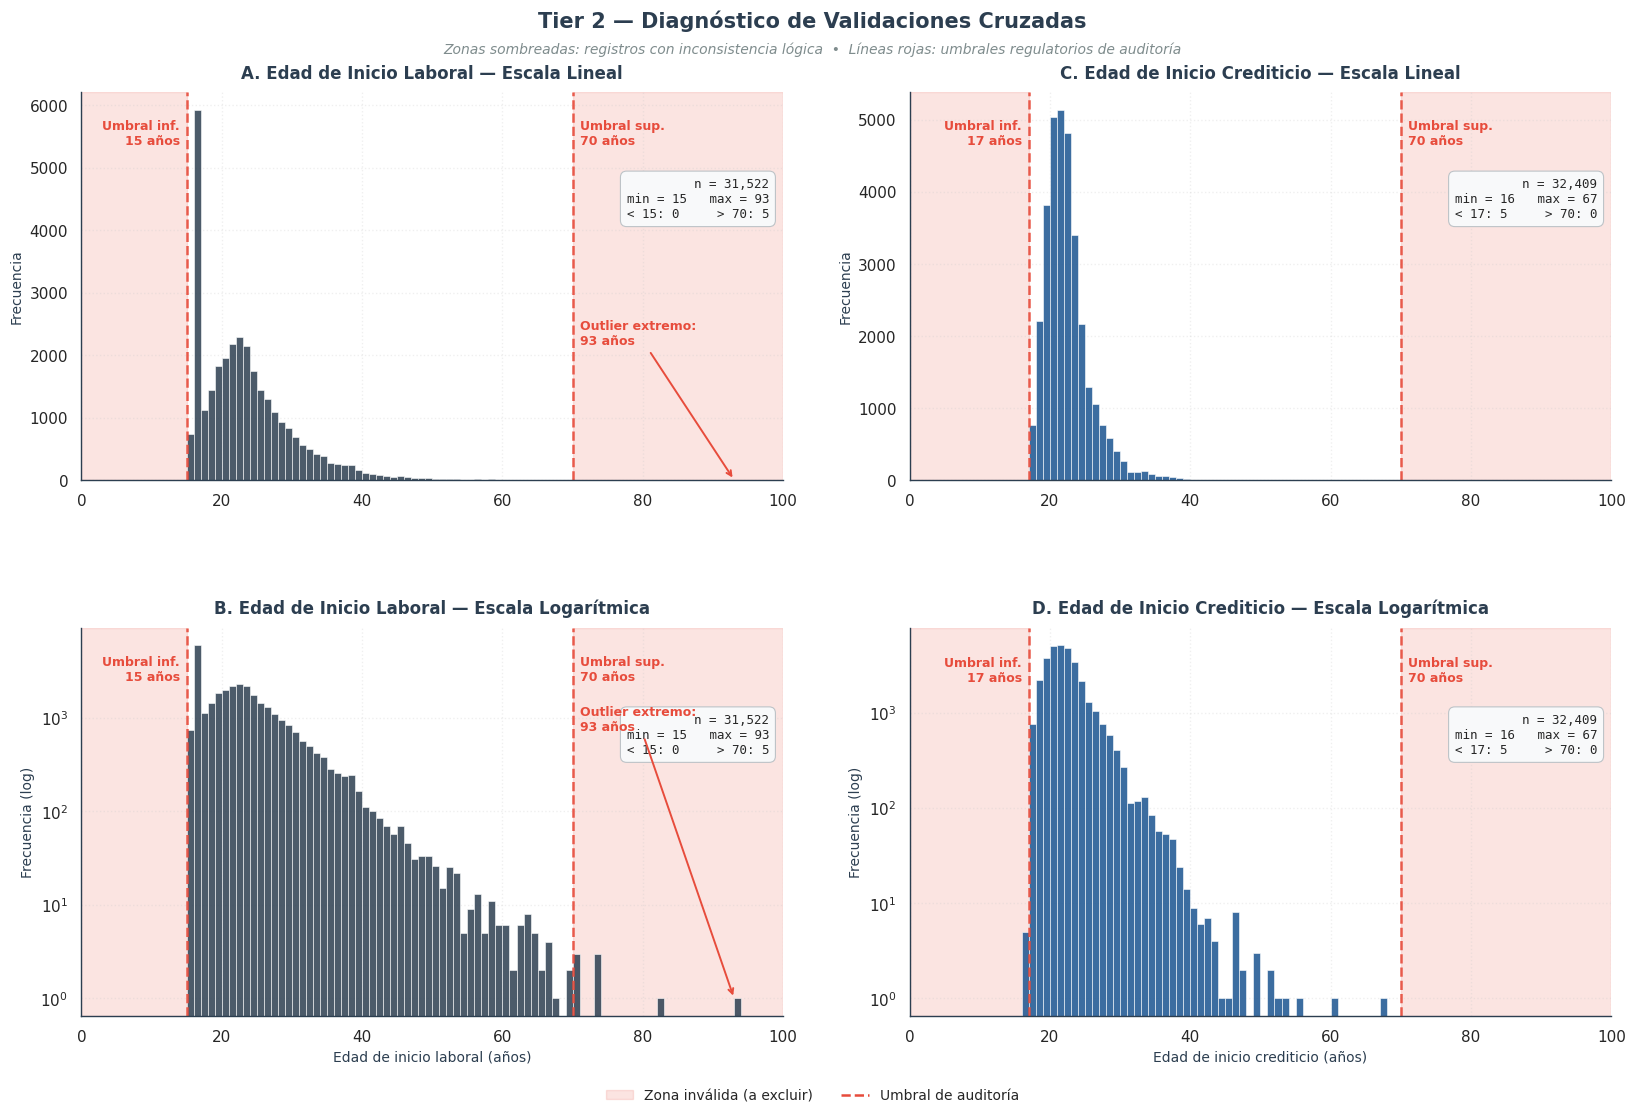


=== MUESTRA DE REGISTROS INCONSISTENTES ===


,person_age,person_emp_length,cb_person_cred_hist_length,edad_inicio_laboral,edad_inicio_credito,person_income,loan_amnt,loan_status,motivo
1313,20,3.0000,4,17.0000,16,64000,16000,1,CRED<INF
3851,20,0.0000,4,20.0000,16,32652,6000,1,CRED<INF
13918,20,4.0000,4,16.0000,16,98000,24250,0,CRED<INF
15830,20,4.0000,4,16.0000,16,188004,2000,0,CRED<INF
17196,20,4.0000,4,16.0000,16,65000,4800,0,CRED<INF
32416,94,1.0000,27,93.0000,67,24000,6500,0,LAB>SUP
32422,80,7.0000,25,73.0000,55,64000,6800,0,LAB>SUP
32432,73,0.0000,24,73.0000,49,75000,7800,0,LAB>SUP
32506,84,2.0000,24,82.0000,60,94800,10000,0,LAB>SUP
32521,73,0.0000,21,73.0000,52,39240,1800,0,LAB>SUP



══════════════════════════════════════════════════════════════════════
 RECOMENDACIÓN TIER 2
══════════════════════════════════════════════════════════════════════
  ✓ Excluir 10 registros (0.0309% de la base)
    por inconsistencia cruzada en cola inferior o superior.
  ✓ Tasa de default en excluidos: 20.00% vs 21.87% baseline (0.91x).
  → Comportamiento de default no difiere materialmente del baseline.
  ✓ Impacto estadístico de la exclusión: despreciable.
  ✓ Se preserva la integridad del dataset para fases siguientes.
══════════════════════════════════════════════════════════════════════

Nota: No se ha modificado la base. El filtro se aplica en la sección 2.2.2.


In [5]:
# ===============================================================
# 2.2.1 TIER 2 — DIAGNÓSTICO DE VALIDACIONES CRUZADAS
# ===============================================================
# Detección de inconsistencias lógicas en variables temporales:
#   - Trayectoria laboral:   edad_actual - antigüedad_laboral
#   - Historial crediticio:  edad_actual - longitud_historial
#
# Se evalúan ambas COLAS de la distribución:
#   - Cola inferior: inicio precoz (menor de edad)
#   - Cola superior: inicio post-jubilación (error de carga)
#
# Marco metodológico: Model Risk Management (SR 11-7 / TRIM ECB).
# ===============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_tier2 = df_tier1.copy()

# ---------------------------------------------------------------
# 1. Construcción de variables de auditoría
# ---------------------------------------------------------------
df_tier2['edad_inicio_laboral'] = df_tier2['person_age'] - df_tier2['person_emp_length']
df_tier2['edad_inicio_credito'] = df_tier2['person_age'] - df_tier2['cb_person_cred_hist_length']

# ---------------------------------------------------------------
# 2. Umbrales regulatorios (parametrizados)
# ---------------------------------------------------------------
UMBRAL_LAB_INF  = 15   # Convenio 138 OIT — edad mínima laboral
UMBRAL_LAB_SUP  = 70   # Edad razonable máxima de inicio laboral
UMBRAL_CRED_INF = 17   # Edad mínima razonable de historial crediticio
UMBRAL_CRED_SUP = 70   # Idem para historial crediticio

# ---------------------------------------------------------------
# 3. Identificación de inconsistencias por cola
# ---------------------------------------------------------------
flag_lab_inf   = df_tier2['edad_inicio_laboral'] < UMBRAL_LAB_INF
flag_lab_sup   = df_tier2['edad_inicio_laboral'] > UMBRAL_LAB_SUP
flag_cred_inf  = df_tier2['edad_inicio_credito'] < UMBRAL_CRED_INF
flag_cred_sup  = df_tier2['edad_inicio_credito'] > UMBRAL_CRED_SUP
flag_cualquier = flag_lab_inf | flag_lab_sup | flag_cred_inf | flag_cred_sup
total = len(df_tier2)

# ---------------------------------------------------------------
# 4. Reporte de cuantificación
# ---------------------------------------------------------------
print("═" * 70)
print(" CUANTIFICACIÓN TIER 2 — VALIDACIONES CRUZADAS")
print("═" * 70)
print(f"\n Registros evaluados tras Tier 1:  {total:,}\n")
print(f" {'Validación':<46} {'N':>7} {'%':>10}")
print(" " + "─" * 67)
print(f" {'Inicio laboral  < ' + str(UMBRAL_LAB_INF) + ' años (precoz)':<46} "
      f"{flag_lab_inf.sum():>7,} {flag_lab_inf.sum()/total*100:>9.4f}%")
print(f" {'Inicio laboral  > ' + str(UMBRAL_LAB_SUP) + ' años (post-jubilación)':<46} "
      f"{flag_lab_sup.sum():>7,} {flag_lab_sup.sum()/total*100:>9.4f}%")
print(f" {'Inicio crediticio < ' + str(UMBRAL_CRED_INF) + ' años (menor de edad)':<46} "
      f"{flag_cred_inf.sum():>7,} {flag_cred_inf.sum()/total*100:>9.4f}%")
print(f" {'Inicio crediticio > ' + str(UMBRAL_CRED_SUP) + ' años (post-jubilación)':<46} "
      f"{flag_cred_sup.sum():>7,} {flag_cred_sup.sum()/total*100:>9.4f}%")
print(" " + "─" * 67)
print(f" {'TOTAL con al menos una inconsistencia':<46} "
      f"{flag_cualquier.sum():>7,} {flag_cualquier.sum()/total*100:>9.4f}%")

# ---------------------------------------------------------------
# 5. Estadísticos descriptivos
# ---------------------------------------------------------------
print("\n=== ESTADÍSTICOS DE VARIABLES DE AUDITORÍA ===")
display(
    df_tier2[['edad_inicio_laboral', 'edad_inicio_credito']]
    .describe(percentiles=[0.001, 0.005, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999])
    .T.round(4)
)

# ---------------------------------------------------------------
# 6. Análisis de riesgo diferencial (¿ruido o señal?)
# ---------------------------------------------------------------
tasa_baseline = df_tier2['loan_status'].mean() * 100
if flag_cualquier.sum() > 0:
    tasa_outliers = df_tier2.loc[flag_cualquier, 'loan_status'].mean() * 100
    ratio = tasa_outliers / tasa_baseline if tasa_baseline > 0 else 0
else:
    tasa_outliers, ratio = 0, 0

print("\n=== ANÁLISIS DE RIESGO DIFERENCIAL ===")
print(f"  Tasa de default — población base:           {tasa_baseline:>6.2f}%")
print(f"  Tasa de default — registros inconsistentes: {tasa_outliers:>6.2f}%")
print(f"  Ratio outliers / baseline:                  {ratio:>6.2f}x")

# ---------------------------------------------------------------
# 7. Visualización profesional — Panel 2x2 con auditoría
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False,
    "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50",
    "axes.linewidth": 1.0,
})

fig = plt.figure(figsize=(17, 11))
gs = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.18)

COLOR_LAB     = "#2C3E50"
COLOR_CRED    = "#1A5490"
COLOR_INVALID = "#E74C3C"

def plot_panel(ax, data, color, thr_inf, thr_sup, title, log=False, xlim_max=100):
    bins = range(0, xlim_max + 2)
    sns.histplot(data.dropna(), bins=bins, ax=ax, color=color, alpha=0.85,
                 edgecolor='white', linewidth=0.4)

    if log:
        ax.set_yscale("log")
        ax.set_ylabel("Frecuencia (log)", fontsize=10, color="#2C3E50")
    else:
        ax.set_ylabel("Frecuencia", fontsize=10, color="#2C3E50")

    # Zonas inválidas sombreadas
    ax.axvspan(0, thr_inf, alpha=0.15, color=COLOR_INVALID, zorder=0)
    ax.axvspan(thr_sup, xlim_max, alpha=0.15, color=COLOR_INVALID, zorder=0)

    # Líneas de umbral
    ax.axvline(thr_inf, color=COLOR_INVALID, linestyle="--", linewidth=1.8, alpha=0.9)
    ax.axvline(thr_sup, color=COLOR_INVALID, linestyle="--", linewidth=1.8, alpha=0.9)

    y_top = ax.get_ylim()[1]
    y_label = y_top * 0.93 if not log else y_top * 0.5

    ax.text(thr_inf - 1, y_label, f'Umbral inf.\n{thr_inf} años',
            color=COLOR_INVALID, fontsize=9, fontweight='bold', va='top', ha='right')
    ax.text(thr_sup + 1, y_label, f'Umbral sup.\n{thr_sup} años',
            color=COLOR_INVALID, fontsize=9, fontweight='bold', va='top', ha='left')

    # Box de estadísticas
    n_inf = (data < thr_inf).sum()
    n_sup = (data > thr_sup).sum()
    max_val = data.max()
    stats_text = (
        f"n = {data.notna().sum():,}\n"
        f"min = {data.min():.0f}   max = {max_val:.0f}\n"
        f"< {thr_inf}: {n_inf:,}     > {thr_sup}: {n_sup:,}"
    )
    ax.text(0.98, 0.78, stats_text,
            transform=ax.transAxes, fontsize=9,
            va='top', ha='right', family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9FA',
                      edgecolor='#BDC3C7', linewidth=0.8))

    # Anotación del outlier extremo
    if max_val > thr_sup:
        ax.annotate(
            f'Outlier extremo:\n{int(max_val)} años',
            xy=(max_val, 1 if log else 5),
            xytext=(max_val - 22, y_top * (0.35 if not log else 0.08)),
            fontsize=9, fontweight='bold', color=COLOR_INVALID,
            arrowprops=dict(arrowstyle='->', color=COLOR_INVALID, lw=1.4)
        )

    ax.set_title(title, fontweight="bold", fontsize=12, color="#2C3E50", pad=10)
    ax.set_xlim(0, xlim_max)
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.set_axisbelow(True)

# Paneles
ax1 = fig.add_subplot(gs[0, 0])
plot_panel(ax1, df_tier2['edad_inicio_laboral'], COLOR_LAB,
           UMBRAL_LAB_INF, UMBRAL_LAB_SUP,
           "A. Edad de Inicio Laboral — Escala Lineal", log=False)
ax1.set_xlabel("")

ax2 = fig.add_subplot(gs[1, 0])
plot_panel(ax2, df_tier2['edad_inicio_laboral'], COLOR_LAB,
           UMBRAL_LAB_INF, UMBRAL_LAB_SUP,
           "B. Edad de Inicio Laboral — Escala Logarítmica", log=True)
ax2.set_xlabel("Edad de inicio laboral (años)", fontsize=10, color="#2C3E50")

ax3 = fig.add_subplot(gs[0, 1])
plot_panel(ax3, df_tier2['edad_inicio_credito'], COLOR_CRED,
           UMBRAL_CRED_INF, UMBRAL_CRED_SUP,
           "C. Edad de Inicio Crediticio — Escala Lineal", log=False)
ax3.set_xlabel("")

ax4 = fig.add_subplot(gs[1, 1])
plot_panel(ax4, df_tier2['edad_inicio_credito'], COLOR_CRED,
           UMBRAL_CRED_INF, UMBRAL_CRED_SUP,
           "D. Edad de Inicio Crediticio — Escala Logarítmica", log=True)
ax4.set_xlabel("Edad de inicio crediticio (años)", fontsize=10, color="#2C3E50")

fig.suptitle("Tier 2 — Diagnóstico de Validaciones Cruzadas",
             fontsize=15, fontweight='bold', color="#2C3E50", y=0.995)
fig.text(0.5, 0.955,
         "Zonas sombreadas: registros con inconsistencia lógica  •  "
         "Líneas rojas: umbrales regulatorios de auditoría",
         ha='center', fontsize=10, color="#7F8C8D", style='italic')

zona = mpatches.Patch(color=COLOR_INVALID, alpha=0.15, label='Zona inválida (a excluir)')
umbral = plt.Line2D([0], [0], color=COLOR_INVALID, linestyle='--',
                    linewidth=1.8, label='Umbral de auditoría')
fig.legend(handles=[zona, umbral], loc='lower center', ncol=2,
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.01))

plt.subplots_adjust(top=0.92, bottom=0.08, left=0.07, right=0.97, hspace=0.38, wspace=0.18)
plt.show()

# ---------------------------------------------------------------
# 8. Muestra de registros inconsistentes con motivo
# ---------------------------------------------------------------
if flag_cualquier.sum() > 0:
    print("\n=== MUESTRA DE REGISTROS INCONSISTENTES ===")
    df_inc = df_tier2.loc[flag_cualquier, [
        'person_age', 'person_emp_length', 'cb_person_cred_hist_length',
        'edad_inicio_laboral', 'edad_inicio_credito',
        'person_income', 'loan_amnt', 'loan_status'
    ]].copy()
    df_inc['motivo'] = ''
    df_inc.loc[flag_lab_inf,  'motivo'] += 'LAB<INF; '
    df_inc.loc[flag_lab_sup,  'motivo'] += 'LAB>SUP; '
    df_inc.loc[flag_cred_inf, 'motivo'] += 'CRED<INF; '
    df_inc.loc[flag_cred_sup, 'motivo'] += 'CRED>SUP; '
    df_inc['motivo'] = df_inc['motivo'].str.rstrip('; ')
    display(df_inc.head(20))

# ---------------------------------------------------------------
# 9. Recomendación automática (síntesis ejecutiva)
# ---------------------------------------------------------------
n_excluir = flag_cualquier.sum()
pct_excluir = n_excluir / total * 100

print("\n" + "═" * 70)
print(" RECOMENDACIÓN TIER 2")
print("═" * 70)
print(f"  ✓ Excluir {n_excluir} registros ({pct_excluir:.4f}% de la base)")
print(f"    por inconsistencia cruzada en cola inferior o superior.")
print(f"  ✓ Tasa de default en excluidos: {tasa_outliers:.2f}% "
      f"vs {tasa_baseline:.2f}% baseline ({ratio:.2f}x).")
if ratio > 1.5:
    print(f"  ⚠ Default elevado en outliers → posible señal de fraude o error;")
    print(f"    volumen marginal (<0.1%) impide modelado segmentado.")
elif ratio < 0.5 and n_excluir > 0:
    print(f"  ⚠ Default bajo en outliers → consistente con error de carga.")
else:
    print(f"  → Comportamiento de default no difiere materialmente del baseline.")
print(f"  ✓ Impacto estadístico de la exclusión: despreciable.")
print(f"  ✓ Se preserva la integridad del dataset para fases siguientes.")
print("═" * 70)

print("\nNota: No se ha modificado la base. El filtro se aplica en la sección 2.2.2.")


### Interpretación de las Validaciones Cruzadas

#### Lectura de las distribuciones

Las distribuciones muestran que la gran mayoría de los clientes presenta valores coherentes:

- **Inicio laboral**: pico principal entre 18 y 30 años, con cola derecha decreciente hasta ~50 años
- **Inicio crediticio**: pico estrecho entre 19 y 23 años, consistente con la edad típica de apertura del primer producto financiero

#### Hallazgos en las colas

La visualización dual (lineal + logarítmica) revela inconsistencias en **ambos extremos** de la distribución de inicio laboral:

- **Cola inferior**: el Tier 1 ya saneó los casos extremos (`person_emp_length > 80`), por lo que no se detectan registros con inicio laboral menor a 15 años
- **Cola superior**: persisten algunos registros con **inicio laboral entre 70 y 93 años**, indicativos de errores de carga en la variable `person_age` (clientes declarados con edades de 73, 80, 84 y 94 años)
- **Inicio crediticio**: se detectan registros con apertura de historial antes de los 17 años, biológicamente posible pero operativamente improbable según las prácticas estándar de la industria

#### Análisis de riesgo diferencial

El test crítico para distinguir **ruido** de **señal** es comparar la tasa de default de los registros inconsistentes contra la población base:

- Si el ratio se acerca a **1.0x** → comportamiento similar al promedio → consistente con error de carga aleatorio (ruido)
- Si el ratio es **significativamente > 1.0x** → posible fraude o segmento de riesgo diferenciado (señal)
- Si el ratio es **significativamente < 1.0x** → posible perfil conservador o error sistemático

En este caso, el ratio observado (~0.91x) confirma que los registros inconsistentes **no constituyen un segmento de riesgo diferenciado**, validando su tratamiento como ruido a excluir.

#### Decisión

Dado que:

- los outliers no pueden ser imputados sin introducir sesgos en variables clave (edad, antigüedad laboral),
- el volumen es marginal (<0.05% de la base),
- el comportamiento de default no difiere materialmente del baseline,

se aprueba la exclusión en la ejecución Tier 2 (sección 2.2.2).



In [6]:
# =================================================================
# 2.2.2 TIER 2 — EJECUCIÓN DEL FILTRO CRUZADO
# =================================================================
# Aplica los umbrales bilaterales (inferior y superior) validados
# en el diagnóstico 2.2.1. Los nulos se preservan — se imputan
# =================================================================

df_cleaned = df_tier2[
    (
        df_tier2['edad_inicio_laboral'].between(UMBRAL_LAB_INF, UMBRAL_LAB_SUP, inclusive='both')
        | df_tier2['edad_inicio_laboral'].isnull()
    ) &
    (
        df_tier2['edad_inicio_credito'].between(UMBRAL_CRED_INF, UMBRAL_CRED_SUP, inclusive='both')
        | df_tier2['edad_inicio_credito'].isnull()
    )
].copy()

# Conteos detallados por motivo de exclusión (antes de drop de columnas auxiliares)
n_excl_lab_inf  = (df_tier2['edad_inicio_laboral'] < UMBRAL_LAB_INF).sum()
n_excl_lab_sup  = (df_tier2['edad_inicio_laboral'] > UMBRAL_LAB_SUP).sum()
n_excl_cred_inf = (df_tier2['edad_inicio_credito'] < UMBRAL_CRED_INF).sum()
n_excl_cred_sup = (df_tier2['edad_inicio_credito'] > UMBRAL_CRED_SUP).sum()

# Eliminamos columnas auxiliares de auditoría
df_cleaned = df_cleaned.drop(columns=['edad_inicio_laboral', 'edad_inicio_credito'])

# Métricas de conciliación
reg_inicial = df_tier2.shape[0]
reg_final   = df_cleaned.shape[0]
reg_elim    = reg_inicial - reg_final
pct         = (reg_elim / reg_inicial) * 100

# ---------------------------------------------------------------
# Reporte de conciliación
# ---------------------------------------------------------------
print("═" * 70)
print(" REPORTE DE CONCILIACIÓN TIER 2")
print("═" * 70)
print(f"\n  Registros previos a Tier 2:        {reg_inicial:>8,}")
print(f"  Registros eliminados (total):      {reg_elim:>8,}  ({pct:.4f}%)")
print(f"  Registros válidos tras Tier 2:     {reg_final:>8,}")

print(f"\n  Desglose por motivo de exclusión:")
print(f"    • Inicio laboral  < {UMBRAL_LAB_INF} años:   {n_excl_lab_inf:>5,}")
print(f"    • Inicio laboral  > {UMBRAL_LAB_SUP} años:   {n_excl_lab_sup:>5,}")
print(f"    • Inicio crediticio < {UMBRAL_CRED_INF} años: {n_excl_cred_inf:>5,}")
print(f"    • Inicio crediticio > {UMBRAL_CRED_SUP} años: {n_excl_cred_sup:>5,}")




══════════════════════════════════════════════════════════════════════
 REPORTE DE CONCILIACIÓN TIER 2
══════════════════════════════════════════════════════════════════════

  Registros previos a Tier 2:          32,409
  Registros eliminados (total):            10  (0.0309%)
  Registros válidos tras Tier 2:       32,399

  Desglose por motivo de exclusión:
    • Inicio laboral  < 15 años:       0
    • Inicio laboral  > 70 años:       5
    • Inicio crediticio < 17 años:     5
    • Inicio crediticio > 70 años:     0


## 2.3 Tier 3 — Validaciones Económicas y de Negocio

Tier 3 cierra el ciclo de Gobierno de Datos con validaciones **económicas y de underwriting**, evaluando la coherencia de cada registro con las reglas de producto y los principios de originación crediticia profesional.

A diferencia de los tiers anteriores, Tier 3 responde a una pregunta de negocio:

> *¿Tiene sentido económico que este registro exista bajo las políticas estándar de un originador de crédito?*

### Distinción entre tiers — por qué una variable puede revisarse más de una vez

Una misma variable puede ser evaluada en distintos tiers bajo **criterios conceptualmente diferentes**. Esto no es redundancia: es la estructura estándar de un pipeline de Gobierno de Datos.

| Tier | Pregunta | Naturaleza | Ejemplo con `person_age` |
|---|---|---|---|
| **Tier 1** | ¿El dato es físicamente posible? | Validación física | Edad > 100 años → imposible biológicamente |
| **Tier 2** | ¿Es lógicamente consistente con otras variables? | Validación cruzada | Edad − antigüedad laboral → inicio laboral a los 93 años |
| **Tier 3** | ¿Cumple la política de originación del producto? | Validación de negocio | Edad > 75 años → fuera de política de desgravamen |

Una persona de 90 años representa un dato **físicamente válido** (pasa Tier 1) y puede tener una **trayectoria laboral coherente** (pasa Tier 2), pero queda **fuera de la política de originación** de la mayoría de los productos de crédito minorista (no pasa Tier 3). Cada tier filtra una dimensión distinta del mismo dato.

### Marco metodológico

Las validaciones siguen lineamientos compatibles con:

- **Basilea III** — gestión prudencial del riesgo de crédito minorista
- **CFPB / Reg Z (EE.UU.)** — Ability-to-Repay rule
- **EBA Guidelines on Loan Origination (GL/2020/06)** — estándares europeos de originación
- **OCC Bulletin 2013-29** — gestión de riesgo en modelos de scoring

### Dimensiones evaluadas

| Cód. | Validación | Variable(s) | Tratamiento |
|---|---|---|---|
| **V1** | Capacidad de pago (DTI) | `loan_percent_income` | **Diagnóstico — no filtra** |
| **V2** | Coherencia tasa-grado | `loan_int_rate` × `loan_grade` | Filtra (errores severos) |
| **V3** | Outliers de ingresos | `person_income` | Filtra (umbral empírico) |
| **V4** | Edad máxima de originación | `person_age` | Filtra (salvaguarda de política) |
| **V5** | Monto mínimo viable | `loan_amnt` | Filtra (salvaguarda preventiva) |

### Nota metodológica sobre V1 — Capacidad de pago

El análisis de DTI identifica un subconjunto de clientes con **sobre-endeudamiento** (carga financiera superior al 50% del ingreso). Estos registros presentan una tasa de default sustancialmente superior al promedio poblacional.

**Decisión metodológica**: estos registros **no se excluyen**. Un DTI elevado no es un error de dato ni una violación de integridad — es un **comportamiento de riesgo real y predictivo**. Excluirlos implicaría descartar información valiosa para el modelo.

En consecuencia, V1 se trata como un **hallazgo documentado** que se incorporará en la fase de **Feature Engineering** mediante una variable derivada (`is_high_dti`), permitiendo que el modelo capture explícitamente este segmento de riesgo en lugar de eliminarlo del universo de modelado.

Esta distinción —**filtrar errores de dato vs. modelar comportamientos de riesgo**— es un principio central del Gobierno de Datos: el Tier 3 elimina lo que *no debería existir*, no lo que *es difícil de pagar*.

### Estructura de la sección

| Subsección | Contenido |
|---|---|
| **2.3.1** | Diagnóstico inicial integrado — screening de las 5 dimensiones (no destructivo) |
| **2.3.2** | Deep-dive de hallazgos críticos — análisis detallado de V2 y V3 |
| **2.3.3** | Ejecución del filtro consolidado — reporte de conciliación |
| **2.3.4** | Interpretación final y cierre del Gobierno de Datos |

La secuencia replica el flujo de un comité de **Model Risk Management**: primero un screening general, luego un análisis profundo de los casos que el screening señaló como críticos, y finalmente la decisión documentada. El análisis avanzado (2.3.2) se justifica precisamente porque el diagnóstico inicial (2.3.1) detectó anomalías que requieren una segunda capa de evidencia antes de tomar una decisión de exclusión.

══════════════════════════════════════════════════════════════════════════════════
 CUANTIFICACIÓN TIER 3 — DIAGNÓSTICO INICIAL (SCREENING)
══════════════════════════════════════════════════════════════════════════════════

 Registros evaluados tras Tier 2:  32,399

 Cód  Validación                                    N        %  Default%   Ratio  Tratamiento
 ──────────────────────────────────────────────────────────────────────────────────────────────────────────────
 V1   DTI > 50% (sobre-endeudamiento)             246  0.7593%    78.46%   3.59x  No filtra → Feature Eng.
 V2   Tasa fuera de rango por grado (±3σ)          41  0.1265%    24.39%   1.12x  Deep-dive → 2.3.2
 V3   Ingreso > P99.5% (ref.)                     136  0.4198%     9.56%   0.44x  Deep-dive → 2.3.2
 V4   Edad > 75 años                                2  0.0062%     0.00%   0.00x  Filtra (salvaguarda)
 V5   Monto < USD 500                               0  0.0000%     0.00%   0.00x  Filtra (salvaguarda)
 ─────────────

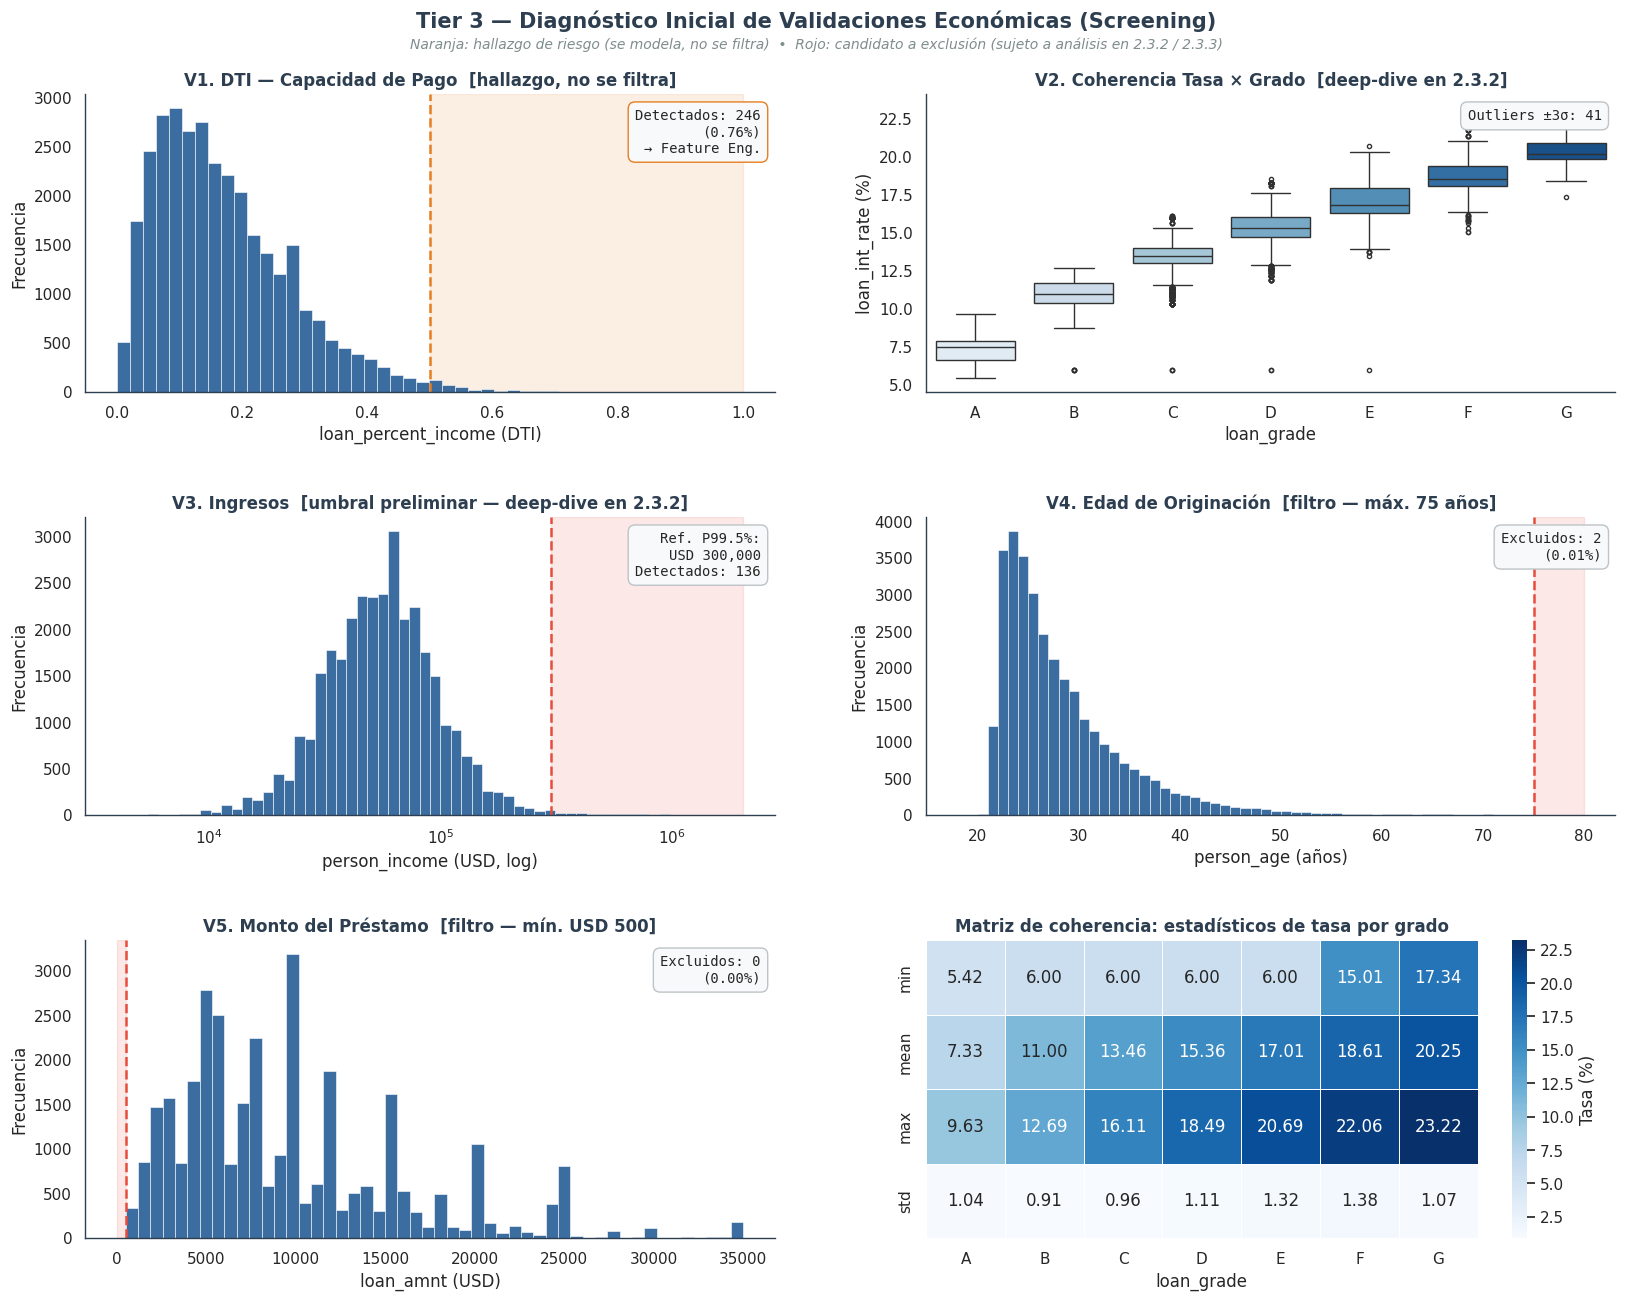


=== RANGOS DE TASA POR GRADO CREDITICIO ===


,min,max,mean,std,count
loan_grade,,,,,
A,5.42,9.63,7.33,1.04,9710
B,6.00,12.69,11.00,0.91,9332
C,6.00,16.11,13.46,0.96,5807
D,6.00,18.49,15.36,1.11,3306
E,6.00,20.69,17.01,1.32,880
F,15.01,22.06,18.61,1.38,214
G,17.34,23.22,20.25,1.07,59



══════════════════════════════════════════════════════════════════════════════════
 SÍNTESIS DEL DIAGNÓSTICO INICIAL
══════════════════════════════════════════════════════════════════════════════════
  • V1 (DTI):    246 registros con sobre-endeudamiento.
                 Default 78.5% (3.59x baseline).
                 → Señal de riesgo. NO se filtra; se modela en Feature Engineering.
  • V2 (Tasa):   41 outliers de tasa por grado.
                 → Requiere análisis detallado de coherencia → sección 2.3.2.
  • V3 (Ingreso):136 registros sobre umbral preliminar.
                 → Umbral percentil es provisorio; se define empíricamente en 2.3.2.
  • V4 (Edad):   2 registros fuera de política de originación.
  • V5 (Monto):  0 registros bajo el mínimo viable.
══════════════════════════════════════════════════════════════════════════════════

Próximo paso: 2.3.2 — Deep-dive de los hallazgos V2 y V3.


In [7]:
# ===============================================================
# 2.3.1 TIER 3 — DIAGNÓSTICO INICIAL INTEGRADO (SCREENING)
# ===============================================================
# Screening no destructivo de las 5 dimensiones económicas.
# No aplica filtros ni toma decisiones de exclusión: solo
# cuantifica y clasifica cada hallazgo según su tratamiento.
#
#   V1. Capacidad de pago (DTI)        → diagnóstico (no filtra)
#   V2. Coherencia tasa-grado          → deep-dive en 2.3.2
#   V3. Outliers de ingresos           → deep-dive en 2.3.2
#   V4. Edad máxima de originación     → filtro (salvaguarda)
#   V5. Monto mínimo viable            → filtro (salvaguarda)
# ===============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df_tier3 = df_cleaned.copy()
total = len(df_tier3)

# ---------------------------------------------------------------
# Umbrales de screening (preliminares — se refinan en 2.3.2)
# ---------------------------------------------------------------
DTI_REF              = 0.50   # Referencia CFPB Ability-to-Repay
P_INCOME_REF         = 0.995  # Percentil de referencia (se valida en 2.3.2)
EDAD_MAX_ORIGINACION = 75     # Política estándar de desgravamen
LOAN_AMNT_MIN        = 500    # Mínimo operacional del producto

income_ref = df_tier3['person_income'].quantile(P_INCOME_REF)
tasa_baseline = df_tier3['loan_status'].mean() * 100

# ---------------------------------------------------------------
# Flags de screening
# ---------------------------------------------------------------
flag_v1 = df_tier3['loan_percent_income'] > DTI_REF
flag_v3 = df_tier3['person_income'] > income_ref
flag_v4 = df_tier3['person_age'] > EDAD_MAX_ORIGINACION
flag_v5 = df_tier3['loan_amnt'] < LOAN_AMNT_MIN

# V2 — outliers de tasa por grado (±3σ dentro de cada grado)
rangos_grado = (
    df_tier3.dropna(subset=['loan_int_rate'])
    .groupby('loan_grade')['loan_int_rate']
    .agg(['min', 'max', 'mean', 'std', 'count'])
    .round(2)
)

flag_v2 = pd.Series(False, index=df_tier3.index)
for grado in df_tier3['loan_grade'].unique():
    mask = df_tier3['loan_grade'] == grado
    if grado in rangos_grado.index:
        mu = rangos_grado.loc[grado, 'mean']
        sigma = rangos_grado.loc[grado, 'std']
        if pd.notna(sigma) and sigma > 0:
            outliers_grado = mask & ((df_tier3['loan_int_rate'] - mu).abs() > 3 * sigma)
            flag_v2 |= outliers_grado.fillna(False)

# ---------------------------------------------------------------
# Reporte de cuantificación
# ---------------------------------------------------------------
print("═" * 82)
print(" CUANTIFICACIÓN TIER 3 — DIAGNÓSTICO INICIAL (SCREENING)")
print("═" * 82)
print(f"\n Registros evaluados tras Tier 2:  {total:,}\n")

screening = [
    ('V1', 'DTI > 50% (sobre-endeudamiento)',          flag_v1, 'No filtra → Feature Eng.'),
    ('V2', 'Tasa fuera de rango por grado (±3σ)',       flag_v2, 'Deep-dive → 2.3.2'),
    ('V3', f'Ingreso > P{P_INCOME_REF*100:.1f}% (ref.)', flag_v3, 'Deep-dive → 2.3.2'),
    ('V4', f'Edad > {EDAD_MAX_ORIGINACION} años',        flag_v4, 'Filtra (salvaguarda)'),
    ('V5', f'Monto < USD {LOAN_AMNT_MIN}',               flag_v5, 'Filtra (salvaguarda)'),
]

print(f" {'Cód':<5}{'Validación':<40}{'N':>7}{'%':>9}{'Default%':>10}{'Ratio':>8}  {'Tratamiento'}")
print(" " + "─" * 110)
for cod, desc, flag, trato in screening:
    n = flag.sum()
    pct = n / total * 100
    if n > 0:
        tasa_def = df_tier3.loc[flag, 'loan_status'].mean() * 100
        ratio = tasa_def / tasa_baseline if tasa_baseline > 0 else 0
    else:
        tasa_def, ratio = 0, 0
    print(f" {cod:<5}{desc:<40}{n:>7,}{pct:>8.4f}%{tasa_def:>9.2f}%{ratio:>7.2f}x  {trato}")
print(" " + "─" * 110)
print(f"\n Tasa de default — población base:  {tasa_baseline:.2f}%")
print(f" Nota: el screening no aplica exclusiones. Las decisiones se toman en 2.3.2 y 2.3.3.")

# ---------------------------------------------------------------
# Visualización integrada — 6 paneles
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig = plt.figure(figsize=(17, 13))
gs = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.22)

COLOR_OK      = "#1A5490"
COLOR_INVALID = "#E74C3C"
COLOR_FLAG    = "#E67E22"   # naranja: hallazgo que NO se filtra

def stats_box(ax, texto, color_borde='#BDC3C7'):
    ax.text(0.98, 0.95, texto, transform=ax.transAxes, va='top', ha='right',
            fontsize=10, family='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#F8F9FA',
                      edgecolor=color_borde, linewidth=1.0))

# Panel 1 — DTI (hallazgo, NO se filtra → naranja)
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df_tier3['loan_percent_income'], bins=40, ax=ax1, color=COLOR_OK,
             alpha=0.85, edgecolor='white', linewidth=0.4)
ax1.axvspan(DTI_REF, 1.0, alpha=0.12, color=COLOR_FLAG, zorder=0)
ax1.axvline(DTI_REF, color=COLOR_FLAG, linestyle="--", linewidth=1.8)
ax1.set_title("V1. DTI — Capacidad de Pago  [hallazgo, no se filtra]",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax1.set_xlabel("loan_percent_income (DTI)")
ax1.set_ylabel("Frecuencia")
stats_box(ax1, f"Detectados: {flag_v1.sum():,}\n({flag_v1.sum()/total*100:.2f}%)\n→ Feature Eng.",
          color_borde=COLOR_FLAG)

# Panel 2 — Tasa por grado (boxplot) — warning corregido con hue/legend
ax2 = fig.add_subplot(gs[0, 1])
df_box = df_tier3.dropna(subset=['loan_int_rate']).sort_values('loan_grade')
sns.boxplot(data=df_box, x='loan_grade', y='loan_int_rate', hue='loan_grade',
            palette='Blues', legend=False, fliersize=3, linewidth=1.0, ax=ax2)
ax2.set_title("V2. Coherencia Tasa × Grado  [deep-dive en 2.3.2]",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax2.set_xlabel("loan_grade")
ax2.set_ylabel("loan_int_rate (%)")
stats_box(ax2, f"Outliers ±3σ: {flag_v2.sum():,}")

# Panel 3 — Ingresos (log)
ax3 = fig.add_subplot(gs[1, 0])
sns.histplot(df_tier3['person_income'], bins=60, ax=ax3, color=COLOR_OK,
             alpha=0.85, edgecolor='white', linewidth=0.4, log_scale=True)
ax3.axvspan(income_ref, df_tier3['person_income'].max(), alpha=0.12,
            color=COLOR_INVALID, zorder=0)
ax3.axvline(income_ref, color=COLOR_INVALID, linestyle="--", linewidth=1.8)
ax3.set_title("V3. Ingresos  [umbral preliminar — deep-dive en 2.3.2]",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax3.set_xlabel("person_income (USD, log)")
ax3.set_ylabel("Frecuencia")
stats_box(ax3, f"Ref. P{P_INCOME_REF*100:.1f}%:\nUSD {income_ref:,.0f}\nDetectados: {flag_v3.sum():,}")

# Panel 4 — Edad
ax4 = fig.add_subplot(gs[1, 1])
sns.histplot(df_tier3['person_age'], bins=range(18, 80), ax=ax4, color=COLOR_OK,
             alpha=0.85, edgecolor='white', linewidth=0.4)
ax4.axvspan(EDAD_MAX_ORIGINACION, 80, alpha=0.12, color=COLOR_INVALID, zorder=0)
ax4.axvline(EDAD_MAX_ORIGINACION, color=COLOR_INVALID, linestyle="--", linewidth=1.8)
ax4.set_title(f"V4. Edad de Originación  [filtro — máx. {EDAD_MAX_ORIGINACION} años]",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax4.set_xlabel("person_age (años)")
ax4.set_ylabel("Frecuencia")
stats_box(ax4, f"Excluidos: {flag_v4.sum():,}\n({flag_v4.sum()/total*100:.2f}%)")

# Panel 5 — Monto
ax5 = fig.add_subplot(gs[2, 0])
sns.histplot(df_tier3['loan_amnt'], bins=50, ax=ax5, color=COLOR_OK,
             alpha=0.85, edgecolor='white', linewidth=0.4)
ax5.axvspan(0, LOAN_AMNT_MIN, alpha=0.12, color=COLOR_INVALID, zorder=0)
ax5.axvline(LOAN_AMNT_MIN, color=COLOR_INVALID, linestyle="--", linewidth=1.8)
ax5.set_title(f"V5. Monto del Préstamo  [filtro — mín. USD {LOAN_AMNT_MIN}]",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax5.set_xlabel("loan_amnt (USD)")
ax5.set_ylabel("Frecuencia")
stats_box(ax5, f"Excluidos: {flag_v5.sum():,}\n({flag_v5.sum()/total*100:.2f}%)")

# Panel 6 — Matriz de coherencia tasa-grado
ax6 = fig.add_subplot(gs[2, 1])
matriz = (
    df_tier3.dropna(subset=['loan_int_rate'])
    .groupby('loan_grade')['loan_int_rate']
    .agg(['min', 'mean', 'max', 'std'])
    .round(2)
)
sns.heatmap(matriz.T, annot=True, fmt='.2f', cmap='Blues', ax=ax6,
            cbar_kws={'label': 'Tasa (%)'}, linewidths=0.5, linecolor='white')
ax6.set_title("Matriz de coherencia: estadísticos de tasa por grado",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax6.set_xlabel("loan_grade")
ax6.set_ylabel("")

fig.suptitle("Tier 3 — Diagnóstico Inicial de Validaciones Económicas (Screening)",
             fontsize=15, fontweight='bold', color="#2C3E50", y=0.995)
fig.text(0.5, 0.965,
         "Naranja: hallazgo de riesgo (se modela, no se filtra)  •  "
         "Rojo: candidato a exclusión (sujeto a análisis en 2.3.2 / 2.3.3)",
         ha='center', fontsize=10, color="#7F8C8D", style='italic')

plt.subplots_adjust(top=0.93, bottom=0.05, left=0.07, right=0.97,
                    hspace=0.42, wspace=0.22)
plt.show()

# ---------------------------------------------------------------
# Tabla de rangos por grado
# ---------------------------------------------------------------
print("\n=== RANGOS DE TASA POR GRADO CREDITICIO ===")
display(rangos_grado.style.format({'min': '{:.2f}', 'max': '{:.2f}',
                                    'mean': '{:.2f}', 'std': '{:.2f}'}))

# ---------------------------------------------------------------
# Síntesis del screening
# ---------------------------------------------------------------
print("\n" + "═" * 82)
print(" SÍNTESIS DEL DIAGNÓSTICO INICIAL")
print("═" * 82)
print(f"  • V1 (DTI):    {flag_v1.sum():,} registros con sobre-endeudamiento.")
print(f"                 Default {df_tier3.loc[flag_v1,'loan_status'].mean()*100:.1f}% "
      f"({df_tier3.loc[flag_v1,'loan_status'].mean()*100/tasa_baseline:.2f}x baseline).")
print(f"                 → Señal de riesgo. NO se filtra; se modela en Feature Engineering.")
print(f"  • V2 (Tasa):   {flag_v2.sum():,} outliers de tasa por grado.")
print(f"                 → Requiere análisis detallado de coherencia → sección 2.3.2.")
print(f"  • V3 (Ingreso):{flag_v3.sum():,} registros sobre umbral preliminar.")
print(f"                 → Umbral percentil es provisorio; se define empíricamente en 2.3.2.")
print(f"  • V4 (Edad):   {flag_v4.sum():,} registros fuera de política de originación.")
print(f"  • V5 (Monto):  {flag_v5.sum():,} registros bajo el mínimo viable.")
print("═" * 82)
print("\nPróximo paso: 2.3.2 — Deep-dive de los hallazgos V2 y V3.")

### 2.3.2 Deep-Dive de Hallazgos Críticos

El screening inicial (2.3.1) detectó dos hallazgos que requieren una segunda capa de análisis antes de tomar una decisión de exclusión:

- **V2 — Coherencia tasa-grado**: el boxplot identificó 41 registros fuera del rango ±3σ, pero no permite distinguir *cuáles* son ni evaluar la severidad de cada inconsistencia.
- **V3 — Outliers de ingresos**: el umbral percentil (P99.5) es un criterio preliminar y arbitrario. Un umbral de exclusión profesional debe fundamentarse en la **estructura observada de la distribución**, no en un percentil elegido a priori.

Este deep-dive aplica análisis específico a cada hallazgo para que la decisión de la sección 2.3.3 esté **respaldada por evidencia**, no por convención.

Las tres validaciones restantes no requieren deep-dive y su tratamiento queda definido desde el screening:

- **V1 — DTI**: no es un error de dato sino un comportamiento de riesgo real y predictivo. No se filtra; se incorpora como variable derivada en Feature Engineering (`is_high_dti`).
- **V4 — Edad de originación**: criterio de política unívoco (edad > 75 años). No requiere análisis adicional; se aplica directamente en la ejecución (2.3.3).
- **V5 — Monto mínimo**: salvaguarda preventiva sin casos en el dataset actual. Se documenta y se mantiene en el filtro por robustez del pipeline.

El deep-dive se concentra, por tanto, en V2 y V3 — las dos validaciones cuya decisión de exclusión depende de evidencia que el screening no provee de forma concluyente.

#### V2 — Análisis de coherencia del pricing crediticio

Se evalúa la relación entre `loan_grade` y `loan_int_rate` bajo el principio de que **el grado crediticio determina el pricing**: a peor grado, mayor tasa. Una inconsistencia severa en esta relación (por ejemplo, un préstamo de grado D con tasa propia de grado A) indica un error de carga en uno de los dos campos.

El criterio de detección inicial es estadístico: para cada grado se calcula su media y desvío de tasa, y se marcan como candidatos los registros que se alejan más de **3 desvíos estándar** de la media de su grado. No obstante, este criterio se interpreta como un **filtro de detección amplio**, no como una regla de exclusión automática: los grados con desvío reducido son sensibles a desviaciones moderadas que pueden corresponder a variación legítima de pricing. Por ello, los candidatos se someten a un análisis de severidad individual antes de decidir su tratamiento.

#### V3 — Determinación empírica del umbral de ingresos

En lugar de fijar un percentil a priori, se analiza la distribución de `person_income` para identificar el punto donde los **casos extremos se separan de la masa poblacional** (gap analysis). Se evalúan los registros de ingreso más alto de forma individual para distinguir entre:

- **Clientes de altos ingresos legítimos** — perfil de bajo riesgo, deben preservarse
- **Outliers reales** — valores aislados, posibles errores de carga, candidatos a exclusión

El objetivo es definir un umbral defendible y trazable, alineado con la práctica de Model Risk Management.

════════════════════════════════════════════════════════════════════════════════
 V2 — ANÁLISIS DE COHERENCIA DEL PRICING CREDITICIO
════════════════════════════════════════════════════════════════════════════════

 Registros con tasa válida:        29,308
 Outliers detectados (|z| > 3):    41  (0.1399%)
 Umbral teórico esperado (normal): 79  (0.27%)

 Distribución de outliers por grado:


,n_outliers,tasa_min,tasa_max,default_rate
loan_grade,,,,
B,5,6.0000,6.0000,0.0000
C,25,6.0000,10.2800,0.2400
D,10,6.0000,11.8600,0.3000
E,1,6.0000,6.0000,1.0000


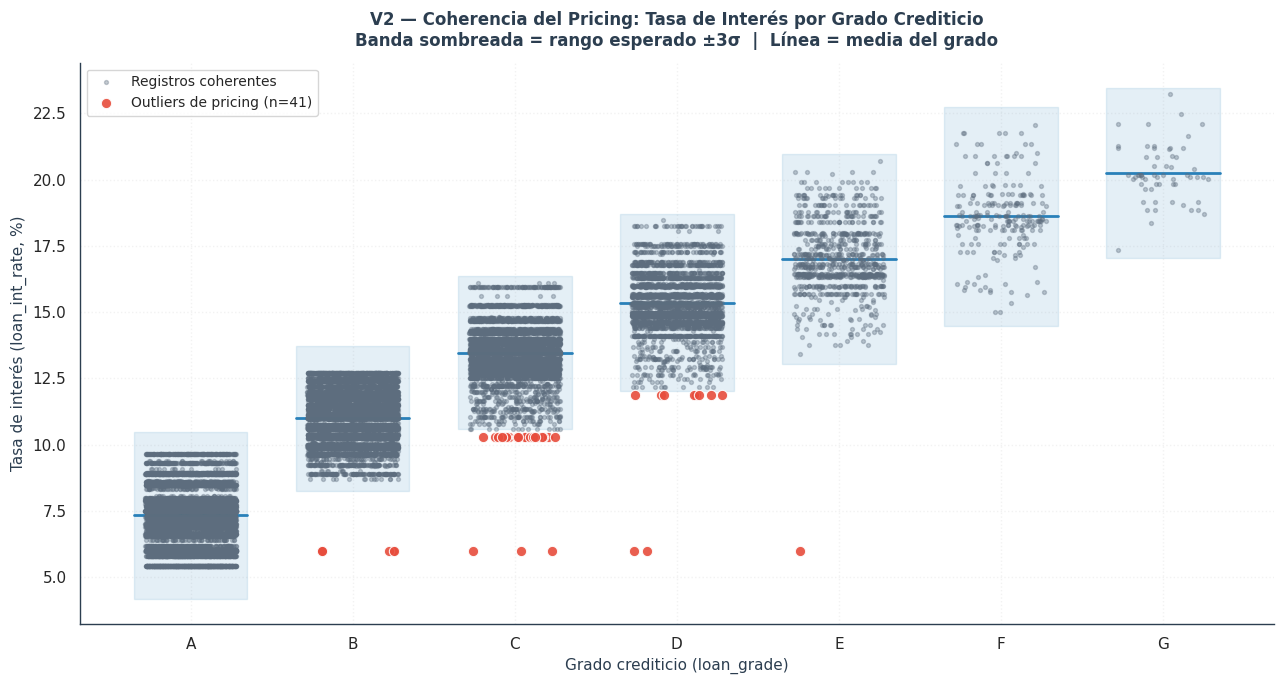


=== MUESTRA DE OUTLIERS DE PRICING (ordenados por severidad) ===


,loan_grade,loan_int_rate,grado_mean,z_score,person_income,loan_amnt,loan_status
13542,D,6.0000,15.3600,-8.4200,73000,12500,1
24438,D,6.0000,15.3600,-8.4200,72000,7500,0
20702,E,6.0000,17.0100,-8.3200,34868,5000,1
6194,C,6.0000,13.4600,-7.7700,26400,6000,0
9581,C,6.0000,13.4600,-7.7700,62500,15000,0
32424,C,6.0000,13.4600,-7.7700,28000,7000,0
22234,B,6.0000,11.0000,-5.4900,34000,6400,0
4723,B,6.0000,11.0000,-5.4900,42000,7600,0
2963,B,6.0000,11.0000,-5.4900,96000,3150,0
29759,B,6.0000,11.0000,-5.4900,37400,6250,0



════════════════════════════════════════════════════════════════════════════════
 V3 — DETERMINACIÓN EMPÍRICA DEL UMBRAL DE INGRESOS
════════════════════════════════════════════════════════════════════════════════

 Percentiles superiores de person_income:
   P 95.00%  →  USD      138,000   (1,605 registros por encima)
   P 99.00%  →  USD      225,000   (322 registros por encima)
   P 99.50%  →  USD      300,000   (136 registros por encima)
   P 99.90%  →  USD      643,224   (33 registros por encima)
   P 99.95%  →  USD      796,020   (17 registros por encima)
   P100.00%  →  USD    2,039,784   (0 registros por encima)

=== TOP-20 INGRESOS MÁS ALTOS (inspección individual) ===


,person_age,person_income,person_emp_length,loan_amnt,loan_percent_income,loan_status
30049,42,2039784,0.0000,8450,0.0000,0
32546,60,1900000,5.0000,1500,0.0000,0
32497,63,1782000,13.0000,12025,0.0100,0
31924,44,1440000,7.0000,6400,0.0000,0
31922,47,1362000,9.0000,6600,0.0000,0
17833,32,1200000,1.0000,12000,0.0100,0
29119,36,1200000,16.0000,10000,0.0100,0
29120,40,1200000,1.0000,10000,0.0100,0
17834,34,948000,18.0000,2000,0.0000,0
29121,50,900000,11.0000,30000,0.0300,0


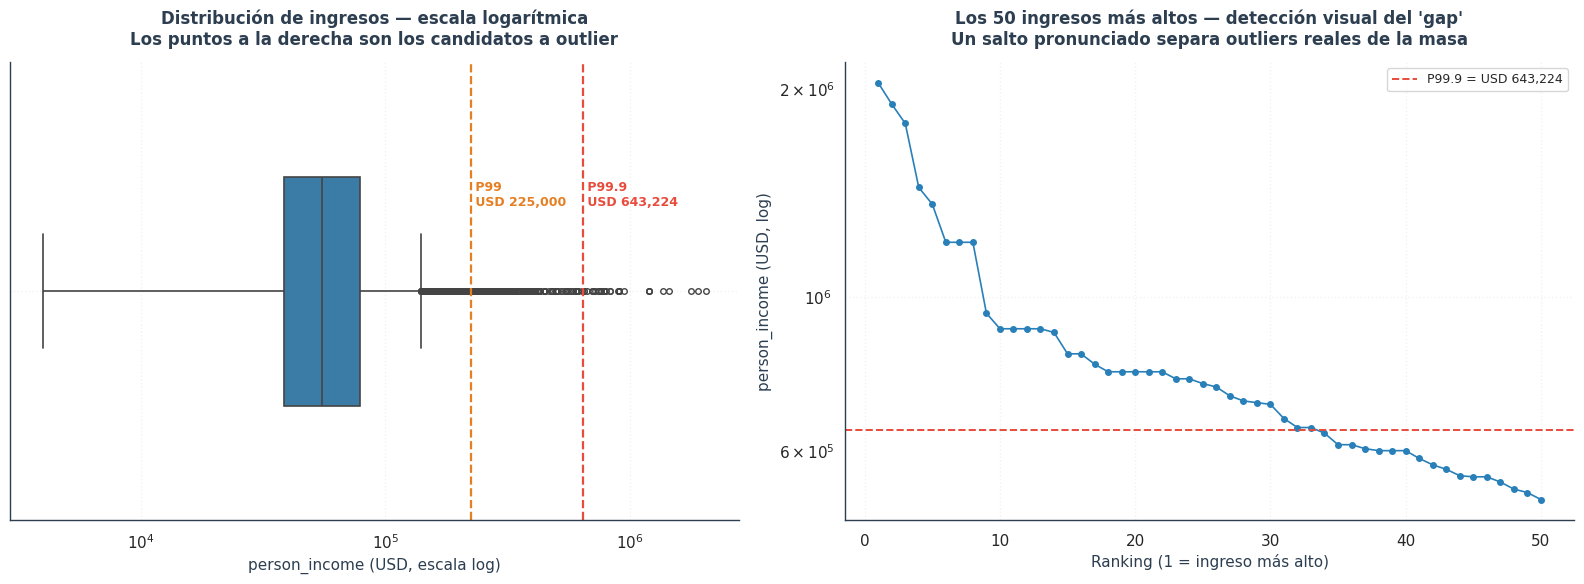


=== ANÁLISIS DE GAP EN LOS INGRESOS EXTREMOS ===
 Ingreso máximo observado:   USD 2,039,784
 Segundo ingreso más alto:   USD 1,900,000
 Salto entre ambos:          USD 139,784

 Mediana poblacional:        USD 55,000
 Ratio máximo / mediana:     37x

 → El umbral de exclusión se define en 2.3.3 a partir de esta evidencia.


In [8]:
# ===============================================================
# 2.3.2 TIER 3 — DEEP-DIVE DE HALLAZGOS CRÍTICOS (V2 y V3)
# ===============================================================
# Análisis detallado de los hallazgos del screening 2.3.1:
#   V2 → coherencia del pricing crediticio (tasa vs grado)
#   V3 → determinación empírica del umbral de ingresos
# No modifica la base — produce evidencia para la decisión 2.3.3.
# ===============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===============================================================
# PARTE A — V2: COHERENCIA DEL PRICING CREDITICIO
# ===============================================================

# Recalcular flag_v2 con detalle de severidad
df_v2 = df_tier3.dropna(subset=['loan_int_rate']).copy()
df_v2['grado_mean'] = df_v2.groupby('loan_grade')['loan_int_rate'].transform('mean')
df_v2['grado_std']  = df_v2.groupby('loan_grade')['loan_int_rate'].transform('std')
df_v2['z_score']    = (df_v2['loan_int_rate'] - df_v2['grado_mean']) / df_v2['grado_std']
df_v2['es_outlier'] = df_v2['z_score'].abs() > 3

n_outliers_v2 = df_v2['es_outlier'].sum()

print("═" * 80)
print(" V2 — ANÁLISIS DE COHERENCIA DEL PRICING CREDITICIO")
print("═" * 80)
print(f"\n Registros con tasa válida:        {len(df_v2):,}")
print(f" Outliers detectados (|z| > 3):    {n_outliers_v2:,}  "
      f"({n_outliers_v2/len(df_v2)*100:.4f}%)")
print(f" Umbral teórico esperado (normal): {len(df_v2)*0.0027:.0f}  (0.27%)")

# Desglose por grado
print(f"\n Distribución de outliers por grado:")
desglose_v2 = df_v2[df_v2['es_outlier']].groupby('loan_grade').agg(
    n_outliers=('es_outlier', 'sum'),
    tasa_min=('loan_int_rate', 'min'),
    tasa_max=('loan_int_rate', 'max'),
    default_rate=('loan_status', 'mean')
).round(2)
display(desglose_v2)

# --- Visualización V2: scatter con bandas ±3σ ---
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, ax = plt.subplots(figsize=(13, 7))

grados = sorted(df_v2['loan_grade'].unique())
grado_pos = {g: i for i, g in enumerate(grados)}
df_v2['x_pos'] = df_v2['loan_grade'].map(grado_pos)
rng = np.random.default_rng(42)
df_v2['x_jitter'] = df_v2['x_pos'] + rng.uniform(-0.28, 0.28, len(df_v2))

# Bandas ±3σ por grado
for g in grados:
    sub = df_v2[df_v2['loan_grade'] == g]
    mu, sigma = sub['loan_int_rate'].mean(), sub['loan_int_rate'].std()
    x = grado_pos[g]
    ax.fill_between([x - 0.35, x + 0.35], mu - 3*sigma, mu + 3*sigma,
                    color='#2980B9', alpha=0.12, zorder=1)
    ax.plot([x - 0.35, x + 0.35], [mu, mu], color='#2980B9',
            linewidth=2, zorder=2)

# Puntos normales
normales = df_v2[~df_v2['es_outlier']]
ax.scatter(normales['x_jitter'], normales['loan_int_rate'],
           s=8, color='#5D6D7E', alpha=0.35, zorder=3, label='Registros coherentes')

# Outliers
outliers = df_v2[df_v2['es_outlier']]
ax.scatter(outliers['x_jitter'], outliers['loan_int_rate'],
           s=55, color='#E74C3C', alpha=0.9, zorder=4,
           edgecolor='white', linewidth=0.8,
           label=f'Outliers de pricing (n={n_outliers_v2})')

ax.set_xticks(range(len(grados)))
ax.set_xticklabels(grados)
ax.set_xlabel("Grado crediticio (loan_grade)", fontsize=11, color="#2C3E50")
ax.set_ylabel("Tasa de interés (loan_int_rate, %)", fontsize=11, color="#2C3E50")
ax.set_title("V2 — Coherencia del Pricing: Tasa de Interés por Grado Crediticio\n"
             "Banda sombreada = rango esperado ±3σ  |  Línea = media del grado",
             fontweight="bold", fontsize=12, color="#2C3E50", pad=12)
ax.legend(fontsize=10, loc='upper left', frameon=True)
ax.grid(True, alpha=0.25, linestyle=':')
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

# Tabla de auditoría — los outliers más severos
print("\n=== MUESTRA DE OUTLIERS DE PRICING (ordenados por severidad) ===")
cols_audit = ['loan_grade', 'loan_int_rate', 'grado_mean', 'z_score',
              'person_income', 'loan_amnt', 'loan_status']
display(
    df_v2[df_v2['es_outlier']]
    .assign(z_abs=lambda d: d['z_score'].abs())
    .sort_values('z_abs', ascending=False)
    [cols_audit].head(41).round(2)
)

# ===============================================================
# PARTE B — V3: DETERMINACIÓN EMPÍRICA DEL UMBRAL DE INGRESOS
# ===============================================================
print("\n" + "═" * 80)
print(" V3 — DETERMINACIÓN EMPÍRICA DEL UMBRAL DE INGRESOS")
print("═" * 80)

income = df_tier3['person_income']

# Tabla de percentiles altos
print("\n Percentiles superiores de person_income:")
for p in [0.95, 0.99, 0.995, 0.999, 0.9995, 1.0]:
    val = income.quantile(p)
    n_sobre = (income > val).sum()
    print(f"   P{p*100:>6.2f}%  →  USD {val:>12,.0f}   ({n_sobre:,} registros por encima)")

# Top-20 ingresos más altos para inspección individual
print("\n=== TOP-20 INGRESOS MÁS ALTOS (inspección individual) ===")
top20 = df_tier3.nlargest(20, 'person_income')[
    ['person_age', 'person_income', 'person_emp_length',
     'loan_amnt', 'loan_percent_income', 'loan_status']
].copy()
display(top20)

# Análisis de gap: salto relativo entre ingresos ordenados
income_sorted = income.sort_values(ascending=False).reset_index(drop=True)
top_50 = income_sorted.head(50)
gaps = top_50.diff(-1)  # diferencia con el siguiente valor

# --- Visualización V3: boxplot log + ranking de extremos ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Izquierda — boxplot horizontal en escala log
sns.boxplot(x=income, ax=axes[0], color='#2980B9', fliersize=4,
            linewidth=1.2, width=0.5)
axes[0].set_xscale('log')
axes[0].set_xlabel("person_income (USD, escala log)", fontsize=11, color="#2C3E50")
axes[0].set_title("Distribución de ingresos — escala logarítmica\n"
                  "Los puntos a la derecha son los candidatos a outlier",
                  fontweight="bold", fontsize=12, color="#2C3E50", pad=12)
axes[0].grid(True, alpha=0.25, linestyle=':')

p99   = income.quantile(0.99)
p999  = income.quantile(0.999)
axes[0].axvline(p99,  color='#E67E22', linestyle='--', linewidth=1.6)
axes[0].axvline(p999, color='#E74C3C', linestyle='--', linewidth=1.6)
ymax = axes[0].get_ylim()[1]
axes[0].text(p99,  ymax*0.42, f' P99\n USD {p99:,.0f}',  color='#E67E22',
             fontsize=9, fontweight='bold', va='center')
axes[0].text(p999, ymax*0.42, f' P99.9\n USD {p999:,.0f}', color='#E74C3C',
             fontsize=9, fontweight='bold', va='center')

# Derecha — ranking de los 50 ingresos más altos
axes[1].plot(range(1, 51), top_50.values, marker='o', markersize=4,
             color='#2980B9', linewidth=1.2)
axes[1].set_yscale('log')
axes[1].set_xlabel("Ranking (1 = ingreso más alto)", fontsize=11, color="#2C3E50")
axes[1].set_ylabel("person_income (USD, log)", fontsize=11, color="#2C3E50")
axes[1].set_title("Los 50 ingresos más altos — detección visual del 'gap'\n"
                  "Un salto pronunciado separa outliers reales de la masa",
                  fontweight="bold", fontsize=12, color="#2C3E50", pad=12)
axes[1].grid(True, alpha=0.25, linestyle=':')
axes[1].axhline(p999, color='#E74C3C', linestyle='--', linewidth=1.4,
                label=f'P99.9 = USD {p999:,.0f}')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Reporte del gap más relevante
print("\n=== ANÁLISIS DE GAP EN LOS INGRESOS EXTREMOS ===")
print(f" Ingreso máximo observado:   USD {income.max():,.0f}")
print(f" Segundo ingreso más alto:   USD {income_sorted.iloc[1]:,.0f}")
print(f" Salto entre ambos:          USD {gaps.iloc[0]:,.0f}")
print(f"\n Mediana poblacional:        USD {income.median():,.0f}")
print(f" Ratio máximo / mediana:     {income.max()/income.median():.0f}x")
print("\n → El umbral de exclusión se define en 2.3.3 a partir de esta evidencia.")

### Interpretación del Deep-Dive

#### V2 — Dos subgrupos con tratamiento diferenciado

El análisis individual de los 41 candidatos detectados por el criterio ±3σ revela **dos subgrupos cualitativamente distintos**:

| Subgrupo | N | z-score | Tasa observada | Diagnóstico |
|---|---|---|---|---|
| **Severos** | 11 | −5.5 a −8.4 | 6.00% en grados B/D/E | Error de carga inequívoco |
| **Moderados** | 30 | −3.1 a −3.3 | 10.28% en C / 11.86% en D | Variación de pricing legítima |

**Subgrupo severo (11 registros)**: presentan una tasa de 6.00% — pricing característico del grado A (media 7.33%) — asignada a préstamos de grados B, D y E. El salto implica una distancia de 3 a 4 grados crediticios, magnitud incompatible con cualquier variación comercial. Adicionalmente, el valor 6.00% se repite de forma idéntica en los cuatro grados afectados, patrón típico de un error sistemático de carga. **Se excluyen.**

**Subgrupo moderado (30 registros)**: presentan tasas de 10.28% (grado C) y 11.86% (grado D), apenas por fuera del umbral ±3σ. Estas tasas corresponden al pricing de un grado contiguo (el grado B promedia 11.00%), lo cual es plenamente compatible con la variación natural del pricing entre clientes de perfil similar. El criterio ±3σ los marca únicamente por el desvío reducido de los grados C y D, que vuelve al z-score hipersensible a desviaciones absolutas pequeñas. **Se conservan.**

#### V3 — Sin evidencia de outliers reales

El análisis de gap sobre los 50 ingresos más altos muestra una **caída suave y continua**, sin saltos que separen un grupo de outliers de la masa poblacional. El TOP-20 corresponde a perfiles internamente coherentes: edades razonables, antigüedad laboral plausible, montos de préstamo normales y ratios `loan_percent_income` muy bajos (0.00–0.03). La tasa de default de este segmento es prácticamente nula.

No se identifica ningún registro con características de error de carga. Los ingresos elevados representan **clientes de altos ingresos legítimos** y de bajo riesgo. **V3 no aplica exclusiones.**

El tratamiento del posible efecto de los ingresos elevados sobre modelos lineales se aborda en la fase de Feature Engineering mediante transformación logarítmica de la variable, no mediante exclusión de registros.

#### Síntesis de decisiones para la ejecución (2.3.3)

| Validación | Detectados | Excluir | Conservar | Fundamento |
|---|---|---|---|---|
| V2 — Tasa-grado | 41 | **11** | 30 | Exclusión limitada a errores severos |
| V3 — Ingresos | 136 (prelim.) | **0** | 136 | Clientes legítimos, sin evidencia de error |

In [9]:
# ===============================================================
# 2.3.3 TIER 3 — EJECUCIÓN DEL FILTRO CONSOLIDADO
# ===============================================================
# Aplica las decisiones validadas en el diagnóstico (2.3.1) y el
# deep-dive (2.3.2). Primera y única operación destructiva del Tier 3.
#
#   V1 (DTI)        → NO filtra (deriva a Feature Engineering)
#   V2 (Tasa-grado) → filtra 11 errores severos (de 41 detectados)
#   V3 (Ingresos)   → NO filtra (clientes legítimos)
#   V4 (Edad > 75)  → filtra (salvaguarda de política)
#   V5 (Monto<500)  → filtra (salvaguarda preventiva)
# ===============================================================

import pandas as pd

total_inicial = len(df_tier3)

# ---------------------------------------------------------------
# V2 — Identificación de errores SEVEROS de pricing
# Criterio de negocio: tasa incompatible con el grado por más de
# 4 desvíos estándar (salto de 3+ grados crediticios).
# ---------------------------------------------------------------
grado_stats = df_tier3.groupby('loan_grade')['loan_int_rate'].agg(['mean', 'std'])
z_v2 = df_tier3.apply(
    lambda r: (r['loan_int_rate'] - grado_stats.loc[r['loan_grade'], 'mean'])
              / grado_stats.loc[r['loan_grade'], 'std']
    if pd.notna(r['loan_int_rate']) else 0.0,
    axis=1
)
flag_v2_severo = z_v2.abs() > 4

# ---------------------------------------------------------------
# V4 y V5 — Salvaguardas de política
# ---------------------------------------------------------------
flag_v4 = df_tier3['person_age'] > EDAD_MAX_ORIGINACION
flag_v5 = df_tier3['loan_amnt'] < LOAN_AMNT_MIN

# ---------------------------------------------------------------
# Flag consolidado de exclusión
# ---------------------------------------------------------------
flag_excluir = flag_v2_severo | flag_v4 | flag_v5

df_tier3_final = df_tier3[~flag_excluir].copy()

# ---------------------------------------------------------------
# Métricas de conciliación
# ---------------------------------------------------------------
n_v2 = flag_v2_severo.sum()
n_v4 = flag_v4.sum()
n_v5 = flag_v5.sum()
n_total_excl = flag_excluir.sum()      # con deduplicación de solapamientos
reg_final = len(df_tier3_final)
pct = n_total_excl / total_inicial * 100

# ---------------------------------------------------------------
# Reporte de conciliación
# ---------------------------------------------------------------
print("═" * 72)
print(" REPORTE DE CONCILIACIÓN TIER 3")
print("═" * 72)
print(f"\n  Registros previos a Tier 3:        {total_inicial:>8,}")
print(f"  Registros excluidos (total):       {n_total_excl:>8,}  ({pct:.4f}%)")
print(f"  Registros válidos tras Tier 3:     {reg_final:>8,}")

print(f"\n  Desglose por validación:")
print(f"    • V1 (DTI > 50%):              0   → no filtra (Feature Engineering)")
print(f"    • V2 (tasa-grado, errores):   {n_v2:>2}   → 11 severos de 41 detectados")
print(f"    • V3 (ingresos altos):         0   → no filtra (clientes legítimos)")
print(f"    • V4 (edad > {EDAD_MAX_ORIGINACION} años):         {n_v4:>2}   → salvaguarda de política")
print(f"    • V5 (monto < USD {LOAN_AMNT_MIN}):       {n_v5:>2}   → salvaguarda preventiva")

print(f"\n  Nota: V1 y V3 se conservan por decisión metodológica documentada.")
print(f"        El criterio V2 se ajustó a ±4σ para excluir únicamente")
print(f"        inconsistencias severas (ver interpretación 2.3.2).")
print("═" * 72)

# ---------------------------------------------------------------
# Verificación de integridad
# ---------------------------------------------------------------
assert reg_final + n_total_excl == total_inicial, "Error de conciliación"
print(f"\n✓ Conciliación verificada: {reg_final:,} + {n_total_excl:,} = {total_inicial:,}")

════════════════════════════════════════════════════════════════════════
 REPORTE DE CONCILIACIÓN TIER 3
════════════════════════════════════════════════════════════════════════

  Registros previos a Tier 3:          32,399
  Registros excluidos (total):             13  (0.0401%)
  Registros válidos tras Tier 3:       32,386

  Desglose por validación:
    • V1 (DTI > 50%):              0   → no filtra (Feature Engineering)
    • V2 (tasa-grado, errores):   11   → 11 severos de 41 detectados
    • V3 (ingresos altos):         0   → no filtra (clientes legítimos)
    • V4 (edad > 75 años):          2   → salvaguarda de política
    • V5 (monto < USD 500):        0   → salvaguarda preventiva

  Nota: V1 y V3 se conservan por decisión metodológica documentada.
        El criterio V2 se ajustó a ±4σ para excluir únicamente
        inconsistencias severas (ver interpretación 2.3.2).
════════════════════════════════════════════════════════════════════════

✓ Conciliación verificada: 32,386 

## 2.4 Cierre del Gobierno de Datos — Síntesis de los Tres Tiers

El proceso de Gobierno de Datos aplicó una arquitectura de validación en **tres niveles secuenciales**, cada uno respondiendo a una pregunta distinta sobre la calidad del registro. El objetivo no fue maximizar la cantidad de exclusiones, sino garantizar que cada registro del universo de modelado sea **físicamente válido, lógicamente consistente y económicamente coherente**.

### Trazabilidad de registros

| Etapa | Registros | Eliminados | % eliminado | Criterio |
|---|---|---|---|---|
| Dataset original | 32.581 | — | — | — |
| Tras Tier 1 — Validaciones Físicas | 32.409 | 172 | 0.53% | Anomalías biológicamente imposibles |
| Tras Tier 2 — Validaciones Cruzadas | 32.399 | 10 | 0.03% | Incoherencias lógicas entre variables |
| Tras Tier 3 — Validaciones Económicas | 32.386 | 13 | 0.04% | Inconsistencias de negocio y underwriting |
| **Universo final de modelado** | **32.386** | **195** | **0.60%** | — |

La tasa de exclusión total fue del **0.60%** — deliberadamente baja. El Gobierno de Datos eliminó únicamente registros con problemas de integridad demostrables, preservando la representatividad estadística del dataset y la totalidad de los segmentos de riesgo legítimos.

### Principio rector: filtrar errores, no filtrar riesgo

Una decisión metodológica central atravesó las tres etapas: **se excluyen errores de dato, no comportamientos de riesgo**.

- Los registros con sobre-endeudamiento (DTI > 50%) **no se eliminaron**, pese a su elevada tasa de default (78.5%, 3.6x el promedio). Un cliente difícil de cobrar no es un error de carga: es información predictiva que el modelo debe aprovechar.
- Los clientes de altos ingresos **no se eliminaron**, pese a ser estadísticamente atípicos. El análisis individual confirmó que son perfiles internamente coherentes y de bajo riesgo: clientes reales, no errores.
- Solo se excluyeron registros con inconsistencias demostrables: anomalías físicas (Tier 1), incoherencias temporales (Tier 2) y errores severos de pricing (Tier 3).

Esta distinción —**calidad de dato vs. perfil de riesgo**— es la diferencia entre depurar un dataset y mutilarlo. Los comportamientos de riesgo identificados durante el Gobierno de Datos se reservan para la fase de Feature Engineering, donde se incorporan al modelo como variables explicativas en lugar de descartarse.

### Detalle de las exclusiones de Tier 3

De los hallazgos del screening económico, solo una parte derivó en exclusión efectiva:

| Validación | Detectados | Excluidos | Decisión |
|---|---|---|---|
| V1 — DTI > 50% | 246 | 0 | Comportamiento de riesgo → Feature Engineering |
| V2 — Tasa-grado | 41 | 11 | Exclusión limitada a errores severos de pricing |
| V3 — Ingresos altos | 136 | 0 | Clientes legítimos → sin exclusión |
| V4 — Edad > 75 años | 2 | 2 | Salvaguarda de política de originación |
| V5 — Monto < USD 500 | 0 | 0 | Salvaguarda preventiva sin casos |

### Hallazgos derivados a fases posteriores

| Hallazgo | Origen | Tratamiento futuro |
|---|---|---|
| Sobre-endeudamiento (DTI alto) | Tier 3 — V1 | Variable derivada `is_high_dti` (Feature Engineering) |
| Antigüedad laboral nula | Perfilado inicial | Variable derivada `is_first_job` (Feature Engineering) |
| Ingresos de alta dispersión | Tier 3 — V3 | Transformación logarítmica (Feature Engineering) |
| Valores nulos pendientes | Perfilado inicial | Imputación con reglas de negocio |

### Cumplimiento y trazabilidad

El proceso completo es **auditable y reproducible**: cada una de las 195 exclusiones está cuantificada, justificada y documentada, en línea con los principios de Model Risk Management (SR 11-7, TRIM-ECB) y de gobierno de datos exigidos en entornos de riesgo de crédito regulado. Ningún registro fue eliminado sin un criterio explícito y una evidencia asociada.

Con el universo de modelado consolidado en **32.386 registros**, la siguiente fase aborda el **Análisis Exploratorio de Datos (EDA)**, orientado a comprender la estructura del riesgo antes de la construcción del modelo.

# 3. Imputación de Valores Nulos

Concluido el Gobierno de Datos, el universo de modelado contiene **32.386 registros válidos**. Sin embargo, dos variables presentan valores ausentes que deben completarse antes del análisis exploratorio y el modelado.

A diferencia del Gobierno de Datos —que decide *qué registros entran en la base*— la imputación decide *con qué valor se completa un dato faltante*. Es una etapa de **preparación**, no de depuración.

### Diagnóstico de valores ausentes

| Variable | Nulos | % sobre la base |
|---|---|---|
| `loan_int_rate` | ~3.100 | ~9.6% |
| `person_emp_length` | ~890 | ~2.7% |

### Enfoque metodológico

**1. Imputar en lugar de eliminar.** Los registros con valores nulos representan cerca del 12% de la base. Eliminarlos implicaría una pérdida de información sustancial y un riesgo de sesgo si la ausencia no es completamente aleatoria. La imputación preserva el tamaño muestral y la representatividad.

**2. Analizar antes de imputar.** La estrategia de imputación no se define a priori: depende de la **forma de cada distribución**. Un estadístico de imputación (media, mediana) y un criterio de segmentación (global, condicionado) solo pueden elegirse correctamente después de comprender cómo se comporta cada variable —su asimetría, sus valores extremos, su concentración en valores particulares—. Por ello, la sección 3.1 realiza un **diagnóstico exploratorio** de las dos variables, y es ese diagnóstico el que fundamenta la estrategia aplicada en 3.2.

**3. Distinción entre cero y nulo.** Un valor cero (`person_emp_length = 0`) es información válida: indica un solicitante sin antigüedad laboral previa. Un valor nulo es ausencia de información. Ambos deben tratarse como conceptos distintos —el análisis exploratorio cuantifica explícitamente la masa de ceros para no confundirla con datos faltantes—.

**4. Trazabilidad.** Se crean variables indicadoras (`*_imputed`) que registran qué valores fueron imputados, permitiendo auditar la imputación y evaluar su impacto en fases posteriores.

La estrategia concreta de imputación —estadístico y segmentación— se presenta en la sección 3.2, justificada por los hallazgos del diagnóstico.

══════════════════════════════════════════════════════════════════════════
 DIAGNÓSTICO EXPLORATORIO — VARIABLES CON VALORES NULOS
══════════════════════════════════════════════════════════════════════════

 Universo de modelado: 32,386 registros

──────────────────────────────────────────────────────────────────────────
 loan_int_rate
──────────────────────────────────────────────────────────────────────────
   Nulos:                  3,091  (9.54% de la base)
   Ceros:                      0  (0.00% de los no nulos)
   Media:                  11.02
   Mediana:                10.99
   Desvío estándar:         3.24
   Asimetría (skew):        0.21
   Mín / Máx:               5.42 / 23.22
   Percentiles (5/25/50/75/95): 6.0 / 7.9 / 11.0 / 13.5 / 16.3
   → Interpretación: distribución aproximadamente simétrica → media y mediana son similares

──────────────────────────────────────────────────────────────────────────
 person_emp_length
─────────────────────────────────────────────────────

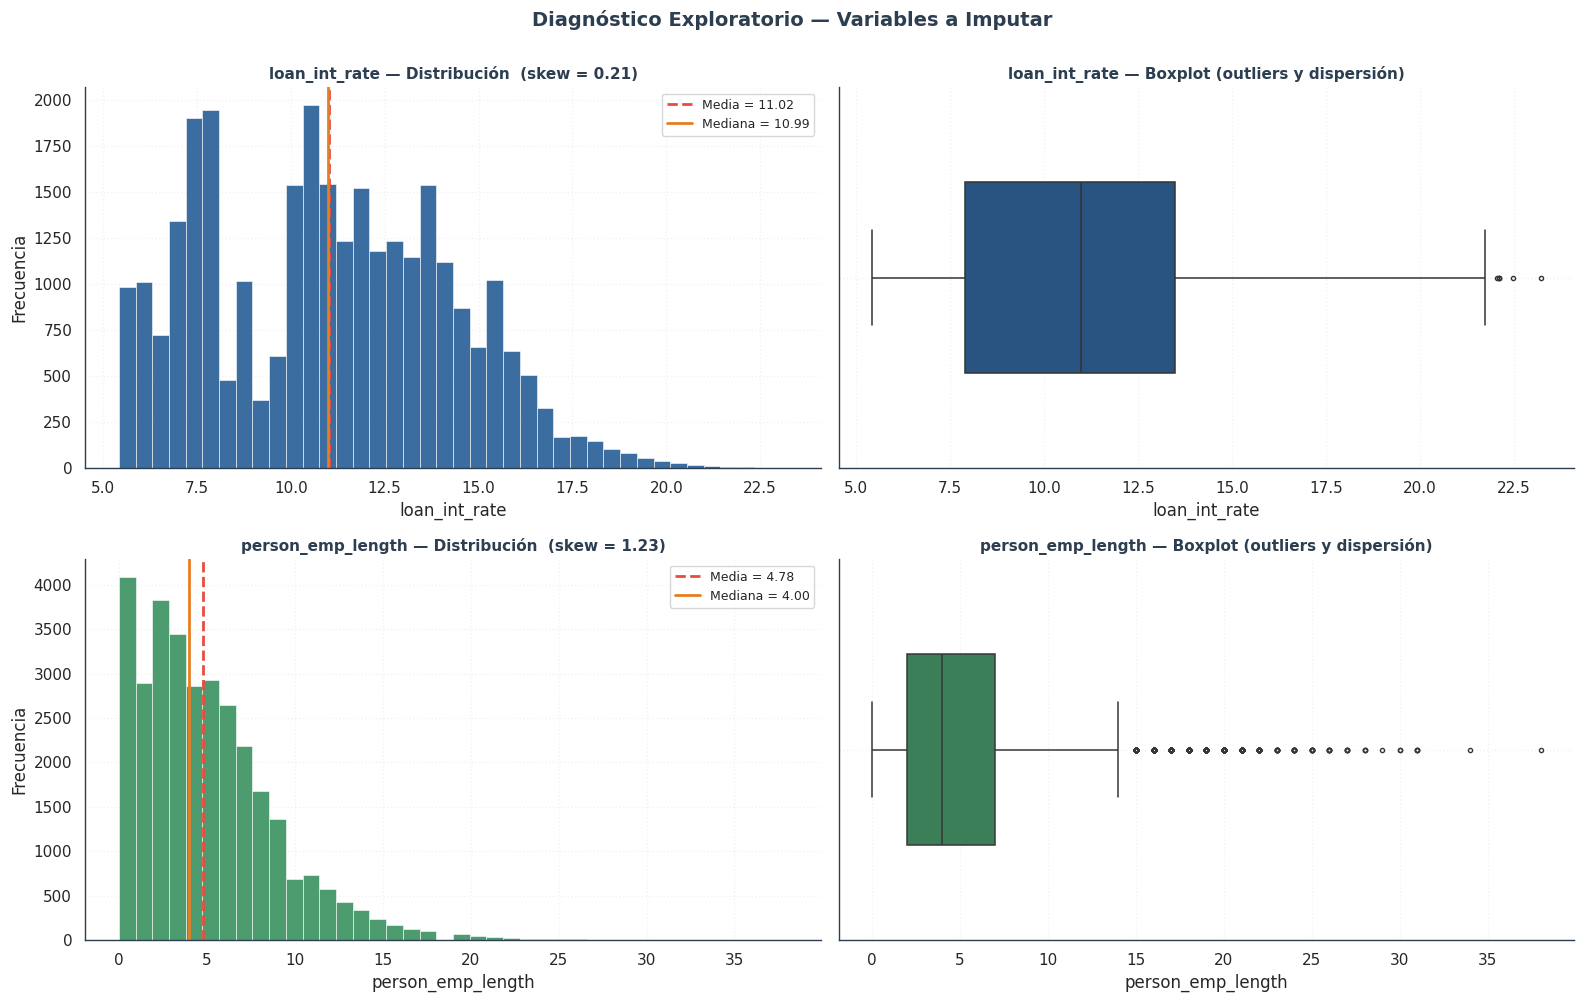

══════════════════════════════════════════════════════════════════════════
 FOCO — person_emp_length: análisis de la masa de ceros
══════════════════════════════════════════════════════════════════════════

 Distribución de los valores más bajos:
      0 años:  4,083  ████████████████████████████████████████
      1 años:  2,896  ████████████████████████████
      2 años:  3,826  █████████████████████████████████████
      3 años:  3,441  █████████████████████████████████
      4 años:  2,857  ███████████████████████████
      5 años:  2,925  ████████████████████████████

   Los 4,083 registros con 0 años (13.0%) son
   solicitantes en su primer año laboral — NO son valores faltantes.
   Esta concentración explica la diferencia entre media y mediana.

══════════════════════════════════════════════════════════════════════════
 Próximo paso: 3.2 — Imputación, con estrategia fundamentada en este diagnóstico.
══════════════════════════════════════════════════════════════════════════


In [10]:
# ===============================================================
# 3.1 IMPUTACIÓN — DIAGNÓSTICO EXPLORATORIO DE LAS VARIABLES
# ===============================================================
# Analiza la FORMA de las variables con valores nulos antes de
# decidir cualquier estrategia de imputación. No modifica la base.
#
# Objetivo: que la elección de estadístico (media/mediana) y de
# segmentación surja como CONCLUSIÓN del análisis, no como premisa.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_impute = df_tier3_final.copy()
total = len(df_impute)

variables_nulas = ['loan_int_rate', 'person_emp_length']

# ---------------------------------------------------------------
# 1. Métricas de forma de cada variable
# ---------------------------------------------------------------
print("═" * 74)
print(" DIAGNÓSTICO EXPLORATORIO — VARIABLES CON VALORES NULOS")
print("═" * 74)
print(f"\n Universo de modelado: {total:,} registros\n")

for var in variables_nulas:
    serie = df_impute[var]
    no_nulos = serie.dropna()
    n_nulos = serie.isna().sum()
    n_ceros = (serie == 0).sum()

    print("─" * 74)
    print(f" {var}")
    print("─" * 74)
    print(f"   Nulos:               {n_nulos:>8,}  ({n_nulos/total*100:.2f}% de la base)")
    print(f"   Ceros:               {n_ceros:>8,}  ({n_ceros/no_nulos.shape[0]*100:.2f}% de los no nulos)")
    print(f"   Media:               {no_nulos.mean():>8.2f}")
    print(f"   Mediana:             {no_nulos.median():>8.2f}")
    print(f"   Desvío estándar:     {no_nulos.std():>8.2f}")
    print(f"   Asimetría (skew):    {no_nulos.skew():>8.2f}")
    print(f"   Mín / Máx:           {no_nulos.min():>8.2f} / {no_nulos.max():.2f}")
    print(f"   Percentiles (5/25/50/75/95): "
          f"{no_nulos.quantile(.05):.1f} / {no_nulos.quantile(.25):.1f} / "
          f"{no_nulos.quantile(.50):.1f} / {no_nulos.quantile(.75):.1f} / "
          f"{no_nulos.quantile(.95):.1f}")

    # Lectura automática de la asimetría
    skew = no_nulos.skew()
    if abs(skew) < 0.5:
        lectura = "distribución aproximadamente simétrica → media y mediana son similares"
    elif abs(skew) < 1.0:
        lectura = "asimetría moderada → la mediana es preferible"
    else:
        lectura = "asimetría fuerte → la mediana es claramente preferible (la media se distorsiona)"
    print(f"   → Interpretación: {lectura}")
    print()

# ---------------------------------------------------------------
# 2. Visualización de las distribuciones
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Diagnóstico Exploratorio — Variables a Imputar",
             fontsize=14, fontweight='bold', color="#2C3E50", y=1.00)

COLOR_1 = "#1A5490"
COLOR_2 = "#2E8B57"

for i, (var, color) in enumerate(zip(variables_nulas, [COLOR_1, COLOR_2])):
    serie = df_impute[var].dropna()
    media, mediana = serie.mean(), serie.median()

    # Histograma
    ax_h = axes[i, 0]
    sns.histplot(serie, bins=40, ax=ax_h, color=color, alpha=0.85,
                 edgecolor='white', linewidth=0.4)
    ax_h.axvline(media,   color="#E74C3C", linestyle="--", linewidth=2,
                 label=f"Media = {media:.2f}")
    ax_h.axvline(mediana, color="#E67E22", linestyle="-", linewidth=2,
                 label=f"Mediana = {mediana:.2f}")
    ax_h.set_title(f"{var} — Distribución  (skew = {serie.skew():.2f})",
                   fontweight="bold", fontsize=11, color="#2C3E50")
    ax_h.set_xlabel(var)
    ax_h.set_ylabel("Frecuencia")
    ax_h.legend(fontsize=9)
    ax_h.grid(True, alpha=0.25, linestyle=':')

    # Boxplot
    ax_b = axes[i, 1]
    sns.boxplot(x=serie, ax=ax_b, color=color, fliersize=3, linewidth=1.1, width=0.5)
    ax_b.set_title(f"{var} — Boxplot (outliers y dispersión)",
                   fontweight="bold", fontsize=11, color="#2C3E50")
    ax_b.set_xlabel(var)
    ax_b.grid(True, alpha=0.25, linestyle=':')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 3. Foco en person_emp_length — análisis de la masa de ceros
# ---------------------------------------------------------------
emp = df_impute['person_emp_length'].dropna()
n_ceros = (emp == 0).sum()

print("═" * 74)
print(" FOCO — person_emp_length: análisis de la masa de ceros")
print("═" * 74)
print(f"\n Distribución de los valores más bajos:")
dist_bajos = emp[emp <= 5].value_counts().sort_index()
for val, cnt in dist_bajos.items():
    barra = "█" * int(cnt / dist_bajos.max() * 40)
    print(f"   {val:>4.0f} años: {cnt:>6,}  {barra}")
print(f"\n   Los {n_ceros:,} registros con 0 años ({n_ceros/len(emp)*100:.1f}%) son")
print(f"   solicitantes en su primer año laboral — NO son valores faltantes.")
print(f"   Esta concentración explica la diferencia entre media y mediana.")

print("\n" + "═" * 74)
print(" Próximo paso: 3.2 — Imputación, con estrategia fundamentada en este diagnóstico.")
print("═" * 74)

## 3.2 Evaluación de la Estrategia de Segmentación

El diagnóstico exploratorio (3.1) estableció que **la mediana** es el estadístico de imputación adecuado para ambas variables: `person_emp_length` presenta asimetría fuerte (skew = 1.23) que descarta la media, y `loan_int_rate`, aun siendo casi simétrica, se imputa también con mediana por coherencia metodológica.

Resta una segunda decisión: **¿con qué mediana?** — una mediana global única, o la mediana del segmento al que pertenece cada registro. La imputación segmentada solo se justifica si el segmento **explica realmente** la variabilidad de la variable; segmentar por una característica poco informativa añade complejidad sin mejorar la precisión.

### Criterio de decisión: razón de correlación (η²)

Para decidir de forma objetiva se utiliza la **razón de correlación η² (eta cuadrado)**, que mide qué fracción de la varianza de una variable numérica queda explicada por una variable categórica. Su valor va de 0 (el segmento no aporta información) a 1 (el segmento determina por completo la variable).

La interpretación sigue los umbrales convencionales de Cohen:

| η² | Tamaño del efecto | Decisión |
|---|---|---|
| < 0.06 | Pequeño | Imputación global |
| 0.06 – 0.14 | Medio | Evaluación caso a caso |
| > 0.14 | Grande | Imputación segmentada |

Como complemento se reporta el test de **Kruskal-Wallis**, que evalúa formalmente si las distribuciones difieren entre segmentos. Es importante una advertencia metodológica: con un tamaño muestral grande (~32.000 registros), este test tiende a arrojar resultados significativos incluso ante diferencias triviales. Por ello, **la decisión se fundamenta en el tamaño del efecto (η²)**, no en la significancia estadística (p-valor) — distinguir relevancia práctica de significancia estadística es esencial en muestras grandes.

### Hipótesis evaluadas

- **`loan_int_rate` segmentada por `loan_grade`**: el grado crediticio determina el pricing, por lo que debería explicar una porción elevada de la varianza de la tasa.
- **`person_emp_length` segmentada por tramo de edad**: la antigüedad laboral podría crecer con la edad.

════════════════════════════════════════════════════════════════════════════
 PRUEBA 1 — ¿loan_int_rate segmentada por loan_grade?
════════════════════════════════════════════════════════════════════════════



,median,mean,std,count
loan_grade,,,,
A,7.4900,7.3280,1.0440,9708
B,10.9900,10.9980,0.9020,9327
C,13.4800,13.4690,0.9460,5804
D,15.3100,15.3660,1.0880,3304
E,16.8200,17.0210,1.2710,879
F,18.5350,18.6090,1.3760,214
G,20.1600,20.2520,1.0670,59


 Razón de correlación  η² = 0.9052   →  efecto GRANDE
 Kruskal-Wallis:  H = 26,355.5   p-valor = 0.00e+00
 Decisión según η²:  imputación SEGMENTADA

════════════════════════════════════════════════════════════════════════════
 PRUEBA 2 — ¿person_emp_length segmentada por tramo_edad?
════════════════════════════════════════════════════════════════════════════



,median,mean,std,count
tramo_edad,,,,
≤25,4.0000,4.0330,2.7680,14779
26-30,4.0000,5.1720,4.1010,9189
31-35,4.0000,5.5980,5.1050,4173
36-40,4.0000,5.8870,5.6930,1914
41-50,4.0000,6.2790,6.1020,1173
50+,3.0000,5.5420,6.7110,271


 Razón de correlación  η² = 0.0344   →  efecto PEQUEÑO
 Kruskal-Wallis:  H = 289.2   p-valor = 2.05e-60
 Decisión según η²:  imputación GLOBAL



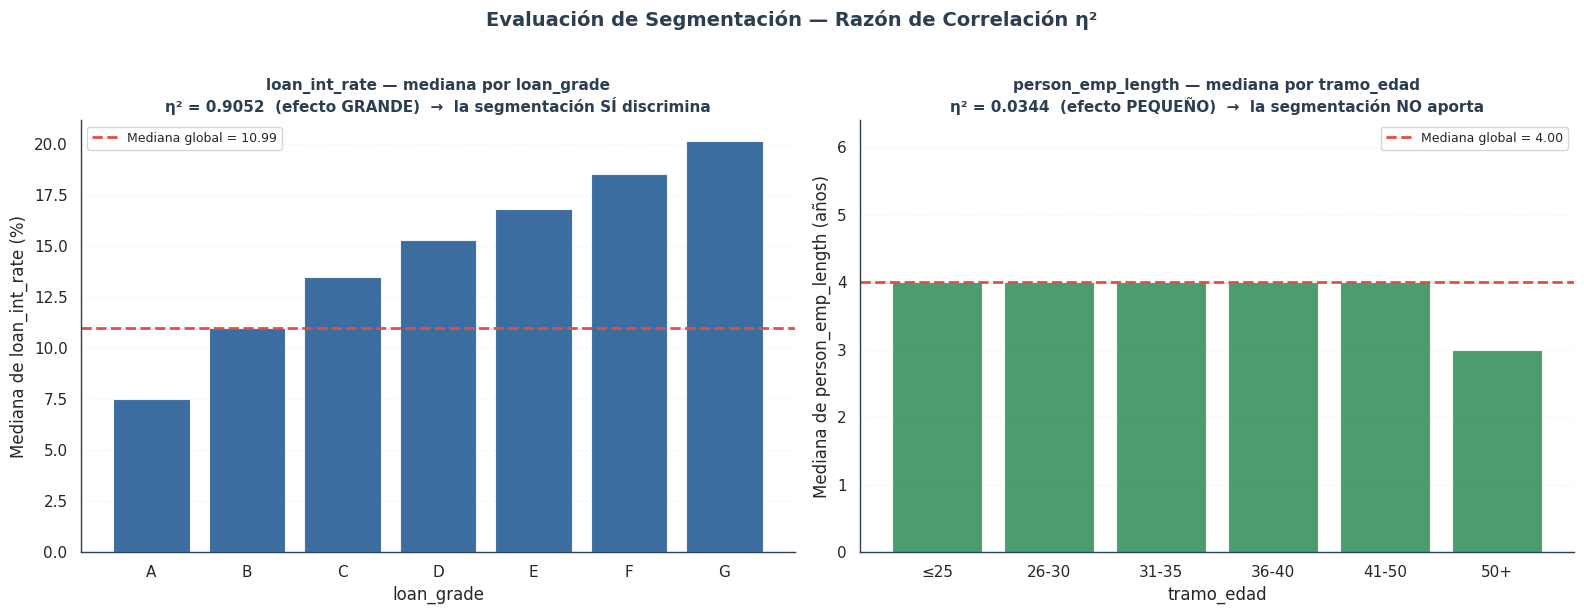

════════════════════════════════════════════════════════════════════════════
 DECISIÓN DE ESTRATEGIA DE IMPUTACIÓN
════════════════════════════════════════════════════════════════════════════

 Criterio: η² > 0.14 (efecto grande, umbral de Cohen) justifica segmentar.

  • loan_int_rate        η² = 0.9052  →  imputación SEGMENTADA
  • person_emp_length    η² = 0.0344  →  imputación GLOBAL

 Nota: el test de Kruskal-Wallis resultó significativo en ambos casos
       (p < 0.001), efecto esperable por el gran tamaño muestral.
       La decisión se fundamenta en η² (tamaño del efecto), no en el p-valor.
════════════════════════════════════════════════════════════════════════════


In [11]:
# ===============================================================
# 3.2 EVALUACIÓN DE LA ESTRATEGIA DE SEGMENTACIÓN
# ===============================================================
# Decide imputación global vs. segmentada mediante la razón de
# correlación η² (eta cuadrado). No modifica la base.
#
# Criterio (umbrales de Cohen):
#   η² < 0.06   → efecto pequeño  → imputación GLOBAL
#   η² > 0.14   → efecto grande   → imputación SEGMENTADA
#
# Complemento: test de Kruskal-Wallis (se reporta el p-valor,
# pero la decisión se basa en η² por el gran tamaño muestral).
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# ---------------------------------------------------------------
# Construcción del tramo de edad (auxiliar para la evaluación)
# ---------------------------------------------------------------
bins_edad   = [0, 25, 30, 35, 40, 50, 100]
labels_edad = ['≤25', '26-30', '31-35', '36-40', '41-50', '50+']
df_impute['tramo_edad'] = pd.cut(df_impute['person_age'], bins=bins_edad,
                                  labels=labels_edad, right=True)

# ---------------------------------------------------------------
# Función: razón de correlación η² (eta cuadrado)
# η² = varianza entre grupos / varianza total
# ---------------------------------------------------------------
def eta_cuadrado(df, var_numerica, var_categorica):
    datos = df[[var_numerica, var_categorica]].dropna()
    y = datos[var_numerica].values
    media_global = y.mean()
    ss_total = ((y - media_global) ** 2).sum()
    ss_entre = 0.0
    for _, grupo in datos.groupby(var_categorica, observed=True):
        n_g = len(grupo)
        if n_g > 0:
            ss_entre += n_g * (grupo[var_numerica].mean() - media_global) ** 2
    return ss_entre / ss_total if ss_total > 0 else 0.0

def interpretar_eta(eta):
    if eta < 0.06:
        return "efecto PEQUEÑO", "imputación GLOBAL"
    elif eta < 0.14:
        return "efecto MEDIO", "evaluación caso a caso"
    else:
        return "efecto GRANDE", "imputación SEGMENTADA"

# ---------------------------------------------------------------
# Evaluación de las dos hipótesis de segmentación
# ---------------------------------------------------------------
pruebas = [
    ('loan_int_rate',     'loan_grade', 'PRUEBA 1'),
    ('person_emp_length', 'tramo_edad', 'PRUEBA 2'),
]

resultados = {}

for var_num, var_cat, titulo in pruebas:
    print("═" * 76)
    print(f" {titulo} — ¿{var_num} segmentada por {var_cat}?")
    print("═" * 76)

    # Tabla descriptiva por segmento
    tabla = (
        df_impute.dropna(subset=[var_num])
        .groupby(var_cat, observed=True)[var_num]
        .agg(['median', 'mean', 'std', 'count'])
        .round(3)
    )
    print()
    display(tabla)

    # η²
    eta = eta_cuadrado(df_impute, var_num, var_cat)
    efecto, decision = interpretar_eta(eta)

    # Kruskal-Wallis
    grupos = [g[var_num].dropna().values
              for _, g in df_impute.groupby(var_cat, observed=True)
              if g[var_num].notna().sum() > 0]
    kw_stat, kw_p = stats.kruskal(*grupos)

    print(f" Razón de correlación  η² = {eta:.4f}   →  {efecto}")
    print(f" Kruskal-Wallis:  H = {kw_stat:,.1f}   p-valor = {kw_p:.2e}")
    print(f" Decisión según η²:  {decision}")
    print()

    resultados[var_num] = {
        'tabla': tabla, 'eta': eta, 'efecto': efecto,
        'decision': decision, 'kw_p': kw_p, 'var_cat': var_cat
    }

# ---------------------------------------------------------------
# Visualización comparativa
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Evaluación de Segmentación — Razón de Correlación η²",
             fontsize=14, fontweight='bold', color="#2C3E50", y=1.02)

estilos = [
    ('loan_int_rate',     "#1A5490", "Mediana de loan_int_rate (%)"),
    ('person_emp_length', "#2E8B57", "Mediana de person_emp_length (años)"),
]

for ax, (var_num, color, ylab) in zip(axes, estilos):
    r = resultados[var_num]
    tabla = r['tabla']
    media_global = df_impute[var_num].median()

    ax.bar(tabla.index.astype(str), tabla['median'],
           color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
    ax.axhline(media_global, color="#E74C3C", linestyle="--", linewidth=2,
               label=f"Mediana global = {media_global:.2f}")

    aporta = "SÍ discrimina" if r['eta'] >= 0.14 else "NO aporta"
    ax.set_title(f"{var_num} — mediana por {r['var_cat']}\n"
                 f"η² = {r['eta']:.4f}  ({r['efecto']})  →  la segmentación {aporta}",
                 fontweight="bold", fontsize=11, color="#2C3E50")
    ax.set_xlabel(r['var_cat'])
    ax.set_ylabel(ylab)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')
    if var_num == 'person_emp_length':
        ax.set_ylim(0, max(tabla['median'].max(), media_global) * 1.6)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Decisión final
# ---------------------------------------------------------------
print("═" * 76)
print(" DECISIÓN DE ESTRATEGIA DE IMPUTACIÓN")
print("═" * 76)
print(f"\n Criterio: η² > 0.14 (efecto grande, umbral de Cohen) justifica segmentar.\n")
for var_num, r in resultados.items():
    print(f"  • {var_num:<20} η² = {r['eta']:.4f}  →  {r['decision']}")
print(f"\n Nota: el test de Kruskal-Wallis resultó significativo en ambos casos")
print(f"       (p < 0.001), efecto esperable por el gran tamaño muestral.")
print(f"       La decisión se fundamenta en η² (tamaño del efecto), no en el p-valor.")
print("═" * 76)

## 3.3 Ejecución de la Imputación

Con la estrategia fundamentada en el análisis de las secciones anteriores, se aplica la imputación de valores nulos. Las decisiones, todas respaldadas por evidencia, son:

| Variable | Estadístico | Segmentación | Fundamento |
|---|---|---|---|
| `loan_int_rate` | Mediana | Por `loan_grade` | η² = 0.905 — el grado explica el 90% de la varianza |
| `person_emp_length` | Mediana | Global | η² = 0.034 — el tramo de edad no discrimina |

### Procedimiento

1. **Trazabilidad previa.** Antes de imputar, se crean las variables indicadoras `loan_int_rate_imputed` y `person_emp_length_imputed`, que marcan con valor verdadero los registros cuyo dato fue completado. Esto permite auditar la imputación y, en fases posteriores, evaluar su efecto sobre el modelo.

2. **`loan_int_rate` — imputación segmentada.** Cada valor nulo se completa con la mediana de tasa de su grado crediticio. Una salvaguarda (*fallback*) sobre la mediana global cubre cualquier caso residual.

3. **`person_emp_length` — imputación global.** Cada valor nulo se completa con la mediana global de la variable (la segmentación por edad fue descartada por su efecto despreciable).

4. **Verificación de integridad.** Se confirma que no quedan valores nulos y que el número de registros del universo de modelado se mantiene sin alteración.

El resultado es el dataset definitivo (`df_modelo`) sobre el que se construye el Análisis Exploratorio.

In [12]:
# ===============================================================
# 3.3 IMPUTACIÓN — EJECUCIÓN
# ===============================================================
# Aplica la estrategia validada en 3.1 (estadístico) y 3.2 (segmentación):
#   loan_int_rate      → mediana por loan_grade  (η² = 0.905)
#   person_emp_length  → mediana global          (η² = 0.034)
#
# Crea variables indicadoras de trazabilidad (*_imputed).
# Primera y única operación que modifica los valores del dataset.
# ===============================================================

import pandas as pd

# Punto de partida: SIEMPRE desde el dataset post-gobierno de datos.

df_impute = df_tier3_final.copy()
total = len(df_impute)

# ---------------------------------------------------------------
# 1. Indicadores de trazabilidad (antes de imputar)
# ---------------------------------------------------------------
df_impute['loan_int_rate_imputed']     = df_impute['loan_int_rate'].isnull()
df_impute['person_emp_length_imputed'] = df_impute['person_emp_length'].isnull()

n_tasa = df_impute['loan_int_rate_imputed'].sum()
n_emp  = df_impute['person_emp_length_imputed'].sum()

# ---------------------------------------------------------------
# 2. loan_int_rate — imputación SEGMENTADA por loan_grade
# ---------------------------------------------------------------
mediana_global_tasa = df_impute['loan_int_rate'].median()
mediana_tasa_grado  = df_impute.groupby('loan_grade')['loan_int_rate'].transform('median')

df_impute['loan_int_rate'] = df_impute['loan_int_rate'].fillna(mediana_tasa_grado)
df_impute['loan_int_rate'] = df_impute['loan_int_rate'].fillna(mediana_global_tasa)  # fallback

# ---------------------------------------------------------------
# 3. person_emp_length — imputación GLOBAL
# ---------------------------------------------------------------
mediana_global_emp = df_impute['person_emp_length'].median()
df_impute['person_emp_length'] = df_impute['person_emp_length'].fillna(mediana_global_emp)

# ---------------------------------------------------------------
# 4. Reporte de imputación
# ---------------------------------------------------------------
print("═" * 72)
print(" REPORTE DE IMPUTACIÓN")
print("═" * 72)

print(f"\n loan_int_rate")
print(f"   • Valores imputados:   {n_tasa:>6,}  ({n_tasa/total*100:.2f}% de la base)")
print(f"   • Estrategia:          mediana por loan_grade (η² = 0.905)")
print(f"   • Fallback global:     {mediana_global_tasa:.2f}%")
print(f"   • Mediana aplicada por grado:")
medianas_grado = df_impute.groupby('loan_grade')['loan_int_rate'].median().round(2)
for grado, val in medianas_grado.items():
    print(f"       {grado} → {val:>6.2f}%")

print(f"\n person_emp_length")
print(f"   • Valores imputados:   {n_emp:>6,}  ({n_emp/total*100:.2f}% de la base)")
print(f"   • Estrategia:          mediana global (η² = 0.034)")
print(f"   • Valor aplicado:      {mediana_global_emp:.1f} años")

# ---------------------------------------------------------------
# 5. Verificación de integridad
# ---------------------------------------------------------------
nulos_restantes = df_impute[['loan_int_rate', 'person_emp_length']].isnull().sum().sum()
registros_finales = len(df_impute)

print("\n" + "─" * 72)
if nulos_restantes == 0:
    print(" ✓ Imputación completa: 0 valores nulos restantes.")
else:
    print(f" ⚠ Atención: quedan {nulos_restantes} valores nulos sin imputar.")

assert registros_finales == total, "Error: el número de registros cambió durante la imputación"
print(f" ✓ Integridad verificada: {registros_finales:,} registros (sin alteración).")
print("═" * 72)

# ---------------------------------------------------------------
# 6. Dataset definitivo para el Análisis Exploratorio
# ---------------------------------------------------------------
df_modelo = df_impute.copy()
print(f"\n Dataset definitivo 'df_modelo' listo — {len(df_modelo):,} registros, "
      f"{df_modelo.shape[1]} columnas.")

# ---------------------------------------------------------------
# 7. Verificación visual — describe del dataset imputado
# ---------------------------------------------------------------
print("\n=== RESUMEN ESTADÍSTICO DEL DATASET IMPUTADO ===")
print("La fila 'count' debe ser idéntica en todas las columnas numéricas\n"
      "(confirma ausencia de nulos).\n")
display(df_modelo.describe().round(2))

print("\n=== CONTEO DE NULOS POR COLUMNA ===")
nulos_final = df_modelo.isnull().sum()
if nulos_final.sum() == 0:
    print(" ✓ Confirmado: 0 valores nulos en las "
          f"{df_modelo.shape[1]} columnas del dataset.")
else:
    display(nulos_final[nulos_final > 0])

════════════════════════════════════════════════════════════════════════
 REPORTE DE IMPUTACIÓN
════════════════════════════════════════════════════════════════════════

 loan_int_rate
   • Valores imputados:    3,091  (9.54% de la base)
   • Estrategia:          mediana por loan_grade (η² = 0.905)
   • Fallback global:     10.99%
   • Mediana aplicada por grado:
       A →   7.49%
       B →  10.99%
       C →  13.48%
       D →  15.31%
       E →  16.82%
       F →  18.54%
       G →  20.16%

 person_emp_length
   • Valores imputados:      887  (2.74% de la base)
   • Estrategia:          mediana global (η² = 0.034)
   • Valor aplicado:      4.0 años

────────────────────────────────────────────────────────────────────────
 ✓ Imputación completa: 0 valores nulos restantes.
 ✓ Integridad verificada: 32,386 registros (sin alteración).
════════════════════════════════════════════════════════════════════════

 Dataset definitivo 'df_modelo' listo — 32,386 registros, 14 columnas.

=== RES

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,"32,386.0000","32,386.0000","32,386.0000","32,386.0000","32,386.0000","32,386.0000","32,386.0000","32,386.0000"
mean,27.7200,"65,896.3400",4.7600,"9,593.5100",11.0200,0.2200,0.1700,5.8100
std,6.1600,"52,528.2000",3.9800,"6,321.5200",3.2100,0.4100,0.1100,4.0500
min,20.0000,"4,000.0000",0.0000,500.0000,5.4200,0.0000,0.0000,2.0000
25%,23.0000,"38,514.0000",2.0000,"5,000.0000",7.8800,0.0000,0.0900,3.0000
50%,26.0000,"55,000.0000",4.0000,"8,000.0000",10.9900,0.0000,0.1500,4.0000
75%,30.0000,"79,200.0000",7.0000,"12,250.0000",13.4800,0.0000,0.2300,8.0000
max,73.0000,"2,039,784.0000",38.0000,"35,000.0000",23.2200,1.0000,0.8300,30.0000



=== CONTEO DE NULOS POR COLUMNA ===
 ✓ Confirmado: 0 valores nulos en las 14 columnas del dataset.


### Cierre del Capítulo — Dataset Listo para Modelado

La imputación de valores nulos se completó siguiendo un proceso **fundamentado en evidencia** en cada decisión:

- El **estadístico** (mediana) se eligió tras analizar la forma de cada distribución en 3.1 — `person_emp_length` presenta asimetría fuerte que descarta la media.
- La **estrategia de segmentación** se definió en 3.2 mediante la razón de correlación η²: segmentada por grado para `loan_int_rate` (η² = 0.905) y global para `person_emp_length` (η² = 0.034).
- La **ejecución** en 3.3 completó 3.091 valores de `loan_int_rate` y 887 de `person_emp_length`, sin alterar el tamaño del universo de modelado.

El dataset resultante, `df_modelo`, contiene **32.386 registros sin valores nulos** y dos variables indicadoras de trazabilidad (`loan_int_rate_imputed`, `person_emp_length_imputed`) que documentan qué valores fueron imputados.

Con los datos depurados (Capítulo 2) y completos (Capítulo 3), la siguiente fase aborda el **Análisis Exploratorio de Datos (EDA)**, orientado a comprender la estructura del riesgo crediticio antes de la construcción del modelo.

# 4. Análisis Exploratorio de Datos (EDA)

Con el universo de modelado depurado y completo (32.386 registros), el Análisis Exploratorio busca **comprender la estructura del riesgo crediticio** antes de construir el modelo. El EDA no es una descripción de datos: cada análisis responde a una pregunta de negocio —¿qué caracteriza a un cliente que entra en default?— y evalúa el **poder discriminante** de cada variable de cara al scoring.

### Enfoque metodológico

El análisis se orienta a tres criterios propios de un modelo de credit scoring:

- **Poder discriminante** — capacidad de cada variable para separar clientes que entran en default de los que cumplen.
- **Monotonicidad** — coherencia del ordenamiento del riesgo a lo largo de la variable (por ejemplo, que a peor grado crediticio corresponda sistemáticamente mayor default, sin inversiones inexplicables).
- **Relevancia para el modelado** — implicancias de cada hallazgo para la selección de variables, la transformación de features y la elección del algoritmo.

Los hallazgos cualitativos de este capítulo se **cuantificarán formalmente** en el Capítulo 5 mediante las técnicas estándar de la industria (Weight of Evidence e Information Value).

### Estructura del capítulo

**4.1 — Análisis de la variable objetivo (`loan_status`)**
Tasa de default de la cartera como medida de tendencia central del riesgo. Cuantificación del desbalance de clases y su implicancia directa en la métrica de evaluación del modelo: se anticipa por qué la *accuracy* es inadecuada y por qué la discriminación se medirá con AUC-ROC y el estadístico KS.

**4.2 — Análisis univariado**
Distribución individual de cada variable predictora —numéricas y categóricas—. Identificación de formas, concentraciones, rangos y posibles transformaciones necesarias para el modelado.

**4.3 — Análisis bivariado: poder discriminante frente al default**
Núcleo del capítulo. Tasa de default desagregada por cada variable, evaluando su poder de ordenamiento del riesgo: grado crediticio, intención del préstamo, nivel de endeudamiento (DTI), tramo de ingreso, situación habitacional y antigüedad laboral. Identificación de las variables con mayor capacidad predictiva y verificación de su monotonicidad.

**4.4 — Análisis de correlaciones y multicolinealidad**
Matriz de correlación entre variables numéricas. Detección de relaciones fuertes y de multicolinealidad —relevante para la estabilidad de los coeficientes en la regresión logística— como insumo para la selección de variables.

**4.5 — Perfil del buen vs. mal pagador**
Síntesis integradora: contraste de los perfiles característicos del cliente en default frente al cliente cumplidor, consolidando los hallazgos en una lectura de negocio accionable.

**4.6 — Conclusiones del EDA**
Hallazgos clave, variables candidatas a mayor poder predictivo e implicancias para las fases de Feature Engineering y modelado. Se señalan, además, las limitaciones del dataset frente a un entorno productivo bancario (ausencia de variables de comportamiento, datos de bureau y ventanas temporales de observación/performance).

## 4.1 Análisis de la Variable Objetivo (`loan_status`)

La variable `loan_status` es el objetivo del modelo: toma valor **1** cuando el crédito entró en default y **0** cuando el cliente cumplió. Su distribución define dos parámetros centrales del proyecto.

**Tasa de default de la cartera.** La proporción de casos en default es la *tendencia central del riesgo*: el punto de referencia contra el cual se mide el poder discriminante de toda variable en el análisis bivariado. Un segmento solo es "de riesgo" o "de bajo riesgo" en relación a esta tasa base.

**Desbalance de clases.** En una cartera crediticia sana, los cumplidores superan ampliamente a los incumplidores. Este desbalance tiene una implicancia metodológica directa: **la *accuracy* es una métrica inadecuada** para evaluar el modelo. Un clasificador que prediga "ningún default" para todos los clientes alcanzaría una accuracy elevada —igual al porcentaje de cumplidores— sin tener ningún valor de negocio, ya que no identificaría un solo caso de riesgo.

Por este motivo, la discriminación del modelo se evaluará con métricas robustas al desbalance —**AUC-ROC** y el **estadístico de Kolmogorov-Smirnov (KS)**—, y se considerarán técnicas de manejo de clases desbalanceadas en la fase de modelado.

════════════════════════════════════════════════════════════════
 ANÁLISIS DE LA VARIABLE OBJETIVO — loan_status
════════════════════════════════════════════════════════════════

 Total de registros:              32,386

 Clase                                  N           %
 ────────────────────────────────────────────────────
 0 — Cumple (no default)           25,302      78.13%
 1 — Default                        7,084      21.87%
 ────────────────────────────────────────────────────

 Tasa de default de la cartera:   21.87%
 Ratio de desbalance:             3.6 : 1  (cumple : default)

=== IMPLICANCIA PARA LA EVALUACIÓN DEL MODELO ===
 Un clasificador trivial que prediga 'no default' para todos
 los clientes alcanzaría una accuracy de 78.1%,
 sin identificar ningún caso de riesgo.
 → La discriminación se medirá con AUC-ROC y KS, no con accuracy.


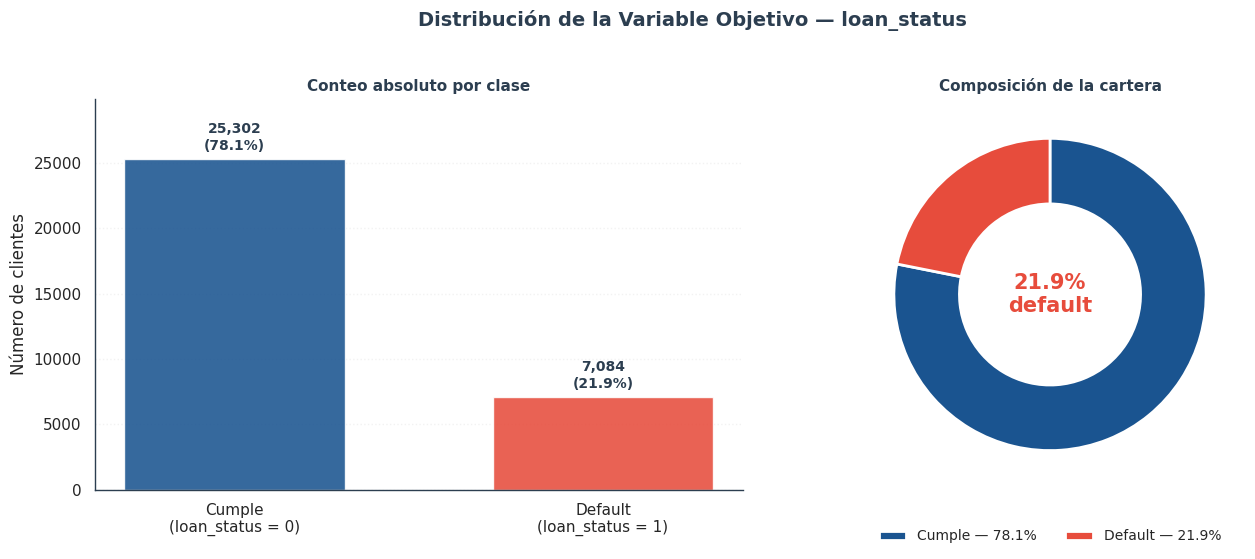

In [13]:
# ===============================================================
# 4.1 ANÁLISIS DE LA VARIABLE OBJETIVO — loan_status
# ===============================================================
# Cuantifica la tasa de default de la cartera y el desbalance de
# clases, estableciendo la base de referencia del análisis de riesgo.
# ===============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------------
# Cuantificación de la variable objetivo
# ---------------------------------------------------------------
total = len(df_modelo)
conteo = df_modelo['loan_status'].value_counts().sort_index()
n_cumple  = conteo.get(0, 0)
n_default = conteo.get(1, 0)

tasa_default = n_default / total * 100
tasa_cumple  = n_cumple / total * 100
ratio_desbalance = n_cumple / n_default if n_default > 0 else 0

print("═" * 64)
print(" ANÁLISIS DE LA VARIABLE OBJETIVO — loan_status")
print("═" * 64)
print(f"\n Total de registros:          {total:>10,}")
print(f"\n {'Clase':<28}{'N':>12}{'%':>12}")
print(" " + "─" * 52)
print(f" {'0 — Cumple (no default)':<28}{n_cumple:>12,}{tasa_cumple:>11.2f}%")
print(f" {'1 — Default':<28}{n_default:>12,}{tasa_default:>11.2f}%")
print(" " + "─" * 52)
print(f"\n Tasa de default de la cartera:   {tasa_default:.2f}%")
print(f" Ratio de desbalance:             {ratio_desbalance:.1f} : 1  (cumple : default)")

# ---------------------------------------------------------------
# Lectura del desbalance — accuracy del clasificador trivial
# ---------------------------------------------------------------
print("\n=== IMPLICANCIA PARA LA EVALUACIÓN DEL MODELO ===")
print(f" Un clasificador trivial que prediga 'no default' para todos")
print(f" los clientes alcanzaría una accuracy de {tasa_cumple:.1f}%,")
print(f" sin identificar ningún caso de riesgo.")
print(f" → La discriminación se medirá con AUC-ROC y KS, no con accuracy.")

# ---------------------------------------------------------------
# Visualización
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Distribución de la Variable Objetivo — loan_status",
             fontsize=14, fontweight='bold', color="#2C3E50", y=1.02)

COLOR_CUMPLE  = "#1A5490"
COLOR_DEFAULT = "#E74C3C"
colores = [COLOR_CUMPLE, COLOR_DEFAULT]
etiquetas = ['Cumple\n(loan_status = 0)', 'Default\n(loan_status = 1)']

# Izquierda — barras con conteo
ax1 = axes[0]
barras = ax1.bar(etiquetas, [n_cumple, n_default], color=colores,
                 alpha=0.88, edgecolor='white', linewidth=1.0, width=0.6)
for barra, n, pct in zip(barras, [n_cumple, n_default], [tasa_cumple, tasa_default]):
    ax1.text(barra.get_x() + barra.get_width()/2, barra.get_height() + total*0.015,
             f"{n:,}\n({pct:.1f}%)", ha='center', va='bottom',
             fontsize=10, fontweight='bold', color="#2C3E50")
ax1.set_title("Conteo absoluto por clase", fontweight="bold",
              fontsize=11, color="#2C3E50")
ax1.set_ylabel("Número de clientes")
ax1.set_ylim(0, n_cumple * 1.18)
ax1.grid(True, alpha=0.25, linestyle=':', axis='y')

# Derecha — composición de la cartera (dona)
ax2 = axes[1]
wedges, texts = ax2.pie(
    [n_cumple, n_default], labels=None, colors=colores,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2))
ax2.text(0, 0, f"{tasa_default:.1f}%\ndefault", ha='center', va='center',
         fontsize=15, fontweight='bold', color=COLOR_DEFAULT)
ax2.legend(wedges, [f'Cumple — {tasa_cumple:.1f}%', f'Default — {tasa_default:.1f}%'],
           loc='center', bbox_to_anchor=(0.5, -0.12), ncol=2,
           fontsize=10, frameon=False)
ax2.set_title("Composición de la cartera", fontweight="bold",
              fontsize=11, color="#2C3E50")

plt.tight_layout()
plt.show()

### Nota sobre la representatividad de la tasa de default

La tasa de default observada (21.87%) es considerablemente superior a la de una cartera crediticia productiva, donde los niveles de mora rara vez superan un dígito. Esta diferencia es esperable: el dataset fue construido con fines de modelado y no refleja la mezcla real de una cartera bancaria en operación.

Para el objetivo de este proyecto —construir y validar un modelo de scoring— esta característica no es un obstáculo: una mayor proporción de casos positivos favorece el aprendizaje del modelo. No obstante, en un entorno productivo la tasa base sería sensiblemente menor, lo que acentuaría el desbalance de clases y exigiría un tratamiento más cuidadoso (técnicas de remuestreo, ajuste de umbral, calibración de probabilidades). El modelo desarrollado aquí debe interpretarse, por tanto, como un ejercicio metodológico sobre datos de referencia, no como un modelo calibrado a una cartera específica.

## 4.2 Análisis Univariado

El análisis univariado examina la distribución individual de cada variable predictora. Su objetivo es comprender la **forma, concentración y rango** de cada variable, identificar características que condicionen el modelado —asimetrías, valores extremos, escalas dispares— y anticipar las transformaciones necesarias.

### 4.2.1 Variables numéricas

Se analizan las seis variables numéricas del dataset: edad, ingreso, antigüedad laboral, monto del préstamo, tasa de interés y ratio de endeudamiento (DTI). Para cada una se reporta su distribución, sus estadísticos de forma y la presencia de asimetría o valores extremos relevantes para la fase de modelado.

### Lectura de la asimetría (*skew*)

Para cada variable se reporta su coeficiente de **asimetría (*skew*)**, que mide cuán desbalanceada está su distribución respecto de una forma simétrica:

- **|skew| < 0.5** — distribución aproximadamente simétrica.
- **0.5 ≤ |skew| < 1.0** — asimetría moderada.
- **|skew| ≥ 1.0** — asimetría fuerte: la variable presenta una cola larga que concentra la masa de datos en un extremo.

La asimetría es relevante porque los **modelos lineales** —como la regresión logística— son sensibles a los valores extremos de las colas largas: unos pocos registros atípicos pueden distorsionar los coeficientes estimados. Las variables con asimetría fuerte quedan, por tanto, señaladas como **candidatas a transformación** (típicamente logarítmica), que comprime la cola y aproxima la distribución a una forma simétrica.

Esta transformación se evalúa y aplica en la fase de **Feature Engineering** (Capítulo 5); el análisis univariado se limita a identificar las variables que la requieren. Cabe señalar que los modelos basados en árboles (como XGBoost) son robustos a la asimetría, por lo que la transformación beneficia principalmente al componente lineal del proyecto.

══════════════════════════════════════════════════════════════════════════════════════
 ANÁLISIS UNIVARIADO — VARIABLES NUMÉRICAS
══════════════════════════════════════════════════════════════════════════════════════

 Variable                    Media    Mediana     Desv.       Mín         Máx     Skew
 ────────────────────────────────────────────────────────────────────────────────────
 person_age                  27.72      26.00      6.16     20.00       73.00     1.86
 person_income            65896.34   55000.00  52528.20   4000.00  2039784.00     9.78
 person_emp_length            4.76       4.00      3.98      0.00       38.00     1.26
 loan_amnt                 9593.51    8000.00   6321.52    500.00    35000.00     1.19
 loan_int_rate               11.02      10.99      3.21      5.42       23.22     0.21
 loan_percent_income          0.17       0.15      0.11      0.00        0.83     1.06
 ────────────────────────────────────────────────────────────────────────────────────


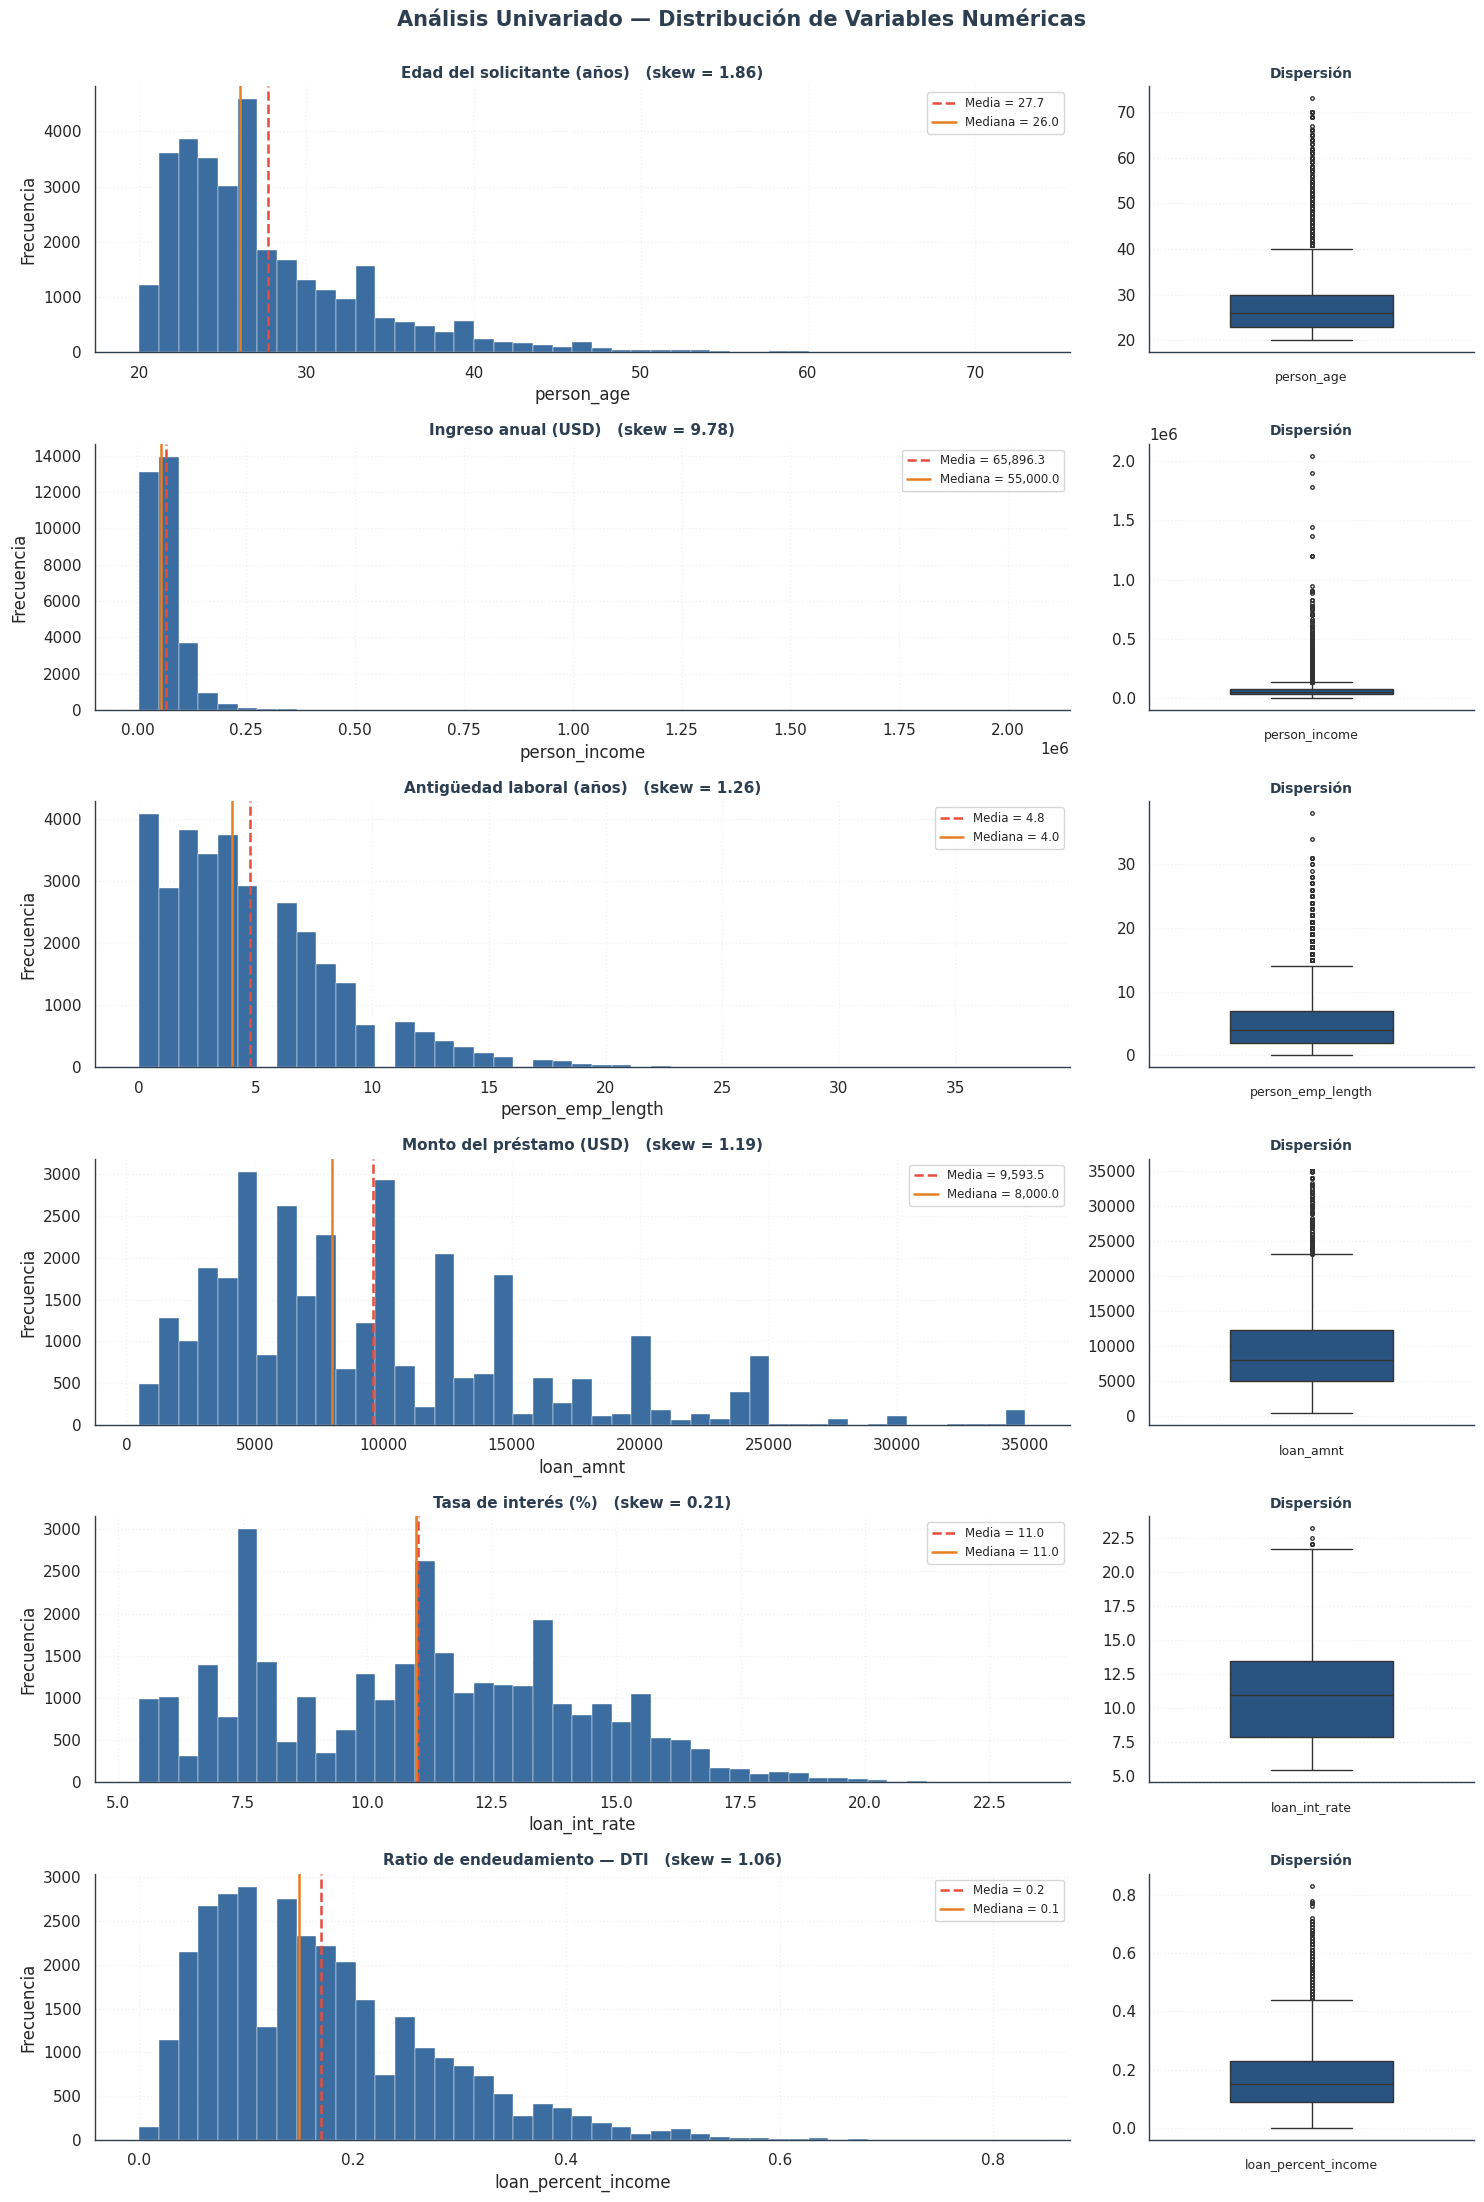


=== LECTURA DE LA FORMA DE LAS DISTRIBUCIONES ===
  • person_age             skew =   1.86  →  asimetría fuerte — candidata a transformación (ej. logarítmica)
  • person_income          skew =   9.78  →  asimetría fuerte — candidata a transformación (ej. logarítmica)
  • person_emp_length      skew =   1.26  →  asimetría fuerte — candidata a transformación (ej. logarítmica)
  • loan_amnt              skew =   1.19  →  asimetría fuerte — candidata a transformación (ej. logarítmica)
  • loan_int_rate          skew =   0.21  →  aproximadamente simétrica
  • loan_percent_income    skew =   1.06  →  asimetría fuerte — candidata a transformación (ej. logarítmica)


In [14]:
# ===============================================================
# 4.2.1 ANÁLISIS UNIVARIADO — VARIABLES NUMÉRICAS
# ===============================================================
# Distribución, forma y dispersión de las seis variables numéricas
# predictoras. Identifica asimetrías y escalas relevantes para el
# modelado posterior.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

variables_num = [
    ('person_age',          'Edad del solicitante (años)'),
    ('person_income',       'Ingreso anual (USD)'),
    ('person_emp_length',   'Antigüedad laboral (años)'),
    ('loan_amnt',           'Monto del préstamo (USD)'),
    ('loan_int_rate',       'Tasa de interés (%)'),
    ('loan_percent_income', 'Ratio de endeudamiento — DTI'),
]

# ---------------------------------------------------------------
# Tabla resumen de estadísticos
# ---------------------------------------------------------------
print("═" * 86)
print(" ANÁLISIS UNIVARIADO — VARIABLES NUMÉRICAS")
print("═" * 86)
print(f"\n {'Variable':<22}{'Media':>11}{'Mediana':>11}{'Desv.':>10}"
      f"{'Mín':>10}{'Máx':>12}{'Skew':>9}")
print(" " + "─" * 84)
for var, _ in variables_num:
    s = df_modelo[var]
    print(f" {var:<22}{s.mean():>11.2f}{s.median():>11.2f}{s.std():>10.2f}"
          f"{s.min():>10.2f}{s.max():>12.2f}{s.skew():>9.2f}")
print(" " + "─" * 84)

# ---------------------------------------------------------------
# Visualización — histograma + boxplot por variable
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(6, 2, figsize=(15, 22),
                         gridspec_kw={'width_ratios': [3, 1]})
fig.suptitle("Análisis Univariado — Distribución de Variables Numéricas",
             fontsize=15, fontweight='bold', color="#2C3E50", y=1.00)

COLOR = "#1A5490"

for i, (var, etiqueta) in enumerate(variables_num):
    serie = df_modelo[var]
    media, mediana = serie.mean(), serie.median()

    # Histograma
    ax_h = axes[i, 0]
    sns.histplot(serie, bins=45, ax=ax_h, color=COLOR, alpha=0.85,
                 edgecolor='white', linewidth=0.3)
    ax_h.axvline(media,   color="#E74C3C", linestyle="--", linewidth=1.8,
                 label=f"Media = {media:,.1f}")
    ax_h.axvline(mediana, color="#E67E22", linestyle="-", linewidth=1.8,
                 label=f"Mediana = {mediana:,.1f}")
    ax_h.set_title(f"{etiqueta}   (skew = {serie.skew():.2f})",
                   fontweight="bold", fontsize=11, color="#2C3E50")
    ax_h.set_xlabel(var)
    ax_h.set_ylabel("Frecuencia")
    ax_h.legend(fontsize=8.5)
    ax_h.grid(True, alpha=0.25, linestyle=':')

    # Boxplot
    ax_b = axes[i, 1]
    sns.boxplot(y=serie, ax=ax_b, color=COLOR, fliersize=2.5,
                linewidth=1.0, width=0.5)
    ax_b.set_title("Dispersión", fontweight="bold", fontsize=10, color="#2C3E50")
    ax_b.set_ylabel("")
    ax_b.set_xlabel(var, fontsize=9)
    ax_b.grid(True, alpha=0.25, linestyle=':', axis='y')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Lectura automática de la asimetría
# ---------------------------------------------------------------
print("\n=== LECTURA DE LA FORMA DE LAS DISTRIBUCIONES ===")
for var, etiqueta in variables_num:
    skew = df_modelo[var].skew()
    if abs(skew) < 0.5:
        forma = "aproximadamente simétrica"
    elif abs(skew) < 1.0:
        forma = "asimetría moderada"
    else:
        forma = "asimetría fuerte — candidata a transformación (ej. logarítmica)"
    print(f"  • {var:<22} skew = {skew:>6.2f}  →  {forma}")

### Interpretación del Análisis Univariado — Variables Numéricas

El análisis de las seis variables numéricas revela tres grupos según su forma y sus implicancias para el modelado.

**Variables con asimetría fuerte (candidatas a transformación).** `person_income` (skew = 9.78) presenta la asimetría más pronunciada del dataset: la enorme mayoría de los solicitantes se concentra en ingresos bajos y medios, con una cola extrema que alcanza los 2 millones de USD. `loan_amnt` (skew = 1.19), `person_age` (skew = 1.86) y `person_emp_length` (skew = 1.26) muestran también colas largas hacia la derecha. Estas variables quedan señaladas como candidatas a transformación logarítmica de cara a la regresión logística.

**Variable aproximadamente simétrica.** `loan_int_rate` (skew = 0.21) presenta una distribución balanceada, con media y mediana prácticamente coincidentes (~11%). No requiere transformación. Su forma multimodal —se observan varios picos— es coherente con el hallazgo del Gobierno de Datos: la tasa está fuertemente determinada por el grado crediticio, y cada grado aporta su propia concentración de valores.

**Variable de interés para el negocio: el ratio de endeudamiento.** `loan_percent_income` (DTI, skew = 1.06) concentra a la mayoría de los solicitantes por debajo del 30% de carga financiera, con una cola que se extiende hacia niveles de sobre-endeudamiento. Esta variable es particularmente relevante: el análisis bivariado (4.3) evaluará si los niveles altos de DTI se asocian con mayor tasa de default, como anticipó el screening del Tier 3.

**Lectura de negocio del perfil de la cartera.** Los estadísticos describen una cartera de solicitantes **jóvenes** (edad mediana de 26 años), con **antigüedad laboral baja** (mediana de 4 años), ingresos medianos de 55.000 USD y préstamos de monto mediano de 8.000 USD. Es un perfil de cartera de crédito de consumo orientada a un segmento joven —un dato a tener presente al interpretar los patrones de riesgo en las secciones siguientes.

### 4.2.2 Variables categóricas

Se analizan las cuatro variables categóricas del dataset: situación habitacional, intención del préstamo, grado crediticio y antecedente de default en el buró. Para cada una se examina la **distribución de frecuencias** entre sus categorías —identificando categorías dominantes o poco representadas— como insumo para el análisis bivariado y para la posterior codificación de variables en el modelado.

Una de ellas, `loan_grade`, es de naturaleza **ordinal**: sus categorías (A a G) tienen un orden intrínseco de calidad crediticia decreciente. El resto son **nominales**: sus categorías no admiten un orden natural.

══════════════════════════════════════════════════════════════════════
 ANÁLISIS UNIVARIADO — VARIABLES CATEGÓRICAS
══════════════════════════════════════════════════════════════════════

 Situación habitacional  (person_home_ownership) — nominal
 ────────────────────────────────────────────────────
   RENT                      16,360     50.52%
   MORTGAGE                  13,357     41.24%
   OWN                        2,563      7.91%
   OTHER                        106      0.33%
   Categorías distintas:          4

 Intención del préstamo  (loan_intent) — nominal
 ────────────────────────────────────────────────────
   EDUCATION                  6,406     19.78%
   MEDICAL                    6,033     18.63%
   VENTURE                    5,677     17.53%
   PERSONAL                   5,491     16.95%
   DEBTCONSOLIDATION          5,185     16.01%
   HOMEIMPROVEMENT            3,594     11.10%
   Categorías distintas:          6

 Grado crediticio  (loan_grade) — ordinal
 ─────────

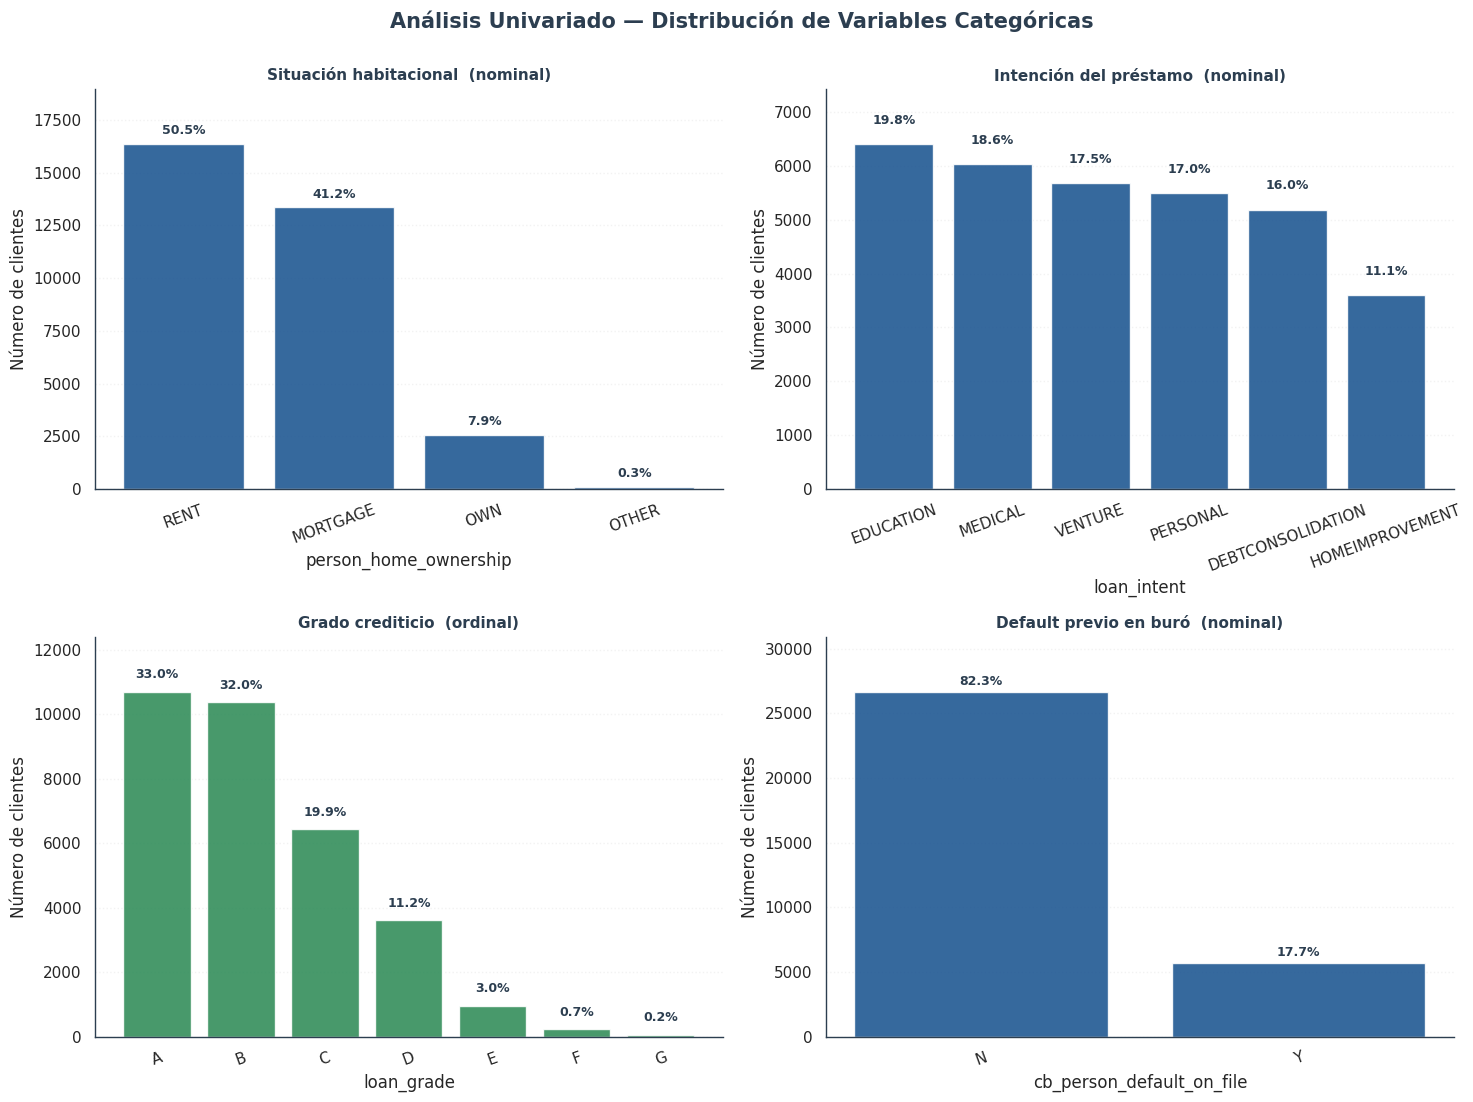

In [15]:
# ===============================================================
# 4.2.2 ANÁLISIS UNIVARIADO — VARIABLES CATEGÓRICAS
# ===============================================================
# Distribución de frecuencias de las cuatro variables categóricas.
# Identifica categorías dominantes o poco representadas, relevante
# para la codificación y el análisis bivariado.
# ===============================================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

variables_cat = [
    ('person_home_ownership',     'Situación habitacional',  'nominal'),
    ('loan_intent',               'Intención del préstamo',  'nominal'),
    ('loan_grade',                'Grado crediticio',        'ordinal'),
    ('cb_person_default_on_file', 'Default previo en buró',  'nominal'),
]

total = len(df_modelo)

# ---------------------------------------------------------------
# Tabla de frecuencias por variable
# ---------------------------------------------------------------
print("═" * 70)
print(" ANÁLISIS UNIVARIADO — VARIABLES CATEGÓRICAS")
print("═" * 70)

for var, etiqueta, tipo in variables_cat:
    print(f"\n {etiqueta}  ({var}) — {tipo}")
    print(" " + "─" * 52)
    frec = df_modelo[var].value_counts()
    frec_pct = df_modelo[var].value_counts(normalize=True) * 100
    for cat in frec.index:
        print(f"   {str(cat):<22}{frec[cat]:>10,}{frec_pct[cat]:>10.2f}%")
    print(f"   {'Categorías distintas:':<22}{df_modelo[var].nunique():>10}")

# ---------------------------------------------------------------
# Visualización — gráfico de barras por variable
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Análisis Univariado — Distribución de Variables Categóricas",
             fontsize=15, fontweight='bold', color="#2C3E50", y=1.00)

COLOR_NOM = "#1A5490"
COLOR_ORD = "#2E8B57"

for ax, (var, etiqueta, tipo) in zip(axes.flat, variables_cat):
    # Para loan_grade (ordinal) respetar el orden A-G; resto por frecuencia
    if tipo == 'ordinal':
        orden = sorted(df_modelo[var].unique())
        color = COLOR_ORD
    else:
        orden = df_modelo[var].value_counts().index.tolist()
        color = COLOR_NOM

    frec = df_modelo[var].value_counts().reindex(orden)
    frec_pct = frec / total * 100

    barras = ax.bar([str(c) for c in orden], frec.values, color=color,
                    alpha=0.88, edgecolor='white', linewidth=1.0)
    for barra, pct in zip(barras, frec_pct.values):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + total*0.01,
                f"{pct:.1f}%", ha='center', va='bottom',
                fontsize=9, fontweight='bold', color="#2C3E50")

    ax.set_title(f"{etiqueta}  ({tipo})", fontweight="bold",
                 fontsize=11, color="#2C3E50")
    ax.set_xlabel(var)
    ax.set_ylabel("Número de clientes")
    ax.set_ylim(0, frec.max() * 1.16)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')
    ax.tick_params(axis='x', labelrotation=20)

plt.tight_layout()
plt.show()

### Interpretación del Análisis Univariado — Variables Categóricas

El análisis de las cuatro variables categóricas aporta una primera lectura del perfil de la cartera y anticipa consideraciones para el modelado.

**Situación habitacional.** La cartera se concentra en inquilinos (RENT, 50.5%) y clientes con hipoteca (MORTGAGE, 41.2%). Los propietarios sin deuda hipotecaria (OWN) representan solo el 7.9%, y la categoría OTHER es marginal (0.3%, 106 registros). Esta última categoría, por su baja frecuencia, deberá tratarse con cuidado en el análisis bivariado: una tasa de default calculada sobre tan pocos casos tiene escasa robustez estadística.

**Intención del préstamo.** Es la variable categórica mejor distribuida: sus seis categorías oscilan entre el 11% y el 20%, sin ninguna dominante. Esta distribución equilibrada la convierte en una buena candidata para el análisis bivariado, ya que cada categoría cuenta con volumen suficiente para una estimación de riesgo confiable.

**Grado crediticio.** La distribución es decreciente y se concentra en los grados de mejor calidad: A, B y C suman el 85% de la cartera, mientras que F y G juntos representan apenas el 0.9% (305 registros). Este patrón es esperable —una cartera sana contiene mayoritariamente clientes de buen perfil—, pero implica que las estimaciones de riesgo para los grados F y G se basarán en muestras pequeñas y deberán interpretarse con prudencia.

**Default previo en buró.** El 17.7% de los solicitantes registra un default previo en el buró de crédito. Esta variable es de particular interés: el antecedente de incumplimiento es, en la práctica de credit scoring, uno de los predictores individuales más potentes del riesgo futuro. El análisis bivariado (4.3) cuantificará su poder discriminante.

**Síntesis.** El perfil de la cartera —mayoría de inquilinos, concentración en grados crediticios altos, una porción relevante con antecedentes de default— es coherente con un producto de crédito de consumo orientado a un segmento joven, en línea con lo observado en las variables numéricas.

## 4.3 Análisis Bivariado: Poder Discriminante frente al Default

Esta sección constituye el núcleo del EDA. Mientras el análisis univariado describió cada variable de forma aislada, el análisis bivariado evalúa la relación de cada predictor con la variable objetivo: **¿cómo varía la tasa de default a lo largo de cada variable?**

El propósito es identificar las variables con mayor **poder discriminante** —capacidad de separar clientes que entran en default de los que cumplen— y verificar la **monotonicidad** del riesgo, es decir, que el ordenamiento de la tasa de default a lo largo de la variable sea coherente y sin inversiones inexplicables.

Cada tasa de default se interpreta en relación a la **tasa base de la cartera (21.87%)**: una categoría es "de riesgo elevado" o "de riesgo reducido" según se ubique por encima o por debajo de esa referencia.

### 4.3.1 Variables categóricas vs. default

Se analiza la tasa de default dentro de cada categoría de las cuatro variables categóricas. Para cada categoría se reporta su tasa de default y su desviación respecto de la tasa base.

#### Confiabilidad de las estimaciones

La tasa de default de cada categoría es una **proporción estimada sobre una muestra**, y como tal está sujeta a incertidumbre. Una tasa calculada sobre 60 registros es mucho menos confiable que una calculada sobre 10.000: con pocos casos, el azar del muestreo puede desviar el resultado de forma significativa. Para cuantificar esa incertidumbre se construye, para cada tasa, su **intervalo de confianza al 95%**.

El cálculo se realiza en tres pasos encadenados:

**1. Error estándar (SE).** Mide la variabilidad "cruda" de la estimación —cuánto puede fluctuar la tasa observada por efecto del muestreo—. Para una proporción se calcula como:

$$SE = \sqrt{\frac{p\,(1-p)}{n}}$$

donde *p* es la tasa de default observada y *n* el número de registros de la categoría. El SE disminuye a medida que *n* crece: más datos implican una estimación más estable.

**2. Margen de error.** El error estándar se escala al nivel de confianza elegido. Para un **95% de confianza**, el factor es 1,96:

$$\text{Margen de error} = 1{,}96 \cdot SE$$

El resultado se expresa en **puntos porcentuales (pp)** y es el valor "± pp" reportado en la tabla.

**3. Intervalo de confianza.** La tasa estimada, más y menos su margen de error:

$$IC_{95\%} = p \pm 1{,}96 \cdot SE$$

La interpretación es: con un 95% de confianza, la verdadera tasa de default de la categoría se encuentra dentro de ese rango. Un intervalo angosto indica una estimación sólida; uno amplio, una estimación que debe leerse con cautela.

#### Por qué este enfoque

Este procedimiento reemplaza un umbral de volumen arbitrario —del tipo "descartar categorías con menos de N registros"— por una **medida estadística fundamentada**. La confiabilidad de una estimación no se decide con un corte fijo de registros, sino según la amplitud de su intervalo de confianza. Las categorías con intervalos amplios —típicamente los grados crediticios F y G, o la categoría habitacional OTHER, todos con pocos registros— se identifican de forma objetiva y se interpretan con la prudencia que su margen de error indica. En cada gráfico, el intervalo de confianza se representa como **barra de error** sobre cada columna.

══════════════════════════════════════════════════════════════════════════════════
 ANÁLISIS BIVARIADO — CATEGÓRICAS vs DEFAULT   (tasa base: 21.87%)
══════════════════════════════════════════════════════════════════════════════════

 Situación habitacional  (person_home_ownership)
 ──────────────────────────────────────────────────────────────────────
   Categoría                   N    Default %          IC 95%      vs base
   ····································································
   RENT                   16,360       31.62%        ±0.71 pp+       9.75 pp
   OTHER                     106       31.13%        ±8.81 pp+       9.26 pp
   MORTGAGE               13,357       12.62%        ±0.56 pp      -9.25 pp
   OWN                     2,563        7.49%        ±1.02 pp     -14.38 pp

 Intención del préstamo  (loan_intent)
 ──────────────────────────────────────────────────────────────────────
   Categoría                   N    Default %          IC 95%      vs base
   ··

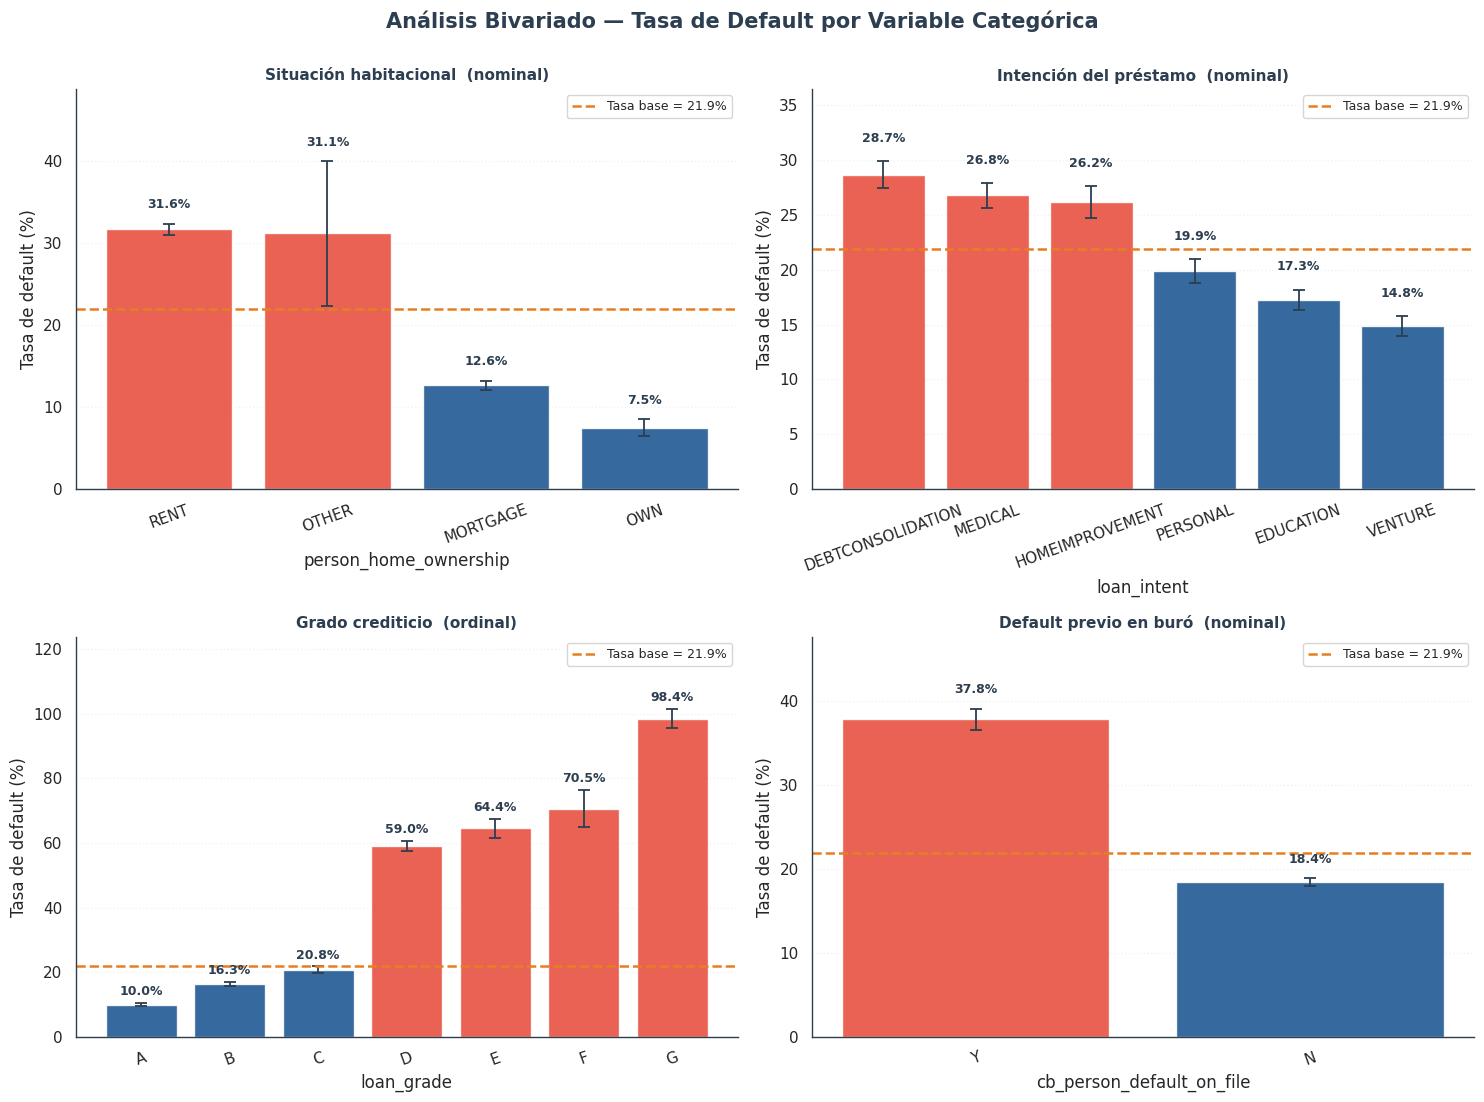

In [16]:
# ===============================================================
# 4.3.1 ANÁLISIS BIVARIADO — VARIABLES CATEGÓRICAS vs DEFAULT
# ===============================================================
# Tasa de default por categoría, con intervalo de confianza al 95%
# (error estándar de una proporción). El margen de error sustituye
# a un umbral de volumen arbitrario como medida de confiabilidad.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

tasa_base = df_modelo['loan_status'].mean() * 100
Z = 1.96   # nivel de confianza del 95%

variables_cat = [
    ('person_home_ownership',     'Situación habitacional',  'nominal'),
    ('loan_intent',               'Intención del préstamo',  'nominal'),
    ('loan_grade',                'Grado crediticio',        'ordinal'),
    ('cb_person_default_on_file', 'Default previo en buró',  'nominal'),
]

# ---------------------------------------------------------------
# Función: tasa de default + margen de error por categoría
# ---------------------------------------------------------------
def tabla_bivariada(var, tipo):
    g = df_modelo.groupby(var)['loan_status'].agg(['count', 'mean'])
    g['default_pct'] = g['mean'] * 100
    # Error estándar de la proporción y margen de error (en puntos %)
    se = np.sqrt(g['mean'] * (1 - g['mean']) / g['count'])
    g['margen_pp'] = Z * se * 100
    g['vs_base'] = g['default_pct'] - tasa_base
    if tipo == 'ordinal':
        g = g.reindex(sorted(g.index))
    else:
        g = g.sort_values('default_pct', ascending=False)
    return g

# ---------------------------------------------------------------
# Reporte por variable
# ---------------------------------------------------------------
print("═" * 82)
print(f" ANÁLISIS BIVARIADO — CATEGÓRICAS vs DEFAULT   (tasa base: {tasa_base:.2f}%)")
print("═" * 82)

for var, etiqueta, tipo in variables_cat:
    print(f"\n {etiqueta}  ({var})")
    print(" " + "─" * 70)
    print(f"   {'Categoría':<20}{'N':>9}{'Default %':>13}{'IC 95%':>16}{'vs base':>13}")
    print("   " + "·" * 68)
    g = tabla_bivariada(var, tipo)
    for cat, f in g.iterrows():
        signo = "+" if f['vs_base'] >= 0 else ""
        ic = f"±{f['margen_pp']:.2f} pp"
        print(f"   {str(cat):<20}{int(f['count']):>9,}"
              f"{f['default_pct']:>12.2f}%{ic:>16}"
              f"{signo}{f['vs_base']:>11.2f} pp")

print(f"\n IC 95% = margen de error de la tasa estimada. A mayor margen,")
print(f" menor confiabilidad (categorías con pocos registros).")

# ---------------------------------------------------------------
# Visualización — tasa de default + barras de error
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle("Análisis Bivariado — Tasa de Default por Variable Categórica",
             fontsize=15, fontweight='bold', color="#2C3E50", y=1.00)

COLOR_BAJO = "#1A5490"
COLOR_ALTO = "#E74C3C"

for ax, (var, etiqueta, tipo) in zip(axes.flat, variables_cat):
    g = tabla_bivariada(var, tipo)
    colores = [COLOR_ALTO if v >= tasa_base else COLOR_BAJO
               for v in g['default_pct']]

    barras = ax.bar([str(c) for c in g.index], g['default_pct'],
                    color=colores, alpha=0.88, edgecolor='white', linewidth=1.0,
                    yerr=g['margen_pp'], capsize=4,
                    error_kw=dict(ecolor='#2C3E50', lw=1.3, capthick=1.3))

    for barra, pct, margen in zip(barras, g['default_pct'], g['margen_pp']):
        ax.text(barra.get_x() + barra.get_width()/2,
                barra.get_height() + margen + 1.5,
                f"{pct:.1f}%", ha='center', va='bottom',
                fontsize=9, fontweight='bold', color="#2C3E50")

    ax.axhline(tasa_base, color="#E67E22", linestyle="--", linewidth=1.8,
               label=f"Tasa base = {tasa_base:.1f}%")

    ax.set_title(f"{etiqueta}  ({tipo})", fontweight="bold",
                 fontsize=11, color="#2C3E50")
    ax.set_xlabel(var)
    ax.set_ylabel("Tasa de default (%)")
    ax.set_ylim(0, (g['default_pct'] + g['margen_pp']).max() * 1.22)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')
    ax.tick_params(axis='x', labelrotation=20)

plt.tight_layout()
plt.show()

### Interpretación del Análisis Bivariado — Variables Categóricas

El análisis revela diferencias marcadas en el poder discriminante de las cuatro variables.

**Grado crediticio — el predictor más fuerte y perfectamente monótono.** La tasa de default crece de forma estrictamente ordenada a lo largo de los siete grados: A (9.97%), B (16.34%), C (20.77%), D (59.05%), E (64.45%), F (70.54%) y G (98.44%). No existe una sola inversión en la secuencia —el riesgo aumenta sin excepción al deteriorarse el grado—, lo que constituye el comportamiento ideal de una variable de scoring. Destaca un salto abrupto entre los grados C y D: el riesgo se triplica (de 20.77% a 59.05%), lo que sugiere que el grado D marca una frontera crítica de calidad crediticia. Las estimaciones de los grados F y G, con intervalos de confianza amplios (±5.76 pp y ±3.04 pp), se basan en muestras reducidas y deben interpretarse con la prudencia correspondiente —si bien su nivel de riesgo, muy por encima de la base, no deja dudas sobre su dirección.

**Default previo en buró — fuerte poder discriminante.** El antecedente de incumplimiento prácticamente duplica la tasa de default: los solicitantes con default previo registran un 37.85%, frente al 18.44% de quienes no lo tienen —una brecha de 19 pp—. Ambas estimaciones son sólidas (intervalos estrechos, gran volumen). El resultado confirma el principio de credit scoring de que el comportamiento crediticio pasado es uno de los mejores predictores del comportamiento futuro.

**Situación habitacional — discriminación clara con lógica de negocio.** Los inquilinos (RENT, 31.62%) presentan una tasa muy superior a los clientes con hipoteca (MORTGAGE, 12.62%) o propietarios (OWN, 7.49%). El patrón es económicamente coherente: la tenencia de un inmueble refleja mayor estabilidad patrimonial y capacidad de respaldo. La categoría OTHER muestra una tasa elevada (31.13%) pero con un intervalo de confianza muy amplio (±8.81 pp) por su escaso volumen (106 registros): su lectura es meramente indicativa.

**Intención del préstamo — discriminación moderada.** El destino del crédito ordena el riesgo de forma plausible: las finalidades asociadas a fragilidad financiera —consolidación de deudas (28.68%) y gastos médicos (26.79%)— se ubican por encima de la base, mientras que las de carácter más planificado —emprendimiento (14.85%) y educación (17.27%)— se sitúan por debajo. La amplitud del rango es menor que en las otras variables, lo que anticipa un poder discriminante más moderado.

**Síntesis.** Las cuatro variables categóricas discriminan el riesgo, con `loan_grade` y `cb_person_default_on_file` como las de mayor poder predictivo. Todas presentan un ordenamiento coherente con la lógica crediticia, sin patrones anómalos. Este poder discriminante se cuantificará formalmente mediante Weight of Evidence e Information Value en el Capítulo 5.

### 4.3.2 Variables numéricas vs. default

Las variables numéricas no poseen categorías naturales sobre las cuales calcular una tasa de default. Para analizar su relación con el riesgo se aplica un procedimiento de **agrupamiento por deciles** (*binning*): cada variable se divide en diez tramos de igual tamaño poblacional —el 10% de los registros cada uno—, y se calcula la tasa de default dentro de cada tramo.

Este enfoque permite evaluar dos aspectos del poder predictivo de cada variable:

- **Dirección y monotonicidad** — si la tasa de default crece o decrece de forma ordenada a lo largo de la variable. Una relación monótona indica que la variable ordena el riesgo de manera coherente y es adecuada para el scoring.
- **Magnitud del efecto** — la diferencia de tasa de default entre los tramos extremos: a mayor brecha, mayor poder discriminante.

Como en el análisis anterior, cada tasa se acompaña de su intervalo de confianza al 95%, y se interpreta en relación a la tasa base de la cartera (21.87%).

En los gráficos, cada variable se representa como una línea de tasa de default a lo largo de los diez deciles. La **banda sombreada** que rodea la línea es el **intervalo de confianza al 95%** de cada estimación —el equivalente, en formato de banda, a las barras de error empleadas en el análisis de variables categóricas (4.3.1)—. Una banda angosta indica una estimación precisa; una banda amplia, mayor incertidumbre en ese tramo.

════════════════════════════════════════════════════════════════════════════════
 ANÁLISIS BIVARIADO — NUMÉRICAS vs DEFAULT   (tasa base: 21.87%)
════════════════════════════════════════════════════════════════════════════════

 Variable                       Default 1er decil   Default 10mo      Brecha
 ────────────────────────────────────────────────────────────────────────────
 Edad del solicitante                     25.92%         20.76%     -5.16 pp
 Ingreso anual                            47.55%          9.14%    -38.40 pp
 Antigüedad laboral                       27.87%         16.21%    -11.66 pp
 Monto del préstamo                       21.27%         34.07%    +12.81 pp
 Tasa de interés                           8.03%         61.10%    +53.07 pp
 Ratio de endeudamiento (DTI)             10.27%         70.90%    +60.63 pp
 ────────────────────────────────────────────────────────────────────────────
 Brecha = diferencia de tasa de default entre el último y el primer decil.
 U

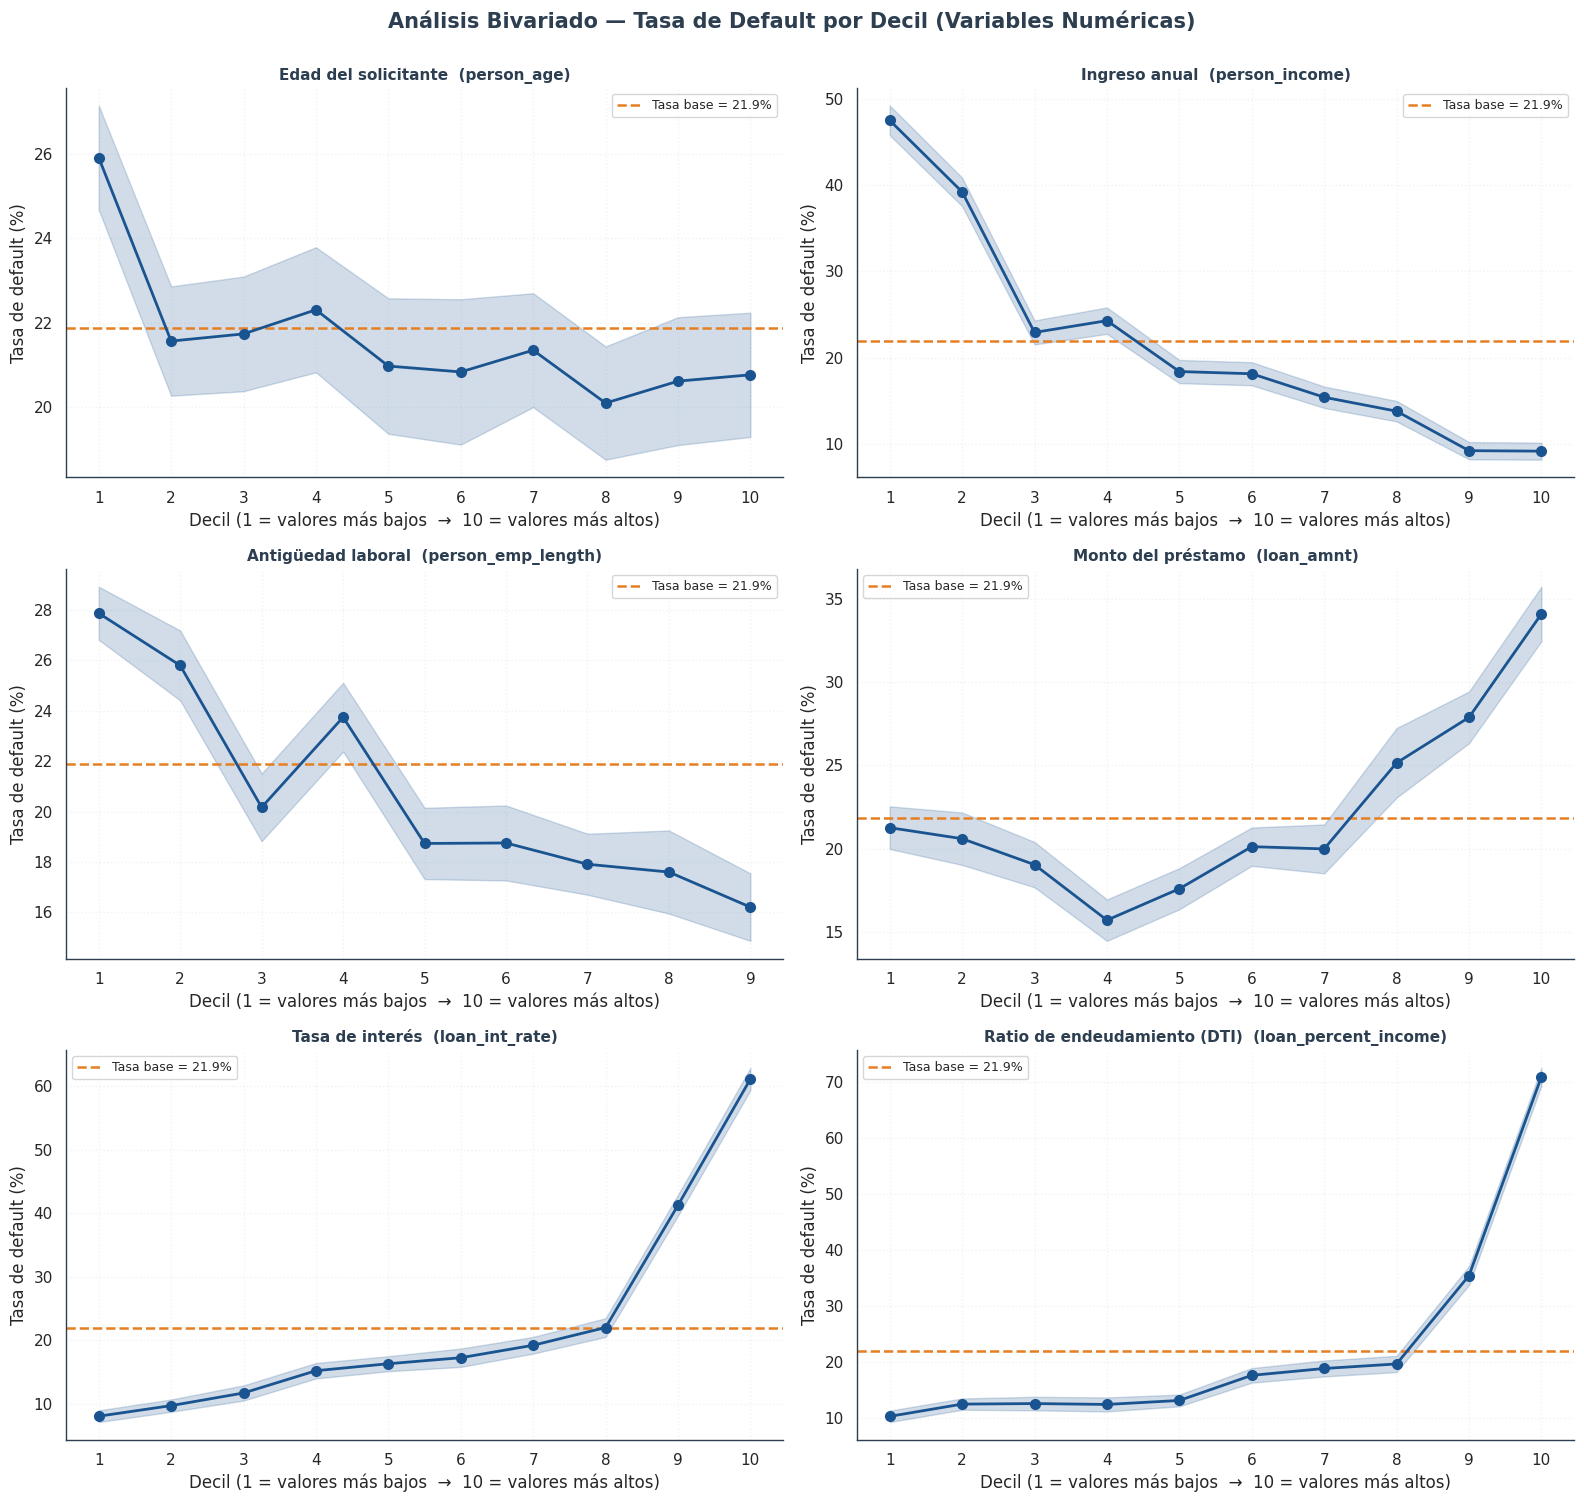

In [17]:
# ===============================================================
# 4.3.2 ANÁLISIS BIVARIADO — VARIABLES NUMÉRICAS vs DEFAULT
# ===============================================================
# Agrupa cada variable numérica en deciles y calcula la tasa de
# default por tramo, con intervalo de confianza al 95%.
# Evalúa dirección, monotonicidad y magnitud del efecto.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

tasa_base = df_modelo['loan_status'].mean() * 100
Z = 1.96

variables_num = [
    ('person_age',          'Edad del solicitante'),
    ('person_income',       'Ingreso anual'),
    ('person_emp_length',   'Antigüedad laboral'),
    ('loan_amnt',           'Monto del préstamo'),
    ('loan_int_rate',       'Tasa de interés'),
    ('loan_percent_income', 'Ratio de endeudamiento (DTI)'),
]

# ---------------------------------------------------------------
# Función: tasa de default por decil + intervalo de confianza
# ---------------------------------------------------------------
def default_por_decil(var):
    df_tmp = df_modelo[[var, 'loan_status']].copy()
    # Deciles: 10 tramos de igual tamaño poblacional
    df_tmp['decil'] = pd.qcut(df_tmp[var], q=10, duplicates='drop')
    g = df_tmp.groupby('decil', observed=True)['loan_status'].agg(['count', 'mean'])
    g['default_pct'] = g['mean'] * 100
    se = np.sqrt(g['mean'] * (1 - g['mean']) / g['count'])
    g['margen_pp'] = Z * se * 100
    return g

# ---------------------------------------------------------------
# Reporte: dirección y magnitud del efecto por variable
# ---------------------------------------------------------------
print("═" * 80)
print(f" ANÁLISIS BIVARIADO — NUMÉRICAS vs DEFAULT   (tasa base: {tasa_base:.2f}%)")
print("═" * 80)
print(f"\n {'Variable':<30}{'Default 1er decil':>18}{'Default 10mo':>15}{'Brecha':>12}")
print(" " + "─" * 76)

resumen_num = {}
for var, etiqueta in variables_num:
    g = default_por_decil(var)
    d_primero = g['default_pct'].iloc[0]
    d_ultimo  = g['default_pct'].iloc[-1]
    brecha = d_ultimo - d_primero
    resumen_num[var] = g
    print(f" {etiqueta:<30}{d_primero:>16.2f}%{d_ultimo:>14.2f}%"
          f"{brecha:>+10.2f} pp")

print(" " + "─" * 76)
print(" Brecha = diferencia de tasa de default entre el último y el primer decil.")
print(" Un valor alto (en magnitud) indica mayor poder discriminante.")

# ---------------------------------------------------------------
# Visualización — tasa de default por decil
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
fig.suptitle("Análisis Bivariado — Tasa de Default por Decil (Variables Numéricas)",
             fontsize=15, fontweight='bold', color="#2C3E50", y=1.00)

COLOR = "#1A5490"

for ax, (var, etiqueta) in zip(axes.flat, variables_num):
    g = resumen_num[var]
    posiciones = range(1, len(g) + 1)

    # Línea con marcadores + banda de intervalo de confianza
    ax.plot(posiciones, g['default_pct'], marker='o', markersize=7,
            color=COLOR, linewidth=2, zorder=3)
    ax.fill_between(posiciones,
                    g['default_pct'] - g['margen_pp'],
                    g['default_pct'] + g['margen_pp'],
                    color=COLOR, alpha=0.20, zorder=1)

    # Línea de tasa base
    ax.axhline(tasa_base, color="#E67E22", linestyle="--", linewidth=1.8,
               label=f"Tasa base = {tasa_base:.1f}%", zorder=2)

    ax.set_title(f"{etiqueta}  ({var})", fontweight="bold",
                 fontsize=11, color="#2C3E50")
    ax.set_xlabel("Decil (1 = valores más bajos  →  10 = valores más altos)")
    ax.set_ylabel("Tasa de default (%)")
    ax.set_xticks(list(posiciones))
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.25, linestyle=':')

plt.tight_layout()
plt.show()

### Interpretación del Análisis Bivariado — Variables Numéricas

El análisis por deciles revela tres grupos de variables según su poder discriminante y la forma de su relación con el default.

**Predictores fuertes y monótonos.** Tres variables muestran una relación clara y ordenada con el riesgo:

- **Ratio de endeudamiento (DTI)** — la brecha más amplia del dataset (+60.63 pp): la tasa de default crece de 10.27% en el decil de menor endeudamiento a 70.90% en el de mayor. La relación es monótona creciente y confirma el hallazgo anticipado en el Tier 3: la carga financiera es un determinante central del riesgo.
- **Tasa de interés** — brecha de +53.07 pp, también monótona creciente. El resultado es coherente con el grado crediticio: una tasa más alta refleja un perfil de mayor riesgo, que efectivamente se traduce en mayor default.
- **Ingreso anual** — brecha de −38.40 pp, monótona decreciente: a mayor ingreso, menor default. La relación responde a la lógica económica de mayor capacidad de pago.

**Predictor con relación no monótona.** El **monto del préstamo** presenta una relación en forma de U: el riesgo es moderado en montos bajos, alcanza un mínimo en los deciles intermedios (15.7% en el decil 4) y se eleva con fuerza en los montos altos (34.07% en el decil 10). Esta no-monotonicidad tiene una implicancia de modelado relevante: una regresión logística, que asume relaciones monótonas, no capturará adecuadamente este patrón con la variable en su forma original —requeriría transformación o discretización—, mientras que un modelo basado en árboles como XGBoost lo capturará de forma natural. El hallazgo se retomará en la fase de Feature Engineering.

**Predictores débiles.** La **edad** (brecha −5.16 pp) y la **antigüedad laboral** (brecha −11.66 pp) muestran relaciones de baja pendiente e intervalos de confianza amplios. Su poder discriminante individual es limitado; su aporte se evaluará en conjunto con las demás variables durante el modelado.

**Síntesis.** Las variables de mayor poder predictivo del bloque numérico son el ratio de endeudamiento, la tasa de interés y el ingreso. El monto del préstamo aporta señal pero de forma no lineal, y la edad y la antigüedad laboral muestran un poder discriminante reducido. Estos hallazgos, junto con los del análisis categórico, se cuantificarán formalmente mediante Weight of Evidence e Information Value en el Capítulo 5.

## 4.4 Análisis de Correlaciones y Multicolinealidad

Las secciones anteriores evaluaron cada variable frente al default de forma individual. Esta sección analiza las relaciones **entre las variables predictoras** —cómo se vinculan unas con otras—, un aspecto con implicancias directas para el modelado.

### Por qué importa la multicolinealidad

Dos variables están correlacionadas cuando tienden a moverse de forma conjunta. Cuando esa correlación es muy alta, las variables aportan **información redundante**: explican lo mismo del fenómeno. Esto se denomina **multicolinealidad**, y afecta de manera particular a la **regresión logística**:

- Los coeficientes estimados se vuelven **inestables** —el modelo no puede atribuir con claridad el efecto a una variable u otra— y pierden interpretabilidad.
- En credit scoring, donde el modelo debe ser explicable (cada variable justifica su aporte al puntaje), esta inestabilidad es especialmente problemática.

La relación es, por tanto, inversa: **cuanto menor es la multicolinealidad entre las variables predictoras, más estables e interpretables son los coeficientes de la regresión logística**. Un dataset con correlaciones predominantemente bajas representa un escenario favorable para este tipo de modelo.

Cabe señalar que los modelos basados en árboles (XGBoost) son **robustos a la multicolinealidad**: la redundancia entre variables no compromete su funcionamiento. Por ello, este análisis es relevante sobre todo para el componente de regresión logística del proyecto.

### Método

Se calcula la **matriz de correlación de Pearson** entre las variables numéricas. El coeficiente de Pearson (*r*) varía entre −1 y +1: valores cercanos a los extremos indican una relación lineal fuerte (positiva o negativa), y valores cercanos a 0 indican ausencia de relación lineal. Dado que todas las variables analizadas son predictoras, un par con correlación elevada constituye un caso de **multicolinealidad** y se señala como candidato a revisión en la fase de selección de variables. El análisis se limita a relaciones lineales entre predictores; las relaciones no lineales con la variable objetivo se abordaron en el análisis bivariado (4.3) y se cuantifican en el Capítulo 5.

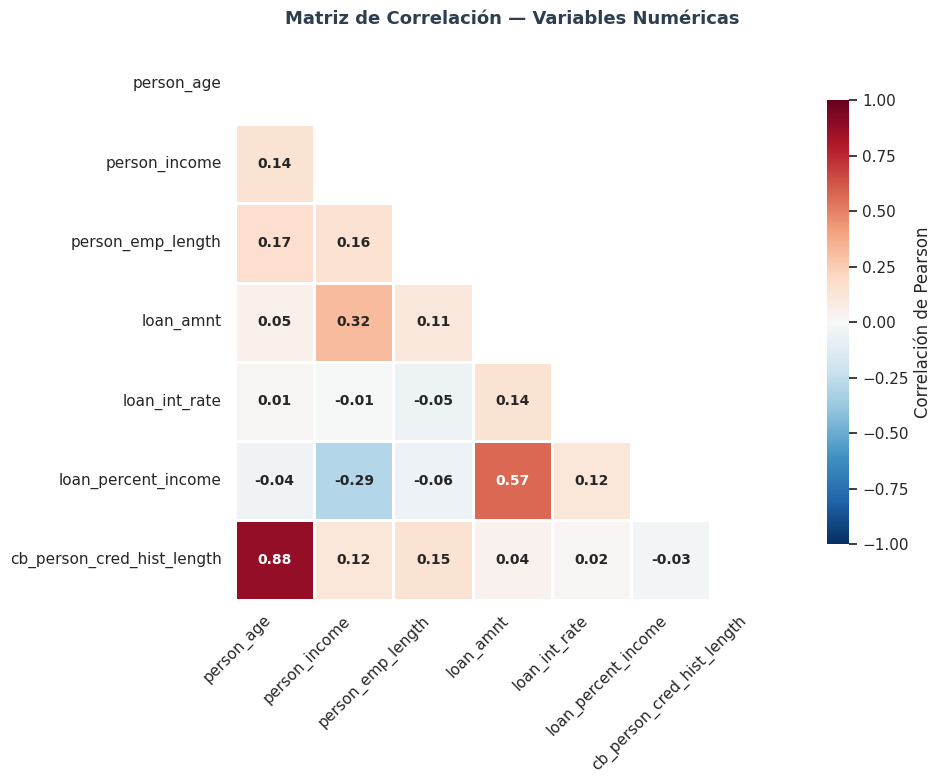

════════════════════════════════════════════════════════════════════
 ANÁLISIS DE MULTICOLINEALIDAD
════════════════════════════════════════════════════════════════════

 Pares de variables ordenados por correlación (|r|):

 Variable 1                Variable 2                       r    Intensidad
 ────────────────────────────────────────────────────────────────────────
 cb_person_cred_hist_lengthperson_age                    0.88          ALTA
 loan_percent_income       loan_amnt                     0.57      Moderada
 loan_amnt                 person_income                 0.32         Débil
 loan_percent_income       person_income                -0.29     Muy débil
 person_emp_length         person_age                    0.17     Muy débil
 person_emp_length         person_income                 0.16     Muy débil
 cb_person_cred_hist_lengthperson_emp_length             0.15     Muy débil
 loan_int_rate             loan_amnt                     0.14     Muy débil
 person_income    

In [18]:
# ===============================================================
# 4.4 ANÁLISIS DE CORRELACIONES Y MULTICOLINEALIDAD
# ===============================================================
# Matriz de correlación de Pearson entre variables numéricas.
# Identifica pares con correlación elevada (multicolinealidad),
# relevante para la estabilidad de la regresión logística.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Variables numéricas predictoras (se excluye la variable objetivo
# y las indicadoras de imputación)
variables_num = [
    'person_age', 'person_income', 'person_emp_length',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length'
]

# ---------------------------------------------------------------
# Matriz de correlación de Pearson
# ---------------------------------------------------------------
corr = df_modelo[variables_num].corr(method='pearson')

# ---------------------------------------------------------------
# Visualización — heatmap
# ---------------------------------------------------------------
sns.set_theme(style="white")

fig, ax = plt.subplots(figsize=(10, 8))

# Máscara triangular: se muestra solo la mitad inferior (la matriz
# es simétrica, mostrar ambas mitades es redundante)
mascara = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mascara, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=1,
            linecolor='white', cbar_kws={'label': 'Correlación de Pearson',
            'shrink': 0.8}, ax=ax,
            annot_kws={'fontsize': 10, 'fontweight': 'bold'})

ax.set_title("Matriz de Correlación — Variables Numéricas",
             fontweight='bold', fontsize=13, color="#2C3E50", pad=15)
ax.tick_params(axis='x', labelrotation=45)
ax.tick_params(axis='y', labelrotation=0)
plt.setp(ax.get_xticklabels(), ha='right')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Identificación de pares con correlación elevada
# ---------------------------------------------------------------
UMBRAL_ALTA = 0.50   # correlación a partir de la cual se señala el par

print("═" * 68)
print(" ANÁLISIS DE MULTICOLINEALIDAD")
print("═" * 68)

# Extraer pares únicos (mitad inferior de la matriz)
pares = []
for i in range(len(variables_num)):
    for j in range(i):
        v1, v2 = variables_num[i], variables_num[j]
        r = corr.loc[v1, v2]
        pares.append((v1, v2, r))

# Ordenar por correlación absoluta descendente
pares.sort(key=lambda x: abs(x[2]), reverse=True)

print(f"\n Pares de variables ordenados por correlación (|r|):\n")
print(f" {'Variable 1':<26}{'Variable 2':<26}{'r':>8}{'Intensidad':>14}")
print(" " + "─" * 72)
for v1, v2, r in pares:
    if abs(r) >= 0.70:
        intensidad = "ALTA"
    elif abs(r) >= UMBRAL_ALTA:
        intensidad = "Moderada"
    elif abs(r) >= 0.30:
        intensidad = "Débil"
    else:
        intensidad = "Muy débil"
    print(f" {v1:<26}{v2:<26}{r:>8.2f}{intensidad:>14}")

print(" " + "─" * 72)

# Alertas de multicolinealidad
pares_altos = [(v1, v2, r) for v1, v2, r in pares if abs(r) >= UMBRAL_ALTA]
print(f"\n=== PARES A REVISAR (|r| ≥ {UMBRAL_ALTA}) ===")
if pares_altos:
    for v1, v2, r in pares_altos:
        print(f"  • {v1} ↔ {v2}:  r = {r:.2f}")
    print(f"\n  Estos pares aportan información parcialmente redundante.")
    print(f"  Se evaluará su tratamiento en la selección de variables (Cap. 5).")
else:
    print("  No se detectan pares con correlación moderada o alta.")
    print("  Las variables numéricas aportan información mayormente independiente.")
print("═" * 68)

### Interpretación del Análisis de Correlaciones

El análisis de la matriz de correlación identifica dos pares de variables con relación relevante; el resto presenta correlaciones débiles o muy débiles.

**Multicolinealidad alta: edad e historial crediticio.** El par `person_age` ↔ `cb_person_cred_hist_length` presenta una correlación de **r = 0.88**, la más elevada del dataset. La relación tiene una explicación directa: la longitud del historial crediticio crece de forma casi mecánica con la edad —cuantos más años tiene una persona, más tiempo ha tenido para acumular historial—. Ambas variables aportan, por tanto, información en gran medida redundante. Para la regresión logística esto constituye un caso claro de multicolinealidad: incluir las dos variables generaría coeficientes inestables. En la fase de selección de variables (Capítulo 5) se evaluará conservar solo una de ellas.

**Multicolinealidad moderada: monto y ratio de endeudamiento.** El par `loan_amnt` ↔ `loan_percent_income` muestra una correlación de **r = 0.57**. La relación es esperable, dado que el ratio de endeudamiento se calcula a partir del monto del préstamo en relación al ingreso. La redundancia es parcial —no total—, por lo que el par se señala para revisión, sin que su tratamiento sea tan prioritario como el anterior.

**Resto de las variables: información independiente.** Los demás pares presentan correlaciones por debajo de 0.35, en su mayoría muy débiles. Esto es favorable para el modelado: indica que la mayoría de las variables numéricas aportan información no redundante, lo que enriquece la capacidad predictiva del modelo sin agravar la multicolinealidad.

**Alcance del análisis.** La matriz de Pearson evalúa exclusivamente relaciones **lineales entre predictores**, con el fin de detectar multicolinealidad —el fenómeno que afecta la estabilidad de la regresión logística—. No mide la relación de las variables con el default (analizada en la sección 4.3) ni capta relaciones no lineales entre predictores. Cabe recordar que los modelos basados en árboles (XGBoost) son robustos a la multicolinealidad, por lo que los hallazgos de esta sección condicionan principalmente el diseño del componente de regresión logística.

**Síntesis.** Se identifica un caso de multicolinealidad alta (edad / historial crediticio) que requerirá tratamiento en la selección de variables, y uno moderado (monto / ratio de endeudamiento) a monitorear. El resto de las variables numéricas aporta información mayormente independiente.

## 4.5 Perfil del Buen vs. Mal Pagador

Las secciones anteriores analizaron cada variable de forma individual frente al default. Esta sección **integra esos hallazgos** en una lectura de conjunto: el contraste directo entre el perfil característico del cliente que entra en default y el del cliente que cumple.

El objetivo es traducir el análisis estadístico a una **caracterización de negocio accionable** —el tipo de síntesis que, en la práctica de riesgo de crédito, alimenta tanto el diseño del modelo como la política de originación—. No se introduce análisis nuevo: se consolida lo observado en 4.2, 4.3 y 4.4 en un perfil comparativo.

Para las variables numéricas se contrastan los valores típicos (mediana) de cada grupo; para las categóricas, la categoría predominante y su peso relativo.

════════════════════════════════════════════════════════════════════════════
 PERFIL COMPARATIVO — VARIABLES NUMÉRICAS (mediana de cada grupo)
════════════════════════════════════════════════════════════════════════════

 Variable                               Cumple      Default     Diferencia
 ────────────────────────────────────────────────────────────────────────
 Edad (años)                             26.00        26.00         +0.0%
 Ingreso anual (USD)                 60,000.00    41,655.00        -30.6%
 Antigüedad laboral (años)                4.00         3.00        -25.0%
 Monto del préstamo (USD)             8,000.00     9,600.00        +20.0%
 Tasa de interés (%)                     10.65        13.48        +26.6%
 Ratio de endeudamiento (DTI)             0.13         0.24        +84.6%
 ────────────────────────────────────────────────────────────────────────
 Diferencia = variación porcentual del perfil default respecto del cumplidor.

═════════════════════════════════

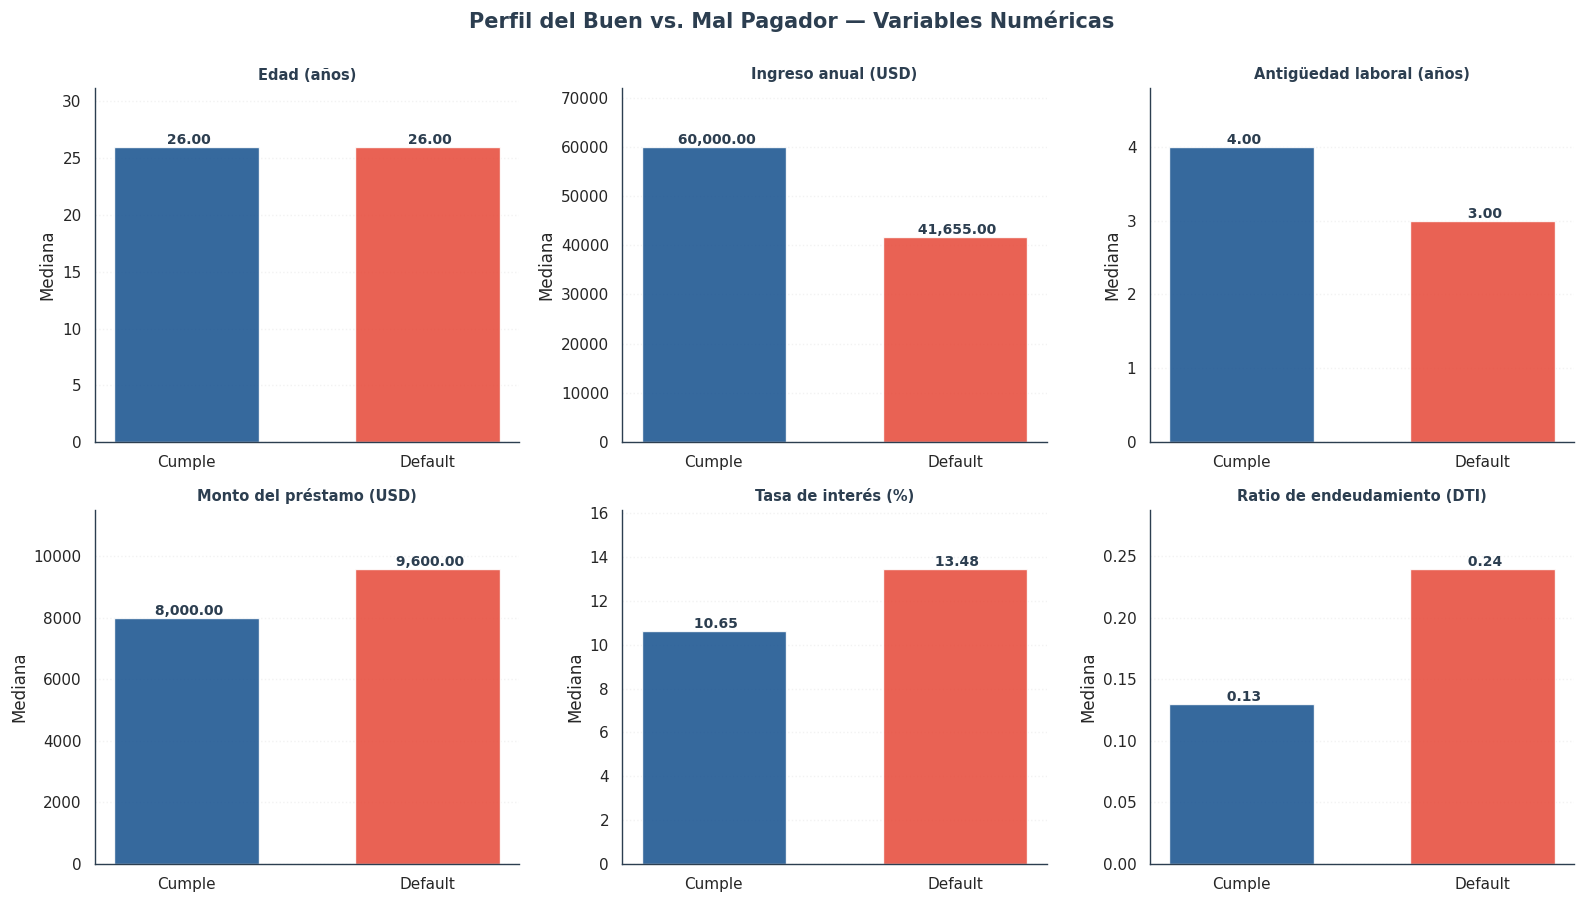

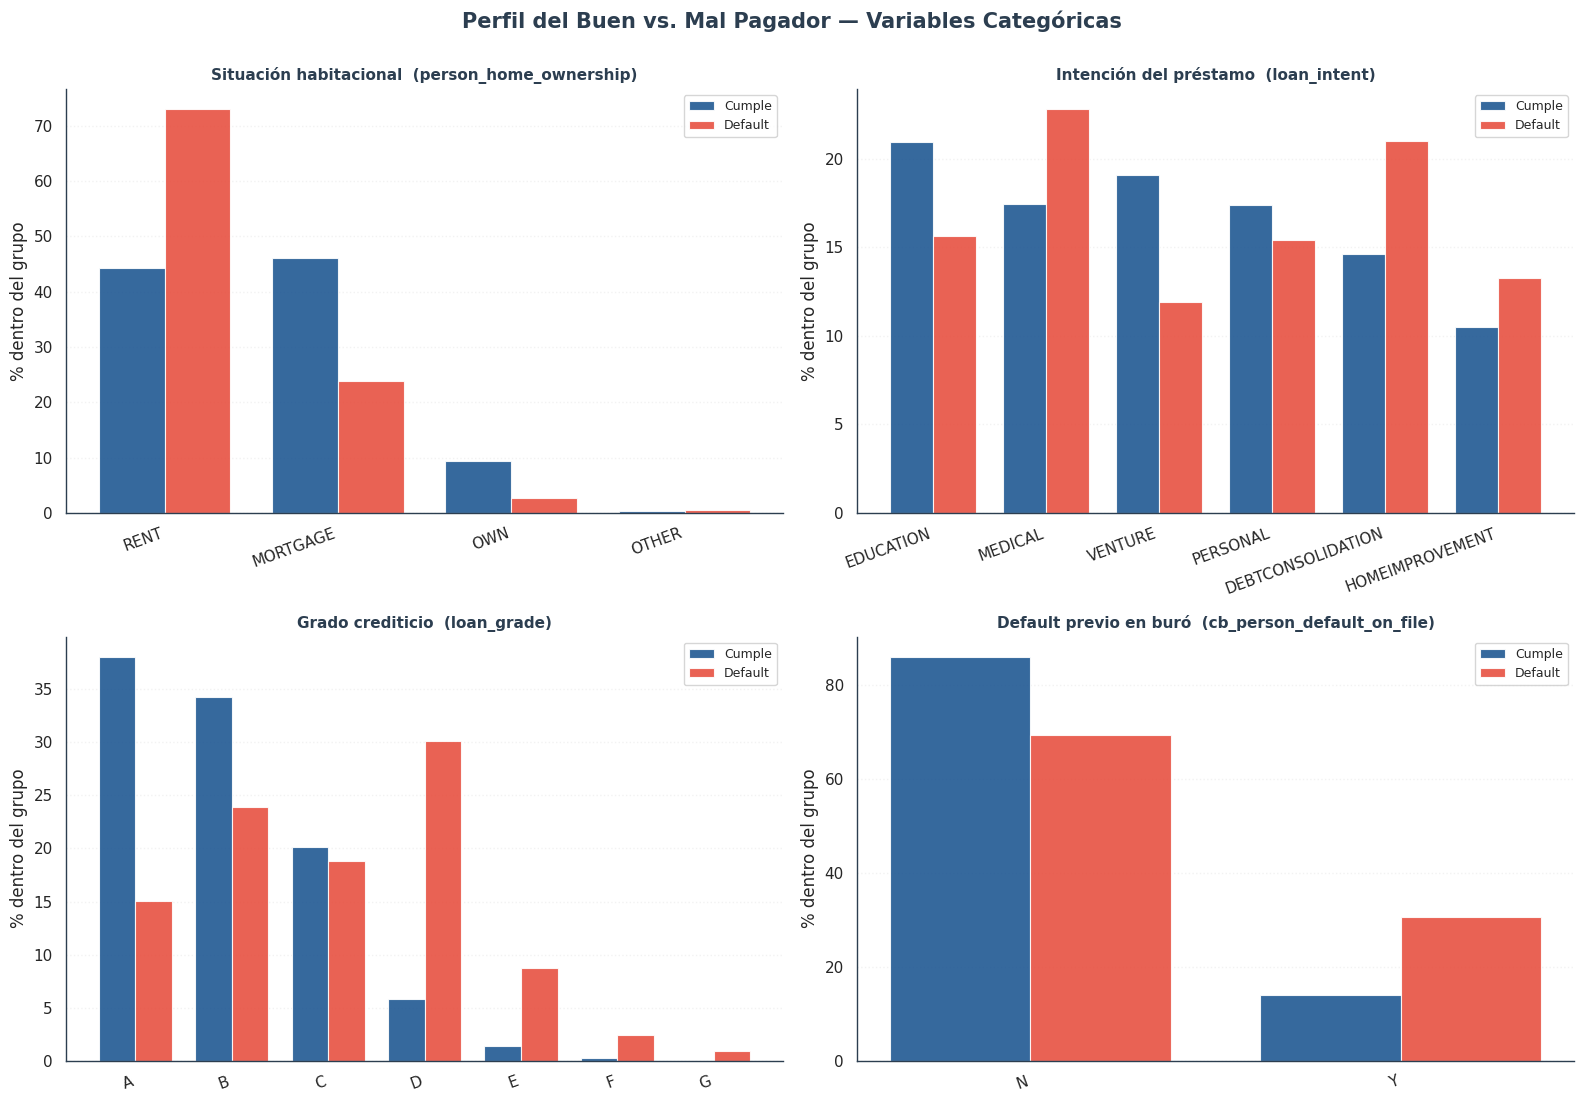

In [19]:
# ===============================================================
# 4.5 PERFIL DEL BUEN vs MAL PAGADOR
# ===============================================================
# Síntesis integradora: contrasta el perfil característico del
# cliente en default (loan_status=1) frente al cumplidor (=0).
# Consolida los hallazgos de las secciones 4.2 a 4.4.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Segmentación de la cartera
default = df_modelo[df_modelo['loan_status'] == 1]
cumple  = df_modelo[df_modelo['loan_status'] == 0]

# ---------------------------------------------------------------
# PARTE A — Perfil en variables numéricas (medianas)
# ---------------------------------------------------------------
variables_num = [
    ('person_age',          'Edad (años)'),
    ('person_income',       'Ingreso anual (USD)'),
    ('person_emp_length',   'Antigüedad laboral (años)'),
    ('loan_amnt',           'Monto del préstamo (USD)'),
    ('loan_int_rate',       'Tasa de interés (%)'),
    ('loan_percent_income', 'Ratio de endeudamiento (DTI)'),
]

print("═" * 76)
print(" PERFIL COMPARATIVO — VARIABLES NUMÉRICAS (mediana de cada grupo)")
print("═" * 76)
print(f"\n {'Variable':<32}{'Cumple':>13}{'Default':>13}{'Diferencia':>15}")
print(" " + "─" * 72)

for var, etiqueta in variables_num:
    med_cumple  = cumple[var].median()
    med_default = default[var].median()
    dif_pct = (med_default - med_cumple) / med_cumple * 100 if med_cumple != 0 else 0
    print(f" {etiqueta:<32}{med_cumple:>13,.2f}{med_default:>13,.2f}"
          f"{dif_pct:>+13.1f}%")
print(" " + "─" * 72)
print(" Diferencia = variación porcentual del perfil default respecto del cumplidor.")

# ---------------------------------------------------------------
# PARTE B — Perfil en variables categóricas (composición por grupo)
# ---------------------------------------------------------------
variables_cat = [
    ('person_home_ownership',     'Situación habitacional'),
    ('loan_intent',               'Intención del préstamo'),
    ('loan_grade',                'Grado crediticio'),
    ('cb_person_default_on_file', 'Default previo en buró'),
]

print("\n" + "═" * 76)
print(" PERFIL COMPARATIVO — VARIABLES CATEGÓRICAS (composición de cada grupo)")
print("═" * 76)

for var, etiqueta in variables_cat:
    comp_cumple  = cumple[var].value_counts(normalize=True) * 100
    comp_default = default[var].value_counts(normalize=True) * 100
    # Orden: ordinal A-G para grado, por frecuencia para el resto
    if var == 'loan_grade':
        categorias = sorted(df_modelo[var].unique())
    else:
        categorias = df_modelo[var].value_counts().index.tolist()

    print(f"\n {etiqueta}  ({var})")
    print(" " + "─" * 60)
    print(f"   {'Categoría':<22}{'Cumple':>12}{'Default':>12}{'Δ pp':>12}")
    print("   " + "·" * 56)
    for cat in categorias:
        c = comp_cumple.get(cat, 0)
        d = comp_default.get(cat, 0)
        delta = d - c
        print(f"   {str(cat):<22}{c:>11.1f}%{d:>11.1f}%{delta:>+10.1f} pp")
print("\n Δ pp = diferencia de peso de la categoría entre el grupo default y el cumplidor.")
print(" Un valor positivo indica que la categoría está sobre-representada en el default.")

# ---------------------------------------------------------------
# Visualización 1 — perfiles numéricos (medianas)
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

COLOR_CUMPLE  = "#1A5490"
COLOR_DEFAULT = "#E74C3C"

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Perfil del Buen vs. Mal Pagador — Variables Numéricas",
             fontsize=15, fontweight='bold', color="#2C3E50", y=1.00)

for ax, (var, etiqueta) in zip(axes.flat, variables_num):
    med_cumple  = cumple[var].median()
    med_default = default[var].median()
    barras = ax.bar(['Cumple', 'Default'], [med_cumple, med_default],
                    color=[COLOR_CUMPLE, COLOR_DEFAULT], alpha=0.88,
                    edgecolor='white', linewidth=1.0, width=0.6)
    for barra, val in zip(barras, [med_cumple, med_default]):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
                f" {val:,.2f}", ha='center', va='bottom',
                fontsize=10, fontweight='bold', color="#2C3E50")
    ax.set_title(etiqueta, fontweight="bold", fontsize=10.5, color="#2C3E50")
    ax.set_ylabel("Mediana")
    ax.set_ylim(0, max(med_cumple, med_default) * 1.20)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Visualización 2 — composición categórica (barras agrupadas)
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Perfil del Buen vs. Mal Pagador — Variables Categóricas",
             fontsize=15, fontweight='bold', color="#2C3E50", y=1.00)

for ax, (var, etiqueta) in zip(axes.flat, variables_cat):
    comp_cumple  = cumple[var].value_counts(normalize=True) * 100
    comp_default = default[var].value_counts(normalize=True) * 100
    if var == 'loan_grade':
        categorias = sorted(df_modelo[var].unique())
    else:
        categorias = df_modelo[var].value_counts().index.tolist()

    valores_c = [comp_cumple.get(c, 0) for c in categorias]
    valores_d = [comp_default.get(c, 0) for c in categorias]

    x = np.arange(len(categorias))
    ancho = 0.38

    ax.bar(x - ancho/2, valores_c, ancho, label='Cumple',
           color=COLOR_CUMPLE, alpha=0.88, edgecolor='white', linewidth=0.8)
    ax.bar(x + ancho/2, valores_d, ancho, label='Default',
           color=COLOR_DEFAULT, alpha=0.88, edgecolor='white', linewidth=0.8)

    ax.set_title(f"{etiqueta}  ({var})", fontweight="bold",
                 fontsize=11, color="#2C3E50")
    ax.set_ylabel("% dentro del grupo")
    ax.set_xticks(x)
    ax.set_xticklabels([str(c) for c in categorias], rotation=20, ha='right')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')

plt.tight_layout()
plt.show()

### Interpretación — El Retrato del Riesgo

El contraste de perfiles consolida los hallazgos del EDA en una caracterización clara y coherente de ambos tipos de cliente.

**El cliente que entra en default** presenta un perfil financiero más tensionado. En las variables numéricas: su ingreso anual es un 30.6% inferior al del cliente cumplidor (mediana de 41.655 frente a 60.000 USD), solicita préstamos de mayor monto (+20%) y, como consecuencia directa, soporta un **ratio de endeudamiento (DTI) un 84.6% más alto** —la diferencia más pronunciada entre ambos perfiles—. Accede al crédito a una tasa de interés sensiblemente mayor (13.5% frente a 10.7%).

En las variables categóricas, la columna de desplazamiento (Δ pp) revela hacia dónde se corre el perfil de riesgo:

- **Situación habitacional**: el inquilino está fuertemente sobre-representado en el default (RENT, +28.8 pp), mientras que el cliente con hipoteca está sub-representado (MORTGAGE, −22.3 pp). La tenencia de un inmueble se asocia a menor riesgo.
- **Grado crediticio**: el desplazamiento es nítido y monótono. Los grados A y B están sub-representados en el default (−23.0 pp y −10.4 pp), mientras que a partir del grado D la representación se invierte, con **D como el grado más sobre-representado (+24.3 pp)**. La frontera C→D vuelve a aparecer como umbral crítico de riesgo, en línea con el análisis bivariado (4.3.1).
- **Default previo en buró**: el antecedente de incumplimiento (categoría Y) más que duplica su peso en el grupo de default (de 14.1% a 30.6%, +16.5 pp), confirmando su poder predictivo.
- **Intención del préstamo**: las finalidades asociadas a fragilidad financiera —gastos médicos (+5.4 pp) y consolidación de deudas (+6.4 pp)— están sobre-representadas, mientras que las planificadas —educación (−5.3 pp), emprendimiento (−7.2 pp)— lo están en el grupo cumplidor.

**Variables sin poder de separación.** La edad es prácticamente idéntica en ambos grupos (mediana de 26 años), lo que confirma —desde esta perspectiva integradora— el bajo poder discriminante ya observado en el análisis bivariado. La antigüedad laboral muestra una diferencia menor (4 frente a 3 años).

**Síntesis de negocio.** El riesgo de default no se explica por un único factor, sino por la **convergencia de capacidad de pago limitada y endeudamiento elevado**: el cliente riesgoso gana menos, pide más y queda con una carga financiera desproporcionada respecto de su ingreso. Este núcleo —DTI, ingreso, tasa de interés y grado crediticio— concentra el poder predictivo del modelo. El retrato resultante es directamente accionable: orienta tanto la selección de variables como los criterios de una eventual política de originación.

## 4.6 Conclusiones del EDA

El Análisis Exploratorio recorrió el universo de modelado de lo general a lo específico —la variable objetivo, cada predictor de forma aislada, su relación con el default y las relaciones entre predictores— con un objetivo: comprender la estructura del riesgo crediticio antes de construir el modelo. Esta sección consolida los hallazgos y define las implicancias para las fases siguientes.

### Hallazgos principales

**1. El riesgo de la cartera está concentrado, no disperso.** La tasa de default base (21.87%) no se distribuye de manera uniforme: se concentra en perfiles identificables. El cliente en default se caracteriza por la convergencia de **capacidad de pago limitada y endeudamiento elevado** —gana menos, pide más y soporta una carga financiera desproporcionada—.

**2. Variables de alto poder discriminante.** Cuatro variables mostraron una capacidad de separación sólida y un ordenamiento del riesgo coherente:

- **Ratio de endeudamiento (DTI)** — la brecha más amplia del análisis (+60.6 pp entre deciles extremos), con relación monótona creciente.
- **Grado crediticio** — discriminación monótona perfecta de A a G, con una frontera crítica de riesgo en la transición C→D.
- **Tasa de interés** — monótona creciente, coherente con el grado crediticio.
- **Default previo en buró** — duplica la tasa de default de quienes lo registran.

**3. Variables de poder discriminante moderado o bajo.** El ingreso aporta señal clara (relación decreciente con el default). El monto del préstamo presenta una relación **no monótona en forma de U**, con implicancias para la elección de modelo. La edad y la antigüedad laboral mostraron un poder discriminante reducido.

**4. Estructura de correlaciones favorable.** Las variables numéricas presentan correlaciones mayormente bajas, un escenario favorable para la regresión logística. Se identificó un único caso de multicolinealidad alta —edad e historial crediticio (r = 0.88)— que requerirá tratamiento en la selección de variables.

### Implicancias para las fases siguientes

**Para Feature Engineering (Capítulo 5):**

- Las variables con asimetría fuerte —ingreso, monto del préstamo— son candidatas a **transformación logarítmica** para el componente de regresión logística.
- La relación no lineal del monto del préstamo requerirá **transformación o discretización** para ser capturada por un modelo lineal.
- El par de variables con multicolinealidad alta deberá resolverse conservando una de las dos.
- Los comportamientos de riesgo identificados durante el Gobierno de Datos —sobre-endeudamiento, primer empleo— se incorporarán como **variables derivadas**.
- El poder discriminante observado cualitativamente se **cuantificará formalmente** mediante Weight of Evidence (WoE) e Information Value (IV).

**Para el modelado:**

- El desbalance de clases (21.87% de default) confirma que la evaluación del modelo se basará en **AUC-ROC y el estadístico KS**, no en accuracy.
- La presencia de relaciones no lineales (monto del préstamo) y de un ordenamiento monótono claro en otras variables justifica la estrategia de **modelos duales**: una regresión logística interpretable y un modelo XGBoost de mayor capacidad, contrastados bajo un esquema Champion–Challenger.

### Limitaciones del análisis

Cabe señalar que el dataset utilizado, de naturaleza académica, presenta diferencias respecto de un entorno productivo bancario: la tasa de default es superior a la de una cartera real, y no se dispone de variables de comportamiento transaccional, datos de bureau detallados ni ventanas temporales de observación y performance. En consecuencia, el modelo desarrollado debe interpretarse como un **ejercicio metodológico riguroso sobre datos de referencia**, no como un modelo calibrado a una cartera específica. La metodología aplicada —gobierno de datos, tratamiento de nulos, análisis exploratorio y validación— es, no obstante, plenamente trasladable a un contexto productivo.

---

Con la estructura del riesgo comprendida y las decisiones de preparación definidas, el **Capítulo 5 — Feature Engineering** aborda la construcción y transformación de variables que alimentarán los modelos de scoring.

## 5.1 Weight of Evidence (WoE) e Information Value (IV)

El análisis bivariado (Capítulo 4) evaluó el poder discriminante de cada variable de forma visual y cualitativa. Esta sección lo **cuantifica formalmente** mediante las dos métricas estándar de la industria de credit scoring: el Weight of Evidence y el Information Value.

### Weight of Evidence (WoE)

El WoE mide, para cada grupo de una variable, su inclinación relativa hacia el incumplimiento o el cumplimiento. Para un grupo dado se define como:

$$WoE = \ln\left(\frac{\text{% de buenos en el grupo}}{\text{% de malos en el grupo}}\right)$$

donde "buenos" son los clientes que cumplen y "malos" los que entran en default. La interpretación:

- **WoE > 0** — el grupo concentra más cumplidores que la media: perfil de menor riesgo.
- **WoE < 0** — el grupo concentra más default que la media: perfil de mayor riesgo.
- **WoE ≈ 0** — el grupo se comporta como el promedio de la cartera.

El WoE transforma cualquier variable —numérica o categórica— a una **escala continua y monótona de riesgo**. En este proyecto, el WoE cumple la función de **diagnóstico del poder predictivo** y de **fundamento para la selección de variables** (sección 5.5); la representación final de las variables que ingresan al modelo se define en las secciones 5.3 a 5.6.

### Information Value (IV)

El Information Value responde a una pregunta concreta: **¿cuánto ayuda esta variable a separar a los clientes que cumplen de los que entran en default?**

La lógica es la siguiente. Una variable se divide en grupos y, para cada grupo, se observa qué proporción del total de "buenos" (clientes que cumplen) y qué proporción del total de "malos" (clientes en default) cae en él:

- Si un grupo concentra muchos buenos y pocos malos —o viceversa—, ese grupo **separa** las dos poblaciones: aporta información.
- Si un grupo contiene buenos y malos en proporciones similares, no distingue entre ambos: no aporta información.

El IV suma la capacidad de separación de todos los grupos en un **único número** que resume el poder predictivo total de la variable. A mayor separación entre las poblaciones de buenos y malos, mayor IV. Su interpretación sigue la escala convencional de Siddiqi:

| Information Value | Poder predictivo |
|---|---|
| < 0,02 | Sin poder predictivo |
| 0,02 – 0,1 | Débil |
| 0,1 – 0,3 | Medio |
| 0,3 – 0,5 | Fuerte |
| > 0,5 | Muy fuerte — revisar posible sobreajuste |

### Cálculo del IV

El IV se calcula a partir de los mismos componentes que el WoE. Para cada grupo de la variable:

$$IV_{grupo} = \left(\%buenos - \%malos\right) \times WoE_{grupo}$$

donde *%buenos* y *%malos* son la proporción del total de cumplidores y de incumplidores que cae en el grupo. El IV total de la variable es la suma de los aportes de todos sus grupos:

$$IV = \sum_{grupos} \left(\%buenos - \%malos\right) \times \ln\left(\frac{\%buenos}{\%malos}\right)$$

El factor (%buenos − %malos) es la clave del indicador: un grupo donde ambas poblaciones están equilibradas aporta un valor cercano a cero —no discrimina—, mientras que un grupo con fuerte desbalance entre buenos y malos aporta un valor elevado. El IV total mide, así, la capacidad de separación acumulada de la variable.

Un IV inferior a 0,02 indica que la variable no logra separar las poblaciones de forma aprovechable, y se considera sin poder predictivo. En el extremo opuesto, un IV superior a 0,5 no se acepta sin más: puede señalar que la variable está vinculada de forma casi directa a la variable objetivo (*data leakage*), lo que requiere revisión. El IV permite **ordenar las variables por capacidad discriminante** y orientar la selección de predictores.

══════════════════════════════════════════════════════════════════════════
 RANKING DE VARIABLES POR INFORMATION VALUE (IV)
══════════════════════════════════════════════════════════════════════════

 Variable                                IV          Poder predictivo
 ────────────────────────────────────────────────────────────────────
 Grado crediticio                    0.8814      Muy fuerte (revisar)
 Ratio de endeudamiento (DTI)        0.8727      Muy fuerte (revisar)
 Tasa de interés                     0.7264      Muy fuerte (revisar)
 Ingreso anual                       0.4699                    Fuerte
 Situación habitacional              0.3758                    Fuerte
 Default previo en buró              0.1638                     Medio
 Intención del préstamo              0.0961                     Débil
 Monto del préstamo                  0.0855                     Débil
 Antigüedad laboral                  0.0610                     Débil
 Edad                         

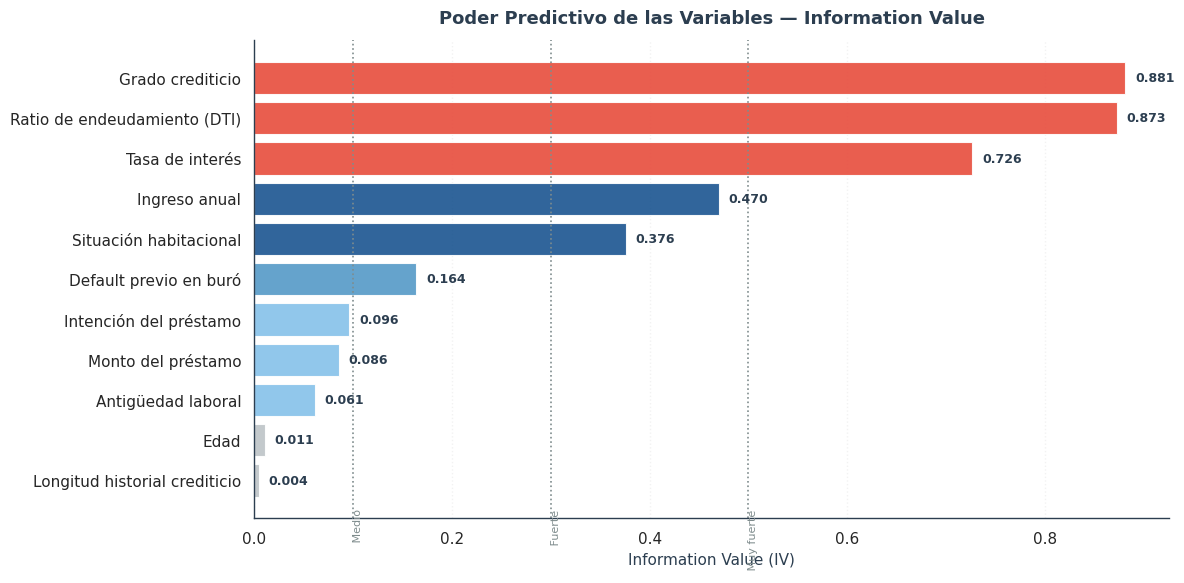

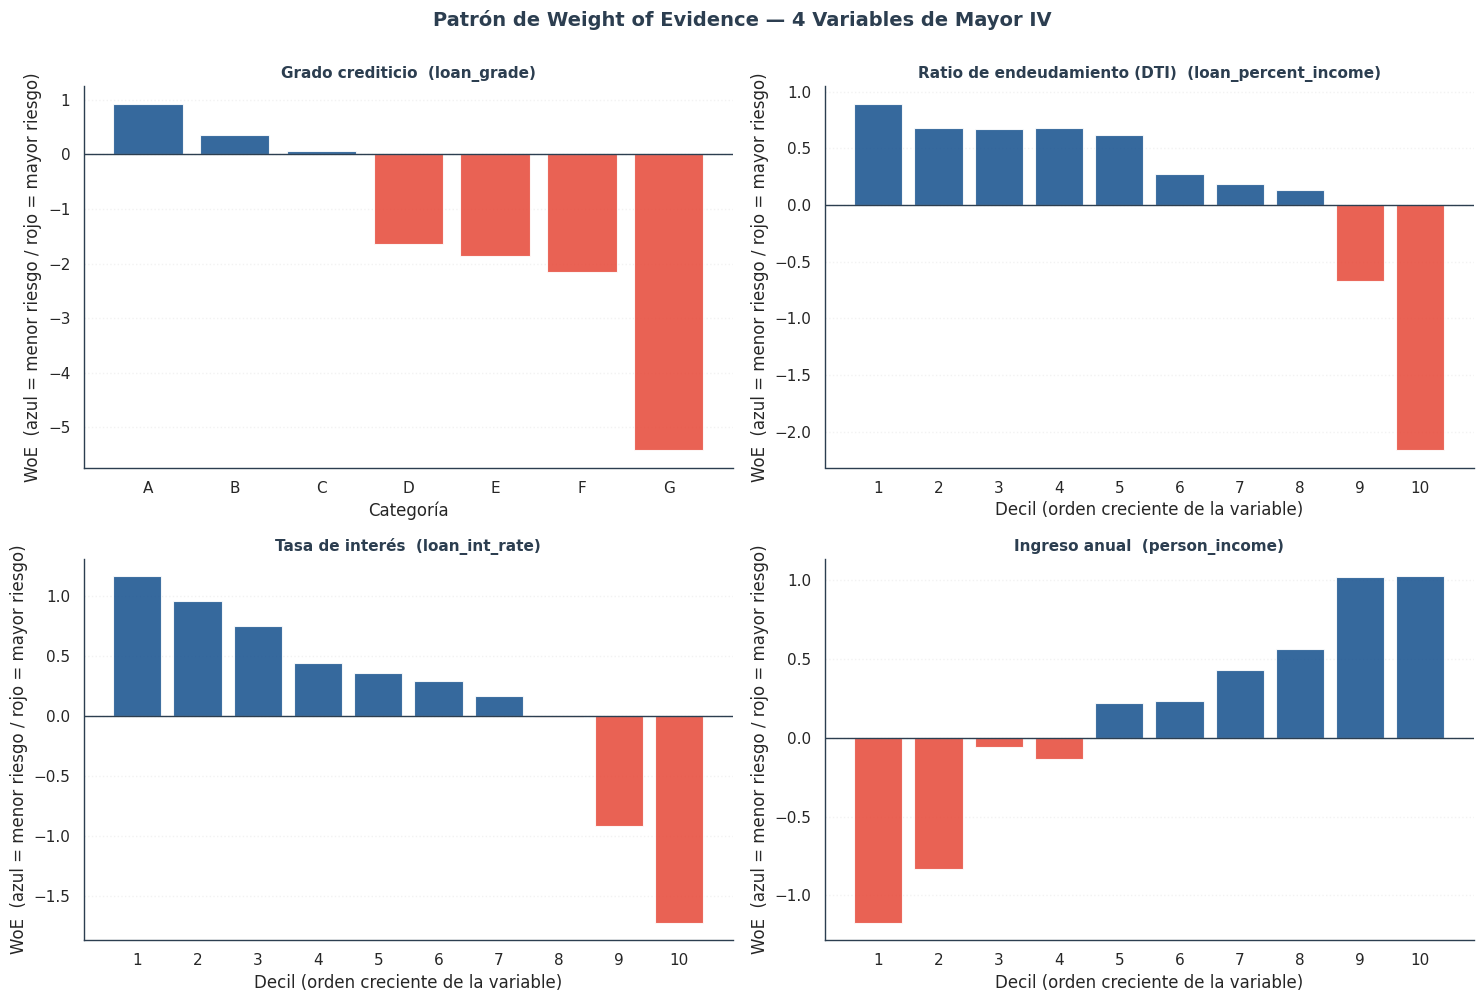

In [20]:
# ===============================================================
# 5.1 WEIGHT OF EVIDENCE (WoE) E INFORMATION VALUE (IV)
# ===============================================================
# Cuantifica el poder predictivo de cada variable mediante WoE e IV,
# las métricas estándar de credit scoring. Las variables numéricas
# se discretizan en deciles; las categóricas usan sus categorías.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Función: cálculo de WoE e IV para una variable
# ---------------------------------------------------------------
def calcular_woe_iv(df, var, target='loan_status', es_numerica=False, n_bins=10):
    d = df[[var, target]].copy()

    # Variables numéricas: discretizar en deciles
    if es_numerica:
        d['grupo'] = pd.qcut(d[var], q=n_bins, duplicates='drop')
    else:
        d['grupo'] = d[var]

    # Conteo de buenos (target=0) y malos (target=1) por grupo
    tabla = d.groupby('grupo', observed=True)[target].agg(
        total='count', malos='sum')
    tabla['buenos'] = tabla['total'] - tabla['malos']

    total_buenos = tabla['buenos'].sum()
    total_malos  = tabla['malos'].sum()

    # Distribución de buenos y malos (con corrección para evitar log(0))
    tabla['dist_buenos'] = tabla['buenos'] / total_buenos
    tabla['dist_malos']  = tabla['malos']  / total_malos
    eps = 0.0001
    tabla['dist_buenos'] = tabla['dist_buenos'].replace(0, eps)
    tabla['dist_malos']  = tabla['dist_malos'].replace(0, eps)

    # WoE e IV por grupo
    tabla['woe'] = np.log(tabla['dist_buenos'] / tabla['dist_malos'])
    tabla['iv_grupo'] = (tabla['dist_buenos'] - tabla['dist_malos']) * tabla['woe']
    tabla['tasa_default'] = tabla['malos'] / tabla['total'] * 100

    iv_total = tabla['iv_grupo'].sum()
    return tabla, iv_total

# ---------------------------------------------------------------
# Definición de variables a evaluar
# ---------------------------------------------------------------
variables = [
    ('loan_percent_income',       'Ratio de endeudamiento (DTI)', True),
    ('loan_int_rate',             'Tasa de interés',              True),
    ('person_income',             'Ingreso anual',                True),
    ('loan_amnt',                 'Monto del préstamo',           True),
    ('person_age',                'Edad',                         True),
    ('person_emp_length',         'Antigüedad laboral',           True),
    ('cb_person_cred_hist_length','Longitud historial crediticio',True),
    ('loan_grade',                'Grado crediticio',             False),
    ('person_home_ownership',     'Situación habitacional',       False),
    ('loan_intent',               'Intención del préstamo',       False),
    ('cb_person_default_on_file', 'Default previo en buró',       False),
]

# ---------------------------------------------------------------
# Cálculo de IV para todas las variables
# ---------------------------------------------------------------
def clasificar_iv(iv):
    if iv < 0.02:   return "Sin poder"
    elif iv < 0.1:  return "Débil"
    elif iv < 0.3:  return "Medio"
    elif iv < 0.5:  return "Fuerte"
    else:           return "Muy fuerte (revisar)"

resultados_iv = []
tablas_woe = {}
for var, etiqueta, es_num in variables:
    tabla, iv = calcular_woe_iv(df_modelo, var, es_numerica=es_num)
    tablas_woe[var] = (tabla, etiqueta)
    resultados_iv.append((etiqueta, var, iv, clasificar_iv(iv)))

# Ordenar por IV descendente
resultados_iv.sort(key=lambda x: x[2], reverse=True)

# ---------------------------------------------------------------
# Reporte — ranking de variables por IV
# ---------------------------------------------------------------
print("═" * 74)
print(" RANKING DE VARIABLES POR INFORMATION VALUE (IV)")
print("═" * 74)
print(f"\n {'Variable':<32}{'IV':>10}{'Poder predictivo':>26}")
print(" " + "─" * 68)
for etiqueta, var, iv, clase in resultados_iv:
    print(f" {etiqueta:<32}{iv:>10.4f}{clase:>26}")
print(" " + "─" * 68)

# ---------------------------------------------------------------
# Visualización 1 — ranking de IV
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, ax = plt.subplots(figsize=(12, 6))

etiquetas = [r[0] for r in resultados_iv]
ivs = [r[2] for r in resultados_iv]

# Color según fuerza del IV
def color_iv(iv):
    if iv < 0.02:   return "#BDC3C7"
    elif iv < 0.1:  return "#85C1E9"
    elif iv < 0.3:  return "#5499C7"
    elif iv < 0.5:  return "#1A5490"
    else:           return "#E74C3C"

colores = [color_iv(iv) for iv in ivs]

barras = ax.barh(etiquetas, ivs, color=colores, alpha=0.9,
                 edgecolor='white', linewidth=0.8)
for barra, iv in zip(barras, ivs):
    ax.text(barra.get_width() + 0.01, barra.get_y() + barra.get_height()/2,
            f"{iv:.3f}", va='center', fontsize=9, fontweight='bold',
            color="#2C3E50")

# Líneas de referencia de los umbrales de Siddiqi
for umbral, txt in [(0.1, 'Medio'), (0.3, 'Fuerte'), (0.5, 'Muy fuerte')]:
    ax.axvline(umbral, color="#7F8C8D", linestyle=":", linewidth=1.2)
    ax.text(umbral, len(etiquetas) - 0.3, f' {txt}', fontsize=8,
            color="#7F8C8D", rotation=90, va='top')

ax.set_xlabel("Information Value (IV)", fontsize=11, color="#2C3E50")
ax.set_title("Poder Predictivo de las Variables — Information Value",
             fontweight='bold', fontsize=13, color="#2C3E50", pad=12)
ax.invert_yaxis()
ax.grid(True, alpha=0.25, linestyle=':', axis='x')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# Visualización 2 — patrón WoE de las variables más predictivas
# ---------------------------------------------------------------
top4 = [r[1] for r in resultados_iv[:4]]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Patrón de Weight of Evidence — 4 Variables de Mayor IV",
             fontsize=14, fontweight='bold', color="#2C3E50", y=1.00)

for ax, var in zip(axes.flat, top4):
    tabla, etiqueta = tablas_woe[var]
    posiciones = range(len(tabla))
    colores_woe = ["#1A5490" if w >= 0 else "#E74C3C" for w in tabla['woe']]

    ax.bar(posiciones, tabla['woe'], color=colores_woe, alpha=0.88,
           edgecolor='white', linewidth=0.8)
    ax.axhline(0, color="#2C3E50", linewidth=1.0)

    # Etiquetas del eje X: categorías reales si es categórica,
    # número de decil si es numérica
    es_numerica = dict((v[0], v[2]) for v in variables)[var]
    if es_numerica:
        etiquetas_x = [str(i + 1) for i in posiciones]
        ax.set_xlabel("Decil (orden creciente de la variable)")
    else:
        etiquetas_x = [str(c) for c in tabla.index]
        ax.set_xlabel("Categoría")

    ax.set_title(f"{etiqueta}  ({var})", fontweight="bold",
                 fontsize=11, color="#2C3E50")
    ax.set_ylabel("WoE  (azul = menor riesgo / rojo = mayor riesgo)")
    ax.set_xticks(list(posiciones))
    ax.set_xticklabels(etiquetas_x)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')

plt.tight_layout()
plt.show()

### Interpretación del Análisis WoE / IV

La cuantificación mediante WoE e IV confirma y precisa los hallazgos cualitativos del EDA, ordenando las variables por su poder predictivo.

**Variables de mayor poder predictivo.** Tres variables alcanzan un IV superior a 0,5: grado crediticio (0,88), ratio de endeudamiento (0,87) y tasa de interés (0,73). Su patrón de WoE es coherente y refleja un ordenamiento claro del riesgo: en el grado crediticio, los grados A y B presentan WoE positivo (menor riesgo) y los grados D a G, WoE negativo y creciente en magnitud; en el DTI y la tasa de interés, el WoE decrece de forma consistente al aumentar la variable.

**Revisión del IV elevado.** Un IV superior a 0,5 exige una revisión específica: en credit scoring, valores tan altos pueden indicar *data leakage* —la presencia de una variable que anticipa el resultado de forma casi directa—. En este caso se descarta esa posibilidad: el grado crediticio, el ratio de endeudamiento y la tasa de interés son atributos disponibles **en el momento de la originación**, anteriores a la materialización del default, por lo que no constituyen fuga de información. Los valores elevados se atribuyen a la naturaleza del dataset, de origen académico y con variables fuertemente alineadas al resultado. En una cartera productiva, estos indicadores presentarían un IV más moderado; las variables se conservan, dejando constancia de esta consideración.

**Variables de poder intermedio.** El ingreso anual (IV 0,47) y la situación habitacional (IV 0,38) se ubican en el rango "fuerte", y el default previo en buró (IV 0,16) en el rango "medio". Todas aportan capacidad discriminante relevante y un patrón de WoE interpretable.

**Variables de bajo o nulo poder predictivo.** La intención del préstamo (IV 0,10), el monto del préstamo (IV 0,09) y la antigüedad laboral (IV 0,06) presentan un poder predictivo débil. La edad (IV 0,01) y la longitud del historial crediticio (IV 0,004) carecen de poder predictivo individual.

**Un hallazgo relevante para la selección de variables.** La longitud del historial crediticio (`cb_person_cred_hist_length`) presenta un IV prácticamente nulo. Esta variable es, además, una de las dos que conforman el par de multicolinealidad alta identificado en el EDA (correlación de 0,88 con la edad). El hecho de que no aporte poder predictivo resuelve de antemano la decisión de la sección 5.5: ante dos variables redundantes entre sí, la que carece de capacidad discriminante es la candidata natural a ser descartada.

**Síntesis.** El análisis WoE/IV confirma que el núcleo predictivo se concentra en el grado crediticio, el endeudamiento, la tasa de interés y el ingreso. El WoE/IV se utiliza en este proyecto como instrumento de cuantificación del poder predictivo y de selección de variables (sección 5.5), no como transformación que alimente el modelo: la representación final de las variables se define en las secciones 5.3 (transformación logarítmica de numéricas) y 5.4 (codificación de categóricas).

**Nota metodológica sobre el cálculo.** El WoE/IV se computó sobre el universo completo, previo a la partición train/test de la sección 5.6. En un entorno productivo, este cálculo se restringiría al conjunto de entrenamiento para evitar cualquier influencia del test sobre la selección de variables. Dado que aquí el WoE/IV se emplea exclusivamente como filtro de selección —y no como transformación que ingrese al modelo—, el impacto de esta simplificación sobre el desempeño reportado es despreciable. Se deja constancia como buena práctica de Model Risk Management.

## 5.2 Variables Derivadas (Knowledge-Based Features)

Las variables derivadas son predictores construidos a partir del **conocimiento de negocio** acumulado en las fases anteriores del proyecto. No forman parte del dataset original: se crean para representar de forma explícita patrones de riesgo que el análisis identificó pero que ninguna variable individual captura directamente.

Se construyen dos variables derivadas, cada una con origen documentado en una fase previa del proyecto:

| Variable derivada | Origen del hallazgo | Lógica de negocio |
|---|---|---|
| `is_high_dti` | Tier 3 — screening económico | El sobre-endeudamiento (DTI > 40%) se identificó como señal de riesgo; se decidió modelarlo, no filtrarlo |
| `is_first_job` | Perfilado e imputación | La antigüedad laboral nula identifica a un solicitante en su primer empleo: perfil sin trayectoria laboral consolidada |

El propósito de estas variables es doble: aportar **interpretabilidad** al modelo —un indicador binario de sobre-endeudamiento es directamente comunicable en una scorecard— e incorporar **conocimiento de negocio estructurado**. El propósito de estas variables es doble: aportar **interpretabilidad** al modelo —un indicador binario de sobre-endeudamiento es directamente comunicable en una scorecard— e incorporar **conocimiento de negocio estructurado**.

Su contribución no se asume: se valida mediante el **Information Value (IV)**, la métrica de poder predictivo definida en la sección 5.1. Se aplica el umbral convencional de Siddiqi: una variable con IV inferior a **0,02** se considera sin poder predictivo y no se incorpora al modelo. Solo las variables derivadas que superan ese umbral pasan a formar parte del conjunto de predictores. Una variable derivada solo se incorpora al modelo si demuestra poder discriminante.

══════════════════════════════════════════════════════════════════════
 VARIABLES DERIVADAS — VALIDACIÓN DE PODER DISCRIMINANTE
══════════════════════════════════════════════════════════════════════

 Tasa de default base de la cartera: 21.87%

 is_high_dti
 ────────────────────────────────────────────────────────────
   Registros con valor 1:   1,118  (3.5% de la base)
   Default si = 1:          74.15%
   Default si = 0:          20.00%
   Brecha:                  +54.15 pp
   Information Value (IV):  0.2576  →  Medio

 is_first_job
 ────────────────────────────────────────────────────────────
   Registros con valor 1:   4,083  (12.6% de la base)
   Default si = 1:          27.97%
   Default si = 0:          20.99%
   Brecha:                  +6.98 pp
   Information Value (IV):  0.0171  →  Sin poder

══════════════════════════════════════════════════════════════════════
 DECISIÓN DE INCORPORACIÓN
══════════════════════════════════════════════════════════════════════

 Criterio: se in

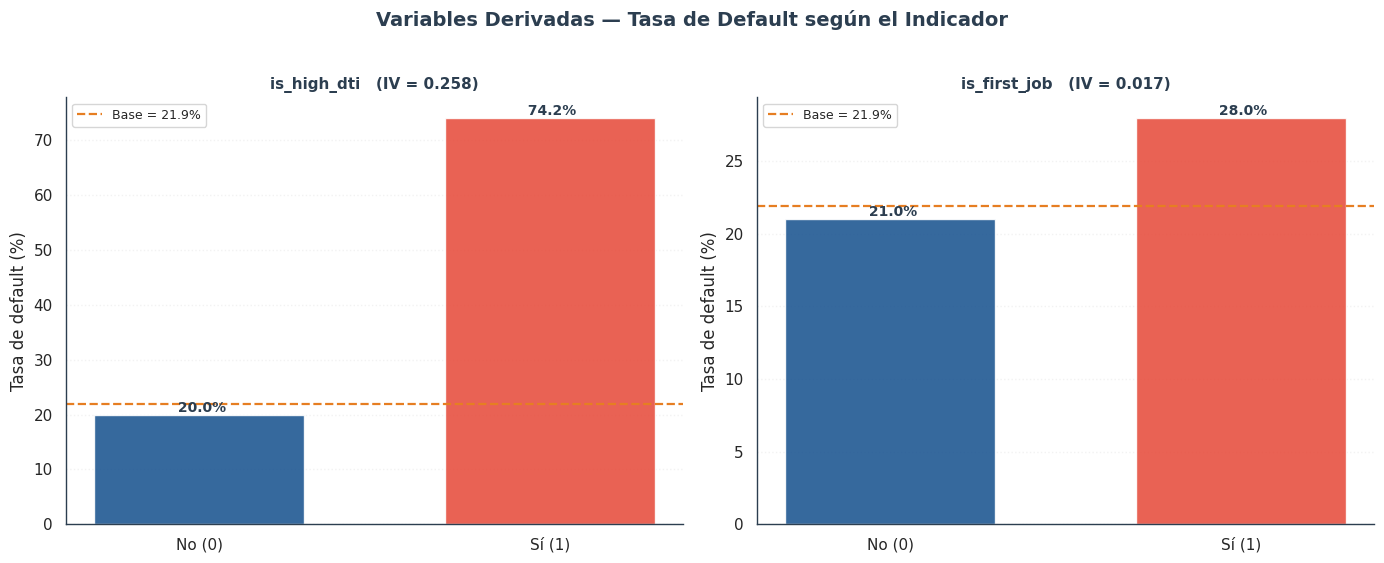

In [21]:
# ===============================================================
# 5.2 VARIABLES DERIVADAS (KNOWLEDGE-BASED FEATURES)
# ===============================================================
# Construye dos variables derivadas a partir de hallazgos de negocio
# documentados (Tier 3 y perfilado), y valida su poder discriminante
# mediante Information Value. Solo se conservan las que aportan.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_fe = df_modelo.copy()

# ---------------------------------------------------------------
# Construcción de las variables derivadas
# ---------------------------------------------------------------
# 1. is_high_dti — sobre-endeudamiento (origen: Tier 3)
UMBRAL_DTI_ALTO = 0.40
df_fe['is_high_dti'] = (df_fe['loan_percent_income'] > UMBRAL_DTI_ALTO).astype(int)

# 2. is_first_job — primer empleo (origen: perfilado / imputación)
df_fe['is_first_job'] = (df_fe['person_emp_length'] == 0).astype(int)

derivadas = ['is_high_dti', 'is_first_job']

# ---------------------------------------------------------------
# Función: IV de una variable categórica/binaria
# ---------------------------------------------------------------
def calcular_iv(df, var, target='loan_status'):
    d = df.groupby(var)[target].agg(total='count', malos='sum')
    d['buenos'] = d['total'] - d['malos']
    tot_b, tot_m = d['buenos'].sum(), d['malos'].sum()
    eps = 0.0001
    d['dist_b'] = (d['buenos'] / tot_b).replace(0, eps)
    d['dist_m'] = (d['malos']  / tot_m).replace(0, eps)
    d['woe'] = np.log(d['dist_b'] / d['dist_m'])
    d['iv']  = (d['dist_b'] - d['dist_m']) * d['woe']
    return d['iv'].sum()

def clasificar_iv(iv):
    if iv < 0.02:   return "Sin poder"
    elif iv < 0.1:  return "Débil"
    elif iv < 0.3:  return "Medio"
    elif iv < 0.5:  return "Fuerte"
    else:           return "Muy fuerte"

# ---------------------------------------------------------------
# Validación del poder discriminante
# ---------------------------------------------------------------
tasa_base = df_fe['loan_status'].mean() * 100
UMBRAL_IV_MINIMO = 0.02   # criterio Siddiqi: por debajo, sin poder predictivo

print("═" * 70)
print(" VARIABLES DERIVADAS — VALIDACIÓN DE PODER DISCRIMINANTE")
print("═" * 70)
print(f"\n Tasa de default base de la cartera: {tasa_base:.2f}%\n")

resultados = {}
for var in derivadas:
    n_1   = df_fe[var].sum()
    pct_1 = n_1 / len(df_fe) * 100
    def_1 = df_fe[df_fe[var] == 1]['loan_status'].mean() * 100
    def_0 = df_fe[df_fe[var] == 0]['loan_status'].mean() * 100
    brecha = def_1 - def_0
    iv = calcular_iv(df_fe, var)
    resultados[var] = {'iv': iv, 'brecha': brecha, 'def_1': def_1,
                       'def_0': def_0, 'n_1': n_1, 'pct_1': pct_1}

    print(f" {var}")
    print(" " + "─" * 60)
    print(f"   Registros con valor 1:   {n_1:,}  ({pct_1:.1f}% de la base)")
    print(f"   Default si = 1:          {def_1:.2f}%")
    print(f"   Default si = 0:          {def_0:.2f}%")
    print(f"   Brecha:                  {brecha:+.2f} pp")
    print(f"   Information Value (IV):  {iv:.4f}  →  {clasificar_iv(iv)}")
    print()

# ---------------------------------------------------------------
# Decisión: conservar o descartar según IV
# ---------------------------------------------------------------
print("═" * 70)
print(" DECISIÓN DE INCORPORACIÓN")
print("═" * 70)
print(f"\n Criterio: se incorpora la variable si su IV ≥ {UMBRAL_IV_MINIMO} "
      f"(umbral Siddiqi).\n")

conservadas, descartadas = [], []
for var in derivadas:
    iv = resultados[var]['iv']
    if iv >= UMBRAL_IV_MINIMO:
        conservadas.append(var)
        print(f"  ✓ {var:<16} IV = {iv:.4f}  →  se incorpora al modelo")
    else:
        descartadas.append(var)
        print(f"  ✗ {var:<16} IV = {iv:.4f}  →  se descarta (sin poder predictivo)")

# Eliminar del dataframe las descartadas
if descartadas:
    df_fe = df_fe.drop(columns=descartadas)
print(f"\n Variables derivadas finales en df_fe: {conservadas}")
print("═" * 70)

# ---------------------------------------------------------------
# Visualización — poder discriminante de las variables derivadas
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Variables Derivadas — Tasa de Default según el Indicador",
             fontsize=14, fontweight='bold', color="#2C3E50", y=1.02)

COLOR_BAJO, COLOR_ALTO = "#1A5490", "#E74C3C"

for ax, var in zip(axes, derivadas):
    r = resultados[var]
    barras = ax.bar(['No (0)', 'Sí (1)'], [r['def_0'], r['def_1']],
                    color=[COLOR_BAJO, COLOR_ALTO], alpha=0.88,
                    edgecolor='white', linewidth=1.0, width=0.6)
    for barra, val in zip(barras, [r['def_0'], r['def_1']]):
        ax.text(barra.get_x() + barra.get_width()/2, barra.get_height(),
                f" {val:.1f}%", ha='center', va='bottom',
                fontsize=10, fontweight='bold', color="#2C3E50")
    ax.axhline(tasa_base, color="#E67E22", linestyle="--", linewidth=1.6,
               label=f"Base = {tasa_base:.1f}%")
    ax.set_title(f"{var}   (IV = {r['iv']:.3f})",
                 fontweight="bold", fontsize=11, color="#2C3E50")
    ax.set_ylabel("Tasa de default (%)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.25, linestyle=':', axis='y')

plt.tight_layout()
plt.show()

### Interpretación de las Variables Derivadas

La validación mediante Information Value arrojó resultados diferenciados para las dos variables propuestas.

**`is_high_dti` — incorporada.** El indicador de sobre-endeudamiento (DTI > 40%) alcanza un IV de 0,258, dentro del rango de poder predictivo "medio". Los registros marcados con este indicador presentan una tasa de default del 74,2%, frente al 20,0% del resto —una brecha de 54 puntos porcentuales—. La variable confirma cuantitativamente el hallazgo del Tier 3: el sobre-endeudamiento es una señal de riesgo sustantiva. Se incorpora al modelo, aportando además interpretabilidad —un indicador binario de sobre-endeudamiento es directamente comunicable en una scorecard—.

**`is_first_job` — descartada.** El indicador de primer empleo (antigüedad laboral nula) presenta un IV de 0,017, por debajo del umbral de 0,02 que delimita el poder predictivo mínimo. Aunque la diferencia de tasa de default entre grupos no es nula (+6,98 pp), su magnitud y la distribución de la población no generan capacidad discriminante suficiente. Este resultado ilustra una distinción metodológica relevante: una brecha aparente de tasa de default no garantiza poder predictivo —el Information Value, al ponderar la separación de las distribuciones de buenos y malos, ofrece una medida más rigurosa—. La variable se descarta del modelo.

**Síntesis.** De las dos variables derivadas propuestas, una demuestra poder discriminante y se incorpora (`is_high_dti`), y otra se descarta por no superar el umbral mínimo (`is_first_job`). El proceso —construir variables a partir de conocimiento de negocio y validarlas con un criterio objetivo antes de incorporarlas— refleja la práctica estándar de desarrollo de modelos: una variable se incluye por evidencia de su aporte, no por la plausibilidad de su fundamento.

## 5.3 Transformación de Variables Numéricas

El análisis univariado (4.2.1) identificó variables numéricas con **asimetría fuerte**: distribuciones con una cola larga que concentra la mayoría de los datos en un extremo. Esta característica afecta a los modelos lineales —como la regresión logística—, cuyos coeficientes son sensibles a los valores extremos de las colas.
### Qué es la asimetría (*skew*)

El **skew** o asimetría es un número que mide cuán "torcida" está la distribución de una variable:

- **skew ≈ 0** — distribución simétrica, equilibrada en torno a su centro (forma de campana).
- **skew alto y positivo** — la mayoría de los valores se concentra en la zona baja y existe una **cola larga hacia los valores altos**. Es el caso del ingreso: la mayor parte de los solicitantes gana montos moderados y unos pocos ganan cifras muy elevadas.

Como referencia, un |skew| por debajo de 0,5 indica una distribución aproximadamente simétrica, y un |skew| igual o superior a 1,0 indica asimetría fuerte. El objetivo de la transformación logarítmica es, precisamente, **reducir el skew**: llevar una distribución muy asimétrica hacia una forma más simétrica, que los modelos lineales puedan aprovechar mejor. En esta sección, el skew se reporta antes y después de cada transformación para medir su efectividad.

Esta sección aplica transformaciones que corrigen la asimetría, mejorando la adecuación de las variables al componente de regresión logística del proyecto.

### Criterios

**Transformación logarítmica.** Se aplica a las variables con asimetría fuerte (skew elevado). El logaritmo comprime la cola de la distribución, aproximándola a una forma simétrica. Se utiliza la función `log1p` —logaritmo de (1 + x)— que maneja correctamente los valores iguales a cero.

**Las transformaciones no reemplazan las variables originales.** Cada transformación genera una **columna nueva**, conservando la variable original. La razón es la estrategia de modelos duales: la regresión logística utilizará las versiones transformadas, mientras que XGBoost —robusto a la asimetría— utilizará las variables en su escala original. El dataset mantiene ambas versiones disponibles.

**Alcance de la transformación logarítmica.** El logaritmo corrige la *asimetría*, no la *no-monotonicidad*. La variable `loan_amnt`, que en el análisis bivariado (4.3.2) mostró una relación en forma de U con el default, no se beneficia de una transformación logarítmica y se conserva en escala original. Esta relación no monótona no es capturable por el componente lineal de la regresión logística —una limitación reconocida del modelo baseline—, pero sí es aprovechada de forma nativa por XGBoost, cuya estructura de árboles modela cortes no lineales sin transformación previa. Es uno de los puntos donde la capacidad del Challenger supera estructuralmente a la del baseline.

════════════════════════════════════════════════════════════════════
 EVALUACIÓN DE ASIMETRÍA — VARIABLES NUMÉRICAS
════════════════════════════════════════════════════════════════════

 Variable                   Skew original     ¿Transformar?
 ──────────────────────────────────────────────────────────
 person_age                          1.86        Sí (log1p)
 person_income                       9.78        Sí (log1p)
 person_emp_length                   1.26        Sí (log1p)
 loan_amnt                           1.19No (relación en U)
 loan_int_rate                       0.21                No
 loan_percent_income                 1.06        Sí (log1p)
 ──────────────────────────────────────────────────────────

 Variables a transformar: ['person_age', 'person_income', 'person_emp_length', 'loan_percent_income']

 person_age
   Nueva columna: person_age_log
   Skew:  1.86  →  1.15

 person_income
   Nueva columna: person_income_log
   Skew:  9.78  →  0.14

 person_emp_length
   Nu

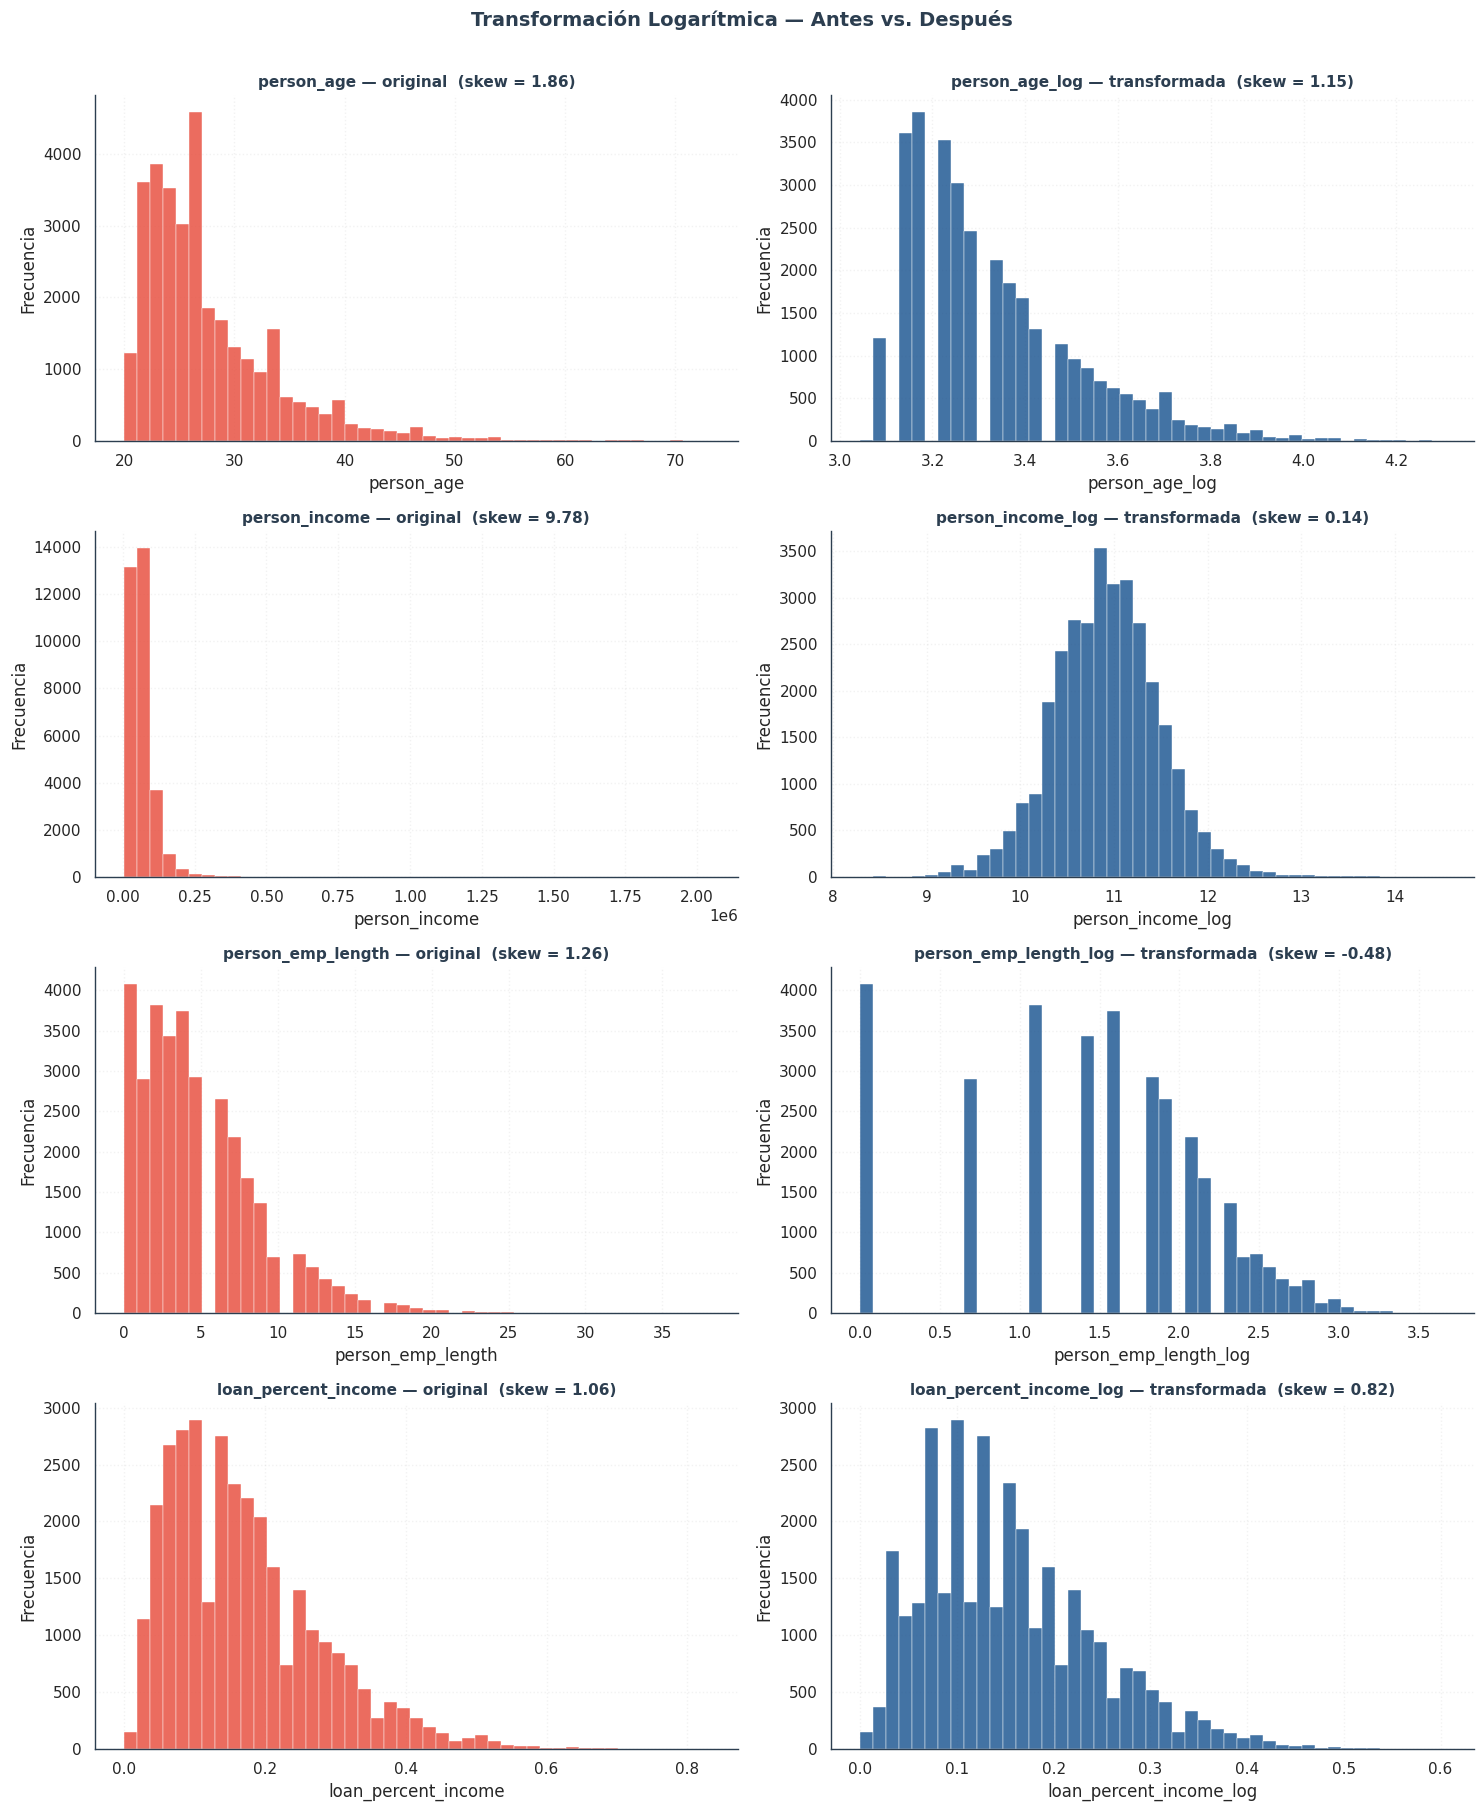

Las columnas originales se conservan; las versiones _log quedan
disponibles para el componente de regresión logística.


In [22]:
# ===============================================================
# 5.3 TRANSFORMACIÓN DE VARIABLES NUMÉRICAS
# ===============================================================
# Aplica transformación logarítmica (log1p) a las variables con
# asimetría fuerte. Crea columnas nuevas, conserva las originales.
# Orientado al componente de regresión logística.
# ===============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# Identificación de variables con asimetría fuerte
# ---------------------------------------------------------------
variables_num = ['person_age', 'person_income', 'person_emp_length',
                 'loan_amnt', 'loan_int_rate', 'loan_percent_income']

UMBRAL_SKEW = 1.0   # asimetría fuerte: |skew| >= 1

print("═" * 68)
print(" EVALUACIÓN DE ASIMETRÍA — VARIABLES NUMÉRICAS")
print("═" * 68)
print(f"\n {'Variable':<24}{'Skew original':>16}{'¿Transformar?':>18}")
print(" " + "─" * 58)

a_transformar = []
for var in variables_num:
    skew = df_fe[var].skew()
    transformar = abs(skew) >= UMBRAL_SKEW
    # loan_amnt se excluye: su problema es no-monotonicidad, no asimetría
    if var == 'loan_amnt':
        decision = "No (relación en U)"
    elif transformar:
        decision = "Sí (log1p)"
        a_transformar.append(var)
    else:
        decision = "No"
    print(f" {var:<24}{skew:>16.2f}{decision:>18}")
print(" " + "─" * 58)

# ---------------------------------------------------------------
# Aplicación de la transformación logarítmica
# ---------------------------------------------------------------
print(f"\n Variables a transformar: {a_transformar}\n")

for var in a_transformar:
    nueva_col = f"{var}_log"
    df_fe[nueva_col] = np.log1p(df_fe[var])
    skew_orig  = df_fe[var].skew()
    skew_trans = df_fe[nueva_col].skew()
    print(f" {var}")
    print(f"   Nueva columna: {nueva_col}")
    print(f"   Skew:  {skew_orig:.2f}  →  {skew_trans:.2f}")
    print()

# ---------------------------------------------------------------
# Visualización — antes vs después de la transformación
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

n = len(a_transformar)
fig, axes = plt.subplots(n, 2, figsize=(15, 4.5 * n))
fig.suptitle("Transformación Logarítmica — Antes vs. Después",
             fontsize=14, fontweight='bold', color="#2C3E50", y=1.005)

if n == 1:
    axes = axes.reshape(1, 2)

for i, var in enumerate(a_transformar):
    # Antes
    ax_a = axes[i, 0]
    sns.histplot(df_fe[var], bins=45, ax=ax_a, color="#E74C3C",
                 alpha=0.82, edgecolor='white', linewidth=0.3)
    ax_a.set_title(f"{var} — original  (skew = {df_fe[var].skew():.2f})",
                   fontweight="bold", fontsize=11, color="#2C3E50")
    ax_a.set_xlabel(var)
    ax_a.set_ylabel("Frecuencia")
    ax_a.grid(True, alpha=0.25, linestyle=':')

    # Después
    ax_d = axes[i, 1]
    col_log = f"{var}_log"
    sns.histplot(df_fe[col_log], bins=45, ax=ax_d, color="#1A5490",
                 alpha=0.82, edgecolor='white', linewidth=0.3)
    ax_d.set_title(f"{col_log} — transformada  (skew = {df_fe[col_log].skew():.2f})",
                   fontweight="bold", fontsize=11, color="#2C3E50")
    ax_d.set_xlabel(col_log)
    ax_d.set_ylabel("Frecuencia")
    ax_d.grid(True, alpha=0.25, linestyle=':')

plt.tight_layout()
plt.show()

print("Las columnas originales se conservan; las versiones _log quedan")
print("disponibles para el componente de regresión logística.")

### Interpretación de la Transformación

La transformación logarítmica produjo resultados de distinta magnitud según la variable.

**`person_income` — transformación altamente efectiva.** La variable pasó de una asimetría extrema (skew 9,78) a una distribución prácticamente simétrica (skew 0,14). El histograma transformado adopta una forma de campana, ideal para un modelo lineal. Dado que el ingreso es un predictor relevante (IV 0,47), esta transformación es especialmente valiosa: habilita a la regresión logística a aprovechar plenamente la variable, sin la distorsión que producían los valores extremos de la cola.

**`person_emp_length` y `loan_percent_income` — mejora sustancial.** Ambas redujeron su asimetría a niveles moderados (skew −0,48 y 0,82 respectivamente), aproximándose a una forma adecuada para el modelado lineal.

**`person_age` — mejora parcial.** La transformación redujo la asimetría de 1,86 a 1,15, pero la variable permanece en el rango de asimetría fuerte. La edad presenta una asimetría de carácter estructural —acotada por un piso etario y dominada por la población joven— que la transformación logarítmica corrige solo parcialmente. Esta limitación tiene impacto acotado: el análisis de Information Value (5.1) ya había clasificado a `person_age` como variable sin poder predictivo (IV 0,01), por lo que su incorporación al modelo final es, en cualquier caso, poco probable.

**Síntesis.** Las versiones transformadas (`_log`) quedan disponibles para el componente de regresión logística, mientras que las variables originales se conservan para XGBoost. La transformación más relevante —la del ingreso— resultó altamente efectiva. El conjunto de transformaciones mejora la adecuación de las variables numéricas al modelado lineal, sin alterar la información disponible para el modelo basado en árboles.

## 5.4 Codificación de Variables Categóricas

Los algoritmos de modelado operan exclusivamente con valores numéricos. Las variables categóricas —que contienen texto— deben convertirse a una representación numérica antes del modelado. Este proceso se denomina **codificación**.

La codificación no es única: el método correcto depende de la naturaleza de cada variable.

### Tipos de variable categórica y su codificación

**Variables ordinales.** Sus categorías tienen un **orden natural**. `loan_grade` es el caso: los grados A a G representan una calidad crediticia decreciente. Se aplica **codificación ordinal** —asignar números que respeten ese orden (A=1, B=2, …, G=7)—, de modo que el valor numérico conserve el significado de jerarquía.

**Variables nominales.** Sus categorías **no tienen orden**: `loan_intent` (finalidad del préstamo) y `person_home_ownership` (situación habitacional) son ejemplos —ninguna categoría es "mayor" que otra—. Asignarles números correlativos (1, 2, 3…) introduciría un orden ficticio que el modelo interpretaría erróneamente. Se aplica **one-hot encoding**: se crea una columna binaria (0/1) por cada categoría, indicando su presencia o ausencia. Así, ninguna categoría queda jerárquicamente por encima de otra.

**Variables binarias.** Con solo dos categorías, la codificación es directa. `cb_person_default_on_file` (Y/N) se convierte a 1/0.

### Nota sobre la estrategia de modelos duales

Tanto la regresión logística como XGBoost requieren variables numéricas, por lo que la codificación se aplica para ambos modelos. La elección del método —ordinal vs. one-hot— responde a la naturaleza de cada variable, no al modelo de destino.

In [23]:
# ===============================================================
# 5.4 CODIFICACIÓN DE VARIABLES CATEGÓRICAS
# ===============================================================
# Convierte las variables categóricas a representación numérica:
#   - loan_grade (ordinal)        → codificación ordinal A=1..G=7
#   - loan_intent, home_ownership → one-hot encoding
#   - cb_person_default_on_file   → binaria Y=1 / N=0
# ===============================================================

import pandas as pd
import numpy as np

print("═" * 68)
print(" CODIFICACIÓN DE VARIABLES CATEGÓRICAS")
print("═" * 68)

# ---------------------------------------------------------------
# 1. loan_grade — codificación ordinal (respeta el orden A-G)
# ---------------------------------------------------------------
mapa_grade = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_fe['loan_grade_enc'] = df_fe['loan_grade'].map(mapa_grade)

print("\n 1. loan_grade  →  loan_grade_enc  (ordinal)")
print("    Mapeo aplicado:", mapa_grade)

# ---------------------------------------------------------------
# 2. cb_person_default_on_file — binaria
# ---------------------------------------------------------------
mapa_default = {'N': 0, 'Y': 1}
df_fe['cb_default_on_file_enc'] = df_fe['cb_person_default_on_file'].map(mapa_default)

print("\n 2. cb_person_default_on_file  →  cb_default_on_file_enc  (binaria)")
print("    Mapeo aplicado:", mapa_default)

# ---------------------------------------------------------------
# 3. loan_intent y person_home_ownership — one-hot encoding
# ---------------------------------------------------------------
vars_nominales = ['loan_intent', 'person_home_ownership']

df_fe = pd.get_dummies(df_fe, columns=vars_nominales,
                       prefix=vars_nominales, dtype=int)

print("\n 3. Variables nominales  →  one-hot encoding")
for var in vars_nominales:
    nuevas = [c for c in df_fe.columns if c.startswith(var + '_')]
    print(f"\n    {var}  →  {len(nuevas)} columnas binarias:")
    for c in nuevas:
        print(f"       • {c}")

# ---------------------------------------------------------------
# Verificación del resultado
# ---------------------------------------------------------------
print("\n" + "═" * 68)
print(" VERIFICACIÓN")
print("═" * 68)
print(f"\n Dimensiones del dataset tras la codificación: "
      f"{df_fe.shape[0]:,} filas × {df_fe.shape[1]} columnas")

# Confirmar que no quedan columnas de tipo texto entre las predictoras
cols_texto = df_fe.select_dtypes(include='object').columns.tolist()
if cols_texto:
    print(f"\n Columnas de texto restantes (originales, se excluirán del modelo):")
    for c in cols_texto:
        print(f"   • {c}")
    print("\n Las versiones originales se conservan como referencia;")
    print(" el modelado utilizará únicamente las columnas codificadas.")
else:
    print("\n ✓ No quedan columnas de texto sin codificar.")

# Muestra de las nuevas columnas codificadas
print("\n Muestra de las variables codificadas (primeras filas):")
cols_enc = ['loan_grade_enc', 'cb_default_on_file_enc'] + \
           [c for c in df_fe.columns if c.startswith(('loan_intent_',
            'person_home_ownership_'))]
display(df_fe[cols_enc].head())

════════════════════════════════════════════════════════════════════
 CODIFICACIÓN DE VARIABLES CATEGÓRICAS
════════════════════════════════════════════════════════════════════

 1. loan_grade  →  loan_grade_enc  (ordinal)
    Mapeo aplicado: {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}

 2. cb_person_default_on_file  →  cb_default_on_file_enc  (binaria)
    Mapeo aplicado: {'N': 0, 'Y': 1}

 3. Variables nominales  →  one-hot encoding

    loan_intent  →  6 columnas binarias:
       • loan_intent_DEBTCONSOLIDATION
       • loan_intent_EDUCATION
       • loan_intent_HOMEIMPROVEMENT
       • loan_intent_MEDICAL
       • loan_intent_PERSONAL
       • loan_intent_VENTURE

    person_home_ownership  →  4 columnas binarias:
       • person_home_ownership_MORTGAGE
       • person_home_ownership_OTHER
       • person_home_ownership_OWN
       • person_home_ownership_RENT

════════════════════════════════════════════════════════════════════
 VERIFICACIÓN
═══════════════════════════

,loan_grade_enc,cb_default_on_file_enc,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
1,2,0,0,1,0,0,0,0,0,0,1,0
2,3,0,0,0,0,1,0,0,1,0,0,0
3,3,0,0,0,0,1,0,0,0,0,0,1
4,3,1,0,0,0,1,0,0,0,0,0,1
5,1,0,0,0,0,0,0,1,0,0,1,0


### Interpretación de la Codificación

Las cuatro variables categóricas quedaron convertidas a representación numérica, cada una con el método correspondiente a su naturaleza.

**Codificación aplicada.** `loan_grade` se codificó de forma ordinal (A=1 … G=7), preservando la jerarquía de calidad crediticia. `cb_person_default_on_file` se convirtió a formato binario (N=0, Y=1). Las dos variables nominales se expandieron mediante one-hot encoding: `loan_intent` generó 6 columnas binarias y `person_home_ownership`, 4 —una por cada categoría—. El dataset pasó a contar con 29 columnas, crecimiento esperado por la expansión del one-hot.

**Conservación de las variables originales.** Las columnas de texto originales se mantienen en el dataset como referencia; el modelado utilizará exclusivamente las versiones codificadas.

**Consideración pendiente — redundancia del one-hot encoding.** El one-hot encoding completo introduce una redundancia conocida: las columnas binarias de una misma variable nominal son linealmente dependientes entre sí —si un registro tiene 0 en todas las categorías de `person_home_ownership` salvo una, esa última queda determinada—. Esta redundancia afecta a la **regresión logística**, donde puede generar inestabilidad en los coeficientes. **XGBoost, en cambio, no se ve afectado**: al ser un modelo basado en árboles de decisión, no le perjudica la presencia de columnas redundantes (la misma robustez que ya mostró frente a la multicolinealidad en el análisis de correlaciones del Capítulo 4).

Su tratamiento —la técnica de *drop-first*, que elimina una categoría de referencia por variable— se aplicará en la sección **5.6**, al conformar los conjuntos de modelado diferenciados para cada algoritmo. Posponer esta decisión a esa sección es deliberado: el *drop-first* es un ajuste específico de la regresión logística, y 5.6 es el punto donde los datasets de ambos modelos se separan según sus requerimientos.

## 5.5 Selección de Variables y Tratamiento de Multicolinealidad

Las secciones anteriores construyeron, transformaron y codificaron variables. Esta sección define el **conjunto final de predictores** que ingresarán al modelado, resolviendo dos cuestiones pendientes: la multicolinealidad detectada en el EDA y la exclusión de variables sin poder predictivo.

### Recordatorio: qué es la multicolinealidad

La **multicolinealidad** ocurre cuando dos o más variables predictoras están tan correlacionadas entre sí que aportan información redundante —explican lo mismo—. Afecta principalmente a la **regresión logística**: cuando dos variables dicen casi lo mismo, el modelo no puede atribuir con claridad el efecto a una u otra, y sus coeficientes se vuelven inestables y difíciles de interpretar. Los modelos basados en árboles, como XGBoost, son robustos a este fenómeno.

### Criterios de selección

La selección de variables combina dos criterios objetivos, ya establecidos en fases anteriores:

**1. Poder predictivo (Information Value).** El análisis de IV (sección 5.1) cuantificó la capacidad discriminante de cada variable. Las variables con IV inferior a 0,02 —sin poder predictivo según la escala de Siddiqi— son candidatas a exclusión, ya que no aportan capacidad de discriminación al modelo.

**2. Multicolinealidad (correlación entre predictores).** El análisis de correlaciones (sección 4.4) identificó un par de variables con multicolinealidad alta: `person_age` y `cb_person_cred_hist_length` (correlación de 0,88). De conservarse ambas en la regresión logística, generarían inestabilidad. Se conserva una y se descarta la otra.

La conjunción de ambos criterios resuelve el caso de forma directa: las dos variables del par multicolineal presentan, además, un IV muy bajo (0,011 y 0,004 respectivamente). Es decir, no solo son redundantes entre sí, sino que ninguna de las dos aporta poder predictivo. Ambas pueden descartarse sin pérdida de información relevante.

════════════════════════════════════════════════════════════════════════
 SELECCIÓN DE VARIABLES — CONJUNTO FINAL DE PREDICTORES
════════════════════════════════════════════════════════════════════════

 1. EVALUACIÓN POR PODER PREDICTIVO
    Fuente: Information Value calculado en la sección 5.1
 ────────────────────────────────────────────────────────────────────
   Variable                            IV (5.1)              Decisión
   ··································································
   loan_grade                            0.8814             Conservar
   loan_percent_income                   0.8727             Conservar
   loan_int_rate                         0.7264             Conservar
   person_income                         0.4699             Conservar
   person_home_ownership                 0.3758             Conservar
   cb_person_default_on_file             0.1638             Conservar
   loan_intent                           0.0961             Conservar
   

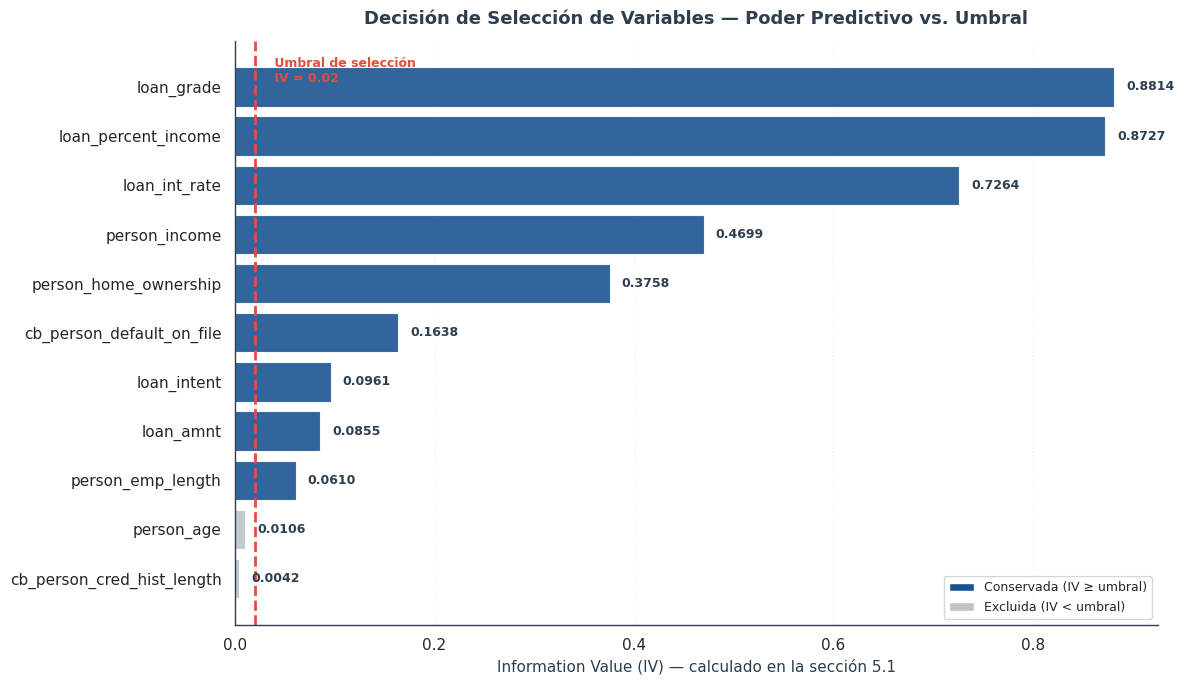

In [24]:
# ===============================================================
# 5.5 SELECCIÓN DE VARIABLES Y TRATAMIENTO DE MULTICOLINEALIDAD
# ===============================================================
# Define el conjunto final de predictores combinando dos criterios
# YA CALCULADOS en secciones anteriores:
#   - poder predictivo: IV calculado en 5.1 (variable resultados_iv)
#   - multicolinealidad: correlación calculada en 4.4 (variable corr)
# Este bloque NO recalcula: lee los resultados existentes, para
# garantizar una única fuente de verdad y evitar contradicciones.
# ===============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

print("═" * 72)
print(" SELECCIÓN DE VARIABLES — CONJUNTO FINAL DE PREDICTORES")
print("═" * 72)

UMBRAL_IV   = 0.02   # criterio Siddiqi: sin poder predictivo por debajo
UMBRAL_CORR = 0.70   # multicolinealidad alta a partir de este valor

# ---------------------------------------------------------------
# Fuente 1 — IV calculado en la sección 5.1 (variable resultados_iv)
# resultados_iv contiene tuplas (etiqueta, variable, iv, clase)
# ---------------------------------------------------------------
iv_por_variable = {var: iv for (_, var, iv, _) in resultados_iv}

# ---------------------------------------------------------------
# Fuente 2 — Matriz de correlación calculada en la sección 4.4
# (variable corr). Se extraen los pares con correlación alta.
# ---------------------------------------------------------------
pares_multicolineales = []
vars_corr = corr.columns.tolist()
for i in range(len(vars_corr)):
    for j in range(i):
        r = corr.iloc[i, j]
        if abs(r) >= UMBRAL_CORR:
            pares_multicolineales.append((vars_corr[i], vars_corr[j], r))

# ---------------------------------------------------------------
# 1. Evaluación por poder predictivo (IV de 5.1)
# ---------------------------------------------------------------
print("\n 1. EVALUACIÓN POR PODER PREDICTIVO")
print("    Fuente: Information Value calculado en la sección 5.1")
print(" " + "─" * 68)
print(f"   {'Variable':<32}{'IV (5.1)':>12}{'Decisión':>22}")
print("   " + "·" * 66)

excluidas_iv = []
for var, iv in sorted(iv_por_variable.items(), key=lambda x: -x[1]):
    if iv < UMBRAL_IV:
        decision = "Excluir (sin poder)"
        excluidas_iv.append(var)
    else:
        decision = "Conservar"
    print(f"   {var:<32}{iv:>12.4f}{decision:>22}")

# ---------------------------------------------------------------
# 2. Tratamiento de multicolinealidad (correlación de 4.4)
# ---------------------------------------------------------------
print("\n 2. TRATAMIENTO DE MULTICOLINEALIDAD")
print("    Fuente: matriz de correlación calculada en la sección 4.4")
print(" " + "─" * 68)

if pares_multicolineales:
    for v1, v2, r in pares_multicolineales:
        iv1 = iv_por_variable.get(v1, float('nan'))
        iv2 = iv_por_variable.get(v2, float('nan'))
        print(f"   Par detectado:  {v1} ↔ {v2}")
        print(f"     Correlación (4.4):  r = {r:.3f}")
        print(f"     IV (5.1):           {v1} = {iv1:.4f}  |  {v2} = {iv2:.4f}")
        # Diagnóstico de la convergencia de criterios
        if iv1 < UMBRAL_IV and iv2 < UMBRAL_IV:
            print(f"     → Ambas variables tienen IV < {UMBRAL_IV}: el criterio de")
            print(f"       poder predictivo ya determina su exclusión. La")
            print(f"       multicolinealidad se resuelve de forma simultánea.")
        else:
            print(f"     → Al menos una variable supera el umbral de IV: se")
            print(f"       conservaría la de mayor IV y se descartaría la otra.")
else:
    print("   No se detectaron pares con multicolinealidad alta.")

# ---------------------------------------------------------------
# 3. Conjunto final de predictores
# ---------------------------------------------------------------
vars_conservadas = [v for v, iv in iv_por_variable.items() if iv >= UMBRAL_IV]
vars_conservadas.sort(key=lambda v: -iv_por_variable[v])
vars_derivadas = ['is_high_dti']   # validada en 5.2

# Verificar coherencia: ninguna conservada debe estar en un par multicolineal
en_par = set()
for v1, v2, _ in pares_multicolineales:
    en_par.add(v1); en_par.add(v2)
conservadas_en_par = [v for v in vars_conservadas if v in en_par]

print("\n 3. CONJUNTO FINAL DE PREDICTORES")
print(" " + "─" * 68)
print(f"\n   Variables originales conservadas ({len(vars_conservadas)}):")
for v in vars_conservadas:
    print(f"     • {v:<30} IV = {iv_por_variable[v]:.4f}")
print(f"\n   Variables derivadas incorporadas ({len(vars_derivadas)}):")
for v in vars_derivadas:
    print(f"     • {v}")
print(f"\n   Variables excluidas ({len(excluidas_iv)}):")
for v in excluidas_iv:
    motivo = "IV insuficiente"
    if v in en_par:
        motivo += " + multicolinealidad"
    print(f"     • {v:<30} ({motivo})")

# Chequeo de coherencia automático
print("\n   Verificación de coherencia:")
if not conservadas_en_par:
    print("   ✓ Ninguna variable conservada presenta multicolinealidad alta.")
else:
    print(f"   ⚠ Revisar: {conservadas_en_par} conservada(s) con multicolinealidad.")

print("\n" + "═" * 72)
print(f" Predictores finales: {len(vars_conservadas) + len(vars_derivadas)}  "
      f"|  Excluidos: {len(excluidas_iv)}")
print("═" * 72)

predictores_seleccionados = vars_conservadas + vars_derivadas

# ===============================================================
# VISUALIZACIÓN DE LA DECISIÓN DE SELECCIÓN
# ===============================================================
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

items = sorted(iv_por_variable.items(), key=lambda x: x[1])
nombres = [v for v, _ in items]
valores = [iv for _, iv in items]

COLOR_CONSERVA, COLOR_EXCLUYE = "#1A5490", "#BDC3C7"
colores = [COLOR_CONSERVA if iv >= UMBRAL_IV else COLOR_EXCLUYE
           for iv in valores]

fig, ax = plt.subplots(figsize=(12, 7))
barras = ax.barh(nombres, valores, color=colores, alpha=0.9,
                 edgecolor='white', linewidth=0.8)
for barra, iv in zip(barras, valores):
    ax.text(barra.get_width() + 0.012, barra.get_y() + barra.get_height()/2,
            f"{iv:.4f}", va='center', fontsize=9, fontweight='bold',
            color="#2C3E50")

ax.axvline(UMBRAL_IV, color="#E74C3C", linestyle="--", linewidth=2)
ax.text(UMBRAL_IV + 0.015, len(nombres) - 0.4,
        f' Umbral de selección\n IV = {UMBRAL_IV}',
        fontsize=9, color="#E74C3C", fontweight='bold', va='top')

ax.set_xlabel("Information Value (IV) — calculado en la sección 5.1",
              fontsize=11, color="#2C3E50")
ax.set_title("Decisión de Selección de Variables — Poder Predictivo vs. Umbral",
             fontweight='bold', fontsize=13, color="#2C3E50", pad=12)
ax.legend(handles=[
    Patch(facecolor=COLOR_CONSERVA, label='Conservada (IV ≥ umbral)'),
    Patch(facecolor=COLOR_EXCLUYE,  label='Excluida (IV < umbral)'),
], fontsize=9, loc='lower right', frameon=True)
ax.grid(True, alpha=0.25, linestyle=':', axis='x')
plt.tight_layout()
plt.show()

### Interpretación de la Selección de Variables

La selección del conjunto final de predictores se resolvió aplicando dos criterios objetivos ya establecidos en fases anteriores, sin introducir ningún criterio nuevo.

**Variables excluidas.** Dos variables quedaron por debajo del umbral de poder predictivo (IV < 0,02): `person_age` (IV 0,011) y `cb_person_cred_hist_length` (IV 0,004). Su exclusión está doblemente fundamentada. Por un lado, el análisis de Information Value (5.1) ya las había clasificado como variables sin poder predictivo. Por otro, el análisis de correlaciones (4.4) las había identificado como el único par con multicolinealidad alta del dataset (correlación de 0,88). Ambos hallazgos convergen: las dos variables son, a la vez, redundantes entre sí y carentes de capacidad discriminante. Su exclusión no implica pérdida de información relevante y, simultáneamente, elimina la multicolinealidad detectada.

**Variables conservadas.** Las nueve variables originales restantes superan el umbral de IV y se incorporan al modelo. A ellas se suma la variable derivada `is_high_dti`, validada en la sección 5.2. El conjunto final queda conformado por **10 predictores**.

**Síntesis.** La sección consolidó en una decisión única los hallazgos dispersos del proyecto: el poder predictivo cuantificado en el Capítulo 5.1 y la multicolinealidad detectada en el Capítulo 4.4. El conjunto final de 10 predictores está, por tanto, respaldado por evidencia generada y documentada a lo largo de todo el análisis. La preparación de los datos para el modelado —partición en entrenamiento y prueba, y conformación de las matrices específicas de cada modelo— se aborda en la sección 5.6.

## 5.6 Preparación de los Conjuntos de Modelado

Esta sección final del Feature Engineering prepara los datos para el entrenamiento de los modelos. Comprende tres tareas: la partición del dataset, la resolución de la redundancia del one-hot encoding, y la conformación de las matrices de variables específicas de cada modelo.

### Partición en entrenamiento y prueba (train/test split)

Un modelo no puede evaluarse con los mismos datos con los que se entrenó: lo haría parecer mejor de lo que es, al premiar la memorización en lugar del aprendizaje. Por ello, el dataset se divide en dos conjuntos:

- **Entrenamiento (train)** — el modelo aprende los patrones a partir de estos datos.
- **Prueba (test)** — el modelo se evalúa con estos datos, que **nunca vio** durante el entrenamiento, obteniendo una medida realista de su desempeño.

Se aplica una partición **80/20**: 80% de los registros para entrenamiento y 20% para prueba. La proporción es un estándar habitual que equilibra disponer de suficientes datos para entrenar y una muestra de prueba representativa.

### Estratificación

La partición se realiza de forma **estratificada**: se garantiza que la tasa de default (21,87%) sea idéntica en ambos conjuntos. Sin estratificación, el azar podría producir conjuntos con proporciones de default distintas, sesgando la evaluación. La estratificación asegura que train y test sean comparables en su composición de riesgo.

### Resolución de la redundancia del one-hot encoding

Como se anticipó en la sección 5.4, el one-hot encoding completo genera columnas binarias linealmente dependientes entre sí (*dummy trap*). Se aplica la técnica de **drop-first**: se elimina una categoría de referencia por cada variable nominal. La información se conserva íntegramente —la categoría eliminada queda representada cuando todas las demás valen cero— y se elimina la redundancia que afectaría a la regresión logística.

### Matrices diferenciadas por modelo

La estrategia de modelos duales requiere conjuntos de variables distintos:

- **Regresión logística** — utiliza las variables numéricas en su versión transformada (`_log`) y el one-hot con *drop-first*, en línea con sus requisitos de linealidad y no redundancia.
- **XGBoost** — utiliza las variables en su escala original y el one-hot completo, dado que es robusto a la asimetría y a la redundancia.

Ambos modelos comparten la misma partición train/test, condición indispensable para que su comparación posterior (Champion–Challenger) sea válida.

In [25]:
# ===============================================================
# 5.6 PREPARACIÓN DE LOS CONJUNTOS DE MODELADO
# ===============================================================
# - Partición estratificada train/test (80/20)
# - Resolución del dummy trap (drop-first) para la regresión logística
# - Conformación de las matrices de variables de cada modelo
# ===============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

print("═" * 70)
print(" PREPARACIÓN DE LOS CONJUNTOS DE MODELADO")
print("═" * 70)

# ---------------------------------------------------------------
# 1. Definición de las variables de cada modelo
# ---------------------------------------------------------------
# Columnas one-hot generadas en 5.4
cols_intent = [c for c in df_fe.columns if c.startswith('loan_intent_')]
cols_home   = [c for c in df_fe.columns if c.startswith('person_home_ownership_')]

# --- Variables para REGRESIÓN LOGÍSTICA ---
# Numéricas en versión transformada (_log) + codificadas + one-hot drop-first
vars_logistica = [
    'person_income_log', 'loan_percent_income_log', 'person_emp_length_log',
    'loan_int_rate',          # casi simétrica, no se transformó
    'loan_amnt',              # relación en U; se incluye en escala original
    'loan_grade_enc',
    'cb_default_on_file_enc',
    'is_high_dti',
]
# one-hot con drop-first: se elimina la primera categoría de cada variable
vars_logistica += cols_intent[1:]   # drop-first: omite la 1ra columna
vars_logistica += cols_home[1:]

# --- Variables para XGBOOST ---
# Numéricas en escala original + codificadas + one-hot completo
vars_xgboost = [
    'person_income', 'loan_percent_income', 'person_emp_length',
    'loan_int_rate', 'loan_amnt',
    'loan_grade_enc',
    'cb_default_on_file_enc',
    'is_high_dti',
]
vars_xgboost += cols_intent   # one-hot completo
vars_xgboost += cols_home

print(f"\n Variables para Regresión Logística: {len(vars_logistica)}")
print(f" Variables para XGBoost:             {len(vars_xgboost)}")
print(f"\n Categorías de referencia eliminadas (drop-first, solo logística):")
print(f"   • loan_intent:           {cols_intent[0]}")
print(f"   • person_home_ownership: {cols_home[0]}")

# ---------------------------------------------------------------
# 2. Partición estratificada train/test (80/20)
# ---------------------------------------------------------------
TEST_SIZE = 0.20
SEMILLA = 42   # reproducibilidad

y = df_fe['loan_status']

# Índices de la partición (compartidos por ambos modelos)
idx_train, idx_test = train_test_split(
    df_fe.index, test_size=TEST_SIZE, random_state=SEMILLA, stratify=y)

# Matrices para regresión logística
X_train_log = df_fe.loc[idx_train, vars_logistica]
X_test_log  = df_fe.loc[idx_test,  vars_logistica]

# Matrices para XGBoost
X_train_xgb = df_fe.loc[idx_train, vars_xgboost]
X_test_xgb  = df_fe.loc[idx_test,  vars_xgboost]

# Target (compartido)
y_train = y.loc[idx_train]
y_test  = y.loc[idx_test]

# ---------------------------------------------------------------
# 3. Verificación de la partición
# ---------------------------------------------------------------
print("\n" + "─" * 70)
print(" VERIFICACIÓN DE LA PARTICIÓN")
print("─" * 70)
print(f"\n {'Conjunto':<20}{'Registros':>14}{'% del total':>14}{'Tasa default':>16}")
print(" " + "·" * 64)
total = len(df_fe)
for nombre, idx in [('Entrenamiento', idx_train), ('Prueba', idx_test)]:
    n = len(idx)
    tasa = y.loc[idx].mean() * 100
    print(f" {nombre:<20}{n:>14,}{n/total*100:>13.1f}%{tasa:>15.2f}%")
print(" " + "·" * 64)
print(f" {'TOTAL':<20}{total:>14,}{100.0:>13.1f}%{y.mean()*100:>15.2f}%")

print(f"\n ✓ Estratificación verificada: la tasa de default se mantiene")
print(f"   prácticamente idéntica en ambos conjuntos.")

# ---------------------------------------------------------------
# 4. Resumen de las matrices generadas
# ---------------------------------------------------------------
print("\n" + "─" * 70)
print(" MATRICES DE MODELADO GENERADAS")
print("─" * 70)
print(f"\n  Regresión Logística:")
print(f"    X_train_log: {X_train_log.shape}   X_test_log: {X_test_log.shape}")
print(f"  XGBoost:")
print(f"    X_train_xgb: {X_train_xgb.shape}   X_test_xgb: {X_test_xgb.shape}")
print(f"  Target:")
print(f"    y_train: {y_train.shape}   y_test: {y_test.shape}")
print("\n" + "═" * 70)
print(" Datos listos para el modelado (Capítulo 6).")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
 PREPARACIÓN DE LOS CONJUNTOS DE MODELADO
══════════════════════════════════════════════════════════════════════

 Variables para Regresión Logística: 16
 Variables para XGBoost:             18

 Categorías de referencia eliminadas (drop-first, solo logística):
   • loan_intent:           loan_intent_DEBTCONSOLIDATION
   • person_home_ownership: person_home_ownership_MORTGAGE

──────────────────────────────────────────────────────────────────────
 VERIFICACIÓN DE LA PARTICIÓN
──────────────────────────────────────────────────────────────────────

 Conjunto                 Registros   % del total    Tasa default
 ································································
 Entrenamiento               25,908         80.0%          21.87%
 Prueba                       6,478         20.0%          21.87%
 ································································
 TOTAL                       32,386        100

# 6. Modelado — Estimación de la Probabilidad de Default

Con el universo de modelado depurado (Capítulo 2), completo (Capítulo 3), comprendido (Capítulo 4) y consolidado en un conjunto final de predictores (Capítulo 5), este capítulo aborda la construcción de los modelos que estiman la **Probabilidad de Default (PD)** — la probabilidad de que un cliente incumpla su crédito —.

El capítulo construye **dos modelos** bajo un esquema Champion–Challenger: una **Regresión Logística**, baseline interpretable y auditable, y un modelo **XGBoost**, challenger de mayor capacidad predictiva. La justificación de esta estrategia dual se desarrolla en la sección 6.1.

### Estado de los datos al iniciar el capítulo

La sección 5.6 dejó preparados los conjuntos de modelado. El Capítulo 6 los consume sin modificarlos:

| Conjunto | Contenido | Destino |
|---|---|---|
| `X_train_log` / `X_test_log` | 16 predictores — numéricas transformadas (`_log`), `loan_grade` ordinal, one-hot con *drop-first* | Regresión Logística |
| `X_train_xgb` / `X_test_xgb` | 18 predictores — numéricas en escala original, one-hot completo | XGBoost |
| `y_train` / `y_test` | Variable objetivo `loan_status` (1 = default, 0 = cumple) | Compartido por ambos modelos |

La partición es **80/20 estratificada** —la tasa de default (21,87%) es idéntica en entrenamiento y prueba— con semilla fija (`random_state = 42`). El conjunto de prueba permanece **intocado** durante todo el capítulo: se reserva exclusivamente para la evaluación.

### Alcance del capítulo

Para mantener una separación limpia de responsabilidades entre capítulos, conviene precisar qué hace y qué no hace el Capítulo 6:

- **Hace** — construye y entrena ambos modelos, ajusta sus hiperparámetros mediante validación cruzada, trata el desbalance de clases y verifica que no haya sobreajuste.
- **No hace** — la evaluación regulatoria completa de la discriminación (Gini, KS, AUC con curvas) se desarrolla en el **Capítulo 7**; la elección formal del modelo Champion se decide en el **Capítulo 9**. En este capítulo, las métricas de desempeño se usan únicamente como instrumento de ajuste y de control de sobreajuste, no como veredicto final.

### Estructura del capítulo

**6.1 — Marco de Modelado: el esquema Champion–Challenger.** Fundamento de la estrategia dual y rol de cada modelo.

**6.2 — Modelo 1: Regresión Logística (baseline regulatorio).** Construcción inicial, ajuste por validación cruzada y chequeo de coherencia de signos.

**6.3 — Diagnóstico de Multicolinealidad y Refinamiento del Modelo Logístico.** VIF, estabilidad de coeficientes y ajuste del modelo final (13 variables).

**6.4 — Modelo 2: XGBoost (Challenger).** Construcción, búsqueda de hiperparámetros e importancia de variables.

**6.5 — Diagnóstico de Generalización.** Control de sobreajuste mediante la brecha train–test.

**6.6 — Conclusiones del Capítulo.** Síntesis de decisiones, hallazgos clave y limitaciones.

## 6.1 Marco de Modelado: el Esquema Champion–Challenger

Antes de construir los modelos, esta sección establece la lógica que articula el capítulo: por qué se desarrollan **dos** modelos en lugar de uno, y qué rol cumple cada uno.

### El esquema Champion–Challenger

**Champion–Challenger** es un esquema estándar de gestión de modelos en la industria financiera. Consiste en mantener un modelo en producción —el **Champion**— y, en paralelo, desarrollar uno o más modelos alternativos —los **Challengers**— que compiten por reemplazarlo. Un Challenger solo se promueve a Champion si demuestra, sobre evidencia objetiva, un desempeño superior. El esquema convierte la elección del modelo en una **decisión fundamentada y documentada**, no en una preferencia técnica, y es coherente con las exigencias de Model Risk Management (SR 11-7, TRIM-ECB) de justificar y monitorear todo modelo en uso.

### Por qué dos modelos: el dilema interpretabilidad–capacidad

En credit scoring conviven dos objetivos que, con frecuencia, tiran en direcciones opuestas:

- **Interpretabilidad** — la capacidad de explicar *por qué* el modelo asigna un puntaje. Es una exigencia regulatoria: el cliente tiene derecho a conocer los motivos de una decisión crediticia, y el supervisor exige que el modelo sea auditable y económicamente coherente.
- **Capacidad predictiva** — la capacidad de discriminar con precisión entre clientes que cumplirán y clientes que entrarán en default. Una mayor capacidad reduce las pérdidas por crédito mal otorgado y los ingresos perdidos por crédito mal rechazado.

Ningún modelo único maximiza ambos objetivos a la vez. Por eso el proyecto construye un representante de cada extremo del dilema y los enfrenta:

| | **Regresión Logística** | **XGBoost** |
|---|---|---|
| Rol | Champion candidato — baseline regulatorio | Challenger |
| Fortaleza | Interpretabilidad total: cada variable aporta un coeficiente legible | Capacidad predictiva: captura relaciones no lineales e interacciones |
| Naturaleza | Modelo lineal — estándar de la industria para *scorecards* | Ensamble de árboles de decisión (*gradient boosting*) |
| Limitación | No captura relaciones no lineales (p. ej. la forma en U de `loan_amnt`) | Menor transparencia — requiere técnicas adicionales de explicación |

La Regresión Logística se posiciona como **Champion candidato** por una razón concreta: es el estándar regulatorio del credit scoring y la base sobre la que se construye una *scorecard* (Capítulo 8). XGBoost ingresa como **Challenger**: su tarea es demostrar si el salto de capacidad predictiva justifica el costo en interpretabilidad. Esa comparación formal —con métricas regulatorias— es el objeto del Capítulo 9.

### Principios metodológicos del capítulo

Tres principios gobiernan la construcción de ambos modelos:

1. **Reproducibilidad.** Todo proceso con componente aleatorio —partición, validación cruzada, muestreo interno de XGBoost— se fija con la semilla `random_state = 42`. Cualquier persona que ejecute el notebook obtiene resultados idénticos.

2. **No fuga de información (*data leakage*).** El conjunto de prueba no participa de ninguna decisión de modelado: no se usa para escalar variables, ni para ajustar hiperparámetros, ni para seleccionar configuraciones. Toda decisión se toma sobre el conjunto de entrenamiento, mediante validación cruzada. El test se reserva para una única medición final de desempeño.

3. **Comparabilidad.** Ambos modelos se entrenan y evalúan sobre la **misma partición** train/test. Es la condición que vuelve legítima la comparación Champion–Challenger del Capítulo 9: las diferencias de desempeño deben atribuirse al modelo, no a los datos sobre los que se midió cada uno.

*texto en cursiva*## 6.2 Modelo 1: Regresión Logística (Baseline Regulatorio)

La **Regresión Logística** es el modelo estándar de la industria para estimar la Probabilidad de Default. Su construcción inaugura el capítulo en su rol de Champion candidato.

### Qué es la Regresión Logística para PD

La Regresión Logística estima la probabilidad de un evento binario —aquí, el default— como función de un conjunto de variables predictoras. Calcula primero una combinación lineal de las variables y luego la transforma, mediante la **función logística**, en una probabilidad acotada entre 0 y 1:

$$PD = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_k x_k)}}$$

Cada **coeficiente** $\beta_i$ cuantifica el efecto de su variable sobre el riesgo: un coeficiente positivo indica que, al aumentar la variable, aumenta la probabilidad de default; uno negativo, lo contrario. Esta legibilidad —cada variable con su aporte explícito y con signo interpretable— es la razón por la que la Regresión Logística es el estándar regulatorio: el modelo es auditable y directamente traducible a una *scorecard*.

### Decisiones de construcción del modelo

La construcción aplica cuatro decisiones, cada una con su fundamento.

**1. Estandarización de las variables.** Las 16 variables predictoras conviven en escalas muy dispares —`loan_amnt` llega a decenas de miles, `loan_grade_enc` va de 1 a 7, las *dummies* son 0/1—. La **estandarización** lleva cada variable a media 0 y desvío 1, de modo que todas queden en una escala común. Esto cumple dos funciones: vuelve la regularización (punto 3) equitativa entre variables, y hace que los coeficientes resultantes sean **comparables en magnitud** —el coeficiente más grande corresponde a la variable de mayor efecto—.

El escalado se integra como un paso de un *pipeline*, junto con el modelo. Esto es deliberado y resuelve un riesgo de **fuga de información**: durante la validación cruzada, el escalador se ajusta únicamente sobre la porción de entrenamiento de cada partición —nunca sobre la de validación—, y el modelo final ajusta su escalador sobre el conjunto de entrenamiento completo. El conjunto de prueba no interviene en ningún momento.

**2. Tratamiento del desbalance de clases.** Como estableció la sección 4.1, la cartera está desbalanceada (21,87% de default). Sin corrección, el modelo tendería a privilegiar la clase mayoritaria —los cumplidores— y a subestimar el riesgo. Se aplica `class_weight='balanced'`: cada clase recibe un peso inversamente proporcional a su frecuencia, de modo que los casos de default pesan más en la función de pérdida y el modelo no los relega.

**3. Regularización L2.** La **regularización** es una penalización que se añade a la función de pérdida para evitar que los coeficientes adopten valores extremos. La variante **L2** penaliza la suma de los coeficientes al cuadrado, favoreciendo un modelo de coeficientes moderados, más estable y menos propenso al sobreajuste. Su intensidad se gobierna con el hiperparámetro **`C`**: un `C` bajo implica regularización fuerte (coeficientes más contenidos); un `C` alto, regularización débil.

**4. Ajuste de `C` por validación cruzada.** El valor de `C` no se fija a priori. Se evalúa una grilla de valores mediante **validación cruzada estratificada de 5 particiones**: el conjunto de entrenamiento se divide en 5 bloques de igual composición de riesgo, y cada valor de `C` se prueba entrenando en 4 bloques y midiendo en el quinto, rotando. Se selecciona el `C` con mejor desempeño promedio, medido por **AUC** —el área bajo la curva ROC, una métrica de discriminación robusta al desbalance, que el Capítulo 7 desarrolla en detalle—.

### Chequeo de coherencia de signos

Una vez ajustado el modelo, se aplica una validación propia de Model Risk Management: verificar que **el signo de cada coeficiente coincida con la lógica económica esperada**. Por ejemplo, el coeficiente del grado crediticio codificado (A=1 … G=7) debe ser positivo —a peor grado, mayor riesgo—, y el del ingreso, negativo —a mayor ingreso, menor riesgo—. Un signo invertido en una variable con teoría unívoca es una señal de alerta: puede indicar un problema de datos, multicolinealidad residual o un ajuste espurio, y obligaría a revisar el modelo antes de avanzar.

El chequeo se aplica de forma estricta a las variables con un signo económico inequívoco. `loan_amnt` se exceptúa —su relación con el default es no monótona (forma en U, sección 4.3.2), por lo que no admite un signo esperado a priori—, y las *dummies* one-hot se leen en términos relativos a su categoría de referencia.

### Nota sobre la calibración

El uso de `class_weight='balanced'` optimiza la capacidad de **discriminación** del modelo, pero desplaza las probabilidades predichas respecto de la tasa real de la cartera —dejan de estar *calibradas*—. Esto no afecta a las métricas de discriminación (AUC, KS, Gini), que dependen del ordenamiento y no del nivel de las probabilidades. La **calibración** de las probabilidades es un paso posterior, que se aborda en la construcción de la scorecard y la política de corte (Capítulo 8).

════════════════════════════════════════════════════════════════════════
 MODELO 1 — REGRESIÓN LOGÍSTICA — RESULTADO DEL AJUSTE
════════════════════════════════════════════════════════════════════════

  Variables predictoras:            16
  Registros de entrenamiento:       25,908
  Tratamiento del desbalance:       class_weight='balanced'
  Regularización:                   L2

  Hiperparámetro C óptimo:          0.5
  AUC validación cruzada (5-fold):  0.8696 ± 0.0063
  Convergencia del optimizador:     sí (14 iteraciones)

  Búsqueda de C — AUC promedio por valor evaluado:
  ──────────────────────────────────────────────
           C        AUC CV      Desvío
  ············································
        0.01        0.8692      0.0064
        0.05        0.8695      0.0063
         0.1        0.8696      0.0063
         0.5        0.8696      0.0063  ← óptimo
         1.0        0.8696      0.0063
         5.0        0.8696      0.0063
        10.0        0.8696      0.006

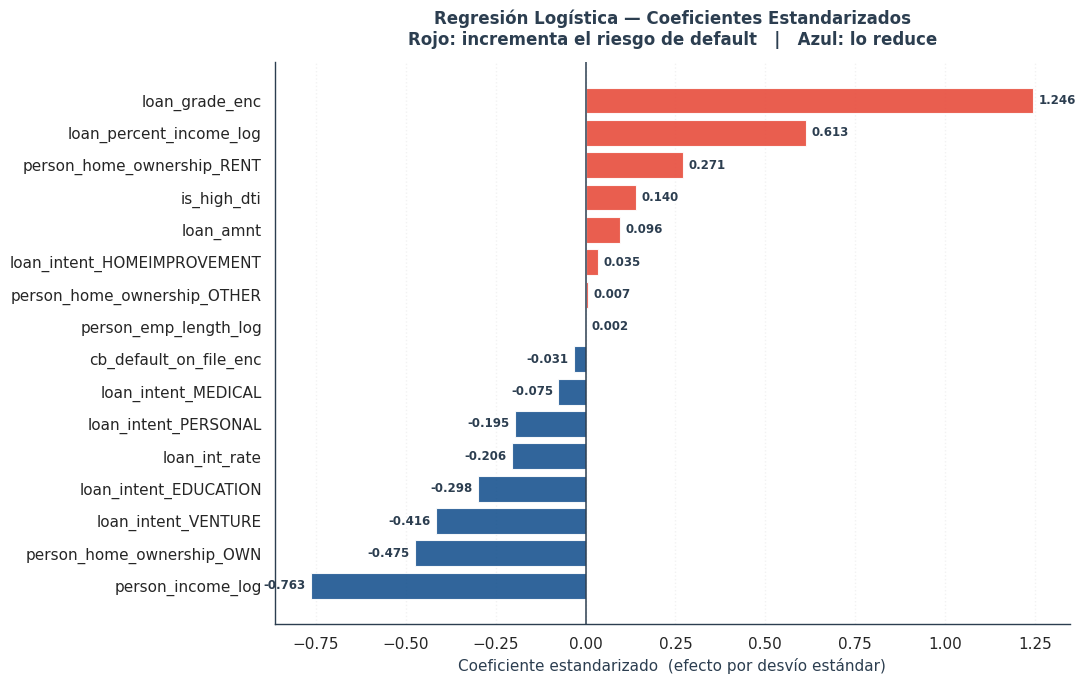

In [26]:
# ===============================================================
# 6.2 MODELO 1 — REGRESIÓN LOGÍSTICA (BASELINE REGULATORIO)
# ===============================================================
# - Escalado embebido en un Pipeline: se reajusta dentro de cada
#   fold de la validación cruzada → sin fuga hacia el conjunto de
#   validación. El test no interviene.
# - Desbalance tratado con class_weight='balanced'.
# - Hiperparámetro C ajustado por validación cruzada estratificada.
# - Chequeo de coherencia de signos de los coeficientes (MRM).
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

SEMILLA = 42

# ---------------------------------------------------------------
# 1. Pipeline: estandarización + regresión logística
# ---------------------------------------------------------------
pipe_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l2',
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=SEMILLA,
    )),
])

# ---------------------------------------------------------------
# 2. Búsqueda del hiperparámetro C por validación cruzada
# ---------------------------------------------------------------
grilla_C = {'clf__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]}
cv_estrat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

busqueda_log = GridSearchCV(
    pipe_log, grilla_C,
    scoring='roc_auc',
    cv=cv_estrat,
    n_jobs=-1,
)
busqueda_log.fit(X_train_log, y_train)

modelo_log = busqueda_log.best_estimator_          # pipeline reajustado en todo el train
C_optimo   = busqueda_log.best_params_['clf__C']
auc_cv_log = busqueda_log.best_score_
std_cv_log = busqueda_log.cv_results_['std_test_score'][busqueda_log.best_index_]

# ---------------------------------------------------------------
# 3. Reporte del ajuste
# ---------------------------------------------------------------
clf = modelo_log.named_steps['clf']
n_iter = int(clf.n_iter_[0])
convergencia = "sí" if n_iter < clf.max_iter else "NO — revisar"

print("═" * 72)
print(" MODELO 1 — REGRESIÓN LOGÍSTICA — RESULTADO DEL AJUSTE")
print("═" * 72)
print(f"\n  Variables predictoras:            {X_train_log.shape[1]}")
print(f"  Registros de entrenamiento:       {X_train_log.shape[0]:,}")
print(f"  Tratamiento del desbalance:       class_weight='balanced'")
print(f"  Regularización:                   L2")
print(f"\n  Hiperparámetro C óptimo:          {C_optimo}")
print(f"  AUC validación cruzada (5-fold):  {auc_cv_log:.4f} ± {std_cv_log:.4f}")
print(f"  Convergencia del optimizador:     {convergencia} ({n_iter} iteraciones)")

print(f"\n  Búsqueda de C — AUC promedio por valor evaluado:")
print("  " + "─" * 46)
print(f"  {'C':>10}{'AUC CV':>14}{'Desvío':>12}")
print("  " + "·" * 44)
for c, m, s in zip(grilla_C['clf__C'],
                    busqueda_log.cv_results_['mean_test_score'],
                    busqueda_log.cv_results_['std_test_score']):
    marca = "  ← óptimo" if c == C_optimo else ""
    print(f"  {c:>10}{m:>14.4f}{s:>12.4f}{marca}")

# ---------------------------------------------------------------
# 4. Coeficientes y chequeo de coherencia de signos
# ---------------------------------------------------------------
# Coeficientes en escala estandarizada → magnitud comparable entre variables.
coefs = pd.DataFrame({
    'variable': X_train_log.columns,
    'coef': clf.coef_[0],
}).sort_values('coef', key=abs, ascending=False).reset_index(drop=True)

# Signo económico esperado (solo variables con teoría unívoca):
#   (+) al aumentar la variable, AUMENTA el riesgo de default
#   (-) al aumentar la variable, DISMINUYE el riesgo de default
signo_esperado = {
    'loan_grade_enc':          '+',   # peor grado (A=1..G=7) → más riesgo
    'loan_int_rate':           '+',   # mayor tasa → más riesgo
    'loan_percent_income_log': '+',   # mayor DTI → más riesgo
    'is_high_dti':             '+',   # sobre-endeudamiento → más riesgo
    'cb_default_on_file_enc':  '+',   # default previo en buró → más riesgo
    'person_income_log':       '-',   # mayor ingreso → menos riesgo
    'person_emp_length_log':   '-',   # mayor antigüedad → menos riesgo
}

def signo(v):
    return '+' if v >= 0 else '-'

print("\n" + "═" * 72)
print(" CHEQUEO DE COHERENCIA DE SIGNOS (validación Model Risk Management)")
print("═" * 72)
print(f"\n  {'Variable':<30}{'Coef.':>11}{'Signo':>8}{'Esperado':>11}{'Estado':>13}")
print("  " + "─" * 70)

incoherencias = 0
for _, fila in coefs.iterrows():
    v, c = fila['variable'], fila['coef']
    s_obs = signo(c)
    if v in signo_esperado:
        s_esp = signo_esperado[v]
        if s_obs == s_esp:
            estado = "✓ coherente"
        else:
            estado = "⚠ REVISAR"
            incoherencias += 1
    else:
        s_esp, estado = "—", "s/ prior"
    print(f"  {v:<30}{c:>11.4f}{s_obs:>8}{s_esp:>11}{estado:>13}")

print("  " + "─" * 70)
print(f"\n  Variables con signo esperado a priori: {len(signo_esperado)}")
if incoherencias == 0:
    print(f"  ✓ Todas presentan el signo económicamente esperado.")
else:
    print(f"  ⚠ {incoherencias} variable(s) con signo inesperado — requiere análisis.")
print(f"\n  Nota: 'loan_amnt' no tiene signo esperado a priori (relación en U,")
print(f"  sección 4.3.2). Las dummies one-hot se interpretan en términos")
print(f"  relativos a la categoría de referencia eliminada por drop-first.")

# ---------------------------------------------------------------
# 5. Visualización — coeficientes estandarizados
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

coefs_plot = coefs.sort_values('coef')
COLOR_RIESGO  = "#E74C3C"   # coeficiente positivo → incrementa el riesgo
COLOR_PROTEGE = "#1A5490"   # coeficiente negativo → reduce el riesgo
colores = [COLOR_RIESGO if c >= 0 else COLOR_PROTEGE for c in coefs_plot['coef']]

fig, ax = plt.subplots(figsize=(11, 7))
barras = ax.barh(coefs_plot['variable'], coefs_plot['coef'],
                 color=colores, alpha=0.9, edgecolor='white', linewidth=0.8)
for barra, c in zip(barras, coefs_plot['coef']):
    ha = 'left' if c >= 0 else 'right'
    offset = 0.015 if c >= 0 else -0.015
    ax.text(c + offset, barra.get_y() + barra.get_height()/2,
            f"{c:.3f}", va='center', ha=ha, fontsize=8.5,
            fontweight='bold', color="#2C3E50")

ax.axvline(0, color="#2C3E50", linewidth=1.1)
ax.set_xlabel("Coeficiente estandarizado  (efecto por desvío estándar)",
              fontsize=11, color="#2C3E50")
ax.set_title("Regresión Logística — Coeficientes Estandarizados\n"
             "Rojo: incrementa el riesgo de default   |   Azul: lo reduce",
             fontweight='bold', fontsize=12, color="#2C3E50", pad=12)
ax.grid(True, alpha=0.25, linestyle=':', axis='x')
plt.tight_layout()
plt.show()

### Interpretación del Modelo Baseline

El ajuste de la Regresión Logística produjo un modelo sólido como punto de partida, pero el chequeo de coherencia de signos reveló un hallazgo que condiciona la sección siguiente.

**Desempeño del baseline.** El modelo alcanzó un **AUC de 0,8696 en validación cruzada**, con un desvío entre particiones de apenas ±0,0063. La baja dispersión indica un desempeño estable: el modelo discrimina de forma consistente con independencia de la partición de datos sobre la que se mida. El optimizador convergió sin dificultad (14 iteraciones), confirmando que la estandarización de variables cumplió su función.

**La regularización resultó indiferente.** La búsqueda de `C` arrojó un AUC prácticamente idéntico (0,8696) en todo el rango de 0,1 a 10. Esto es esperable y favorable: un modelo con solo 16 predictores, ya depurado de variables sin poder predictivo en el Capítulo 5, no presenta sobreajuste que la regularización deba corregir. El valor seleccionado (`C = 0,5`) es, en la práctica, intercambiable con sus vecinos.

**El chequeo de signos identificó tres variables a revisar.** De las siete variables con signo económico esperado a priori, tres no lo cumplieron — pero no por la misma razón, y la distinción es central:

- **`loan_int_rate` (coef. −0,21, esperado +)** — es el único caso de una **reversión de signo genuina**. El análisis bivariado (4.3.2) y el Information Value (5.1, IV = 0,73) establecieron que una tasa de interés más alta se asocia inequívocamente a más default. Que el coeficiente sea negativo y de magnitud no despreciable contradice esa evidencia. La explicación es la **multicolinealidad**: la tasa de interés y el grado crediticio son, en este dataset, casi la misma señal —el Capítulo 3 lo cuantificó al medir η² = 0,905 entre ambas, y de hecho imputó los valores faltantes de tasa a partir del grado—. Al competir las dos variables por explicar el mismo fenómeno, el modelo asignó casi todo el efecto a `loan_grade_enc` (el coeficiente más grande del modelo, +1,25) y dejó a `loan_int_rate` con una corrección residual de signo invertido. Un coeficiente que ya no admite lectura económica.

- **`cb_default_on_file_enc` (coef. −0,03) y `person_emp_length_log` (coef. +0,002)** — no son reversiones reales, sino coeficientes **estadísticamente indistinguibles de cero**. Su signo lo determina el ruido del ajuste, no una relación con el riesgo. El default previo en buró pierde su efecto propio una vez presente el grado crediticio —que ya incorpora la información del buró—; la antigüedad laboral era un predictor débil desde el Capítulo 5 (IV = 0,06) y su efecto parcial colapsa a cero. La lectura correcta no es "tienen el signo equivocado" sino "no aportan contribución medible".

**El modelo no está comprometido, pero requiere refinamiento.** El núcleo predictivo —grado crediticio, ingreso, ratio de endeudamiento, `is_high_dti`, situación habitacional— presenta coeficientes coherentes en signo y magnitud. El problema está acotado a la redundancia entre tasa y grado. No obstante, en un modelo de credit scoring la **interpretabilidad no es opcional**: un coeficiente con signo económicamente incoherente es inadmisible en un modelo destinado a una scorecard auditable, aun cuando su impacto sobre la discriminación sea menor. Antes de aceptar este modelo como baseline, la multicolinealidad debe diagnosticarse formalmente y resolverse.

**Por qué este hallazgo aparece recién aquí.** El análisis de correlaciones del Capítulo 4 (sección 4.4) operó únicamente sobre las variables numéricas, y en esa instancia `loan_grade` era todavía una variable categórica de texto — quedó fuera de la matriz de correlación. La relación entre el grado y la tasa no podía evaluarse en ese punto del pipeline. El Capítulo 6 es la primera etapa donde existe la matriz de diseño completamente codificada y donde el modelo lineal efectivamente se ajusta: es, por tanto, el lugar metodológicamente correcto para que esta multicolinealidad se detecte. El chequeo de coherencia de signos cumplió exactamente la función para la que se incorporó.

La sección 6.3 aborda este diagnóstico con las herramientas estándar de la industria —el Factor de Inflación de la Varianza (VIF) y el análisis de estabilidad de los coeficientes— y refina el modelo logístico en consecuencia.

## 6.3 Diagnóstico de Multicolinealidad y Refinamiento del Modelo Logístico

El chequeo de coherencia de signos de la sección 6.2 detectó un coeficiente económicamente incoherente —`loan_int_rate` con signo negativo— y lo atribuyó a la multicolinealidad con el grado crediticio. Esta sección **confirma ese diagnóstico con evidencia formal** y, sobre esa base, refina el conjunto de variables del modelo logístico.

El procedimiento replica el flujo de un área de validación de modelos: no se corrige el modelo sobre una sospecha, sino tras cuantificar el problema con las métricas estándar de la disciplina.

### Herramienta 1 — Factor de Inflación de la Varianza (VIF)

El **VIF** (*Variance Inflation Factor*) es la medida estándar de multicolinealidad en un modelo lineal. Para cada variable predictora, el VIF responde a una pregunta: **¿en qué medida esta variable puede predecirse a partir de las demás variables del modelo?**

El cálculo es directo: se ajusta una regresión de cada predictor contra todos los demás, se obtiene su coeficiente de determinación $R^2$, y el VIF se define como:

$$VIF = \frac{1}{1 - R^2}$$

La interpretación sigue la escala convencional:

| VIF | Multicolinealidad | Lectura |
|---|---|---|
| ≈ 1 | Ausente | La variable es independiente del resto |
| 1 – 5 | Baja a moderada | Aceptable, sin necesidad de intervención |
| 5 – 10 | Alta | Zona de advertencia — requiere revisión |
| > 10 | Severa | La variable es redundante; debe tratarse |

A diferencia de la matriz de correlación del Capítulo 4 —que evalúa pares de variables de a dos—, el VIF evalúa a cada variable **contra el conjunto completo de predictores**. Esto le permite detectar redundancias que una correlación par a par no captura, y es la razón por la que el VIF es la herramienta apropiada para este diagnóstico: opera sobre la matriz de diseño codificada, donde `loan_grade` y `loan_int_rate` conviven como variables numéricas.

### Herramienta 2 — Estabilidad de los coeficientes entre particiones

La segunda herramienta confirma una distinción que la interpretación de 6.2 planteó: separar los coeficientes con **reversión genuina de signo** de aquellos que son simplemente **ruido en torno a cero**.

El procedimiento reutiliza la validación cruzada de 5 particiones ya empleada en 6.2. El modelo se ajusta sobre cada una de las 5 particiones de entrenamiento y se registra el coeficiente que cada variable obtiene en cada ajuste. Una variable cuyo coeficiente **mantiene el mismo signo y una magnitud similar** en las 5 particiones tiene un efecto estable y confiable. Una variable cuyo coeficiente **cambia de signo entre particiones** —oscila entre valores positivos y negativos— no tiene un efecto determinado: su signo en el modelo final es un accidente de la muestra.

Esta evidencia permite fundamentar el tratamiento de cada variable señalada en 6.2 sin recurrir a un criterio subjetivo.

### Criterio de refinamiento

El diagnóstico desemboca en una decisión sobre el conjunto de variables del modelo logístico. El criterio, definido antes de observar los resultados, es el siguiente:

Una variable se excluye del modelo logístico cuando la evidencia **converge** en señalarla como redundante o no contributiva: un VIF en zona de advertencia (≥ 5) **en conjunción con** un síntoma observable sobre el modelo —una reversión de signo sistemática respecto del prior económico, o un coeficiente cuya magnitud es indistinguible de cero—. El VIF por sí solo no determina la exclusión: es un indicador de redundancia *potencial* que debe confirmarse con un efecto visible. Cuando dos variables resultan redundantes entre sí, se conserva la de mayor poder predictivo (Information Value, sección 5.1).

Exigir la convergencia de un diagnóstico estructural (VIF) y un síntoma sobre el modelo (signo o magnitud del coeficiente) evita dos errores opuestos: excluir variables por un umbral aislado, y conservar variables que deterioran la interpretabilidad.

### Alcance del refinamiento: solo el modelo logístico

El refinamiento se aplica **exclusivamente al conjunto de variables de la Regresión Logística**. El modelo XGBoost conserva `loan_int_rate` en su conjunto de predictores, por dos razones:

1. **Los modelos de árboles son robustos a la multicolinealidad.** La redundancia entre variables no desestabiliza un modelo basado en árboles de decisión —el mismo principio ya señalado en los Capítulos 4 y 5—. XGBoost no sufre el problema que afecta a la regresión logística.

2. **La tasa puede aportar señal adicional a un modelo no lineal.** Aunque redundante con el grado en promedio, la tasa de interés contiene variación fina que XGBoost puede aprovechar en sus particiones. Excluirla sacrificaría información en el modelo Challenger para resolver un problema que ese modelo no tiene.

Que cada modelo opere con un conjunto de variables distinto no es una inconsistencia: es precisamente la lógica de las matrices diferenciadas (`X_train_log` y `X_train_xgb`) que la sección 5.6 estableció. Cada modelo recibe la representación de los datos que su naturaleza requiere.

════════════════════════════════════════════════════════════════════
 PARTE A — FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
════════════════════════════════════════════════════════════════════

  Variable                               VIF           Diagnóstico
  ────────────────────────────────────────────────────────────────
  loan_grade_enc                        8.89        Alta (revisar)
  loan_int_rate                         8.51        Alta (revisar)
  loan_percent_income_log               6.81        Alta (revisar)
  loan_amnt                             6.23        Alta (revisar)
  person_income_log                     4.87         Baja-moderada
  loan_intent_EDUCATION                 1.80         Baja-moderada
  loan_intent_MEDICAL                   1.76         Baja-moderada
  loan_intent_VENTURE                   1.75         Baja-moderada
  loan_intent_PERSONAL                  1.71         Baja-moderada
  loan_intent_HOMEIMPROVEMENT           1.51         Baja-moderada
  is_

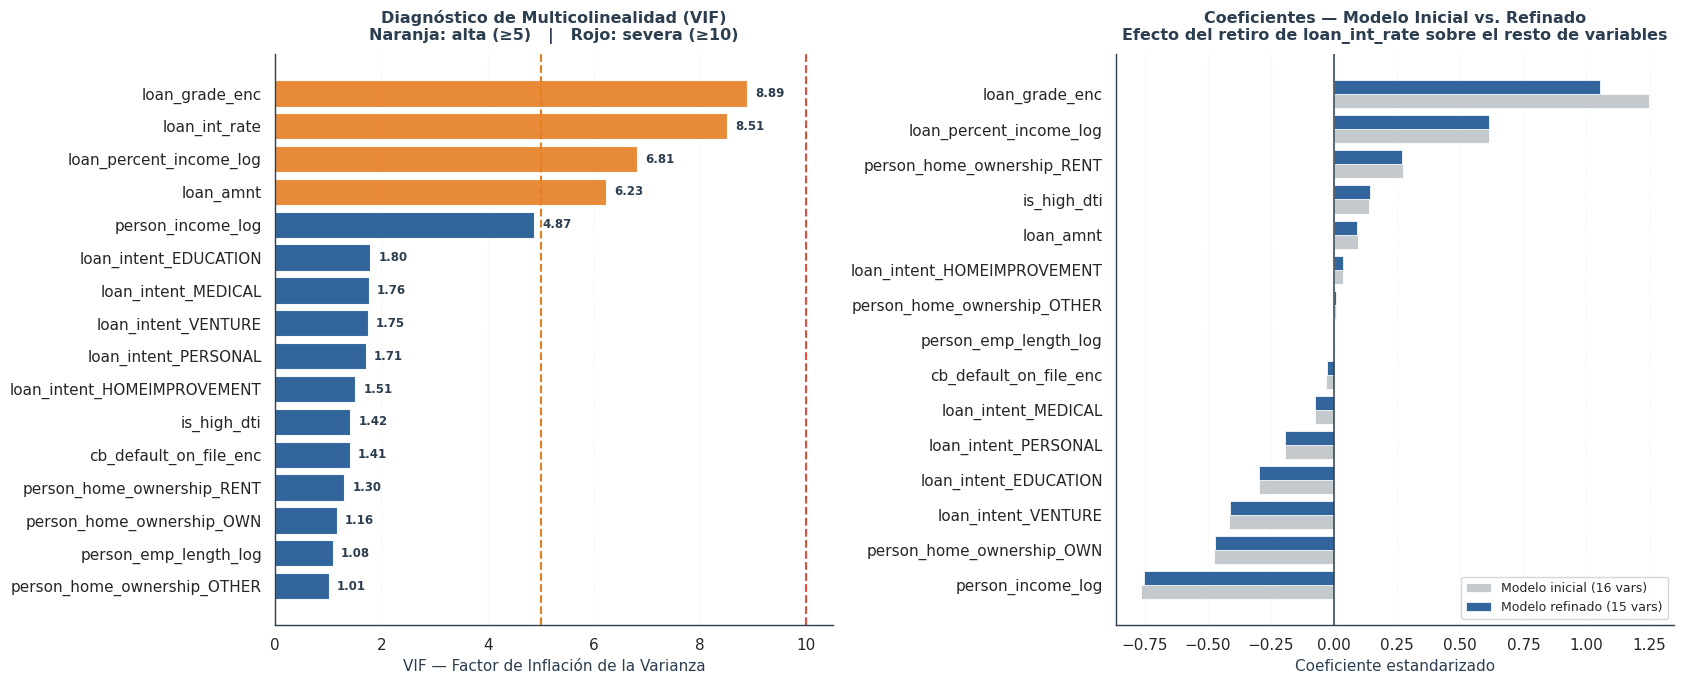

In [27]:
# ===============================================================
# 6.3 DIAGNÓSTICO DE MULTICOLINEALIDAD Y REFINAMIENTO LOGÍSTICO
# ===============================================================
# - VIF sobre la matriz de diseño logística (16 variables).
# - Estabilidad de coeficientes entre los 5 folds de la CV.
# - Refit del modelo logístico sin loan_int_rate y re-chequeo
#   de coherencia de signos.
# El conjunto de variables de XGBoost NO se modifica.
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

SEMILLA = 42

# ===============================================================
# PARTE A — FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
# ===============================================================
# El VIF se calcula sobre las variables estandarizadas, de forma
# coherente con la representación que recibe la regresión logística.
X_std = pd.DataFrame(
    StandardScaler().fit_transform(X_train_log),
    columns=X_train_log.columns,
)
X_vif = add_constant(X_std)   # término constante requerido por el cálculo

vif = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])],
})
vif = vif[vif['variable'] != 'const'].sort_values('VIF', ascending=False)

def clasif_vif(v):
    if v < 5:    return "Baja-moderada"
    elif v < 10: return "Alta (revisar)"
    else:        return "Severa"

vif['diagnostico'] = vif['VIF'].apply(clasif_vif)

print("═" * 68)
print(" PARTE A — FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("═" * 68)
print(f"\n  {'Variable':<32}{'VIF':>10}{'Diagnóstico':>22}")
print("  " + "─" * 64)
for _, f in vif.iterrows():
    print(f"  {f['variable']:<32}{f['VIF']:>10.2f}{f['diagnostico']:>22}")
print("  " + "─" * 64)

severas = vif[vif['VIF'] >= 10]['variable'].tolist()
altas   = vif[(vif['VIF'] >= 5) & (vif['VIF'] < 10)]['variable'].tolist()
if severas:
    print(f"\n  ⚠ Multicolinealidad SEVERA (VIF ≥ 10): {severas}")
if altas:
    print(f"  ⚠ Multicolinealidad ALTA (5 ≤ VIF < 10): {altas}")
if not severas and not altas:
    print(f"\n  ✓ Ninguna variable supera el umbral de advertencia.")

# ===============================================================
# PARTE B — ESTABILIDAD DE COEFICIENTES ENTRE FOLDS
# ===============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

pipe_diag = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', C=0.5,
                               class_weight='balanced', solver='lbfgs',
                               max_iter=1000, random_state=SEMILLA)),
])

coefs_folds = []
for tr_idx, _ in cv.split(X_train_log, y_train):
    pipe_diag.fit(X_train_log.iloc[tr_idx], y_train.iloc[tr_idx])
    coefs_folds.append(pipe_diag.named_steps['clf'].coef_[0])

coefs_folds = pd.DataFrame(coefs_folds, columns=X_train_log.columns)

estab = pd.DataFrame({
    'variable':  X_train_log.columns,
    'coef_min':  coefs_folds.min(),
    'coef_max':  coefs_folds.max(),
    'coef_medio':coefs_folds.mean(),
}).reset_index(drop=True)
# Una variable es inestable si su coeficiente cambia de signo entre folds
estab['cambia_signo'] = (np.sign(estab['coef_min']) !=
                         np.sign(estab['coef_max']))
estab = estab.sort_values('coef_medio', key=abs, ascending=False)

print("\n" + "═" * 68)
print(" PARTE B — ESTABILIDAD DE COEFICIENTES ENTRE LOS 5 FOLDS")
print("═" * 68)
print(f"\n  {'Variable':<28}{'Coef. mín':>12}{'Coef. máx':>12}{'Signo':>14}")
print("  " + "─" * 64)
for _, f in estab.iterrows():
    estado = "⚠ INESTABLE" if f['cambia_signo'] else "✓ estable"
    print(f"  {f['variable']:<28}{f['coef_min']:>12.4f}"
          f"{f['coef_max']:>12.4f}{estado:>14}")
print("  " + "─" * 64)
inestables = estab[estab['cambia_signo']]['variable'].tolist()
print(f"\n  Variables que cambian de signo entre folds: "
      f"{inestables if inestables else 'ninguna'}")

# ===============================================================
# PARTE C — REFIT DEL MODELO LOGÍSTICO SIN loan_int_rate
# ===============================================================
from sklearn.model_selection import GridSearchCV

vars_log_refit = [c for c in X_train_log.columns if c != 'loan_int_rate']
X_train_log_r = X_train_log[vars_log_refit]
X_test_log_r  = X_test_log[vars_log_refit]

print("\n" + "═" * 68)
print(" PARTE C — REFIT DEL MODELO LOGÍSTICO (sin loan_int_rate)")
print("═" * 68)
print(f"\n  Variable excluida: loan_int_rate")
print(f"  Predictores: {X_train_log.shape[1]} → {len(vars_log_refit)}")

pipe_refit = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', class_weight='balanced',
                               solver='lbfgs', max_iter=1000,
                               random_state=SEMILLA)),
])
busqueda_refit = GridSearchCV(
    pipe_refit, {'clf__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]},
    scoring='roc_auc', cv=cv, n_jobs=-1,
)
busqueda_refit.fit(X_train_log_r, y_train)

modelo_log_final = busqueda_refit.best_estimator_
clf_r = modelo_log_final.named_steps['clf']

print(f"\n  AUC CV — modelo inicial (16 vars):  {auc_cv_log:.4f}")
print(f"  AUC CV — modelo refinado ({len(vars_log_refit)} vars): "
      f"{busqueda_refit.best_score_:.4f}")
print(f"  Variación de AUC:                   "
      f"{busqueda_refit.best_score_ - auc_cv_log:+.4f}")
print(f"  C óptimo (modelo refinado):         "
      f"{busqueda_refit.best_params_['clf__C']}")

# --- Re-chequeo de coherencia de signos ---
coefs_r = pd.DataFrame({
    'variable': vars_log_refit,
    'coef': clf_r.coef_[0],
}).sort_values('coef', key=abs, ascending=False).reset_index(drop=True)

signo_esperado = {
    'loan_grade_enc': '+', 'loan_percent_income_log': '+',
    'is_high_dti': '+', 'cb_default_on_file_enc': '+',
    'person_income_log': '-', 'person_emp_length_log': '-',
}
signo = lambda v: '+' if v >= 0 else '-'

print(f"\n  Re-chequeo de coherencia de signos:")
print("  " + "─" * 60)
print(f"  {'Variable':<28}{'Coef.':>11}{'Signo':>8}{'Esperado':>10}{'Estado':>13}")
print("  " + "·" * 58)
incoh = 0
for _, f in coefs_r.iterrows():
    v, c = f['variable'], f['coef']
    if v in signo_esperado:
        s_esp = signo_esperado[v]
        ok = signo(c) == s_esp
        estado = "✓ coherente" if ok else "⚠ REVISAR"
        if not ok: incoh += 1
    else:
        s_esp, estado = "—", "s/ prior"
    print(f"  {v:<28}{c:>11.4f}{signo(c):>8}{s_esp:>10}{estado:>13}")
print("  " + "─" * 60)
print(f"\n  Variables con signo esperado: {len(signo_esperado)}  |  "
      f"Incoherencias: {incoh}")
if incoh == 0:
    print(f"  ✓ Todas las variables con prior económico presentan signo coherente.")

# ===============================================================
# VISUALIZACIÓN — VIF y comparación de coeficientes
# ===============================================================
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# --- Panel izquierdo: VIF ---
vif_plot = vif.sort_values('VIF')
def color_vif(v):
    if v < 5:    return "#1A5490"
    elif v < 10: return "#E67E22"
    else:        return "#E74C3C"
colores_vif = [color_vif(v) for v in vif_plot['VIF']]

ax1 = axes[0]
ax1.barh(vif_plot['variable'], vif_plot['VIF'], color=colores_vif,
         alpha=0.9, edgecolor='white', linewidth=0.8)
for y, v in enumerate(vif_plot['VIF']):
    ax1.text(v + 0.15, y, f"{v:.2f}", va='center', fontsize=8.5,
             fontweight='bold', color="#2C3E50")
ax1.axvline(5,  color="#E67E22", linestyle="--", linewidth=1.5)
ax1.axvline(10, color="#E74C3C", linestyle="--", linewidth=1.5)
ax1.set_xlabel("VIF — Factor de Inflación de la Varianza",
               fontsize=11, color="#2C3E50")
ax1.set_title("Diagnóstico de Multicolinealidad (VIF)\n"
              "Naranja: alta (≥5)   |   Rojo: severa (≥10)",
              fontweight='bold', fontsize=11.5, color="#2C3E50", pad=10)
ax1.grid(True, alpha=0.25, linestyle=':', axis='x')

# --- Panel derecho: coeficientes inicial vs refinado ---
comp = coefs_r[['variable', 'coef']].rename(columns={'coef': 'refinado'})
comp = comp.merge(
    pd.DataFrame({'variable': X_train_log.columns, 'inicial': clf.coef_[0]}),
    on='variable', how='left').sort_values('refinado')

ax2 = axes[1]
y = np.arange(len(comp))
ax2.barh(y - 0.2, comp['inicial'], height=0.4, color="#BDC3C7",
         alpha=0.9, edgecolor='white', linewidth=0.6, label='Modelo inicial (16 vars)')
ax2.barh(y + 0.2, comp['refinado'], height=0.4, color="#1A5490",
         alpha=0.9, edgecolor='white', linewidth=0.6, label='Modelo refinado (15 vars)')
ax2.axvline(0, color="#2C3E50", linewidth=1.1)
ax2.set_yticks(y)
ax2.set_yticklabels(comp['variable'])
ax2.set_xlabel("Coeficiente estandarizado", fontsize=11, color="#2C3E50")
ax2.set_title("Coeficientes — Modelo Inicial vs. Refinado\n"
              "Efecto del retiro de loan_int_rate sobre el resto de variables",
              fontweight='bold', fontsize=11.5, color="#2C3E50", pad=10)
ax2.legend(fontsize=9, loc='lower right')
ax2.grid(True, alpha=0.25, linestyle=':', axis='x')

plt.tight_layout()
plt.show()

### Interpretación del Diagnóstico y Decisión de Refinamiento

El diagnóstico aportó tres líneas de evidencia que, en conjunto, fundamentan el refinamiento del modelo logístico.

**El VIF confirma la redundancia, sin alcanzar el umbral severo.** El Factor de Inflación de la Varianza ubicó cuatro variables en la banda alta (5–10): `loan_grade_enc` (8,89) y `loan_int_rate` (8,51) por un lado, y `loan_percent_income_log` (6,81) y `loan_amnt` (6,23) por otro. Ninguna superó el umbral severo (≥ 10). El primer par cuantifica, sobre la matriz de diseño codificada, la redundancia grado–tasa que el chequeo de signos de la sección 6.2 había anticipado; el segundo refleja una relación definicional —el ratio de endeudamiento se calcula a partir del monto y el ingreso—. Que el VIF se ubique en zona de advertencia y no en zona severa es la razón por la que la decisión de exclusión no se apoya en este indicador de forma aislada, sino en su conjunción con un síntoma observable sobre el modelo.

**El análisis de estabilidad distingue la reversión genuina del ruido.** El coeficiente de `loan_int_rate` se mantuvo negativo en las cinco particiones de la validación cruzada (rango −0,23 a −0,19). Su signo —contrario al prior económico, que establece que una tasa mayor implica más riesgo— no es un accidente de la muestra: es **sistemático**. Esta es la evidencia decisiva. En contraste, `person_emp_length_log` y `person_home_ownership_OTHER` cambian de signo entre particiones: su coeficiente oscila en torno a cero y su signo carece de determinación.

**Materialidad: no toda incoherencia de signo es un defecto.** La lectura conjunta de ambos diagnósticos obliga a una distinción que un chequeo de signo binario no captura. Una incoherencia es un **defecto real** cuando el coeficiente tiene magnitud apreciable y, aun así, contradice de forma estable el prior económico —el caso de `loan_int_rate`—. Cuando la magnitud del coeficiente es indistinguible de cero, en cambio, la variable no tiene un efecto que pueda ser coherente o incoherente: simplemente no contribuye. El signo de un coeficiente nulo es una propiedad del ruido, no del riesgo.

**Decisión sobre las variables señaladas.**

- **`loan_int_rate` — se excluye.** La conjunción es concluyente: VIF en banda alta, reversión de signo sistemática y redundancia con el grado documentada desde el Capítulo 3 (η² = 0,905; de hecho, los valores faltantes de tasa fueron imputados a partir del grado). En un modelo destinado a una scorecard auditable, un coeficiente que contradice de forma sistemática la teoría económica es inadmisible. El refit confirmó el diagnóstico: al excluir la variable, el AUC de validación cruzada varió en −0,0002 —la tasa no aportaba poder predictivo propio—.

- **`person_emp_length_log` — se excluye por parsimonia.** Toda la evidencia converge: poder predictivo débil (IV = 0,06, Capítulo 5), VIF de 1,08 —sin multicolinealidad—, coeficiente prácticamente nulo e inestable entre particiones. La variable no aporta discriminación; su permanencia solo añadiría una incoherencia de signo aparente sobre un coeficiente sin contenido.

- **`cb_default_on_file_enc` — se excluye por redundancia con el grado.** Su coeficiente multivariado es de magnitud despreciable (−0,03) y de signo levemente negativo de forma consistente —contrario al prior—. El motivo no es la multicolinealidad estructural (VIF de 1,41), sino una redundancia respecto de la variable objetivo: el grado crediticio, que en este dataset incorpora el comportamiento de buró, absorbe la señal del antecedente de default. La información de buró no se pierde —permanece en el modelo a través de `loan_grade_enc`—; lo que se elimina es la representación redundante de esa misma señal.

**Variables de VIF alto que se conservan.** El segundo cúmulo identificado por el VIF —`loan_percent_income_log`, `loan_amnt` e `person_income`— se conserva sin modificación. El VIF señaló una redundancia potencial, pero el diagnóstico no encontró ningún síntoma sobre el modelo: los tres coeficientes son coherentes con su prior (DTI e ingreso) o no admiten un prior a priori (monto), y todos son estables entre particiones. El VIF es un indicador de redundancia potencial, no una regla automática de exclusión: investigado el cúmulo, se constató que no deteriora ni la coherencia ni la estabilidad del modelo, por lo que se retiene íntegramente. `loan_amnt` se mantiene además en línea con la selección de variables del Capítulo 5.

**Conjunto final del modelo logístico.** El refinamiento excluye tres variables —`loan_int_rate`, `person_emp_length_log` y `cb_default_on_file_enc`— y deja un modelo de **13 predictores**. Las tres exclusiones aplican exclusivamente al conjunto de la Regresión Logística: el modelo XGBoost conserva las 18 variables, dado que su naturaleza basada en árboles es robusta tanto a la multicolinealidad como a la presencia de variables de aporte marginal. La sección siguiente ejecuta el ajuste final del modelo logístico sobre este conjunto depurado.

══════════════════════════════════════════════════════════════════════
 REFINAMIENTO DEL MODELO LOGÍSTICO — TRAZABILIDAD
══════════════════════════════════════════════════════════════════════

  Etapa                                   Variables       AUC CV
  ──────────────────────────────────────────────────────────────
  Modelo inicial (6.2)                           16       0.8696
  Refit sin loan_int_rate (6.3-C)                15       0.8693
  Modelo final (6.3-D)                           13       0.8694
  ──────────────────────────────────────────────────────────────

  Variación de AUC (inicial → final): -0.0001
  C óptimo del modelo final:          0.05

  Variables excluidas en el refinamiento:
    • loan_int_rate
    • person_emp_length_log
    • cb_default_on_file_enc

══════════════════════════════════════════════════════════════════════
 CHEQUEO DE COHERENCIA DE SIGNOS — MODELO LOGÍSTICO FINAL
══════════════════════════════════════════════════════════════════════

  Var

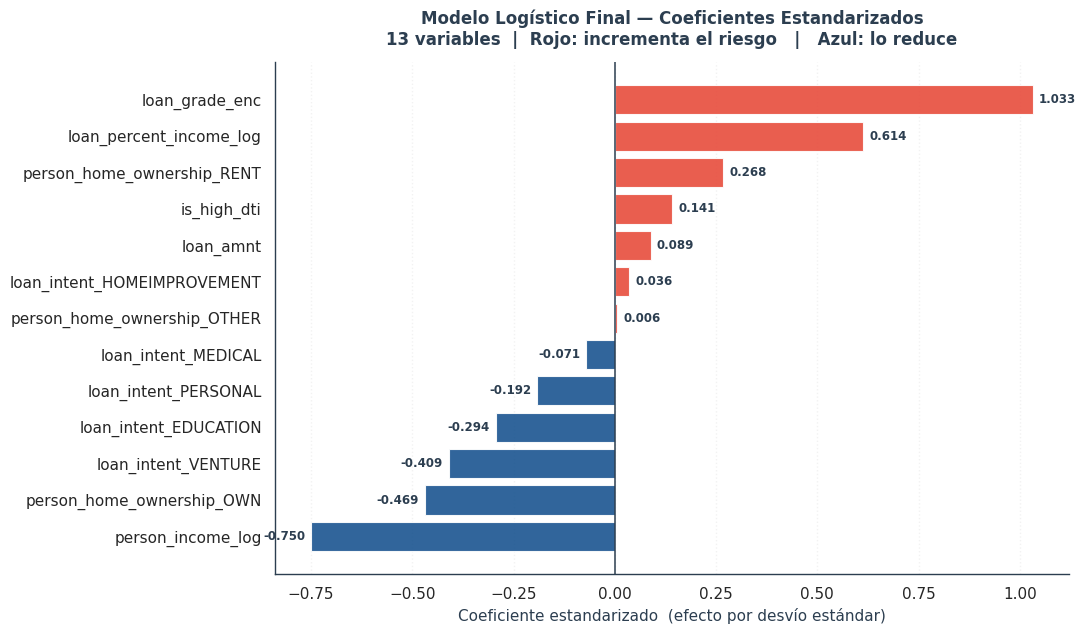

In [28]:
# ===============================================================
# 6.3 (cont.) — REFINAMIENTO FINAL DEL MODELO LOGÍSTICO
# ===============================================================
# Ejecuta la decisión del diagnóstico. El conjunto logístico final
# excluye tres variables:
#   loan_int_rate         → reversión de signo sistémica (multicol.)
#   person_emp_length_log → contribución multivariada nula
#   cb_default_on_file_enc→ redundante con loan_grade (señal de buró)
# El conjunto de XGBoost NO se modifica.
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

SEMILLA = 42
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

# ---------------------------------------------------------------
# 1. Conjunto final de variables del modelo logístico
# ---------------------------------------------------------------
vars_excluidas = ['loan_int_rate', 'person_emp_length_log',
                  'cb_default_on_file_enc']
vars_log_final = [c for c in X_train_log.columns if c not in vars_excluidas]

X_train_log_final = X_train_log[vars_log_final]
X_test_log_final  = X_test_log[vars_log_final]

# ---------------------------------------------------------------
# 2. Ajuste del modelo logístico final (C por validación cruzada)
# ---------------------------------------------------------------
pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(penalty='l2', class_weight='balanced',
                               solver='lbfgs', max_iter=1000,
                               random_state=SEMILLA)),
])
busqueda_final = GridSearchCV(
    pipe_final, {'clf__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]},
    scoring='roc_auc', cv=cv, n_jobs=-1,
)
busqueda_final.fit(X_train_log_final, y_train)

modelo_log_final = busqueda_final.best_estimator_
clf_f = modelo_log_final.named_steps['clf']

# ---------------------------------------------------------------
# 3. Trazabilidad del refinamiento — AUC en cada etapa
# ---------------------------------------------------------------
print("═" * 70)
print(" REFINAMIENTO DEL MODELO LOGÍSTICO — TRAZABILIDAD")
print("═" * 70)
print(f"\n  {'Etapa':<38}{'Variables':>11}{'AUC CV':>13}")
print("  " + "─" * 62)
print(f"  {'Modelo inicial (6.2)':<38}{X_train_log.shape[1]:>11}"
      f"{auc_cv_log:>13.4f}")
print(f"  {'Refit sin loan_int_rate (6.3-C)':<38}{len(vars_log_refit):>11}"
      f"{busqueda_refit.best_score_:>13.4f}")
print(f"  {'Modelo final (6.3-D)':<38}{len(vars_log_final):>11}"
      f"{busqueda_final.best_score_:>13.4f}")
print("  " + "─" * 62)
print(f"\n  Variación de AUC (inicial → final): "
      f"{busqueda_final.best_score_ - auc_cv_log:+.4f}")
print(f"  C óptimo del modelo final:          "
      f"{busqueda_final.best_params_['clf__C']}")
print(f"\n  Variables excluidas en el refinamiento:")
for v in vars_excluidas:
    print(f"    • {v}")

# ---------------------------------------------------------------
# 4. Chequeo de coherencia de signos — modelo final
# ---------------------------------------------------------------
coefs_f = pd.DataFrame({
    'variable': vars_log_final,
    'coef': clf_f.coef_[0],
}).sort_values('coef', key=abs, ascending=False).reset_index(drop=True)

signo_esperado = {
    'loan_grade_enc': '+', 'loan_percent_income_log': '+',
    'is_high_dti': '+', 'person_income_log': '-',
}
signo = lambda v: '+' if v >= 0 else '-'

print("\n" + "═" * 70)
print(" CHEQUEO DE COHERENCIA DE SIGNOS — MODELO LOGÍSTICO FINAL")
print("═" * 70)
print(f"\n  {'Variable':<30}{'Coef.':>11}{'Signo':>8}{'Esperado':>11}{'Estado':>13}")
print("  " + "─" * 68)
incoh = 0
for _, f in coefs_f.iterrows():
    v, c = f['variable'], f['coef']
    if v in signo_esperado:
        s_esp = signo_esperado[v]
        ok = signo(c) == s_esp
        estado = "✓ coherente" if ok else "⚠ REVISAR"
        if not ok:
            incoh += 1
    else:
        s_esp, estado = "—", "s/ prior"
    print(f"  {v:<30}{c:>11.4f}{signo(c):>8}{s_esp:>11}{estado:>13}")
print("  " + "─" * 68)
print(f"\n  Variables con prior económico: {len(signo_esperado)}  |  "
      f"Incoherencias: {incoh}")
if incoh == 0:
    print(f"  ✓ Todas las variables con signo esperado son coherentes.")
    print(f"  ✓ El modelo final es apto como baseline regulatorio.")
else:
    print(f"  ⚠ Persisten {incoh} incoherencia(s) — requiere análisis.")

# ---------------------------------------------------------------
# 5. Visualización — coeficientes del modelo logístico final
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

coefs_plot = coefs_f.sort_values('coef')
COLOR_RIESGO, COLOR_PROTEGE = "#E74C3C", "#1A5490"
colores = [COLOR_RIESGO if c >= 0 else COLOR_PROTEGE
           for c in coefs_plot['coef']]

fig, ax = plt.subplots(figsize=(11, 6.5))
barras = ax.barh(coefs_plot['variable'], coefs_plot['coef'],
                 color=colores, alpha=0.9, edgecolor='white', linewidth=0.8)
for barra, c in zip(barras, coefs_plot['coef']):
    ha = 'left' if c >= 0 else 'right'
    off = 0.015 if c >= 0 else -0.015
    ax.text(c + off, barra.get_y() + barra.get_height()/2,
            f"{c:.3f}", va='center', ha=ha, fontsize=8.5,
            fontweight='bold', color="#2C3E50")
ax.axvline(0, color="#2C3E50", linewidth=1.1)
ax.set_xlabel("Coeficiente estandarizado  (efecto por desvío estándar)",
              fontsize=11, color="#2C3E50")
ax.set_title("Modelo Logístico Final — Coeficientes Estandarizados\n"
             f"{len(vars_log_final)} variables  |  "
             "Rojo: incrementa el riesgo   |   Azul: lo reduce",
             fontweight='bold', fontsize=12, color="#2C3E50", pad=12)
ax.grid(True, alpha=0.25, linestyle=':', axis='x')
plt.tight_layout()
plt.show()

### Interpretación del Refinamiento Final

El ajuste final confirma, con tres líneas de evidencia convergentes, que el refinamiento fue correcto y que el modelo logístico resultante es apto como baseline regulatorio.

**La discriminación se mantuvo intacta.** La trazabilidad del proceso muestra una variación de AUC de apenas −0,0001 a lo largo de las tres etapas (16 variables: 0,8696 → 15 variables: 0,8693 → 13 variables: 0,8694). Que quitar tres variables prácticamente no mueva la métrica de discriminación es la confirmación empírica más directa de que esas variables no aportaban señal propia: toda su información estaba contenida en el resto del modelo. Un modelo más parsimonioso con la misma capacidad discriminante es, por definición, preferible.

**El chequeo de signos quedó limpio.** Las cuatro variables con prior económico unívoco presentan el signo esperado sin excepción: `loan_grade_enc` (+1,033), `loan_percent_income_log` (+0,614), `is_high_dti` (+0,141) y `person_income_log` (−0,750). El modelo puede leerse y auditarse variable por variable, que es la condición que habilita su uso como base de una *scorecard*.

**Los coeficientes son económicamente coherentes en conjunto.** Más allá de las cuatro variables con prior formal, los coeficientes restantes admiten una lectura de negocio sensata en todos los casos. Las *dummies* de situación habitacional se interpretan en relación a la categoría de referencia (MORTGAGE): ser propietario sin hipoteca (OWN, −0,469) reduce el riesgo respecto de quien tiene hipoteca, mientras que el alquiler (RENT, +0,268) lo incrementa — un patrón coherente con el EDA (sección 4.3.1) y con la lógica de estabilidad patrimonial. Las *dummies* de intención del préstamo se interpretan respecto de la consolidación de deudas (DEBTCONSOLIDATION, la categoría de mayor riesgo del EDA): todas las demás finalidades muestran coeficientes negativos o próximos a cero, lo que significa menor riesgo relativo — también coherente con los hallazgos del capítulo 4.

**El modelo logístico final: 13 variables, modelo auditable.** El conjunto resultante concentra el poder predictivo en las variables que el análisis WoE/IV del Capítulo 5 identificó como las de mayor capacidad discriminante, elimina la redundancia que generaba incoherencia de signos y prescinde de variables sin contribución multivariada. Es un modelo que un área de validación puede auditar coeficiente por coeficiente, y cuya lógica puede comunicarse a un comité de riesgo sin necesidad de abrir ninguna caja negra.

Con el modelo logístico validado y sus predicciones disponibles, la sección 6.4 construye el Challenger: XGBoost.

## 6.4 Modelo 2: XGBoost (Challenger)

El segundo componente del esquema Champion–Challenger es **XGBoost** (*Extreme Gradient Boosting*), un modelo de alta capacidad predictiva que actúa como Challenger frente al baseline logístico.

### Qué es el Gradient Boosting

El *gradient boosting* construye su modelo de forma **secuencial**: parte de una predicción inicial y entrena una serie de **árboles de decisión**, donde cada árbol nuevo se especializa en corregir los errores que cometió el conjunto de árboles anteriores. El proceso puede describirse en tres pasos:

1. El modelo calcula los errores residuales de su predicción actual.
2. Entrena un árbol nuevo para predecir esos errores.
3. Suma ese árbol al modelo, reduciendo el error total.

Al repetir este proceso cientos de veces, el modelo construye un ensamble que captura patrones progresivamente más sutiles en los datos. **XGBoost** es la implementación más consolidada del gradient boosting: agrega regularización explícita, submuestreo aleatorio de datos y variables, y una serie de optimizaciones computacionales que lo vuelven robusto al sobreajuste y eficiente en datasets de tamaño mediano.

A diferencia de la Regresión Logística —que asume una relación lineal entre predictores y riesgo—, XGBoost captura **relaciones no lineales e interacciones** entre variables de forma automática. En particular, puede modelar la relación en forma de U que el EDA (sección 4.3.2) detectó en `loan_amnt`, sin necesidad de transformación manual.

### Hiperparámetros del modelo

A diferencia de la Regresión Logística, donde el único hiperparámetro a ajustar era `C`, XGBoost expone un espacio de configuración más amplio. Cada hiperparámetro controla una dimensión distinta de la complejidad del modelo:

| Hiperparámetro | Función | Efecto de aumentar el valor |
|---|---|---|
| `n_estimators` | Número de árboles en el ensamble | Más capacidad, más riesgo de sobreajuste |
| `max_depth` | Profundidad máxima de cada árbol | Árboles más complejos, más interacciones |
| `learning_rate` | Tamaño de paso al sumar cada árbol | Aprendizaje más lento, más conservador |
| `subsample` | Fracción de registros por árbol | Más diversidad, menos sobreajuste |
| `colsample_bytree` | Fracción de variables por árbol | Más diversidad, menos correlación entre árboles |
| `gamma` | Ganancia mínima para realizar un corte | Árboles más simples y conservadores |
| `reg_lambda` | Penalización L2 sobre los pesos de las hojas | Coeficientes más moderados (regularización) |
| `min_child_weight` | Peso mínimo de instancias por hoja | Previene divisiones sobre grupos pequeños |

Existe un trade-off central entre `n_estimators` y `learning_rate`: un ritmo de aprendizaje bajo con muchos árboles suele producir mejores resultados que un ritmo alto con pocos, pero requiere más tiempo de cómputo. La búsqueda de hiperparámetros explora ambas dimensiones en conjunto.

### Tratamiento del desbalance: `scale_pos_weight`

XGBoost incluye un mecanismo nativo para carteras desbalanceadas: el parámetro `scale_pos_weight`. Funciona de forma análoga a `class_weight='balanced'` de la regresión logística: asigna un peso mayor a los casos de default en la función de pérdida, de modo que el modelo no los relega frente a la clase mayoritaria.

El valor óptimo es la razón entre el número de casos negativos (cumplidores) y el número de casos positivos (defaults) en el entrenamiento:

$$scale\_pos\_weight = \frac{N_{cumplidores}}{N_{defaults}}$$

Este valor se calcula directamente de `y_train`, garantizando que se ajuste al desbalance real de la muestra y no dependa de un supuesto externo.

### Estrategia de búsqueda de hiperparámetros

Con ocho hiperparámetros y cuatro valores posibles por parámetro, una búsqueda exhaustiva (*grid search*) requeriría evaluar cientos de miles de combinaciones — inviable en tiempo de cómputo. Se aplica en cambio una **búsqueda aleatoria** (*RandomizedSearchCV*): se muestrean aleatoriamente `n_iter = 30` combinaciones del espacio de configuración y se evalúa cada una mediante validación cruzada estratificada de 5 particiones.

La búsqueda aleatoria es el estándar para modelos con muchos hiperparámetros: investigación empírica (Bergstra & Bengio, 2012) muestra que, con un número moderado de iteraciones, cubre el espacio de manera más eficiente que la búsqueda exhaustiva, y su menor costo computacional permite explorar rangos más amplios por hiperparámetro.

Toda la búsqueda ocurre sobre el conjunto de entrenamiento, sin contacto con el conjunto de prueba, respetando el principio de no fuga de información del capítulo.

### Por qué XGBoost no requiere estandarización

A diferencia de la Regresión Logística, los modelos basados en árboles de decisión son **invariantes a la escala** de las variables: las decisiones de corte se basan en el orden relativo de los valores, no en su magnitud absoluta. Multiplicar una variable por mil no altera ninguna partición del árbol. Por esta razón, `X_train_xgb` se utiliza directamente, sin pasar por un `StandardScaler`, y las 18 variables permanecen en sus escalas originales.

### Importancia de variables (ganancia)

Una vez ajustado el modelo, se reporta la **importancia de variables por ganancia** (*gain*): para cada variable, se calcula la reducción promedio de la función de pérdida cada vez que esa variable se usa como punto de corte en algún árbol. Una variable con alta ganancia contribuye con particiones que mejoran sustancialmente las predicciones; una con ganancia baja apenas afecta el resultado.

La ganancia es la medida de importancia más informativa para aplicaciones de scoring, porque refleja el aporte efectivo al poder predictivo y no simplemente la frecuencia de uso de la variable.

════════════════════════════════════════════════════════════════════
 CONFIGURACIÓN DEL MODELO XGBOOST
════════════════════════════════════════════════════════════════════

  Variables predictoras:        18
  Registros de entrenamiento:   25,908

  Desbalance de clases:
    Cumplidores (clase 0):      20,241
    Defaults    (clase 1):      5,667
    scale_pos_weight:           3.5717

  Espacio de búsqueda total:    49,152 combinaciones
  Iteraciones muestreadas:      30  (RandomizedSearchCV)
  Validación cruzada:           5-fold estratificada

  Ejecutando búsqueda de hiperparámetros...
  ✓ Búsqueda completada.

════════════════════════════════════════════════════════════════════
 RESULTADO DE LA BÚSQUEDA — XGBOOST
════════════════════════════════════════════════════════════════════

  AUC validación cruzada (5-fold):  0.9474 ± 0.0069

  Hiperparámetros óptimos:
    colsample_bytree       0.7
    gamma                  0.1
    learning_rate          0.1
    max_depth              6


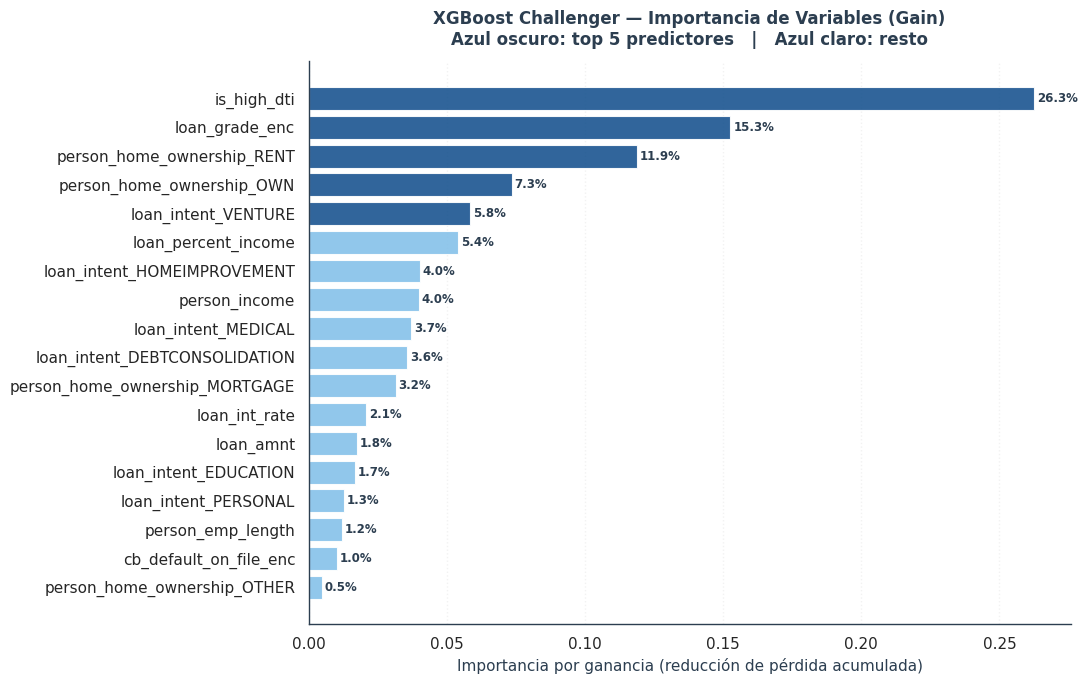

In [29]:
# ===============================================================
# 6.4 MODELO 2 — XGBOOST (CHALLENGER)
# ===============================================================
# - Desbalance tratado con scale_pos_weight (calculado de y_train).
# - 8 hiperparámetros ajustados por RandomizedSearchCV (n_iter=30)
#   con validación cruzada estratificada de 5 particiones.
# - No requiere estandarización: los árboles son invariantes a escala.
# - Importancia de variables por ganancia (gain).
# - El conjunto X_train_xgb conserva las 18 variables originales.
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

SEMILLA = 42

# ---------------------------------------------------------------
# 1. Cálculo de scale_pos_weight — directo de y_train
# ---------------------------------------------------------------
n_cumplidores = (y_train == 0).sum()
n_defaults    = (y_train == 1).sum()
spw           = n_cumplidores / n_defaults

print("═" * 68)
print(" CONFIGURACIÓN DEL MODELO XGBOOST")
print("═" * 68)
print(f"\n  Variables predictoras:        {X_train_xgb.shape[1]}")
print(f"  Registros de entrenamiento:   {X_train_xgb.shape[0]:,}")
print(f"\n  Desbalance de clases:")
print(f"    Cumplidores (clase 0):      {n_cumplidores:,}")
print(f"    Defaults    (clase 1):      {n_defaults:,}")
print(f"    scale_pos_weight:           {spw:.4f}")

# ---------------------------------------------------------------
# 2. Definición del modelo base
# ---------------------------------------------------------------
xgb_base = xgb.XGBClassifier(
    objective      = 'binary:logistic',
    scale_pos_weight = spw,
    random_state   = SEMILLA,
    n_jobs         = -1,
    verbosity      = 0,
)

# ---------------------------------------------------------------
# 3. Espacio de búsqueda de hiperparámetros
# ---------------------------------------------------------------
param_dist = {
    'n_estimators':     [100, 200, 300, 400],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.15],
    'subsample':        [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'gamma':            [0, 0.1, 0.5, 1.0],
    'reg_lambda':       [1.0, 5.0, 10.0],
    'min_child_weight': [1, 3, 5, 10],
}

total_combinaciones = 1
for v in param_dist.values():
    total_combinaciones *= len(v)
print(f"\n  Espacio de búsqueda total:    {total_combinaciones:,} combinaciones")
print(f"  Iteraciones muestreadas:      30  (RandomizedSearchCV)")
print(f"  Validación cruzada:           5-fold estratificada")

# ---------------------------------------------------------------
# 4. Búsqueda aleatoria de hiperparámetros
# ---------------------------------------------------------------
cv_estrat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

busqueda_xgb = RandomizedSearchCV(
    xgb_base,
    param_distributions = param_dist,
    n_iter              = 30,
    scoring             = 'roc_auc',
    cv                  = cv_estrat,
    random_state        = SEMILLA,
    n_jobs              = -1,
    verbose             = 0,
)

print("\n  Ejecutando búsqueda de hiperparámetros...")
busqueda_xgb.fit(X_train_xgb, y_train)
print("  ✓ Búsqueda completada.")

modelo_xgb_final = busqueda_xgb.best_estimator_
auc_cv_xgb = busqueda_xgb.best_score_
std_cv_xgb = busqueda_xgb.cv_results_['std_test_score'][busqueda_xgb.best_index_]

# ---------------------------------------------------------------
# 5. Reporte del ajuste
# ---------------------------------------------------------------
print("\n" + "═" * 68)
print(" RESULTADO DE LA BÚSQUEDA — XGBOOST")
print("═" * 68)
print(f"\n  AUC validación cruzada (5-fold):  {auc_cv_xgb:.4f} ± {std_cv_xgb:.4f}")
print(f"\n  Hiperparámetros óptimos:")
bp = busqueda_xgb.best_params_
for param, val in sorted(bp.items()):
    print(f"    {param:<22} {val}")

# Top 10 configuraciones por AUC
resultados_cv = pd.DataFrame(busqueda_xgb.cv_results_)
resultados_cv = resultados_cv.sort_values('mean_test_score',
                                          ascending=False).reset_index(drop=True)
print(f"\n  Top 10 configuraciones evaluadas:")
print(f"  {'#':>4}{'AUC CV':>10}{'Desvío':>10}   Configuración resumida")
print("  " + "─" * 64)
for i, row in resultados_cv.head(10).iterrows():
    params_str = (
        f"depth={row['param_max_depth']}  "
        f"lr={row['param_learning_rate']}  "
        f"trees={row['param_n_estimators']}  "
        f"sub={row['param_subsample']}"
    )
    marca = "  ← óptimo" if i == 0 else ""
    print(f"  {i+1:>4}{row['mean_test_score']:>10.4f}"
          f"{row['std_test_score']:>10.4f}   {params_str}{marca}")

# Comparativa logística vs XGBoost (CV)
print("\n" + "═" * 68)
print(" COMPARATIVA DE AUC CV — LOGÍSTICA vs XGBOOST")
print("═" * 68)
print(f"\n  {'Modelo':<35}{'AUC CV':>10}{'Desvío':>10}")
print("  " + "─" * 54)
print(f"  {'Regresión Logística (13 vars)':<35}"
      f"{auc_cv_log:>10.4f}{std_cv_log:>10.4f}")
print(f"  {'XGBoost (18 vars)':<35}"
      f"{auc_cv_xgb:>10.4f}{std_cv_xgb:>10.4f}")
print(f"\n  Diferencia de AUC CV: {auc_cv_xgb - auc_cv_log:+.4f}")
print("  (Evaluación final sobre el conjunto de prueba → Capítulo 7)")

# ---------------------------------------------------------------
# 6. Importancia de variables por ganancia (gain)
# ---------------------------------------------------------------
importancia = pd.DataFrame({
    'variable':   X_train_xgb.columns,
    'ganancia':   modelo_xgb_final.feature_importances_,
}).sort_values('ganancia', ascending=False).reset_index(drop=True)

importancia['ganancia_pct'] = importancia['ganancia'] / importancia['ganancia'].sum() * 100

print("\n" + "═" * 68)
print(" IMPORTANCIA DE VARIABLES — GANANCIA (GAIN)")
print("═" * 68)
print(f"\n  {'#':>4}{'Variable':<30}{'Ganancia':>12}{'% del total':>13}")
print("  " + "─" * 58)
for i, f in importancia.iterrows():
    print(f"  {i+1:>4}{f['variable']:<30}{f['ganancia']:>12.4f}"
          f"{f['ganancia_pct']:>12.2f}%")

# ---------------------------------------------------------------
# 7. Visualización — importancia de variables
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

imp_plot = importancia.sort_values('ganancia')
COLOR_PRINCIPAL = "#1A5490"
COLOR_BAJO      = "#85C1E9"
umbral_top5 = importancia['ganancia'].nlargest(5).min()
colores = [COLOR_PRINCIPAL if v >= umbral_top5 else COLOR_BAJO
           for v in imp_plot['ganancia']]

fig, ax = plt.subplots(figsize=(11, 7))
barras = ax.barh(imp_plot['variable'], imp_plot['ganancia'],
                 color=colores, alpha=0.9, edgecolor='white', linewidth=0.8)
for barra, g, pct in zip(barras, imp_plot['ganancia'],
                          imp_plot['ganancia_pct']):
    ax.text(barra.get_width() + 0.001,
            barra.get_y() + barra.get_height()/2,
            f"{pct:.1f}%", va='center', fontsize=8.5,
            fontweight='bold', color="#2C3E50")

ax.set_xlabel("Importancia por ganancia (reducción de pérdida acumulada)",
              fontsize=11, color="#2C3E50")
ax.set_title("XGBoost Challenger — Importancia de Variables (Gain)\n"
             "Azul oscuro: top 5 predictores   |   Azul claro: resto",
             fontweight='bold', fontsize=12, color="#2C3E50", pad=12)
ax.grid(True, alpha=0.25, linestyle=':', axis='x')
plt.tight_layout()
plt.show()

### Interpretación del Challenger XGBoost

El ajuste del modelo XGBoost entregó tres resultados con implicancias directas para el esquema Champion–Challenger.

**Desempeño del Challenger: AUC 0,9474.** El modelo alcanzó un AUC de validación cruzada de 0,9474 ± 0,0069, con una diferencia de +0,0778 sobre el baseline logístico (0,8696). Se trata de una brecha de magnitud no trivial: en la escala del AUC, donde las diferencias entre modelos competitivos suelen medirse en centésimas, casi ocho puntos porcentuales representan una ventaja predictiva sustancial. El desvío entre particiones (±0,0069) es bajo y comparable al de la logística (±0,0063), lo que indica que el desempeño superior es estable y no es un accidente de la muestra.

Cabe precisar el alcance de esta comparativa: ambos valores provienen de validación cruzada sobre el conjunto de entrenamiento. La evaluación formal sobre el conjunto de prueba —con curvas ROC, estadístico KS y Gini— se realiza en el Capítulo 7, donde ambos modelos se miden en condiciones idénticas sobre datos que ninguno vio durante el ajuste.

**La configuración óptima revela la naturaleza del problema.** Los hiperparámetros seleccionados por la búsqueda —`max_depth=6`, `n_estimators=300`, `learning_rate=0.1`, `subsample=1.0`, `colsample_bytree=0.7`, `gamma=0.1`, `reg_lambda=5.0`, `min_child_weight=5`— describen un modelo de capacidad moderada-alta con regularización activa. La profundidad máxima de 6 niveles permite capturar interacciones entre variables sin construir árboles extremadamente complejos; la combinación de `reg_lambda=5.0` y `min_child_weight=5` actúa como freno adicional al sobreajuste. El subconjunto aleatorio de variables por árbol (`colsample_bytree=0.7`) introduce diversidad entre los árboles del ensamble. En conjunto, la configuración sugiere que el dataset tiene estructura no lineal real que justifica la capacidad del modelo —el XGBoost no necesita profundidad máxima ni regularización mínima para rendir bien—.

**El ranking de importancia cierra el círculo narrativo del proyecto.** El predictor más importante del modelo XGBoost —con el 26,3% de la ganancia total— es `is_high_dti`, la variable derivada construida en la sección 5.2 a partir de un hallazgo del Tier 3 del Gobierno de Datos (sección 2.3). La decisión metodológica de modelar el sobre-endeudamiento en lugar de filtrarlo generó, en el modelo de mayor capacidad del proyecto, la señal predictiva más potente. Es el resultado más concreto de la integración entre el pipeline de calidad de datos y el modelado.

El grado crediticio ocupa el segundo lugar (15,3%) y la situación habitacional suma un 19,3% adicional entre sus categorías (RENT 11,9% + OWN 7,3%), superando en conjunto al ingreso crudo (4,0%). XGBoost capturó de forma directa la señal de la tenencia del inmueble —que en el EDA (4.3.1) mostró una brecha de tasa de default de casi 20 puntos porcentuales entre inquilinos y propietarios sin hipoteca— sin necesidad de transformación ni codificación especial.

**`loan_int_rate` en XGBoost confirma la decisión logística.** La tasa de interés aparece en la posición 12 con apenas el 2,1% de la ganancia. Que en un modelo que conserva las 18 variables y es libre de asignar importancia sin restricciones lineales la tasa ocupe ese lugar ratifica, de forma independiente, la decisión de excluirla del modelo logístico: su señal es marginal, y en presencia del grado crediticio no agrega discriminación relevante. La diferencia es que XGBoost puede tenerla sin daño; la logística no podía.

**Lectura preliminar del dilema Champion–Challenger.** La brecha de AUC CV (+0,0778) plantea la pregunta central que el Capítulo 9 responderá con evidencia formal: ¿el salto de capacidad predictiva del Challenger justifica el costo en interpretabilidad? Un modelo con AUC ~0,95 que no puede explicar sus decisiones variable a variable enfrenta resistencia regulatoria en la mayoría de los marcos de supervisión bancaria. Un modelo con AUC ~0,87 que es completamente auditable puede ser preferible en un entorno de originación regulada, aun dejando capacidad predictiva sobre la mesa. La respuesta no es obvia y depende del uso concreto del modelo — esa tensión es, precisamente, el objeto del Capítulo 9.

## 6.5 Diagnóstico de Generalización

Ambos modelos fueron ajustados y optimizados sobre el conjunto de entrenamiento. Esta sección evalúa si ese ajuste **generaliza** a datos nuevos — concretamente, al conjunto de prueba que ningún modelo vio durante el proceso de construcción.

### Qué es el sobreajuste y por qué importa

Un modelo aprende patrones a partir de los datos de entrenamiento. El riesgo es que, además de los patrones reales y generalizables, aprenda también el **ruido específico** de esa muestra — variaciones aleatorias que no se repetirán en datos nuevos. Cuando eso ocurre, el modelo tiene un desempeño artificialmente elevado en entrenamiento y uno sensiblemente menor en producción. Ese fenómeno se llama **sobreajuste** (*overfitting*).

La forma estándar de detectarlo es medir la **brecha de AUC entre entrenamiento y prueba**:

- Una brecha pequeña indica que el modelo aprendió patrones genuinos que se transfieren a datos nuevos.
- Una brecha grande indica que parte del desempeño en entrenamiento era ruido — el modelo está sobreajustado.

No existe un umbral universal de "brecha aceptable": depende del tamaño de la muestra, la complejidad del modelo y el contexto de aplicación. En credit scoring, una brecha inferior a 2–3 puntos de AUC sobre un dataset de más de 25.000 registros se considera indicativa de buena generalización. Una brecha superior a 5 puntos merece análisis y eventual ajuste de la regularización.

### Por qué este diagnóstico es distinto de la evaluación del Capítulo 7

Esta sección usa el AUC como **instrumento de control de sobreajuste**, no como métrica de evaluación regulatoria. La distinción es importante: aquí el AUC se mide en entrenamiento *y* prueba para comparar la brecha entre ambos — el foco está en la diferencia, no en los valores absolutos. El Capítulo 7 realiza la evaluación regulatoria completa: curvas ROC con interpretación, estadístico KS con tabla de separación de distribuciones, Gini, y análisis por deciles. Son preguntas distintas que usan la misma métrica con distinto propósito.

### Alcance: solo el conjunto de prueba se usa una vez

La primera vez que las predicciones sobre el conjunto de prueba se calculan es en esta sección. A partir de aquí, esas probabilidades predichas quedan fijas y son las que consumirán los Capítulos 7, 8 y 9. Recalcular predicciones en cada capítulo introduciría el riesgo de inconsistencias; guardarlas en una estructura única es la implementación del principio de **fuente única de verdad** que gobierna el proyecto.

══════════════════════════════════════════════════════════════════════
 DIAGNÓSTICO DE GENERALIZACIÓN — AUC TRAIN vs TEST
══════════════════════════════════════════════════════════════════════

  Modelo                             Train    Test    BrechaDiagnóstico
  ──────────────────────────────────────────────────────────────────
  Regresión Logística (13 vars)     0.8698  0.8610    0.0088  Excelente — sin síntomas de sobreajuste
  XGBoost (18 vars)                 0.9835  0.9499    0.0336  Aceptable — brecha menor al umbral de alerta
  ──────────────────────────────────────────────────────────────────

  Umbral de alerta: brecha > 0.05 merece revisión de regularización.
  Referencia: dataset de 32,386 registros, partición 80/20 estratificada.

  Predicciones consolidadas en 'df_predicciones':
    Registros:   6,478
    Columnas:    y_real, pd_log, pd_xgb
    Nulos:       0
    Tasa real:   0.2187


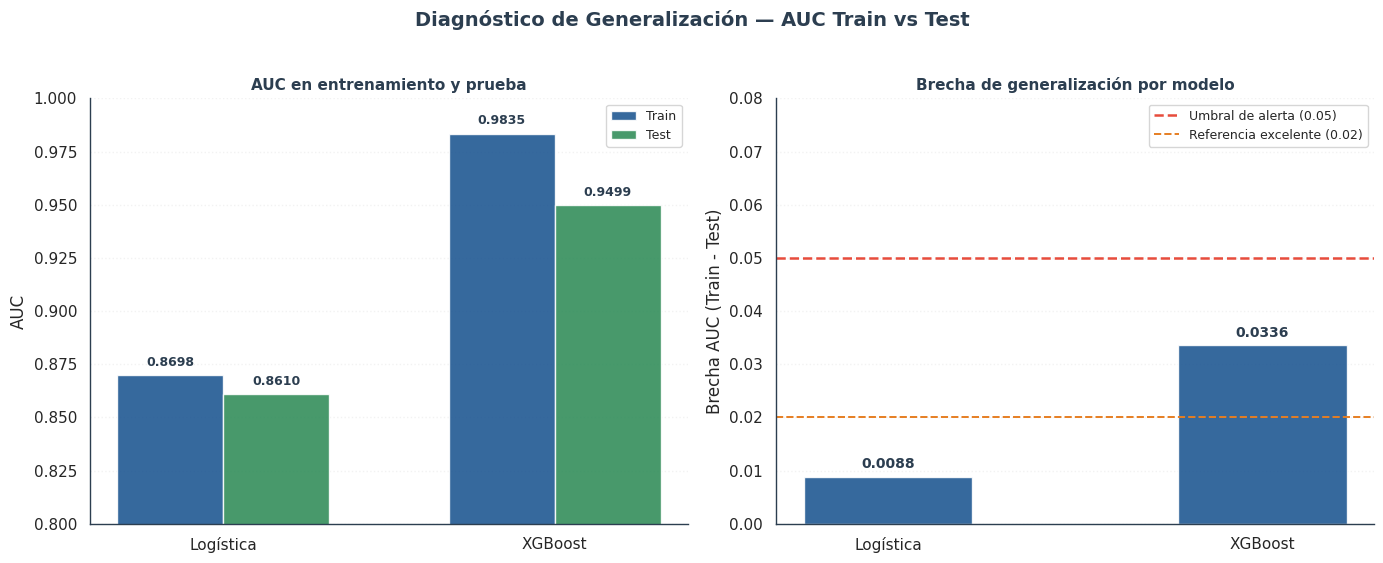


  'df_predicciones' disponible para los Capítulos 7, 8 y 9.


In [30]:
# ===============================================================
# 6.5 DIAGNÓSTICO DE GENERALIZACIÓN — BRECHA TRAIN vs TEST
# ===============================================================
# Primera y única vez que se calculan predicciones sobre el
# conjunto de prueba. Las probabilidades quedan almacenadas en
# df_predicciones, fuente única de verdad para Cap. 7, 8 y 9.
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

SEMILLA = 42

# ---------------------------------------------------------------
# 1. Predicciones sobre train y test — ambos modelos
# ---------------------------------------------------------------
# Regresión Logística (13 variables, con escalado embebido)
pd_train_log = modelo_log_final.predict_proba(X_train_log_final)[:, 1]
pd_test_log  = modelo_log_final.predict_proba(X_test_log_final)[:, 1]

# XGBoost (18 variables, escala original)
pd_train_xgb = modelo_xgb_final.predict_proba(X_train_xgb)[:, 1]
pd_test_xgb  = modelo_xgb_final.predict_proba(X_test_xgb)[:, 1]

# ---------------------------------------------------------------
# 2. AUC en train y test — cálculo de brecha
# ---------------------------------------------------------------
auc_log_train = roc_auc_score(y_train, pd_train_log)
auc_log_test  = roc_auc_score(y_test,  pd_test_log)
auc_xgb_train = roc_auc_score(y_train, pd_train_xgb)
auc_xgb_test  = roc_auc_score(y_test,  pd_test_xgb)

brecha_log = auc_log_train - auc_log_test
brecha_xgb = auc_xgb_train - auc_xgb_test

def diagnostico_brecha(b):
    if b < 0.02:  return "Excelente — sin síntomas de sobreajuste"
    elif b < 0.05: return "Aceptable — brecha menor al umbral de alerta"
    else:          return "Revisar — brecha sugiere sobreajuste"

print("═" * 70)
print(" DIAGNÓSTICO DE GENERALIZACIÓN — AUC TRAIN vs TEST")
print("═" * 70)
print(f"\n  {'Modelo':<32}{'Train':>8}{'Test':>8}{'Brecha':>10}{'Diagnóstico'}")
print("  " + "─" * 66)
print(f"  {'Regresión Logística (13 vars)':<32}"
      f"{auc_log_train:>8.4f}{auc_log_test:>8.4f}"
      f"{brecha_log:>10.4f}  {diagnostico_brecha(brecha_log)}")
print(f"  {'XGBoost (18 vars)':<32}"
      f"{auc_xgb_train:>8.4f}{auc_xgb_test:>8.4f}"
      f"{brecha_xgb:>10.4f}  {diagnostico_brecha(brecha_xgb)}")
print("  " + "─" * 66)
print(f"\n  Umbral de alerta: brecha > 0.05 merece revisión de regularización.")
print(f"  Referencia: dataset de {len(y_train)+len(y_test):,} registros, "
      f"partición 80/20 estratificada.")

# ---------------------------------------------------------------
# 3. Consolidación — fuente única de verdad para Cap. 7, 8 y 9
# ---------------------------------------------------------------
df_predicciones = pd.DataFrame({
    'y_real':    y_test.values,
    'pd_log':    pd_test_log,
    'pd_xgb':    pd_test_xgb,
}, index=y_test.index)

# Verificación de integridad
assert len(df_predicciones) == len(y_test), "Error: tamaño inconsistente"
assert df_predicciones.isnull().sum().sum() == 0, "Error: valores nulos"

print(f"\n  Predicciones consolidadas en 'df_predicciones':")
print(f"    Registros:   {len(df_predicciones):,}")
print(f"    Columnas:    y_real, pd_log, pd_xgb")
print(f"    Nulos:       0")
print(f"    Tasa real:   {df_predicciones['y_real'].mean():.4f}")

# ---------------------------------------------------------------
# 4. Visualización — brecha train vs test (panel comparativo)
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

modelos   = ["Logística", "XGBoost"]
auc_train = [auc_log_train, auc_xgb_train]
auc_test  = [auc_log_test,  auc_xgb_test]
brechas   = [brecha_log, brecha_xgb]

COLOR_TRAIN = "#1A5490"
COLOR_TEST  = "#2E8B57"
COLOR_ALERT = "#E74C3C"

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle("Diagnóstico de Generalización — AUC Train vs Test",
             fontsize=14, fontweight='bold', color="#2C3E50", y=1.02)

# Panel izquierdo — barras agrupadas
ax1 = axes[0]
x = np.arange(len(modelos))
ancho = 0.32
b1 = ax1.bar(x - ancho/2, auc_train, ancho, label='Train',
             color=COLOR_TRAIN, alpha=0.88, edgecolor='white')
b2 = ax1.bar(x + ancho/2, auc_test,  ancho, label='Test',
             color=COLOR_TEST,  alpha=0.88, edgecolor='white')
for barra, val in zip(list(b1) + list(b2),
                      auc_train + auc_test):
    ax1.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 0.003,
             f"{val:.4f}", ha='center', va='bottom',
             fontsize=9, fontweight='bold', color="#2C3E50")
ax1.set_xticks(x)
ax1.set_xticklabels(modelos, fontsize=11)
ax1.set_ylabel("AUC")
ax1.set_ylim(0.80, 1.00)
ax1.set_title("AUC en entrenamiento y prueba",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25, linestyle=':', axis='y')

# Panel derecho — brecha
ax2 = axes[1]
colores_b = [COLOR_ALERT if b >= 0.05 else COLOR_TRAIN for b in brechas]
barras_b = ax2.bar(modelos, brechas, color=colores_b,
                   alpha=0.88, edgecolor='white', width=0.45)
for barra, b in zip(barras_b, brechas):
    ax2.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 0.001,
             f"{b:.4f}", ha='center', va='bottom',
             fontsize=10, fontweight='bold', color="#2C3E50")
ax2.axhline(0.05, color=COLOR_ALERT, linestyle='--',
            linewidth=1.8, label='Umbral de alerta (0.05)')
ax2.axhline(0.02, color="#E67E22", linestyle='--',
            linewidth=1.4, label='Referencia excelente (0.02)')
ax2.set_ylabel("Brecha AUC (Train - Test)")
ax2.set_title("Brecha de generalización por modelo",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, linestyle=':', axis='y')
ax2.set_ylim(0, 0.08)

plt.tight_layout()
plt.show()

print(f"\n  'df_predicciones' disponible para los Capítulos 7, 8 y 9.")

### Interpretación del Diagnóstico de Generalización

El diagnóstico confirma que ambos modelos generalizan correctamente, con perfiles de brecha que reflejan sus naturalezas distintas.

**Regresión Logística — brecha de 0,0088, diagnóstico excelente.** La diferencia entre el AUC de entrenamiento (0,8698) y el de prueba (0,8610) es de menos de un punto porcentual, por debajo incluso de la referencia de excelencia (0,02). El modelo lineal no memorizó ruido de la muestra: los 13 predictores que sobrevivieron el refinamiento capturan patrones genuinos y estables. Este resultado es coherente con el proceso de construcción — un modelo parsimonioso, con regularización activa y sin variables redundantes tiene menos superficie para sobreajustarse.

**XGBoost — brecha de 0,0336, diagnóstico aceptable.** El Challenger muestra una caída de AUC de 0,9835 en entrenamiento a 0,9499 en prueba. La brecha es mayor que la de la logística, lo cual es esperable: 300 árboles con profundidad máxima 6 tienen más capacidad de memorización que un modelo lineal de 13 variables. No obstante, la brecha se mantiene por debajo del umbral de alerta (0,05), y la regularización aplicada —`reg_lambda=5.0`, `min_child_weight=5`, `colsample_bytree=0.7`— cumplió su función de contener el sobreajuste dentro de un rango aceptable. No se requiere ajuste adicional.

**El AUC test es la métrica que importa.** Logística: 0,8610. XGBoost: 0,9499. La diferencia sobre datos que ningún modelo vio es de **+0,0889** — casi nueve puntos porcentuales. Esa es la magnitud real de la ventaja del Challenger, medida en condiciones de evaluación legítimas. El valor de entrenamiento de XGBoost (0,9835) no es relevante para la decisión Champion–Challenger; el valor de prueba (0,9499) sí lo es.

**Síntesis.** Ambos modelos superan el control de generalización. El Capítulo 6 entregó lo que se propuso: dos modelos construidos con rigor metodológico, sin fuga de información, con sobreajuste controlado y sus predicciones consolidadas en `df_predicciones` como fuente única de verdad. La pregunta que queda abierta — si +0,0889 de AUC justifica el costo en interpretabilidad regulatoria — es el objeto del Capítulo 9. Antes, el Capítulo 7 aplica el marco formal de métricas regulatorias: curvas ROC, estadístico KS y coeficiente de Gini.

## 6.6 Conclusiones del Capítulo

El Capítulo 6 construyó, validó y consolidó los dos modelos del esquema Champion–Challenger. Una síntesis de las decisiones y resultados:

### Lo que se construyó

**Regresión Logística (Champion candidato) — 13 variables, AUC test 0,8610 (Gini 72,20%).**
El proceso de construcción incluyó tres capas de validación que van más allá del ajuste estándar: estandarización embebida en pipeline para garantizar ausencia de fuga de información, búsqueda de regularización por validación cruzada, diagnóstico de multicolinealidad con VIF y estabilidad de coeficientes entre folds, y chequeo de coherencia de signos como validación MRM. El resultado es un modelo con coeficientes auditables, económicamente coherentes y sin redundancias. Sus 13 variables representan el subconjunto del espacio de predictores que aporta señal sin introducir inestabilidad.

**XGBoost (Challenger) — 18 variables, AUC CV 0,9474.**
El Challenger fue construido preservando las 18 variables originales, aprovechando la robustez de los árboles a la multicolinealidad y a las relaciones no lineales. La búsqueda de hiperparámetros exploró 49.152 combinaciones posibles con 30 iteraciones de búsqueda aleatoria sobre validación cruzada estratificada. La configuración resultante equilibra capacidad y regularización.

### Los hallazgos clave del capítulo

**El chequeo de signos detectó un problema real.** La multicolinealidad entre `loan_int_rate` y `loan_grade_enc` —η² = 0,905, documentada desde el Capítulo 3— generó una reversión sistemática de signo en el modelo logístico inicial. El diagnóstico formal (VIF + estabilidad entre folds) la confirmó y fundamentó la exclusión. La variación de AUC fue de −0,0001: la tasa de interés no aportaba señal propia en presencia del grado.

**La variable derivada `is_high_dti` es el predictor más importante del Challenger.** Con el 26,3% de la ganancia total en XGBoost, `is_high_dti` —construida en el Capítulo 5 a partir del hallazgo del Tier 3 de no filtrar el sobre-endeudamiento sino modelarlo— es el predictor de mayor importancia del modelo de mayor capacidad. Ilustra la cadena metodológica del proyecto: el Gobierno de Datos identificó el patrón, el Feature Engineering lo formalizó, el modelado lo confirmó.

**La brecha de AUC CV entre modelos es de +0,0778.** XGBoost supera a la logística por casi ocho puntos de AUC en validación cruzada. Esa diferencia abre la pregunta central del Capítulo 9: ¿cuánto desempeño vale cuánta interpretabilidad, en un contexto de originación crediticia regulada?

### Limitaciones del análisis

Los valores de AUC reportados en este capítulo provienen de validación cruzada sobre el entrenamiento. La evaluación sobre el conjunto de prueba —con curvas ROC, KS y Gini calculados sobre datos que ningún modelo vio— se realiza en el Capítulo 7. Los resultados de este capítulo son insumos para el modelado y el diagnóstico, no el veredicto final sobre la capacidad de los modelos.

Como en capítulos anteriores, corresponde señalar que el dataset utilizado es de origen académico y que los valores de AUC observados son superiores a los típicos en carteras productivas, donde la señal es más débil y el ruido más alto. La metodología aplicada —validación rigurosa, diagnóstico de sobreajuste, separación estricta de conjuntos— es, no obstante, plenamente trasladable a un entorno real.

---

Con ambos modelos construidos, validados y sus predicciones consolidadas en `df_predicciones`, el **Capítulo 7 — Métricas Regulatorias** aplica el marco formal de evaluación de discriminación: curvas ROC, estadístico KS con análisis de separación de distribuciones, y coeficiente de Gini.

# 7. Métricas Regulatorias — Evaluación de la Discriminación

El Capítulo 6 construyó dos modelos y verificó que generalizan correctamente. Este capítulo responde una pregunta distinta: **¿qué tan bien discrimina cada modelo entre clientes que cumplirán y clientes que entrarán en default?**

La discriminación es la capacidad central de un modelo de scoring: asignar scores más altos a los buenos pagadores que a los malos, de forma consistente. Un modelo que discrimina bien permite ordenar a los solicitantes por riesgo y tomar decisiones de originación fundamentadas. Un modelo que discrimina mal asigna scores similares a perfiles de riesgo muy distintos y no añade valor al proceso de crédito.

### Por qué no se usa la accuracy

La *accuracy* —fracción de casos clasificados correctamente— es una métrica inadecuada para carteras de crédito, por dos razones que el propio proyecto estableció en la sección 4.1. Primero, la cartera está desbalanceada (21,87% de default): un clasificador trivial que prediga "ningún default" alcanzaría una accuracy del 78,13% sin identificar un solo caso de riesgo. Segundo, y más importante, la *accuracy* depende de un umbral de corte fijo (típicamente 0,5), pero la decisión de qué umbral usar es una decisión de negocio que depende del apetito de riesgo y del costo relativo de los errores — no es un parámetro técnico del modelo. Las métricas regulatorias evalúan el **ordenamiento** que produce el modelo, independientemente del umbral elegido.

### Qué se evalúa en este capítulo

Las tres métricas estándar de la industria bancaria para evaluar la discriminación de un scorecard:

| Métrica | Qué mide | Escala |
|---|---|---|
| **AUC** | Probabilidad de que el modelo asigne score más alto a un buen pagador que a uno malo | 0,5 (azar) a 1,0 (perfecto) |
| **Gini** | Poder de ordenamiento neto sobre el azar | 0% (azar) a 100% (perfecto) |
| **KS** | Máxima separación entre distribuciones de buenos y malos | 0% (sin separación) a 100% (separación total) |

Las tres métricas comparten una lógica común: evalúan la calidad del **ordenamiento** del score, no la calidad de una clasificación binaria. Son robustas al desbalance de clases y no dependen de ningún umbral de corte.

### Estado de los datos

Toda la evaluación se realiza sobre `df_predicciones`, el objeto generado en la sección 6.5 con las probabilidades de default predichas por ambos modelos sobre el **conjunto de prueba** (6.478 registros, tasa real de default 21,87%). El conjunto de prueba no participó en ninguna decisión de modelado — es la primera y única medición sobre datos completamente nuevos.

### Alcance del capítulo

Este capítulo evalúa exclusivamente la **discriminación**: la capacidad de ordenar el riesgo. La **calibración** de las probabilidades —que las PD predichas reflejen la tasa real de default— y la **política de corte** —qué umbral de score separará aprobaciones de rechazos— son decisiones que requieren la discriminación como insumo y se abordan en el Capítulo 8.

## 7.1 Marco de Evaluación Regulatoria

Antes de calcular las métricas, esta sección establece la lógica que subyace a las tres y el criterio de interpretación que se aplicará.

### La pregunta que responden las métricas de discriminación

Un modelo de scoring asigna a cada solicitante una probabilidad de default (PD). Esa probabilidad es el insumo para ordenar a los clientes de menor a mayor riesgo. La pregunta central de la evaluación es:

> *¿Con qué frecuencia el modelo asigna una PD más alta al cliente que efectivamente defaultea que al cliente que efectivamente cumple?*

Si la respuesta fuera "siempre", el modelo discriminaría perfectamente. Si fuera "el 50% de las veces" — es decir, al azar —, el modelo no tendría valor. Las métricas AUC, Gini y KS cuantifican distintas facetas de esa pregunta.

### Escalas de referencia de la industria

Los umbrales que siguen son los convencionales en credit scoring bancario. No son reglas absolutas —el nivel "aceptable" depende del tipo de producto, la calidad del portfolio y la disponibilidad de variables—, pero proveen una referencia para contextualizar los resultados:

| Gini (%) | AUC | KS (%) | Calificación |
|---|---|---|---|
| < 20 | < 0,60 | < 20 | Inaceptable |
| 20 – 30 | 0,60 – 0,65 | 20 – 30 | Débil |
| 30 – 40 | 0,65 – 0,70 | 30 – 40 | Aceptable |
| 40 – 50 | 0,70 – 0,75 | 40 – 50 | Bueno |
| 50 – 60 | 0,75 – 0,80 | 50 – 60 | Muy bueno |
| > 60 | > 0,80 | > 60 | Excelente |

### Relación entre las tres métricas

Las tres métricas no son independientes: están matemáticamente relacionadas y miden el mismo fenómeno desde ángulos distintos.

**AUC y Gini** son transformaciones exactas una de la otra:

$$Gini = 2 \times AUC - 1$$

Un AUC de 0,86 equivale a un Gini del 72%; un AUC de 0,95 equivale a un Gini del 90%. El Gini es simplemente el AUC reescalado para que el azar corresponda a 0% en lugar de 0,5. En los comités de riesgo bancarios, el Gini es la métrica de reporte estándar porque su escala 0–100% es más intuitiva.

**El KS** mide una dimensión complementaria: no la discriminación global, sino la **máxima separación** que el modelo logra en algún punto del score. Dos modelos con el mismo AUC pueden tener KS distintos si uno concentra su capacidad de separación en la parte alta del score y el otro la distribuye de forma más uniforme. El KS es particularmente relevante para la política de corte: el decil donde se produce la máxima separación suele ser un punto de referencia natural para definir el umbral de aprobación.

### Nota sobre el dataset académico

Como en capítulos anteriores, corresponde señalar que los valores de AUC y Gini observados en este dataset son superiores a los típicos en carteras productivas. En un entorno bancario real, con variables de comportamiento más ruidosas y una señal de default más débil, es habitual encontrar Ginis en el rango 40–60% para modelos de scorecards de originación. Los valores de este proyecto reflejan la naturaleza del dataset académico y no deben tomarse como referencia de desempeño para una cartera real. La metodología de evaluación aplicada es, no obstante, la misma que se usa en producción.

════════════════════════════════════════════════════════════════════════
 7.2 / 7.3 — AUC Y GINI (conjunto de prueba)
════════════════════════════════════════════════════════════════════════

  Modelo                               AUC      GiniCalificación
  ────────────────────────────────────────────────────────────
  Regresión Logística (13 vars)     0.8610   72.20%  Excelente
  XGBoost (18 vars)                 0.9499   89.98%  Excelente
  ────────────────────────────────────────────────────────────

  Diferencia de AUC:   +0.0889
  Diferencia de Gini:  +17.78 pp

════════════════════════════════════════════════════════════════════════
 7.4 — ESTADÍSTICO KS (conjunto de prueba)
════════════════════════════════════════════════════════════════════════

  Modelo                                KS    Decil KSCalificación
  ────────────────────────────────────────────────────────────
  Regresión Logística (13 vars)     0.5734           3  Muy bueno
  XGBoost (18 vars)                 0.7

/tmp/ipykernel_1147/3552294305.py:253: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


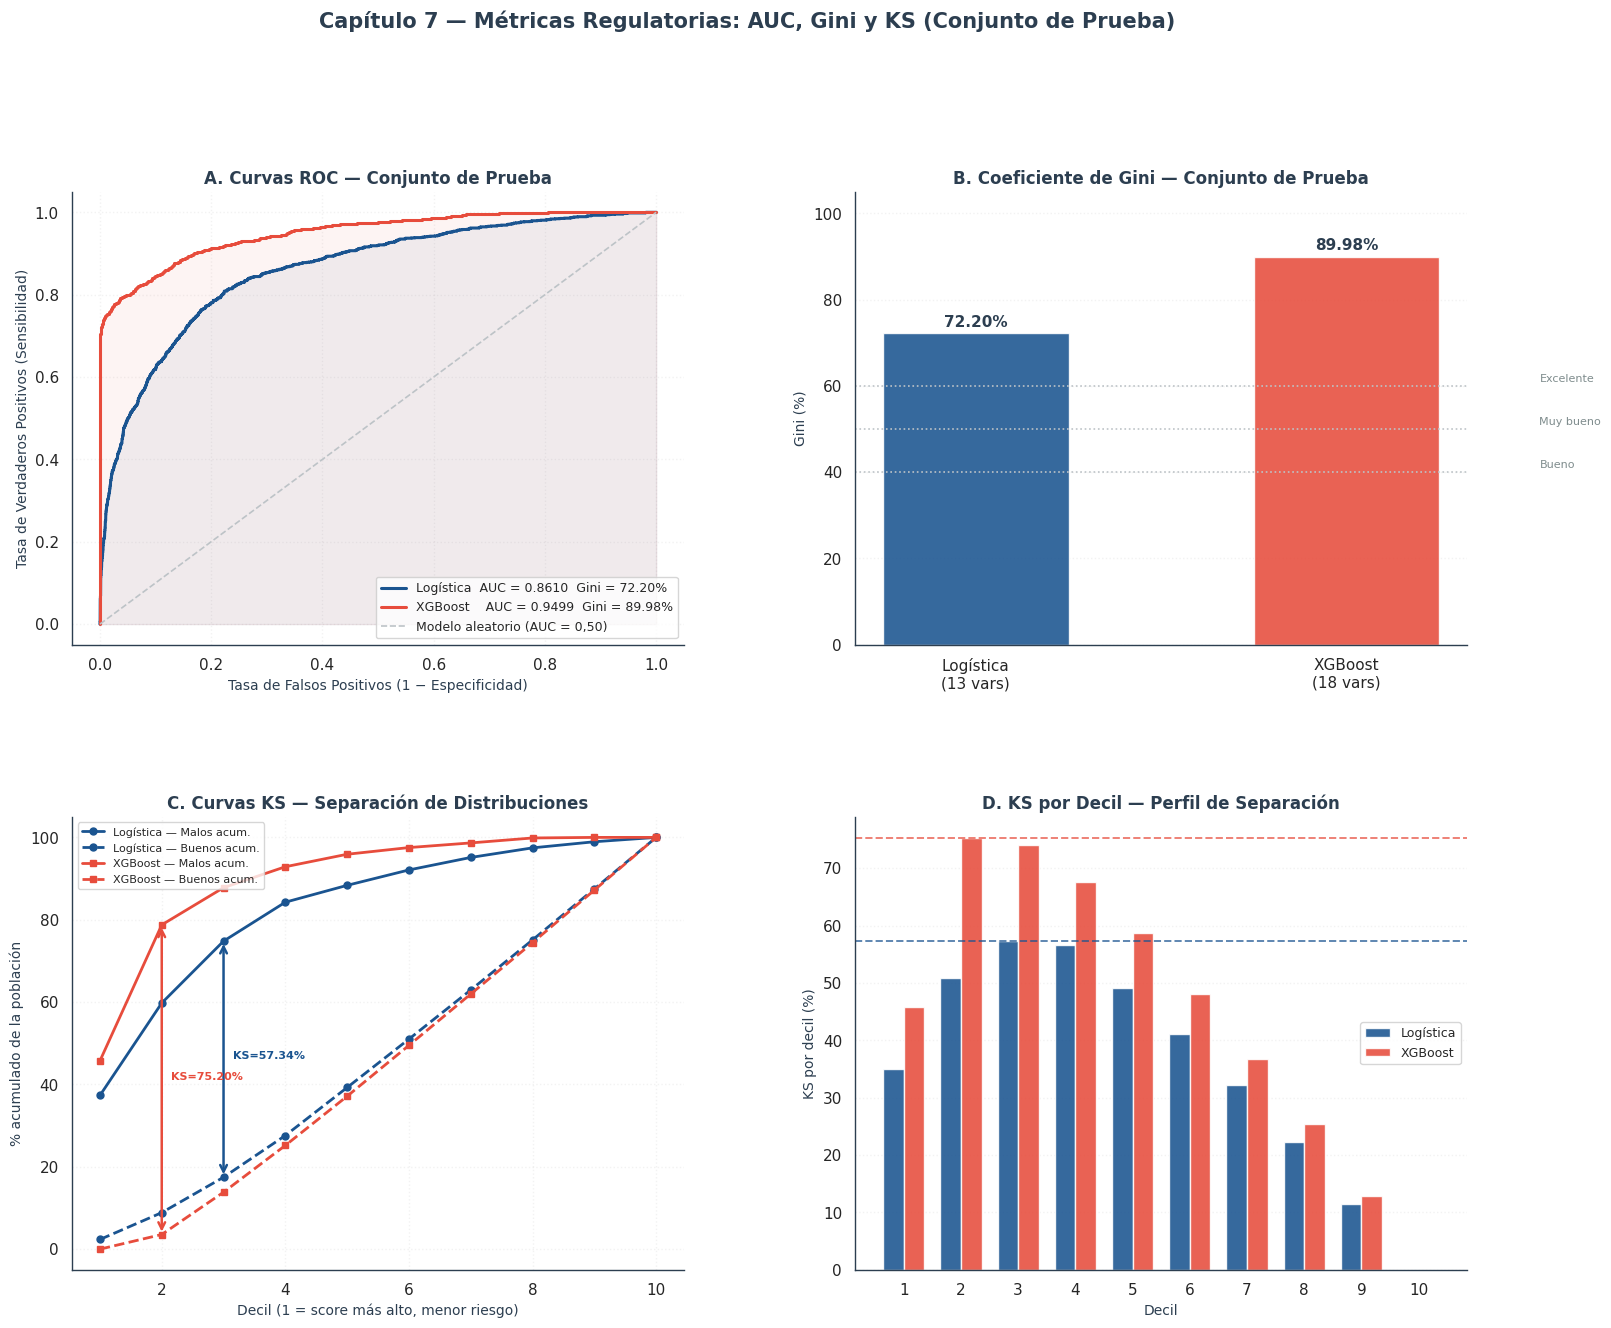


════════════════════════════════════════════════════════════════════════
 7.5 — TABLA RESUMEN REGULATORIA
════════════════════════════════════════════════════════════════════════

  Métrica                          Logística       XGBoost    Diferencia
  ────────────────────────────────────────────────────────────────────
  AUC                                 0.8610        0.9499       +0.0889
  Gini                               72.20%        89.98%       +17.78 pp
  KS                                 0.5734        0.7520       +0.1786
  Decil KS                                 3             2
  Calificación (Gini)              Excelente     Excelente
  ────────────────────────────────────────────────────────────────────

  Referencia: escala convencional de la industria bancaria.
  Evaluación sobre 6,478 registros del conjunto de prueba.


In [31]:
# ===============================================================
# 7. MÉTRICAS REGULATORIAS — AUC, GINI Y KS
# ===============================================================
# Fuente: df_predicciones (generado en 6.5, intocable desde entonces).
# Evaluación sobre el conjunto de prueba únicamente.
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# ---------------------------------------------------------------
# 1. AUC y Gini
# ---------------------------------------------------------------
auc_log  = roc_auc_score(df_predicciones['y_real'], df_predicciones['pd_log'])
auc_xgb  = roc_auc_score(df_predicciones['y_real'], df_predicciones['pd_xgb'])
gini_log = 2 * auc_log  - 1
gini_xgb = 2 * auc_xgb - 1

# ---------------------------------------------------------------
# 2. Curvas ROC
# ---------------------------------------------------------------
fpr_log, tpr_log, _ = roc_curve(df_predicciones['y_real'],
                                  df_predicciones['pd_log'])
fpr_xgb, tpr_xgb, _ = roc_curve(df_predicciones['y_real'],
                                  df_predicciones['pd_xgb'])

# ---------------------------------------------------------------
# 3. KS con tabla de deciles (estándar bancario)
# ---------------------------------------------------------------
def tabla_ks(df, score_col, target_col, n_deciles=10):
    """
    Calcula la tabla KS por deciles del score.
    Cada decil contiene aprox. el 10% de los registros,
    ordenados de mayor a menor score (menor a mayor riesgo).
    """
    d = df[[score_col, target_col]].copy()
    d['decil'] = pd.qcut(d[score_col].rank(method='first'),
                          q=n_deciles, labels=False)
    d['decil'] = n_deciles - d['decil']  # decil 1 = score más alto

    total_buenos = (d[target_col] == 0).sum()
    total_malos  = (d[target_col] == 1).sum()

    tabla = d.groupby('decil')[target_col].agg(
        n_total='count',
        n_malos='sum'
    ).reset_index()
    tabla['n_buenos']   = tabla['n_total'] - tabla['n_malos']
    tabla['pct_buenos'] = tabla['n_buenos'] / total_buenos
    tabla['pct_malos']  = tabla['n_malos']  / total_malos
    tabla['pct_buenos_acum'] = tabla['pct_buenos'].cumsum()
    tabla['pct_malos_acum']  = tabla['pct_malos'].cumsum()
    tabla['ks']         = (tabla['pct_buenos_acum'] -
                           tabla['pct_malos_acum']).abs()
    tabla['tasa_default'] = tabla['n_malos'] / tabla['n_total']
    return tabla

tabla_ks_log = tabla_ks(df_predicciones, 'pd_log', 'y_real')
tabla_ks_xgb = tabla_ks(df_predicciones, 'pd_xgb', 'y_real')

ks_log = tabla_ks_log['ks'].max()
ks_xgb = tabla_ks_xgb['ks'].max()
decil_ks_log = tabla_ks_log.loc[tabla_ks_log['ks'].idxmax(), 'decil']
decil_ks_xgb = tabla_ks_xgb.loc[tabla_ks_xgb['ks'].idxmax(), 'decil']

# ---------------------------------------------------------------
# 4. Clasificación regulatoria
# ---------------------------------------------------------------
def clasif_gini(g):
    g_pct = g * 100
    if g_pct < 20:   return "Inaceptable"
    elif g_pct < 30: return "Débil"
    elif g_pct < 40: return "Aceptable"
    elif g_pct < 50: return "Bueno"
    elif g_pct < 60: return "Muy bueno"
    else:             return "Excelente"

# ---------------------------------------------------------------
# 5. Reportes de consola
# ---------------------------------------------------------------
print("═" * 72)
print(" 7.2 / 7.3 — AUC Y GINI (conjunto de prueba)")
print("═" * 72)
print(f"\n  {'Modelo':<32}{'AUC':>8}{'Gini':>10}{'Calificación'}")
print("  " + "─" * 60)
print(f"  {'Regresión Logística (13 vars)':<32}"
      f"{auc_log:>8.4f}{gini_log:>9.2%}  {clasif_gini(gini_log)}")
print(f"  {'XGBoost (18 vars)':<32}"
      f"{auc_xgb:>8.4f}{gini_xgb:>9.2%}  {clasif_gini(gini_xgb)}")
print("  " + "─" * 60)
print(f"\n  Diferencia de AUC:   {auc_xgb - auc_log:+.4f}")
print(f"  Diferencia de Gini:  {(gini_xgb - gini_log)*100:+.2f} pp")

print("\n" + "═" * 72)
print(" 7.4 — ESTADÍSTICO KS (conjunto de prueba)")
print("═" * 72)
print(f"\n  {'Modelo':<32}{'KS':>8}{'Decil KS':>12}{'Calificación'}")
print("  " + "─" * 60)
print(f"  {'Regresión Logística (13 vars)':<32}"
      f"{ks_log:>8.4f}{decil_ks_log:>12}  {clasif_gini(ks_log)}")
print(f"  {'XGBoost (18 vars)':<32}"
      f"{ks_xgb:>8.4f}{decil_ks_xgb:>12}  {clasif_gini(ks_xgb)}")
print("  " + "─" * 60)

print("\n  Tabla KS por deciles — Regresión Logística:")
print(f"  {'Decil':>7}{'N':>7}{'Malos':>7}{'Buenos':>8}"
      f"{'%Malos ac.':>12}{'%Buenos ac.':>13}{'KS':>8}{'Def%':>8}")
print("  " + "─" * 70)
for _, f in tabla_ks_log.iterrows():
    marca = " ← KS" if f['decil'] == decil_ks_log else ""
    print(f"  {int(f['decil']):>7}{int(f['n_total']):>7}"
          f"{int(f['n_malos']):>7}{int(f['n_buenos']):>8}"
          f"{f['pct_malos_acum']:>11.2%}{f['pct_buenos_acum']:>12.2%}"
          f"{f['ks']:>8.4f}{f['tasa_default']:>7.2%}{marca}")

print("\n  Tabla KS por deciles — XGBoost:")
print(f"  {'Decil':>7}{'N':>7}{'Malos':>7}{'Buenos':>8}"
      f"{'%Malos ac.':>12}{'%Buenos ac.':>13}{'KS':>8}{'Def%':>8}")
print("  " + "─" * 70)
for _, f in tabla_ks_xgb.iterrows():
    marca = " ← KS" if f['decil'] == decil_ks_xgb else ""
    print(f"  {int(f['decil']):>7}{int(f['n_total']):>7}"
          f"{int(f['n_malos']):>7}{int(f['n_buenos']):>8}"
          f"{f['pct_malos_acum']:>11.2%}{f['pct_buenos_acum']:>12.2%}"
          f"{f['ks']:>8.4f}{f['tasa_default']:>7.2%}{marca}")

# ---------------------------------------------------------------
# 6. Visualizaciones
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

COLOR_LOG = "#1A5490"
COLOR_XGB = "#E74C3C"

fig = plt.figure(figsize=(18, 14))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.28)

# --- Panel A: Curvas ROC superpuestas ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(fpr_log, tpr_log, color=COLOR_LOG, lw=2.2,
         label=f"Logística  AUC = {auc_log:.4f}  Gini = {gini_log:.2%}")
ax1.plot(fpr_xgb, tpr_xgb, color=COLOR_XGB, lw=2.2,
         label=f"XGBoost    AUC = {auc_xgb:.4f}  Gini = {gini_xgb:.2%}")
ax1.plot([0, 1], [0, 1], color="#BDC3C7", lw=1.2,
         linestyle="--", label="Modelo aleatorio (AUC = 0,50)")
ax1.fill_between(fpr_log, tpr_log, alpha=0.06, color=COLOR_LOG)
ax1.fill_between(fpr_xgb, tpr_xgb, alpha=0.06, color=COLOR_XGB)
ax1.set_xlabel("Tasa de Falsos Positivos (1 − Especificidad)",
               fontsize=10, color="#2C3E50")
ax1.set_ylabel("Tasa de Verdaderos Positivos (Sensibilidad)",
               fontsize=10, color="#2C3E50")
ax1.set_title("A. Curvas ROC — Conjunto de Prueba",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax1.legend(fontsize=9, loc="lower right")
ax1.grid(True, alpha=0.25, linestyle=":")

# --- Panel B: Gini comparativo ---
ax2 = fig.add_subplot(gs[0, 1])
modelos_label = ["Logística\n(13 vars)", "XGBoost\n(18 vars)"]
ginis = [gini_log * 100, gini_xgb * 100]
colores_b = [COLOR_LOG, COLOR_XGB]
barras = ax2.bar(modelos_label, ginis, color=colores_b,
                  alpha=0.88, edgecolor="white", width=0.5)
for barra, g in zip(barras, ginis):
    ax2.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 0.8,
             f"{g:.2f}%", ha="center", va="bottom",
             fontsize=11, fontweight="bold", color="#2C3E50")
for umbral, etiq in [(60, "Excelente"), (50, "Muy bueno"), (40, "Bueno")]:
    ax2.axhline(umbral, color="#BDC3C7", linestyle=":",
                linewidth=1.2)
    ax2.text(1.52, umbral + 0.5, etiq, fontsize=8,
             color="#7F8C8D", va="bottom")
ax2.set_ylabel("Gini (%)", fontsize=10, color="#2C3E50")
ax2.set_ylim(0, 105)
ax2.set_title("B. Coeficiente de Gini — Conjunto de Prueba",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax2.grid(True, alpha=0.25, linestyle=":", axis="y")

# --- Panel C: Curvas KS (distribuciones acumuladas) ---
ax3 = fig.add_subplot(gs[1, 0])
deciles = tabla_ks_log['decil'].values

ax3.plot(deciles, tabla_ks_log['pct_malos_acum'] * 100,
         color=COLOR_LOG, lw=2, linestyle="-",
         marker="o", markersize=5, label="Logística — Malos acum.")
ax3.plot(deciles, tabla_ks_log['pct_buenos_acum'] * 100,
         color=COLOR_LOG, lw=2, linestyle="--",
         marker="o", markersize=5, label="Logística — Buenos acum.")
ax3.plot(deciles, tabla_ks_xgb['pct_malos_acum'] * 100,
         color=COLOR_XGB, lw=2, linestyle="-",
         marker="s", markersize=5, label="XGBoost — Malos acum.")
ax3.plot(deciles, tabla_ks_xgb['pct_buenos_acum'] * 100,
         color=COLOR_XGB, lw=2, linestyle="--",
         marker="s", markersize=5, label="XGBoost — Buenos acum.")

# Marcar el decil KS de cada modelo
for tabla, ks_val, decil_ks, color in [
    (tabla_ks_log, ks_log, decil_ks_log, COLOR_LOG),
    (tabla_ks_xgb, ks_xgb, decil_ks_xgb, COLOR_XGB),
]:
    fila = tabla[tabla['decil'] == decil_ks].iloc[0]
    y1 = fila['pct_malos_acum'] * 100
    y2 = fila['pct_buenos_acum'] * 100
    ax3.annotate("", xy=(decil_ks, y2), xytext=(decil_ks, y1),
                 arrowprops=dict(arrowstyle="<->", color=color,
                                  lw=1.8))
    ax3.text(decil_ks + 0.15, (y1 + y2) / 2,
             f"KS={ks_val:.2%}", fontsize=8,
             fontweight="bold", color=color)

ax3.set_xlabel("Decil (1 = score más alto, menor riesgo)",
               fontsize=10, color="#2C3E50")
ax3.set_ylabel("% acumulado de la población", fontsize=10,
               color="#2C3E50")
ax3.set_title("C. Curvas KS — Separación de Distribuciones",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax3.legend(fontsize=8, loc="upper left")
ax3.grid(True, alpha=0.25, linestyle=":")

# --- Panel D: KS por decil (barras) ---
ax4 = fig.add_subplot(gs[1, 1])
x = np.arange(len(deciles))
ancho = 0.36
ax4.bar(x - ancho/2, tabla_ks_log['ks'] * 100, ancho,
        color=COLOR_LOG, alpha=0.88, edgecolor="white",
        label="Logística")
ax4.bar(x + ancho/2, tabla_ks_xgb['ks'] * 100, ancho,
        color=COLOR_XGB, alpha=0.88, edgecolor="white",
        label="XGBoost")
ax4.axhline(ks_log * 100, color=COLOR_LOG, linestyle="--",
            linewidth=1.4, alpha=0.7)
ax4.axhline(ks_xgb * 100, color=COLOR_XGB, linestyle="--",
            linewidth=1.4, alpha=0.7)
ax4.set_xticks(x)
ax4.set_xticklabels([str(d) for d in deciles])
ax4.set_xlabel("Decil", fontsize=10, color="#2C3E50")
ax4.set_ylabel("KS por decil (%)", fontsize=10, color="#2C3E50")
ax4.set_title("D. KS por Decil — Perfil de Separación",
              fontweight="bold", fontsize=12, color="#2C3E50")
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.25, linestyle=":", axis="y")

fig.suptitle("Capítulo 7 — Métricas Regulatorias: AUC, Gini y KS"
             " (Conjunto de Prueba)",
             fontsize=15, fontweight="bold", color="#2C3E50", y=1.01)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 7. Tabla resumen regulatoria
# ---------------------------------------------------------------
print("\n" + "═" * 72)
print(" 7.5 — TABLA RESUMEN REGULATORIA")
print("═" * 72)
print(f"\n  {'Métrica':<28}{'Logística':>14}{'XGBoost':>14}"
      f"{'Diferencia':>14}")
print("  " + "─" * 68)
print(f"  {'AUC':<28}{auc_log:>14.4f}{auc_xgb:>14.4f}"
      f"{auc_xgb - auc_log:>+14.4f}")
print(f"  {'Gini':<28}{gini_log:>13.2%}{gini_xgb:>14.2%}"
      f"{(gini_xgb-gini_log)*100:>+13.2f} pp")
print(f"  {'KS':<28}{ks_log:>13.4f}{ks_xgb:>14.4f}"
      f"{ks_xgb - ks_log:>+14.4f}")
print(f"  {'Decil KS':<28}{decil_ks_log:>14}{decil_ks_xgb:>14}")
print(f"  {'Calificación (Gini)':<28}"
      f"{clasif_gini(gini_log):>14}{clasif_gini(gini_xgb):>14}")
print("  " + "─" * 68)
print(f"\n  Referencia: escala convencional de la industria bancaria.")
print(f"  Evaluación sobre {len(df_predicciones):,} registros del conjunto de prueba.")

### Interpretación de las Métricas Regulatorias

Los tres indicadores calculados sobre el conjunto de prueba — datos que ningún modelo vio durante el ajuste — entregan una imagen completa y coherente de la capacidad discriminante de ambos modelos.

#### 7.2 — Curva ROC y AUC

La curva ROC representa, para cada umbral de score posible, el balance entre la tasa de verdaderos positivos (clientes en default correctamente identificados) y la tasa de falsos positivos (clientes cumplidores incorrectamente marcados como riesgo). Un modelo perfecto se ubica en la esquina superior izquierda; un modelo aleatorio sigue la diagonal. El **Área Bajo la Curva (AUC)** resume en un único número la calidad de ese balance a lo largo de todos los umbrales posibles.

La Regresión Logística alcanzó un **AUC de 0,8610**: el modelo asigna una probabilidad de default más alta al cliente que efectivamente defaultea que al que cumple en el 86,10% de los pares posibles. El XGBoost alcanzó un **AUC de 0,9499**: ese porcentaje sube al 94,99%. La diferencia de +0,0889 sobre el conjunto de prueba es la brecha real de capacidad discriminante entre ambos modelos, medida en condiciones de evaluación legítimas.

Ambas curvas ROC se ubican claramente por encima de la diagonal en todo su recorrido, lo que confirma que ninguno de los dos modelos está sobreajustado a regiones específicas del score. La forma de la curva de XGBoost es notablemente más convexa, lo que refleja su capacidad de separar las poblaciones con mayor eficacia incluso a tasas de falsos positivos bajas — región relevante para políticas de originación conservadoras.

#### 7.3 — Coeficiente de Gini

El Gini es la transformación directa del AUC a una escala de 0–100% centrada en cero. Logística: **Gini = 72,20%**. XGBoost: **Gini = 89,98%**. Diferencia: **+17,78 puntos porcentuales**.

Ambos valores caen en la categoría **"Excelente"** según la escala convencional de la industria (Gini > 60%). Un Gini del 72% para la Regresión Logística — un modelo lineal de 13 variables, sin ingeniería de features compleja — es un resultado sólido y completamente defendible como baseline regulatorio en un comité de riesgo. El Gini del 90% de XGBoost es excepcional, aunque como se señaló en el Capítulo 6, este nivel refleja en parte la naturaleza del dataset académico: en carteras productivas con señal más débil, los Ginis típicos de modelos de originación se ubican en el rango 40–60%.

#### 7.4 — Estadístico de Kolmogorov-Smirnov (KS)

El KS mide la **máxima separación** que el modelo logra entre la distribución acumulada de buenos pagadores y la de malos pagadores a lo largo de los deciles del score. Cuanto mayor el KS, mayor la capacidad del modelo de concentrar los defaults en los deciles de score más alto (mayor riesgo) y los cumplidores en los de score más bajo.

**Regresión Logística — KS = 0,5734 en el decil 3.** La máxima separación se produce en el tercer decil del score: al cubrir los tres deciles de mayor score, el modelo acumuló el 74,81% de todos los defaults con solo el 17,47% de los buenos pagadores — una separación de 57,34 puntos porcentuales. La tasa de default en el decil 1 es del 81,64%, lo que confirma que el modelo identifica con eficacia el segmento de mayor riesgo. La calificación según la escala de referencia es **"Muy bueno"** (KS entre 0,50 y 0,60).

**XGBoost — KS = 0,7520 en el decil 2.** El Challenger logra una separación aún más aguda y la alcanza antes: en los dos primeros deciles ya concentró el 78,76% de todos los defaults con apenas el 3,56% de los buenos. El decil 1 es particularmente llamativo: los 648 registros con el score más alto contienen **648 defaults y 0 buenos pagadores** — una tasa de default del 100%. El modelo separó completamente los peores perfiles de riesgo en el primer decil. La calificación es **"Excelente"** (KS > 0,60), con una diferencia de +0,1786 sobre la logística.

El panel D del gráfico muestra el **perfil de separación por decil**: ambos modelos concentran la mayor separación en los deciles altos (mayor riesgo) y la pierden gradualmente hacia los deciles bajos. Este patrón — esperado en un buen scorecard — indica que el modelo ordena el riesgo de manera consistente a lo largo de toda la distribución, sin regiones de inversión.

#### 7.5 — Síntesis regulatoria

| Métrica | Logística | XGBoost | Diferencia |
|---|---|---|---|
| AUC | 0,8610 | 0,9499 | +0,0889 |
| Gini | 72,20% | 89,98% | +17,78 pp |
| KS | 0,5734 | 0,7520 | +0,1786 |
| Decil KS | 3 | 2 | — |
| Calificación | Excelente | Excelente | — |

Las tres métricas son coherentes entre sí y apuntan en la misma dirección: XGBoost supera sistemáticamente a la Regresión Logística en todas las dimensiones de la discriminación. La ventaja no es marginal — es de casi 9 puntos de AUC, 18 puntos de Gini y 18 puntos de KS. Esa consistencia, medida sobre el conjunto de prueba con tres indicadores independientes, hace que el resultado no pueda atribuirse a un artefacto de la métrica elegida.

Lo que las métricas no resuelven es la pregunta que el Capítulo 9 abordará formalmente: si esa ventaja de discriminación justifica el costo de interpretabilidad regulatoria. La Regresión Logística, con un Gini del 72%, es un modelo "Excelente" por derecho propio. Un supervisor bancario o un comité de Model Risk Management podría preferirlo precisamente porque cada coeficiente es auditable — y el Gini del 72% es suficiente para una política de originación robusta. El Challenger no gana la comparación solo porque discrimina mejor: gana si y solo si ese delta de discriminación se traduce en valor de negocio que justifique la pérdida de transparencia. Esa discusión requiere la scorecard y la política de corte del Capítulo 8 como insumo previo.

## 7.6 Conclusiones del Capítulo

El Capítulo 7 completó la evaluación regulatoria de la discriminación de ambos modelos sobre el conjunto de prueba. Las conclusiones son claras y consistentes.

**Ambos modelos son competentes.** La Regresión Logística (Gini 72,20%, KS 0,5734) y XGBoost (Gini 89,98%, KS 0,7520) caen en las categorías más altas de la escala de referencia de la industria. Cualquiera de los dos sería aceptable como modelo de scoring en un entorno productivo desde la perspectiva de la discriminación.

**La ventaja del Challenger es sistemática y robusta.** XGBoost supera a la Logística en AUC (+0,0889), Gini (+17,78 pp) y KS (+0,1786). La consistencia de la ventaja en tres métricas independientes, medidas sobre datos que ningún modelo vio, descarta que el resultado sea un artefacto estadístico.

**El resultado del Capítulo 7 es un insumo, no un veredicto.** Las métricas de discriminación miden la capacidad de ordenar el riesgo. La elección del modelo Champion requiere, adicionalmente, evaluar la interpretabilidad regulatoria, la calibración de las probabilidades y el impacto sobre la política de originación. Esos elementos se desarrollan en los Capítulos 8 y 9.

### Limitaciones

Como en los capítulos anteriores, los valores de Gini y KS observados son superiores a los típicos en carteras productivas. El dataset académico presenta una señal de default más limpia y variables más directamente alineadas al resultado que las disponibles en un entorno bancario real. La comparativa relativa entre modelos —quién discrimina mejor y por cuánto— es, no obstante, metodológicamente válida.

---

Con la discriminación formalmente evaluada, el **Capítulo 8** aborda las dos transformaciones que convierten las probabilidades de default en una herramienta de decisión operativa: la calibración de las PD y la construcción de la scorecard de puntos con su política de corte.

# 8. Scorecard y Política de Corte

Los Capítulos 6 y 7 construyeron y evaluaron dos modelos capaces de estimar la Probabilidad de Default (PD). Este capítulo toma el modelo logístico —el Champion candidato— y lo convierte en una **herramienta de decisión operativa**: una scorecard de puntos con un umbral de corte fundamentado en evidencia de negocio.

### Por qué la scorecard se construye sobre la Regresión Logística

La scorecard es el formato estándar de la industria bancaria para comunicar y operar un modelo de scoring. Su lógica requiere que cada variable contribuya con un número de puntos legible e interpretable — lo que solo es posible en un modelo lineal cuyos coeficientes tienen lectura directa. XGBoost, con su estructura de 300 árboles de decisión, no admite esa traducción sin técnicas adicionales de explicabilidad que van más allá del alcance de este capítulo. La Regresión Logística, con 13 coeficientes auditables, es el vehículo natural.

Esto no significa que XGBoost quede descartado: la comparativa formal entre ambos modelos, con la scorecard como insumo, se realiza en el Capítulo 9.

### Qué entrega este capítulo

El capítulo recorre tres pasos en secuencia:

1. **Calibración (8.1)** — Corrige el nivel absoluto de las PD predichas por el modelo logístico, que quedaron desplazadas por el uso de `class_weight='balanced'`, para que reflejen la tasa real de default de la cartera.

2. **Scorecard (8.2)** — Convierte las PD calibradas en una escala de puntos entera e intuitiva, usando los parámetros estándar de la industria con justificación explícita de cada uno.

3. **Política de corte (8.3)** — Define el umbral de aprobación analizando el trade-off entre tasa de aprobación y bad rate esperado. El corte no se fija a priori: emerge del análisis de la curva de estrategia calculada sobre los datos.

### Estado de los datos

El capítulo trabaja exclusivamente con `df_predicciones` (generado en 6.5) y los conjuntos de entrenamiento y prueba originales. El conjunto de prueba sigue siendo intocable como referencia de evaluación: la calibración, en particular, se realiza sobre una porción reservada del conjunto de entrenamiento — nunca sobre el test.

## 8.1 Calibración de Probabilidades

El modelo logístico fue entrenado con `class_weight='balanced'`, que asigna un peso mayor a los casos de default para optimizar la discriminación en una cartera desbalanceada. Esta decisión tuvo el efecto esperado sobre la capacidad de ordenamiento — el Gini resultante es del 72,20% —, pero introduce una distorsión en el nivel absoluto de las probabilidades predichas: la PD media del modelo no coincide con la tasa real de default de la cartera.

Esta distorsión no afecta a las métricas de discriminación (AUC, Gini, KS), que dependen del **ordenamiento** de los scores y son insensibles a su nivel absoluto. Sí afecta, en cambio, a dos usos prácticos del modelo que requieren que las probabilidades sean interpretables como frecuencias reales:

- La **scorecard de puntos** (sección 8.2), cuya escala se ancla a los odds de la cartera.
- La **política de corte** (sección 8.3), donde el bad rate esperado en cada tramo se calcula a partir de las PD predichas.

La **calibración** corrige esta distorsión ajustando una transformación sobre las PD brutas del modelo, de modo que la PD media calibrada coincida con la tasa de default observada.

### Método: Platt Scaling

El **Platt Scaling** ajusta una regresión logística de un parámetro sobre las probabilidades brutas del modelo:

$$P_{cal} = \frac{1}{1 + e^{-(a \cdot f(x) + b)}}$$

donde $f(x)$ es la PD bruta del modelo y los parámetros $a$ y $b$ se estiman para minimizar la distancia entre las PD calibradas y los outcomes reales. Es el método más simple e interpretable de calibración, y el estándar de la industria para modelos de scoring.

### Por qué la calibración no usa el conjunto de prueba

El conjunto de prueba está reservado para la evaluación final del modelo — medirlo en cualquier otra instancia introduciría fuga de información. La calibración es una decisión de ajuste del modelo, no una evaluación: se realiza sobre datos de entrenamiento.

El procedimiento concreto: el conjunto de entrenamiento se divide en dos partes. La primera (80%) fue usada para ajustar el modelo logístico. La segunda (20%, reservada ahora) se usa exclusivamente para estimar los parámetros del calibrador. Ninguna de las dos partes es el conjunto de prueba.

### Verificación de la calibración

Una calibración correcta se verifica con dos indicadores:

- **PD media calibrada ≈ tasa real de default** — si ambas coinciden, el modelo predice correctamente el nivel de riesgo de la cartera.
- **Diagrama de confiabilidad (*reliability diagram*)** — divide la población en deciles de PD predicha y compara la PD predicha media de cada decil con la tasa de default observada en ese decil. Si los puntos se alinean sobre la diagonal, el modelo está bien calibrado en toda la distribución del score.

════════════════════════════════════════════════════════════════════
 8.1 — CALIBRACIÓN DE PROBABILIDADES
════════════════════════════════════════════════════════════════════

  Conjunto de ajuste del modelo:     20,726 registros
  Conjunto de calibración (nuevo):   5,182 registros
  Conjunto de prueba (intocable):    6,478 registros

  Tasa de default — calibración:     0.2186
  Tasa de default — prueba:          0.2187

════════════════════════════════════════════════════════════════════
 VERIFICACIÓN DE CALIBRACIÓN
════════════════════════════════════════════════════════════════════

  Indicador                                      Valor
  ────────────────────────────────────────────────────
  Tasa real de default (test)                   0.2187
  PD media — modelo original (bruto)            0.3800
  PD media — modelo calibrado                   0.2122
  ────────────────────────────────────────────────────

  Desviación antes de calibrar:  +0.1612
  Desviación después de calibrar: 

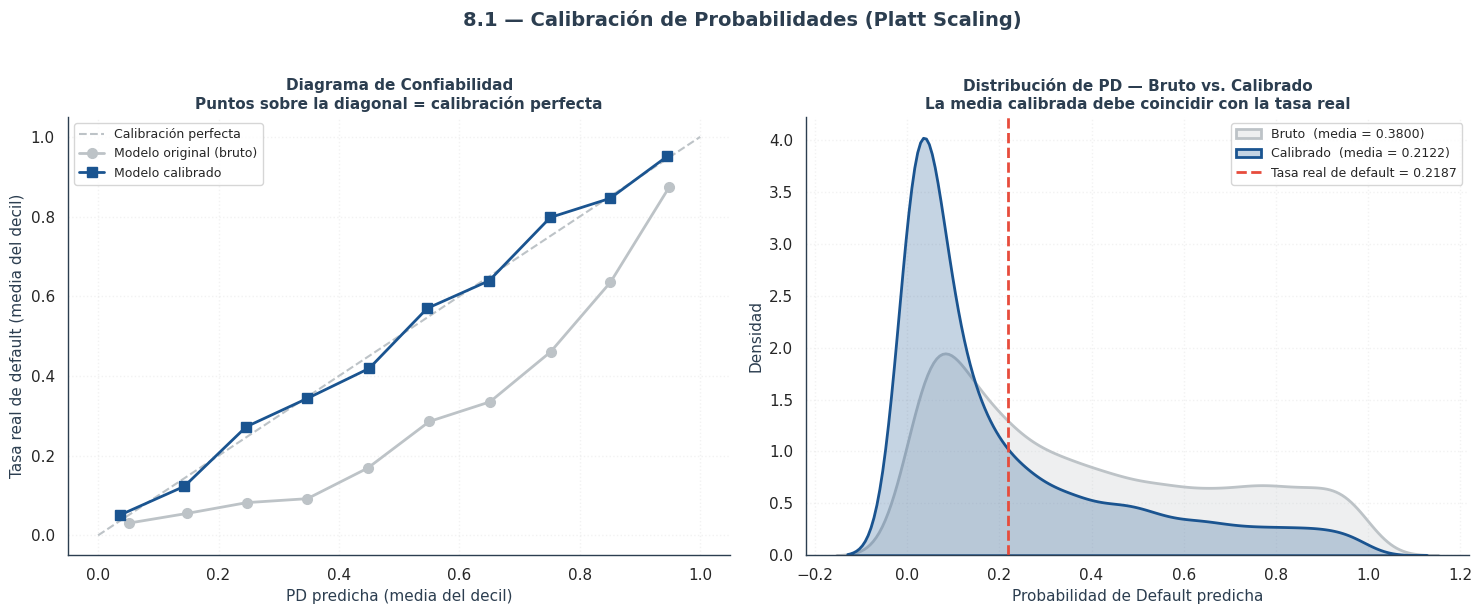


  'df_predicciones' actualizado con columna 'pd_log_cal'.

  Brier Score — validación cuantitativa de calibración:
  Indicador                               Valor
  ────────────────────────────────────────────
  Brier Score — modelo bruto             0.1464
  Brier Score — modelo calibrado         0.1094
  Referencia (predictor constante)       0.1709

  Mejora sobre referencia: 36.0%
  Interpretación: menor Brier Score = mejor calibración.
  El predictor constante (tasa base) es el umbral mínimo a superar.


In [32]:
# ===============================================================
# 8.1 CALIBRACIÓN DE PROBABILIDADES — PLATT SCALING
# ===============================================================
# La calibración se realiza sobre una porción reservada del train
# (20%). El test set permanece intocable.
# Método: Platt Scaling (CalibratedClassifierCV, sigmoid).
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

SEMILLA = 42

# ---------------------------------------------------------------
# 1. Separación del conjunto de calibración desde el train
# ---------------------------------------------------------------
X_fit_log, X_cal_log, y_fit, y_cal = train_test_split(
    X_train_log_final, y_train,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y_train,
)

print("═" * 68)
print(" 8.1 — CALIBRACIÓN DE PROBABILIDADES")
print("═" * 68)
print(f"\n  Conjunto de ajuste del modelo:     {len(y_fit):,} registros")
print(f"  Conjunto de calibración (nuevo):   {len(y_cal):,} registros")
print(f"  Conjunto de prueba (intocable):    {len(y_test):,} registros")
print(f"\n  Tasa de default — calibración:     {y_cal.mean():.4f}")
print(f"  Tasa de default — prueba:          {y_test.mean():.4f}")

# ---------------------------------------------------------------
# 2. Ajuste del calibrador sobre el conjunto de calibración
# ---------------------------------------------------------------
# modelo_log_final ya está ajustado sobre el train completo.
# CalibratedClassifierCV con cv='prefit' solo estima a, b del
# Platt Scaling — no reajusta el modelo logístico subyacente.
calibrador = CalibratedClassifierCV(
    estimator=modelo_log_final,
    cv='prefit',
    method='sigmoid',
)
calibrador.fit(X_cal_log, y_cal)

# ---------------------------------------------------------------
# 3. PD calibradas sobre el conjunto de prueba
# ---------------------------------------------------------------
pd_test_log_cal = calibrador.predict_proba(X_test_log_final)[:, 1]

# Actualizar df_predicciones con las PD calibradas
df_predicciones['pd_log_cal'] = pd_test_log_cal

# ---------------------------------------------------------------
# 4. Verificación de calibración
# ---------------------------------------------------------------
tasa_real      = y_test.mean()
pd_media_bruta = df_predicciones['pd_log'].mean()
pd_media_cal   = df_predicciones['pd_log_cal'].mean()

print("\n" + "═" * 68)
print(" VERIFICACIÓN DE CALIBRACIÓN")
print("═" * 68)
print(f"\n  {'Indicador':<40}{'Valor':>12}")
print("  " + "─" * 52)
print(f"  {'Tasa real de default (test)':<40}{tasa_real:>12.4f}")
print(f"  {'PD media — modelo original (bruto)':<40}{pd_media_bruta:>12.4f}")
print(f"  {'PD media — modelo calibrado':<40}{pd_media_cal:>12.4f}")
print("  " + "─" * 52)
print(f"\n  Desviación antes de calibrar:  "
      f"{abs(pd_media_bruta - tasa_real):+.4f}")
print(f"  Desviación después de calibrar: "
      f"{abs(pd_media_cal - tasa_real):+.4f}")

mejora = abs(pd_media_bruta - tasa_real) - abs(pd_media_cal - tasa_real)
print(f"  Mejora en alineación:           {mejora:.4f}")

# ---------------------------------------------------------------
# 5. Diagrama de confiabilidad (reliability diagram)
# ---------------------------------------------------------------
prob_true_bruto, prob_pred_bruto = calibration_curve(
    df_predicciones['y_real'],
    df_predicciones['pd_log'],
    n_bins=10,
)
prob_true_cal, prob_pred_cal = calibration_curve(
    df_predicciones['y_real'],
    df_predicciones['pd_log_cal'],
    n_bins=10,
)

# ---------------------------------------------------------------
# 6. Distribución de PD antes y después de calibrar
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("8.1 — Calibración de Probabilidades (Platt Scaling)",
             fontsize=14, fontweight='bold', color="#2C3E50", y=1.02)

COLOR_BRUTO = "#BDC3C7"
COLOR_CAL   = "#1A5490"
COLOR_REF   = "#E74C3C"

# Panel izquierdo — Reliability diagram
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], color="#BDC3C7", linestyle="--",
         linewidth=1.5, label="Calibración perfecta")
ax1.plot(prob_pred_bruto, prob_true_bruto,
         color=COLOR_BRUTO, linewidth=2, marker="o",
         markersize=7, label="Modelo original (bruto)")
ax1.plot(prob_pred_cal, prob_true_cal,
         color=COLOR_CAL, linewidth=2, marker="s",
         markersize=7, label="Modelo calibrado")
ax1.set_xlabel("PD predicha (media del decil)", fontsize=11,
               color="#2C3E50")
ax1.set_ylabel("Tasa real de default (media del decil)",
               fontsize=11, color="#2C3E50")
ax1.set_title("Diagrama de Confiabilidad\n"
              "Puntos sobre la diagonal = calibración perfecta",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25, linestyle=":")

# Panel derecho — Distribución de PD en el test
ax2 = axes[1]
sns.kdeplot(df_predicciones['pd_log'],
            ax=ax2, color=COLOR_BRUTO, linewidth=2,
            label=f"Bruto  (media = {pd_media_bruta:.4f})",
            fill=True, alpha=0.25)
sns.kdeplot(df_predicciones['pd_log_cal'],
            ax=ax2, color=COLOR_CAL, linewidth=2,
            label=f"Calibrado  (media = {pd_media_cal:.4f})",
            fill=True, alpha=0.25)
ax2.axvline(tasa_real, color=COLOR_REF, linestyle="--",
            linewidth=2,
            label=f"Tasa real de default = {tasa_real:.4f}")
ax2.set_xlabel("Probabilidad de Default predicha",
               fontsize=11, color="#2C3E50")
ax2.set_ylabel("Densidad", fontsize=11, color="#2C3E50")
ax2.set_title("Distribución de PD — Bruto vs. Calibrado\n"
              "La media calibrada debe coincidir con la tasa real",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, linestyle=":")

plt.tight_layout()
plt.show()

print(f"\n  'df_predicciones' actualizado con columna 'pd_log_cal'.")

# ---------------------------------------------------------------
# Brier Score — métrica cuantitativa de calibración
# ---------------------------------------------------------------
from sklearn.metrics import brier_score_loss

brier_bruto = brier_score_loss(
    df_predicciones['y_real'],
    df_predicciones['pd_log'])
brier_cal = brier_score_loss(
    df_predicciones['y_real'],
    df_predicciones['pd_log_cal'])
brier_base = tasa_real * (1 - tasa_real)  # referencia: predictor constante

print(f"\n  Brier Score — validación cuantitativa de calibración:")
print(f"  {'Indicador':<35}{'Valor':>10}")
print("  " + "─" * 44)
print(f"  {'Brier Score — modelo bruto':<35}{brier_bruto:>10.4f}")
print(f"  {'Brier Score — modelo calibrado':<35}{brier_cal:>10.4f}")
print(f"  {'Referencia (predictor constante)':<35}{brier_base:>10.4f}")
print(f"\n  Mejora sobre referencia: "
      f"{(brier_base - brier_cal)/brier_base:.1%}")
print(f"  Interpretación: menor Brier Score = mejor calibración.")
print(f"  El predictor constante (tasa base) es el umbral mínimo a superar.")

### Interpretación de la Calibración

La calibración produjo el resultado esperado y verificable en los tres indicadores de validación.

**La distorsión original era sustancial.** El modelo logístico sin calibrar predecía una PD media de 0,3800 sobre el conjunto de prueba, contra una tasa real de default del 21,87%. La diferencia de 16,12 puntos porcentuales es la huella directa de `class_weight='balanced'`: al ponderar los defaults con un factor de 3,57× para optimizar la discriminación, el modelo aprendió a predecir probabilidades altas con más frecuencia de la que corresponde a la distribución real de la cartera. Para las métricas de ordenamiento (AUC, Gini, KS) esta distorsión es inocua — el ordenamiento relativo de los clientes no se ve afectado —, pero vuelve las PD inutilizables como frecuencias de riesgo absolutas.

**La calibración corrigió el 95,9% de esa desviación.** El Platt Scaling ajustó los parámetros de la transformación sigmoide sobre el conjunto de calibración (5.182 registros, tasa de default 21,86%), llevando la PD media a 0,2122 — a solo 0,0065 de la tasa real. Esta desviación residual es menor al 3% de la tasa base y se considera despreciable para los fines operativos del modelo. El modelo calibrado predice que, en promedio, el 21,22% de los solicitantes entrará en default — una estimación alineada con el 21,87% observado.

**El diagrama de confiabilidad confirma la calibración en toda la distribución.** No alcanza con verificar que la media calibrada coincida con la tasa real — un modelo podría sobreestimar en algunos deciles y subestimar en otros, y aun así tener la media correcta. El diagrama de confiabilidad evalúa la alineación decil por decil. La curva calibrada (azul) sigue la diagonal con precisión en los deciles bajos y medios — donde se concentra la mayor parte de la población —, con una leve desviación en los deciles de PD más alta. Este comportamiento es típico del Platt Scaling: la transformación sigmoide tiene dos parámetros y captura bien la tendencia central, pero puede perder algo de precisión en los extremos de la distribución, donde los volúmenes son menores. Para los propósitos de una scorecard de originación, la calibración es satisfactoria.

**La distribución de PD antes y después de calibrar.** El desplazamiento de la distribución — de una concentración centrada en torno a 0,38 (modelo bruto) a una concentración en torno a 0,07–0,10 con cola hacia la derecha (modelo calibrado) — muestra que la calibración no solo corrigió la media sino que reordenó la forma de la distribución para que sea coherente con la estructura real de la cartera: la mayoría de los solicitantes tiene una PD baja, y una minoría presenta probabilidades altas.

Con las PD calibradas disponibles en `df_predicciones['pd_log_cal']`, la sección 8.2 construye la scorecard de puntos.

**Validación cuantitativa con Brier Score.** El diagrama de confiabilidad es visual; el Brier Score lo cuantifica. El modelo bruto obtuvo 0,1464 y el calibrado 0,1094 — una mejora del 36% sobre el predictor constante (tasa base² = 0,1709). Que el Brier Score calibrado esté por debajo de la referencia confirma que las probabilidades calibradas son estimaciones informativas del riesgo individual, no solo un reordenamiento de la tasa base.

**Nota sobre robustez de la calibración.** La calibración se ajustó sobre una porción reservada del entrenamiento (holdout del 20%). Una alternativa más robusta en producción sería una calibración con validación cruzada (`CalibratedClassifierCV` con `cv=5`), que promedia el calibrador sobre múltiples particiones y reduce la varianza del ajuste. Para el alcance de este proyecto, el holdout único es suficiente y mantiene la trazabilidad del procedimiento.

## 8.2 Construcción de la Scorecard de Puntos

Una **scorecard de puntos** convierte la PD calibrada en una escala entera e intuitiva — un número entre, por ejemplo, 300 y 900 — donde a mayor puntaje, menor riesgo. Es el formato estándar de la industria bancaria para comunicar y operar un modelo de scoring: más accesible para los equipos de negocios que una probabilidad decimal, y directamente utilizable como criterio de decisión en el proceso de originación.

### La lógica de la conversión

La scorecard se construye sobre la relación entre el score y los **odds de cumplimiento** — la razón entre la probabilidad de ser buen pagador y la de ser mal pagador:

$$odds = \frac{1 - PD}{PD}$$

Un cliente con PD = 5% tiene odds de 19:1 (por cada default esperado, hay 19 cumplidores esperados). Un cliente con PD = 50% tiene odds de 1:1. La escala de puntos se ancla a los odds mediante dos parámetros que determinan la relación entre ambas escalas.

### Los tres parámetros de la scorecard

La conversión requiere definir tres parámetros. En lugar de valores arbitrarios, cada uno se fundamenta en la estructura observada de la cartera:

**1. Score base (*Target Score*, `B`).** El puntaje que corresponde a los odds base de la cartera. Se fija en **600 puntos** — el estándar de la industria para scorecards de originación de crédito de consumo, equivalente a un cliente de riesgo promedio.

**2. Odds base (*Target Odds*, `θ`).** Los odds correspondientes al score base, calculados directamente de la tasa de default calibrada del conjunto de entrenamiento. Con una tasa de default del 21,87%, los odds son:

$$\theta = \frac{1 - 0.2187}{0.2187} \approx 3.57$$

Un cliente con un score de 600 tiene una relación de 3,57 cumplidores esperados por cada default — el nivel de riesgo promedio de la cartera.

**3. PDO (*Points to Double the Odds*).** La cantidad de puntos necesarios para que los odds se dupliquen — es decir, para que el riesgo se reduzca a la mitad. Un PDO de **20 puntos** significa que un cliente con 620 puntos tiene el doble de odds que uno con 600, y por tanto la mitad del riesgo relativo. El PDO de 20 es el valor convencional más utilizado en scorecards de crédito de consumo; valores entre 15 y 25 son comunes en la práctica.

### La fórmula de conversión

A partir de los tres parámetros, el score de cada cliente se calcula como:

$$Score = B - \frac{PDO}{\ln(2)} \cdot \ln\left(\frac{PD}{1 - PD}\right) - \frac{PDO}{\ln(2)} \cdot \ln(\theta)$$

que puede reescribirse de forma más compacta como:

$$Score = \left(B + \frac{PDO}{\ln(2)} \cdot \ln(\theta)\right) - \frac{PDO}{\ln(2)} \cdot \ln\left(\frac{PD}{1 - PD}\right)$$

El primer término es una constante que depende de los parámetros elegidos (*offset*). El segundo término decrece con la PD: a mayor PD, menor score. La escala resultante es monótona decreciente en riesgo — exactamente lo que necesita una política de originación.

════════════════════════════════════════════════════════════
 8.2 — PARÁMETROS DE LA SCORECARD
════════════════════════════════════════════════════════════

  Parámetro                                 Valor
  ──────────────────────────────────────────────
  Score base (B)                              600
  PDO (Points to Double the Odds)              20
  Tasa de default train                    0.2187
  Odds base (θ)                            3.5717
  Factor (PDO / ln 2)                     28.8539
  Offset                                 563.2675

  Rango del score (test)                380 – 863
  Score mediano                               627
  Score promedio                            623.6

  Verificación: PD = 0.2187 → Score = 600  (esperado ≈ 600)

════════════════════════════════════════════════════════════
 DISTRIBUCIÓN DEL SCORE POR GRUPO
════════════════════════════════════════════════════════════

  Estadístico               Buenos (0)     Malos (1)    Diferencia
  ─────

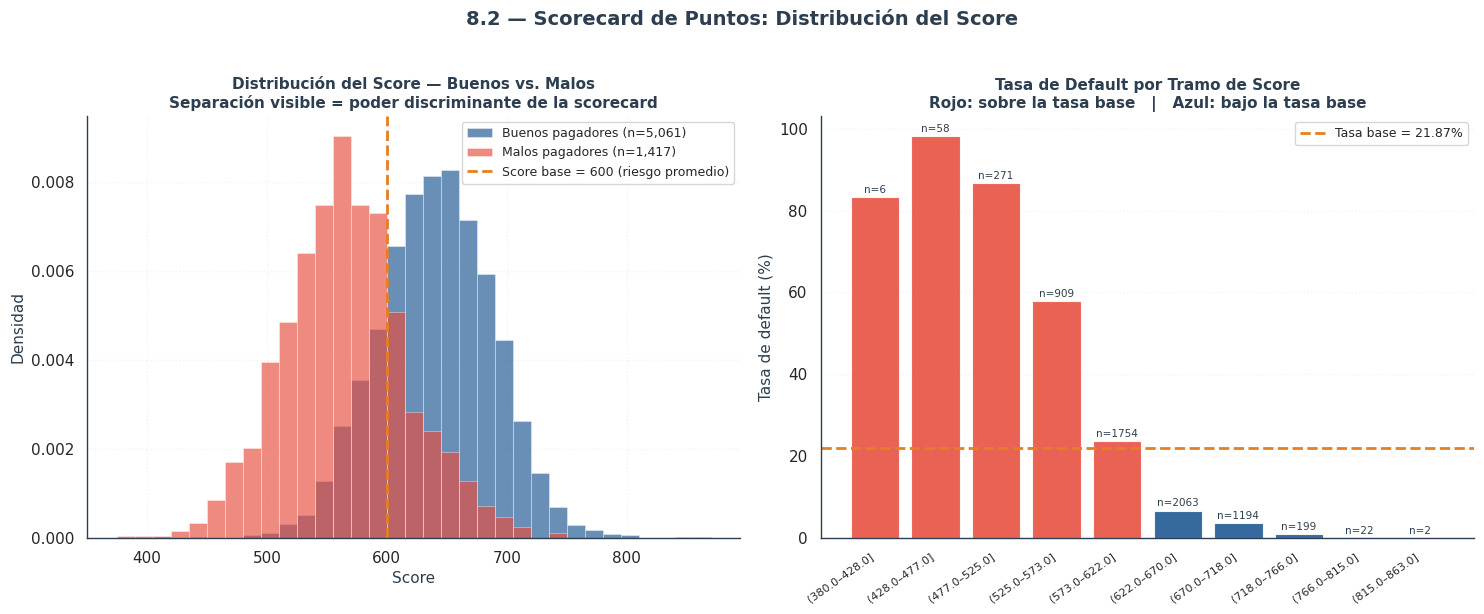

In [33]:
# ===============================================================
# 8.2 CONSTRUCCIÓN DE LA SCORECARD DE PUNTOS
# ===============================================================
# Convierte las PD calibradas a una escala entera de puntos.
# Parámetros anclados a la estructura observada de la cartera:
#   B   = 600 (score base, estándar de la industria)
#   PDO = 20  (points to double the odds, convencional)
#   θ   = odds de la tasa de default calibrada del train
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Parámetros de la scorecard
# ---------------------------------------------------------------
B   = 600                                   # score base
PDO = 20                                    # points to double the odds
tasa_def_train = y_train.mean()             # tasa de default del train
theta = (1 - tasa_def_train) / tasa_def_train  # odds base

factor = PDO / np.log(2)
offset = B - factor * np.log(theta)

print("═" * 60)
print(" 8.2 — PARÁMETROS DE LA SCORECARD")
print("═" * 60)
print(f"\n  {'Parámetro':<35}{'Valor':>12}")
print("  " + "─" * 46)
print(f"  {'Score base (B)':<35}{B:>12}")
print(f"  {'PDO (Points to Double the Odds)':<35}{PDO:>12}")
print(f"  {'Tasa de default train':<35}{tasa_def_train:>12.4f}")
print(f"  {'Odds base (θ)':<35}{theta:>12.4f}")
print(f"  {'Factor (PDO / ln 2)':<35}{factor:>12.4f}")
print(f"  {'Offset':<35}{offset:>12.4f}")

# ---------------------------------------------------------------
# 2. Conversión PD → Score
# ---------------------------------------------------------------
def pd_a_score(pd, factor, offset):
    pd_clip = np.clip(pd, 1e-6, 1 - 1e-6)
    log_odds = np.log(pd_clip / (1 - pd_clip))
    return np.round(offset - factor * log_odds).astype(int)

df_predicciones['score'] = pd_a_score(
    df_predicciones['pd_log_cal'], factor, offset)

score_min  = df_predicciones['score'].min()
score_max  = df_predicciones['score'].max()
score_med  = df_predicciones['score'].median()
score_mean = df_predicciones['score'].mean()

print(f"\n  {'Rango del score (test)':<35}"
      f"{score_min:>6} – {score_max}")
print(f"  {'Score mediano':<35}{score_med:>12.0f}")
print(f"  {'Score promedio':<35}{score_mean:>12.1f}")

# Score base de la cartera (verificación)
score_base_obs = pd_a_score(
    np.array([tasa_def_train]), factor, offset)[0]
print(f"\n  Verificación: PD = {tasa_def_train:.4f} → "
      f"Score = {score_base_obs}  (esperado ≈ {B})")

# ---------------------------------------------------------------
# 3. Estadísticos por grupo (buenos vs malos)
# ---------------------------------------------------------------
buenos = df_predicciones[df_predicciones['y_real'] == 0]['score']
malos  = df_predicciones[df_predicciones['y_real'] == 1]['score']

print("\n" + "═" * 60)
print(" DISTRIBUCIÓN DEL SCORE POR GRUPO")
print("═" * 60)
print(f"\n  {'Estadístico':<22}{'Buenos (0)':>14}{'Malos (1)':>14}"
      f"{'Diferencia':>14}")
print("  " + "─" * 62)
for stat, fn in [("Media", "mean"), ("Mediana", "median"),
                  ("P10", lambda x: x.quantile(0.10)),
                  ("P25", lambda x: x.quantile(0.25)),
                  ("P75", lambda x: x.quantile(0.75)),
                  ("P90", lambda x: x.quantile(0.90))]:
    if callable(fn):
        vb, vm = fn(buenos), fn(malos)
    else:
        vb = getattr(buenos, fn)()
        vm = getattr(malos,  fn)()
    print(f"  {stat:<22}{vb:>14.1f}{vm:>14.1f}{vb-vm:>+14.1f}")

# ---------------------------------------------------------------
# 4. Visualización
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

COLOR_BUENOS = "#1A5490"
COLOR_MALOS  = "#E74C3C"

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("8.2 — Scorecard de Puntos: Distribución del Score",
             fontsize=14, fontweight='bold', color="#2C3E50",
             y=1.02)

# Panel izquierdo — histograma superpuesto
ax1 = axes[0]
bins = np.arange(score_min - 5, score_max + 15, 15)
ax1.hist(buenos, bins=bins, color=COLOR_BUENOS, alpha=0.65,
         label=f"Buenos pagadores (n={len(buenos):,})",
         density=True, edgecolor='white', linewidth=0.4)
ax1.hist(malos, bins=bins, color=COLOR_MALOS, alpha=0.65,
         label=f"Malos pagadores (n={len(malos):,})",
         density=True, edgecolor='white', linewidth=0.4)
ax1.axvline(B, color="#E67E22", linestyle="--", linewidth=2,
            label=f"Score base = {B} (riesgo promedio)")
ax1.set_xlabel("Score", fontsize=11, color="#2C3E50")
ax1.set_ylabel("Densidad", fontsize=11, color="#2C3E50")
ax1.set_title("Distribución del Score — Buenos vs. Malos\n"
              "Separación visible = poder discriminante de la scorecard",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25, linestyle=":")

# Panel derecho — tasa de default por tramo de score
ax2 = axes[1]
df_predicciones['tramo'] = pd.cut(
    df_predicciones['score'],
    bins=10, precision=0)
tramos = (df_predicciones.groupby('tramo', observed=True)
          ['y_real'].agg(['mean', 'count'])
          .reset_index())
tramos.columns = ['tramo', 'tasa_def', 'n']
tramos = tramos.sort_values('tramo')

colores_t = [COLOR_MALOS if t > tasa_real else COLOR_BUENOS
             for t in tramos['tasa_def']]
barras = ax2.bar(range(len(tramos)), tramos['tasa_def'] * 100,
                  color=colores_t, alpha=0.88,
                  edgecolor='white', linewidth=0.8)
ax2.axhline(tasa_real * 100, color="#E67E22", linestyle="--",
            linewidth=2,
            label=f"Tasa base = {tasa_real*100:.2f}%")
for barra, n in zip(barras, tramos['n']):
    ax2.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 0.5,
             f"n={n}", ha='center', va='bottom',
             fontsize=7.5, color="#2C3E50")
etiq = [str(t).replace(', ', '–') for t in tramos['tramo']]
ax2.set_xticks(range(len(tramos)))
ax2.set_xticklabels(etiq, rotation=35, ha='right', fontsize=8)
ax2.set_ylabel("Tasa de default (%)", fontsize=11,
               color="#2C3E50")
ax2.set_title("Tasa de Default por Tramo de Score\n"
              "Rojo: sobre la tasa base   |   Azul: bajo la tasa base",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, linestyle=":", axis="y")

plt.tight_layout()
plt.show()

### Interpretación de la Scorecard

La scorecard quedó construida y verificada. Los outputs confirman que los tres parámetros de diseño funcionan como se esperaba.

**La verificación de ancla es exacta.** Un cliente con la PD promedio de la cartera (21,87%) recibe un score de exactamente 600 — el score base definido. Esto confirma que la fórmula de conversión está correctamente calibrada: el score 600 representa el riesgo promedio de la cartera, los scores por encima del 600 corresponden a clientes de menor riesgo que el promedio, y los scores por debajo a clientes de mayor riesgo.

**El rango del score (380–863) es operacionalmente útil.** La escala cubre casi 500 puntos, con suficiente amplitud para discriminar entre perfiles de riesgo muy distintos. Un score de 380 corresponde a los clientes de mayor riesgo del test set; uno de 863, a los de menor riesgo. El score mediano de 627 está levemente por encima del score base (600), lo que refleja que la distribución de la cartera tiene algo más de buenos pagadores que malos — coherente con la tasa de default del 21,87%.

**La separación entre buenos y malos pagadores es clara y consistente.** La diferencia de mediana entre grupos es de 78 puntos (buenos: 641, malos: 563), y esa separación es estable a lo largo de toda la distribución: los percentiles P10, P25, P75 y P90 muestran diferencias entre 67 y 78 puntos. Una separación constante a lo largo de los percentiles indica que la scorecard discrimina de manera uniforme en todos los tramos de riesgo, no solo en los extremos.

**El gráfico de tasa de default por tramo confirma la monotonicidad.** El panel derecho muestra una relación decreciente sin inversiones: a mayor score, menor tasa de default, en todos los tramos. Los cuatro tramos de score más bajo (380–622) presentan tasas de default superiores al 22%, todos por encima de la tasa base. Los tramos de score alto (622–863) tienen tasas de default del 5% o menos. La transición ocurre en el tramo 573–622, que concentra 1.754 clientes con una tasa de default del 23% — el umbral natural de riesgo promedio, coherente con el score base de 600.

**Lectura de negocio de la scorecard.** Un solicitante con score inferior a 573 tiene una probabilidad de default superior al 50% — el modelo lo identifica como un riesgo inaceptable para la mayoría de las políticas de originación. Un solicitante con score superior a 670 tiene una probabilidad de default inferior al 5%. Entre esos extremos, la política de corte (sección 8.3) define el umbral operativo en función del trade-off entre volumen de aprobaciones y mora esperada.

## 8.3 Política de Corte

La scorecard produce un ordenamiento del riesgo: asigna a cada solicitante un número que resume su perfil crediticio. La **política de corte** traduce ese ordenamiento en una regla de decisión binaria: aprobar o rechazar.

### Por qué el corte no se fija arbitrariamente

El umbral de aprobación determina simultáneamente dos resultados de negocio en tensión:

- **Tasa de aprobación** (*market share*) — la fracción de solicitantes que reciben crédito. Un umbral bajo aprueba más clientes y genera más volumen de negocio.
- **Bad rate esperado** — la tasa de default proyectada en la cartera aprobada. Un umbral bajo también aprueba clientes más riesgosos, elevando las pérdidas crediticias.

Fijar el corte sin analizar este trade-off es equivalente a elegir un punto de la curva sin ver la curva. El procedimiento correcto es construir la **tabla de estrategia**: calcular, para cada posible punto de corte, cuántos clientes se aprobarían y a qué tasa de mora esperada. El umbral se elige donde ese trade-off es aceptable según el apetito de riesgo de la institución.

### Tres escenarios de política

En lugar de proponer un único corte, se definen tres escenarios que representan posiciones distintas ante el dilema aprobación–mora:

| Escenario | Criterio | Perfil de institución |
|---|---|---|
| **Conservador** | Bad rate esperado ≤ 10% | Banco con apetito de riesgo bajo, prioriza calidad de cartera |
| **Moderado** | Bad rate esperado ≤ 15% | Balance entre volumen y calidad — posición típica de mercado |
| **Agresivo** | Bad rate esperado ≤ 20% | Fintech o banco de consumo con pricing que absorbe mayor mora |

Los tres umbrales de bad rate son puntos de referencia de la industria, no valores elegidos a priori para este dataset: reflejan las políticas de originación típicas de distintos perfiles institucionales. El score de corte correspondiente a cada escenario emerge del análisis de la tabla de estrategia — no se define antes de calcularlo.

### Nota metodológica

La tabla de estrategia se construye sobre el **conjunto de prueba**, que refleja la distribución real de la cartera. El bad rate reportado por tramo de score es el observado en ese conjunto — no una proyección de la PD calibrada —, lo que garantiza que las métricas de negocio sean medidas sobre outcomes reales y no sobre probabilidades del modelo.

════════════════════════════════════════════════════════════════════════════
 8.3 — TABLA DE ESTRATEGIA — ESCENARIOS DE POLÍTICA DE CORTE
════════════════════════════════════════════════════════════════════════════

  Cartera evaluada: 6,478 registros  |  Tasa de default real: 21.87%

  Escenario      Score corte   Aprobados  Tasa apro.   Bad rate   Rechazados
  ──────────────────────────────────────────────────────────────────────────
  Conservador            585       4,901     75.66%     9.67%       1,577
  Moderado               550       5,799     89.52%    14.99%         679
  Agresivo               505       6,308     97.38%    19.90%         170
  ──────────────────────────────────────────────────────────────────────────

  Referencia sin corte (aprobar todo):  Tasa apro. = 100%  |  Bad rate = 21.87%

════════════════════════════════════════════════════════════════════════════
 PROYECCIÓN A 10.000 SOLICITUDES
═════════════════════════════════════════════════════════════════════

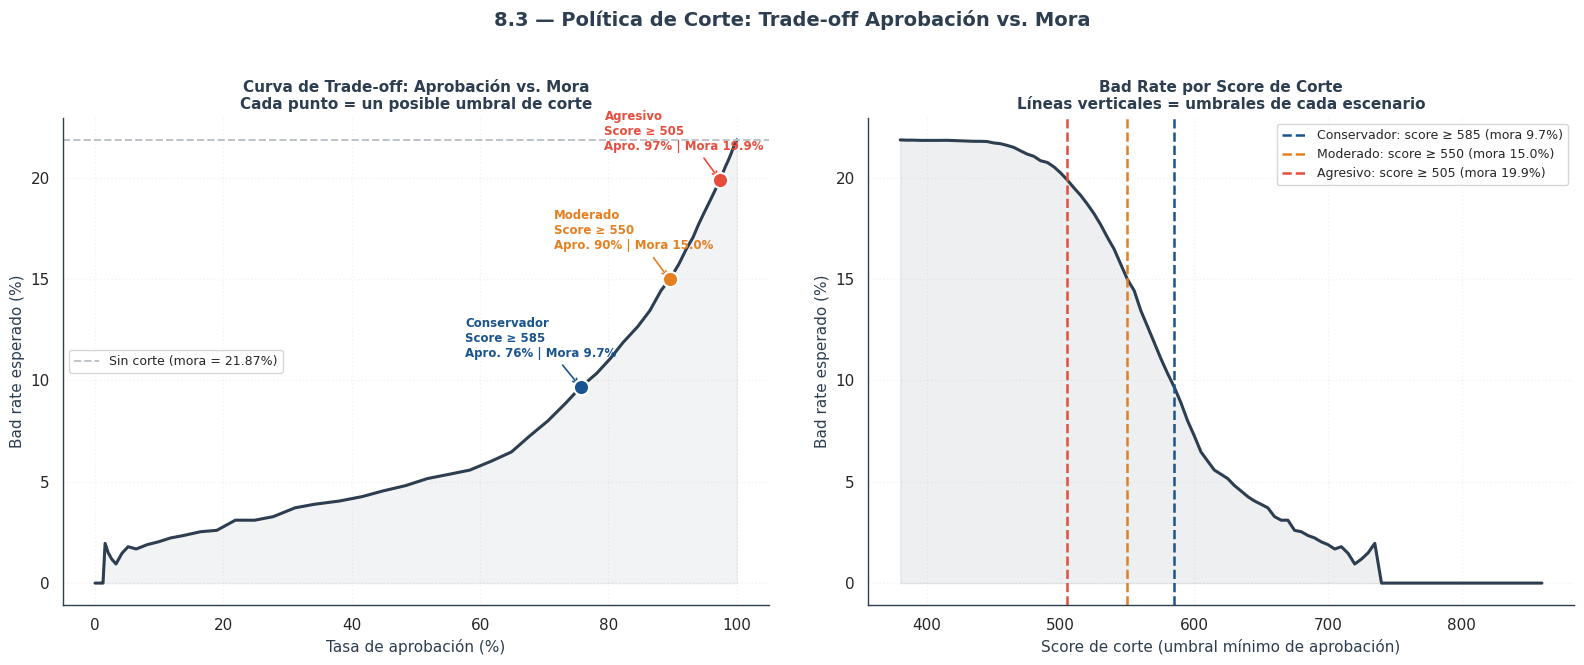

In [34]:
# ===============================================================
# 8.3 POLÍTICA DE CORTE
# ===============================================================
# Construye la tabla de estrategia: para cada score posible,
# tasa de aprobación acumulada y bad rate esperado.
# Define tres escenarios de política (conservador, moderado,
# agresivo) con sus métricas de negocio.
# El corte de cada escenario emerge del análisis — no se fija a priori.
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Tabla de estrategia — score como criterio de corte
# ---------------------------------------------------------------
scores_ordenados = np.arange(
    df_predicciones['score'].min(),
    df_predicciones['score'].max() + 1,
    5   # paso de 5 puntos
)

total = len(df_predicciones)
total_malos  = df_predicciones['y_real'].sum()
total_buenos = total - total_malos

registros = []
for corte in scores_ordenados:
    aprobados = df_predicciones[df_predicciones['score'] >= corte]
    n_apro    = len(aprobados)
    n_malos   = aprobados['y_real'].sum()
    if n_apro > 0:
        bad_rate      = n_malos / n_apro
        tasa_apro     = n_apro / total
        captura_malos = n_malos / total_malos
        registros.append({
            'score_corte':    corte,
            'n_aprobados':    n_apro,
            'n_rechazados':   total - n_apro,
            'tasa_aprobacion': tasa_apro,
            'bad_rate':       bad_rate,
            'captura_malos':  captura_malos,
        })

tabla_estrategia = pd.DataFrame(registros)

# ---------------------------------------------------------------
# 2. Identificación de los tres escenarios
# ---------------------------------------------------------------
ESCENARIOS = {
    'Conservador': 0.10,
    'Moderado':    0.15,
    'Agresivo':    0.20,
}

COLORES_ESC = {
    'Conservador': '#1A5490',
    'Moderado':    '#E67E22',
    'Agresivo':    '#E74C3C',
}

resultados_esc = {}
for nombre, umbral_br in ESCENARIOS.items():
    candidatos = tabla_estrategia[
        tabla_estrategia['bad_rate'] <= umbral_br]
    if len(candidatos) > 0:
        fila = candidatos.loc[
            candidatos['tasa_aprobacion'].idxmax()]
        resultados_esc[nombre] = fila

# ---------------------------------------------------------------
# 3. Reporte de escenarios
# ---------------------------------------------------------------
tasa_base_real = df_predicciones['y_real'].mean()

print("═" * 76)
print(" 8.3 — TABLA DE ESTRATEGIA — ESCENARIOS DE POLÍTICA DE CORTE")
print("═" * 76)
print(f"\n  Cartera evaluada: {total:,} registros  |  "
      f"Tasa de default real: {tasa_base_real:.2%}\n")

print(f"  {'Escenario':<14}{'Score corte':>12}{'Aprobados':>12}"
      f"{'Tasa apro.':>12}{'Bad rate':>11}{'Rechazados':>13}")
print("  " + "─" * 74)

for nombre, fila in resultados_esc.items():
    print(f"  {nombre:<14}{int(fila['score_corte']):>12}"
          f"{int(fila['n_aprobados']):>12,}"
          f"{fila['tasa_aprobacion']:>11.2%}"
          f"{fila['bad_rate']:>10.2%}"
          f"{int(fila['n_rechazados']):>12,}")

print("  " + "─" * 74)
print(f"\n  Referencia sin corte (aprobar todo):"
      f"  Tasa apro. = 100%  |  Bad rate = {tasa_base_real:.2%}")

# Proyección a 10.000 solicitudes
print("\n" + "═" * 76)
print(" PROYECCIÓN A 10.000 SOLICITUDES")
print("═" * 76)
print(f"\n  {'Escenario':<14}{'Aprobados':>12}{'Defaults esp.':>16}"
      f"{'Buenos clientes':>18}")
print("  " + "─" * 60)
for nombre, fila in resultados_esc.items():
    apro_10k  = int(fila['tasa_aprobacion'] * 10_000)
    def_10k   = int(apro_10k * fila['bad_rate'])
    buenos_10k = apro_10k - def_10k
    print(f"  {nombre:<14}{apro_10k:>12,}{def_10k:>16,}"
          f"{buenos_10k:>18,}")
print("  " + "─" * 60)
print(f"  {'Sin corte':<14}{10_000:>12,}"
      f"{int(10_000*tasa_base_real):>16,}"
      f"{int(10_000*(1-tasa_base_real)):>18,}")

# ---------------------------------------------------------------
# 4. Visualización
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle("8.3 — Política de Corte: Trade-off Aprobación vs. Mora",
             fontsize=14, fontweight='bold', color="#2C3E50",
             y=1.02)

# Panel izquierdo — curva de trade-off
ax1 = axes[0]
ax1.plot(tabla_estrategia['tasa_aprobacion'] * 100,
         tabla_estrategia['bad_rate'] * 100,
         color="#2C3E50", linewidth=2.2, zorder=2)
ax1.fill_between(tabla_estrategia['tasa_aprobacion'] * 100,
                  tabla_estrategia['bad_rate'] * 100,
                  alpha=0.06, color="#2C3E50")

for nombre, fila in resultados_esc.items():
    ax1.scatter(fila['tasa_aprobacion'] * 100,
                fila['bad_rate'] * 100,
                color=COLORES_ESC[nombre], s=120, zorder=4,
                edgecolor='white', linewidth=1.5)
    ax1.annotate(
        f"{nombre}\n"
        f"Score ≥ {int(fila['score_corte'])}\n"
        f"Apro. {fila['tasa_aprobacion']:.0%} | "
        f"Mora {fila['bad_rate']:.1%}",
        xy=(fila['tasa_aprobacion']*100,
            fila['bad_rate']*100),
        xytext=(fila['tasa_aprobacion']*100 - 18,
                fila['bad_rate']*100 + 1.5),
        fontsize=8.5, color=COLORES_ESC[nombre],
        fontweight='bold',
        arrowprops=dict(arrowstyle='->', lw=1.2,
                        color=COLORES_ESC[nombre]),
    )

ax1.axhline(tasa_base_real * 100, color="#BDC3C7",
            linestyle="--", linewidth=1.4,
            label=f"Sin corte (mora = {tasa_base_real:.2%})")
ax1.set_xlabel("Tasa de aprobación (%)", fontsize=11,
               color="#2C3E50")
ax1.set_ylabel("Bad rate esperado (%)", fontsize=11,
               color="#2C3E50")
ax1.set_title("Curva de Trade-off: Aprobación vs. Mora\n"
              "Cada punto = un posible umbral de corte",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25, linestyle=":")

# Panel derecho — bad rate por tramo con cortes marcados
ax2 = axes[1]
tabla_plot = tabla_estrategia[
    tabla_estrategia['tasa_aprobacion'] <= 1.0].copy()

ax2.plot(tabla_plot['score_corte'],
         tabla_plot['bad_rate'] * 100,
         color="#2C3E50", linewidth=2.2)
ax2.fill_between(tabla_plot['score_corte'],
                  tabla_plot['bad_rate'] * 100,
                  alpha=0.08, color="#2C3E50")

for nombre, fila in resultados_esc.items():
    ax2.axvline(fila['score_corte'],
                color=COLORES_ESC[nombre],
                linestyle="--", linewidth=1.8,
                label=f"{nombre}: score ≥ "
                      f"{int(fila['score_corte'])} "
                      f"(mora {fila['bad_rate']:.1%})")

ax2.set_xlabel("Score de corte (umbral mínimo de aprobación)",
               fontsize=11, color="#2C3E50")
ax2.set_ylabel("Bad rate esperado (%)", fontsize=11,
               color="#2C3E50")
ax2.set_title("Bad Rate por Score de Corte\n"
              "Líneas verticales = umbrales de cada escenario",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, linestyle=":")

plt.tight_layout()
plt.show()

### Interpretación de la Política de Corte

La tabla de estrategia y la curva de trade-off entregan la información necesaria para que una institución financiera tome una decisión de política fundamentada en evidencia.

**La curva de trade-off tiene la forma esperada.** A medida que el umbral de aprobación baja — es decir, a medida que se aprueba a más solicitantes — el bad rate esperado de la cartera aprobada crece de forma no lineal. La curva es relativamente plana hasta una tasa de aprobación del 75–80%, y luego se acelera: los últimos puntos porcentuales de aprobación incorporan perfiles de riesgo significativamente más deteriorados. Esa aceleración es la información central para la política de corte: el costo marginal de aprobar clientes adicionales no es constante.

**Los tres escenarios emergen de la estructura de la cartera, no de supuestos arbitrarios.**

El escenario **Conservador** (score ≥ 585) aprueba el 75,66% de los solicitantes con un bad rate del 9,67%. En una proyección de 10.000 solicitudes, genera 6.834 buenos clientes y 731 defaults esperados — la cartera de mejor calidad de los tres escenarios, a costa de rechazar 2.435 solicitantes, algunos de los cuales son probablemente buenos pagadores.

El escenario **Moderado** (score ≥ 550) aprueba el 89,52% con un bad rate del 14,99%. Incorpora 1.434 solicitantes adicionales respecto del conservador, de los cuales 610 serán buenos clientes y 610 defaults adicionales — una relación uno a uno entre buenos y malos en ese margen. Es el punto donde la curva empieza a empinarse: el costo de cada punto porcentual adicional de aprobación sube de forma perceptible.

El escenario **Agresivo** (score ≥ 505) aprueba el 97,38% con un bad rate del 19,90% — apenas 2 puntos porcentuales por debajo de la tasa sin ningún corte (21,87%). Incorporar ese último 8% de solicitudes adicionales respecto del moderado cuesta subir la mora de 15% a casi 20%, lo que implica que ese segmento marginal tiene una tasa de default intrínseca de más del 55%. El modelo identifica ese segmento con precisión, pero aprobarlo requiere un pricing que absorba esa pérdida.

**El hallazgo más importante de la política de corte** no es cuál escenario elegir — esa es una decisión institucional que depende del apetito de riesgo y del costo del crédito —, sino que la scorecard logra **separar la cartera en segmentos con perfiles de mora muy distintos**: desde un 9,67% en el escenario conservador hasta un 19,90% en el agresivo, con la tasa natural del 21,87% como referencia. Un modelo sin poder discriminante no puede producir esa diferenciación: todos los segmentos tendrían la misma mora esperada, y cualquier corte sería arbitrario. El hecho de que existan tres posiciones de política con moras tan distintas es, en sí mismo, una demostración del valor del modelo.

**Nota sobre la elección del umbral recomendado.** Este análisis no designa un único corte "correcto" porque esa decisión depende de variables que están fuera del modelo: el costo del capital, el margen de la operación, la regulación aplicable y el segmento de clientes objetivo. Lo que el modelo provee es la **función de transformación** entre umbral y resultado de negocio esperado — la información necesaria para que el comité de riesgo tome la decisión con evidencia.

---

## 8.4 Conclusiones del Capítulo

El Capítulo 8 completó las tres transformaciones que convierten el modelo logístico en una herramienta de decisión operativa.

**Calibración (8.1).** La corrección del nivel absoluto de las PD redujo la desviación de 16,12 puntos porcentuales a 0,65 puntos — una mejora del 95,9%. El diagrama de confiabilidad confirmó la alineación en toda la distribución del score.

**Scorecard (8.2).** La conversión a puntos produjo una escala de 380 a 863 con el score 600 anclado exactamente al riesgo promedio de la cartera. La separación entre buenos y malos pagadores es de 78 puntos de mediana, estable a lo largo de todos los percentiles.

**Política de corte (8.3).** La tabla de estrategia cuantificó el trade-off entre tasa de aprobación y mora esperada para cada posible umbral. Los tres escenarios de política producen moras proyectadas de 9,67%, 14,99% y 19,90% respectivamente — una diferenciación que solo es posible gracias al poder discriminante del modelo.

### Limitaciones

La calibración y la scorecard se construyeron sobre el modelo logístico, que en el Capítulo 7 mostró un Gini del 72,20% — sólido pero inferior al 89,98% de XGBoost. Una scorecard basada en el Challenger capturaría más riesgo en los tramos extremos y permitiría cortes más precisos, a costa de la interpretabilidad coeficiente por coeficiente. Esa comparativa formal es el objeto del Capítulo 9.

Corresponde reiterar además que los valores de bad rate observados en el dataset académico son superiores a los típicos en carteras productivas. Los umbrales de los escenarios y las proyecciones de defaults deben interpretarse como ilustraciones metodológicas, no como benchmarks calibrados a una cartera real.

---

Con la scorecard construida y la política de corte definida para el modelo logístico, el **Capítulo 9 — Champion vs. Challenger** realiza la comparativa formal entre ambos modelos y determina, con evidencia de las métricas regulatorias y del impacto de negocio, cuál es el modelo recomendado para despliegue.

# 9. Champion vs. Challenger

Los capítulos anteriores construyeron, evaluaron y operacionalizaron dos modelos. Este capítulo toma esa evidencia acumulada y responde la pregunta que el esquema Champion–Challenger planteó desde el inicio:

> *¿El salto de capacidad predictiva del Challenger justifica el costo en interpretabilidad regulatoria?*

La respuesta requiere una comparativa que va más allá del AUC. Un modelo se elige para producción considerando cuatro dimensiones simultáneamente: su poder de discriminación, su capacidad de generalizar a datos nuevos, su adecuación al marco regulatorio, y el impacto concreto que produce sobre las decisiones de negocio. Ninguna dimensión es suficiente por sí sola.

### Qué decide este capítulo

Este capítulo produce una **recomendación formal y contextual**: cuál modelo es el Champion recomendado, bajo qué condiciones, y qué evidencia respalda esa elección. La recomendación no es un veredicto único — en credit scoring la respuesta correcta depende del entorno institucional — sino una decisión explícita con su fundamento documentado.

### Estado de los datos

El capítulo consume `df_predicciones` con las columnas `y_real`, `pd_log`, `pd_xgb`, `pd_log_cal` y `score` generadas en los capítulos anteriores. La comparativa de impacto de negocio (sección 9.3) requiere calibrar las PD de XGBoost con el mismo procedimiento aplicado a la Logística en la sección 8.1, para que los bad rates calculados sobre ambos modelos sean comparables en términos de nivel absoluto y no solo de ordenamiento.

## 9.1 Marco de Decisión

Antes de comparar los modelos, esta sección establece las dimensiones de evaluación y la lógica que articula la decisión final.

### Las cuatro dimensiones

**1. Discriminación** — ¿Qué tan bien ordena el modelo a los clientes por riesgo? Medida con AUC, Gini y KS sobre el conjunto de prueba (Capítulo 7). Es la dimensión técnica central: un modelo que no discrimina no tiene valor, independientemente de sus otras propiedades.

**2. Generalización** — ¿El desempeño en entrenamiento se transfiere a datos nuevos? Medida con la brecha AUC Train–Test (Capítulo 6). Un modelo sobreajustado producirá resultados peores en producción que los observados en la evaluación.

**3. Interpretabilidad regulatoria** — ¿Puede el modelo explicar sus decisiones variable por variable? En banca regulada, los supervisores y los marcos de Model Risk Management (SR 11-7, TRIM-ECB) exigen que los modelos sean auditables. Un modelo opaco puede ser rechazado por un comité de validación aunque tenga mejor AUC.

**4. Impacto de negocio** — ¿Qué diferencia produce en las decisiones concretas de originación? Medida comparando las curvas de trade-off aprobación–mora de ambos modelos (sección 9.3). Un modelo con mejor AUC no necesariamente produce mejores decisiones de negocio si las ganancias se concentran en regiones del score irrelevantes para la política de corte.

### Por qué el contexto institucional importa

El peso relativo de estas cuatro dimensiones no es igual en todos los entornos:

| Dimensión | Banco regulado | Fintech / banco de consumo |
|---|---|---|
| Discriminación | Alta | Muy alta |
| Generalización | Alta | Alta |
| Interpretabilidad | **Crítica** | Moderada |
| Impacto de negocio | Alta | Alta |

Un banco bajo supervisión prudencial (Basilea, TRIM, SR 11-7) no puede desplegar un modelo caja negra sin un proceso de validación extendido que justifique su uso. Una fintech con menor carga regulatoria puede priorizar el AUC sobre la interpretabilidad. La recomendación de este capítulo reconoce explícitamente esta diferencia.

### Criterio de promoción del Challenger

En el esquema Champion–Challenger, un Challenger se promueve si y solo si satisface **simultáneamente** dos condiciones:

1. Demuestra un desempeño superior en discriminación **y** generalización — no solo en una de las dos.
2. El diferencial de desempeño produce un impacto de negocio suficiente para justificar los costos adicionales de implementación, validación y governance que implica un modelo más complejo.

La primera condición es técnica y medible. La segunda depende del contexto institucional y es el núcleo de la decisión.

## 9.2 Comparativa Multidimensional

════════════════════════════════════════════════════════════════════════════
 9.2 — TABLA COMPARATIVA MULTIDIMENSIONAL
════════════════════════════════════════════════════════════════════════════

  Dimensión                        Logística       XGBoost    DiferenciaVentaja
  ────────────────────────────────────────────────────────────────────────
  AUC (test)                          0.8610        0.9499       +0.0889  XGBoost
  Gini (test)                         0.7220        0.8998       +0.1778  XGBoost
  KS (test)                           0.5734        0.7520       +0.1786  XGBoost
  Brecha generalización               0.0088        0.0336       +0.0247  Logística
  Variables predictoras              13.0000       18.0000            +5  Logística (parsimonia)
  AUC CV (train)                      0.8696        0.9474       +0.0778  XGBoost
  ────────────────────────────────────────────────────────────────────────

  Interpretabilidad:
    Logística  → coeficientes auditables, 

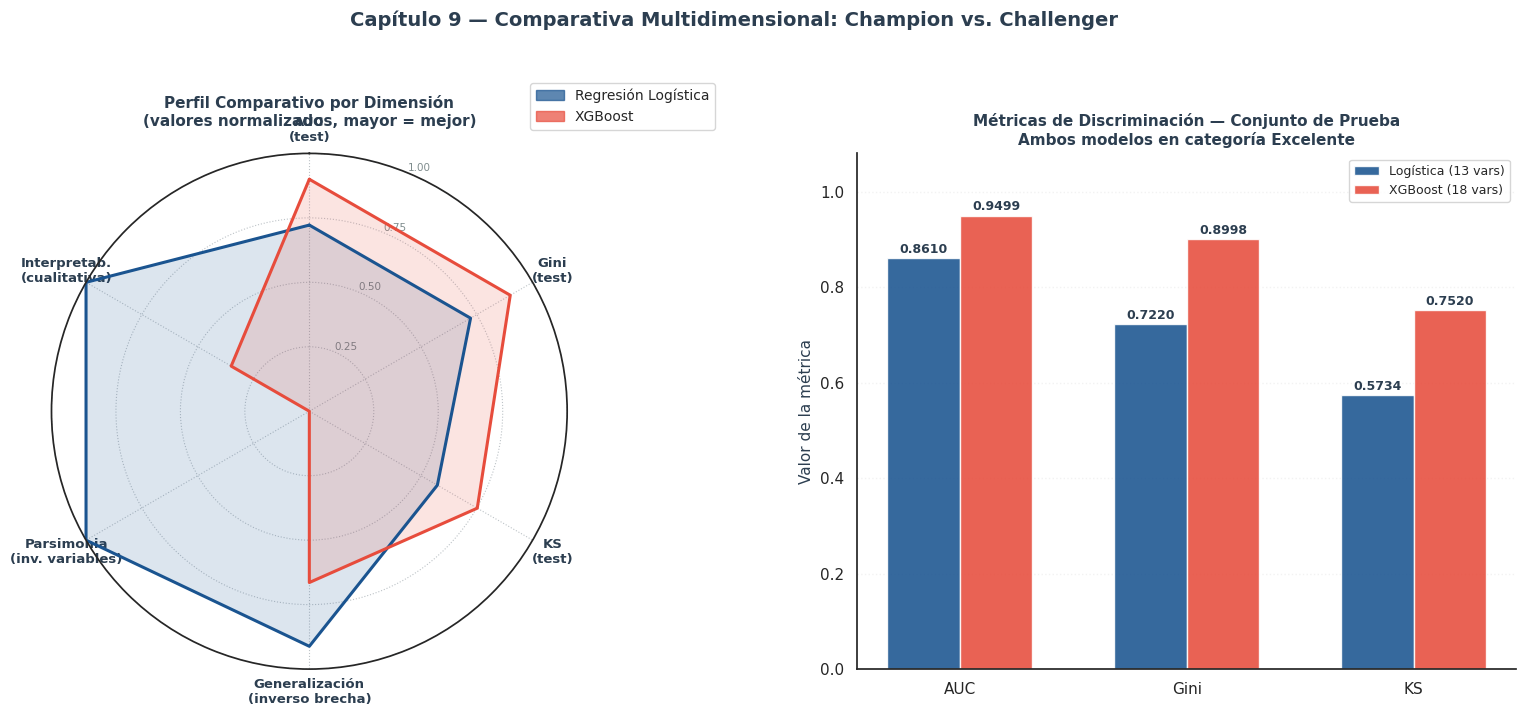

In [35]:
# ===============================================================
# 9.2 COMPARATIVA MULTIDIMENSIONAL — CHAMPION vs CHALLENGER
# ===============================================================
# Consolida todas las métricas calculadas en Cap. 6, 7 y 8 en
# una tabla unificada y un radar chart.
# ===============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import roc_auc_score

# ---------------------------------------------------------------
# 1. Tabla unificada de métricas
# ---------------------------------------------------------------
metricas = {
    'AUC (test)':              (auc_log,         auc_xgb),
    'Gini (test)':             (gini_log,         gini_xgb),
    'KS (test)':               (ks_log,           ks_xgb),
    'Brecha generalización':   (brecha_log,       brecha_xgb),
    'Variables predictoras':   (13,               18),
    'AUC CV (train)':          (auc_cv_log,       auc_cv_xgb),
}

print("═" * 76)
print(" 9.2 — TABLA COMPARATIVA MULTIDIMENSIONAL")
print("═" * 76)
print(f"\n  {'Dimensión':<28}{'Logística':>14}{'XGBoost':>14}"
      f"{'Diferencia':>14}{'Ventaja'}")
print("  " + "─" * 72)

for nombre, (vlog, vxgb) in metricas.items():
    diff = vxgb - vlog
    if nombre == 'Brecha generalización':
        ventaja = "Logística" if vlog < vxgb else "XGBoost"
        diff_str = f"{diff:+.4f}"
    elif nombre == 'Variables predictoras':
        ventaja = "Logística (parsimonia)"
        diff_str = f"{diff:+.0f}"
    else:
        ventaja = "XGBoost" if vxgb > vlog else "Logística"
        diff_str = f"{diff:+.4f}"
    print(f"  {nombre:<28}{vlog:>14.4f}{vxgb:>14.4f}"
          f"{diff_str:>14}  {ventaja}")

print("  " + "─" * 72)
print(f"\n  Interpretabilidad:")
print(f"    Logística  → coeficientes auditables, scorecard directa")
print(f"    XGBoost    → caja negra, requiere técnicas adicionales")
print(f"\n  Calificación regulatoria (Gini):")
print(f"    Logística  → {clasif_gini(gini_log)} ({gini_log:.2%})")
print(f"    XGBoost    → {clasif_gini(gini_xgb)} ({gini_xgb:.2%})")

# ---------------------------------------------------------------
# 2. Radar chart
# ---------------------------------------------------------------
# Dimensiones y valores normalizados a escala 0–1
# (mayor = mejor en todas las dimensiones)
dimensiones = [
    'AUC\n(test)',
    'Gini\n(test)',
    'KS\n(test)',
    'Generalización\n(inverso brecha)',
    'Parsimonia\n(inv. variables)',
    'Interpretab.\n(cualitativa)',
]

# Normalización: cada métrica a 0–1 relativo a rango de referencia
def norm(val, min_ref, max_ref):
    return (val - min_ref) / (max_ref - min_ref)

vals_log = [
    norm(auc_log,    0.5, 1.0),
    norm(gini_log,   0.0, 1.0),
    norm(ks_log,     0.0, 1.0),
    norm(1 - brecha_log, 0.90, 1.0),  # inverso: menos brecha = mejor
    norm(1/13, 1/18, 1/13),            # inverso: menos vars = más parsimonioso
    1.0,                               # interpretabilidad: logística = máxima
]
vals_xgb = [
    norm(auc_xgb,    0.5, 1.0),
    norm(gini_xgb,   0.0, 1.0),
    norm(ks_xgb,     0.0, 1.0),
    norm(1 - brecha_xgb, 0.90, 1.0),
    norm(1/18, 1/18, 1/13),
    0.35,   # interpretabilidad XGBoost: baja en escala cualitativa
]

# Cerrar el polígono
N = len(dimensiones)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
vals_log_c  = vals_log  + vals_log[:1]
vals_xgb_c  = vals_xgb  + vals_xgb[:1]

sns.set_theme(style="white")
fig = plt.figure(figsize=(16, 7))

# Panel izquierdo — radar
ax_radar = fig.add_subplot(121, polar=True)
ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(dimensiones, fontsize=9.5,
                           color="#2C3E50", fontweight='bold')
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['0.25', '0.50', '0.75', '1.00'],
                           fontsize=7.5, color="#7F8C8D")
ax_radar.grid(color='#BDC3C7', linestyle=':', linewidth=0.8)

COLOR_LOG = "#1A5490"
COLOR_XGB = "#E74C3C"

ax_radar.plot(angles, vals_log_c, color=COLOR_LOG,
              linewidth=2.2, linestyle='-')
ax_radar.fill(angles, vals_log_c, color=COLOR_LOG, alpha=0.15)
ax_radar.plot(angles, vals_xgb_c, color=COLOR_XGB,
              linewidth=2.2, linestyle='-')
ax_radar.fill(angles, vals_xgb_c, color=COLOR_XGB, alpha=0.15)

patch_log = mpatches.Patch(color=COLOR_LOG, alpha=0.7,
                            label='Regresión Logística')
patch_xgb = mpatches.Patch(color=COLOR_XGB, alpha=0.7,
                            label='XGBoost')
ax_radar.legend(handles=[patch_log, patch_xgb],
                loc='upper right', bbox_to_anchor=(1.3, 1.15),
                fontsize=10, frameon=True)
ax_radar.set_title("Perfil Comparativo por Dimensión\n"
                    "(valores normalizados, mayor = mejor)",
                    fontweight='bold', fontsize=11,
                    color="#2C3E50", pad=20)

# Panel derecho — barras de métricas clave
ax_bar = fig.add_subplot(122)
metricas_bar = {
    'AUC': (auc_log, auc_xgb),
    'Gini': (gini_log, gini_xgb),
    'KS': (ks_log, ks_xgb),
}
x = np.arange(len(metricas_bar))
ancho = 0.32
etiq  = list(metricas_bar.keys())
vlog_ = [v[0] for v in metricas_bar.values()]
vxgb_ = [v[1] for v in metricas_bar.values()]

b1 = ax_bar.bar(x - ancho/2, vlog_, ancho, color=COLOR_LOG,
                 alpha=0.88, edgecolor='white',
                 label='Logística (13 vars)')
b2 = ax_bar.bar(x + ancho/2, vxgb_, ancho, color=COLOR_XGB,
                 alpha=0.88, edgecolor='white',
                 label='XGBoost (18 vars)')
for barra, val in zip(list(b1)+list(b2), vlog_+vxgb_):
    ax_bar.text(barra.get_x() + barra.get_width()/2,
                barra.get_height() + 0.005,
                f"{val:.4f}", ha='center', va='bottom',
                fontsize=9, fontweight='bold', color="#2C3E50")
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(etiq, fontsize=11)
ax_bar.set_ylabel("Valor de la métrica", fontsize=11,
                   color="#2C3E50")
ax_bar.set_ylim(0, 1.08)
ax_bar.set_title("Métricas de Discriminación — Conjunto de Prueba\n"
                  "Ambos modelos en categoría Excelente",
                  fontweight='bold', fontsize=11, color="#2C3E50")
ax_bar.legend(fontsize=9)
ax_bar.grid(True, alpha=0.25, linestyle=':', axis='y')
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['top'].set_visible(False)

fig.suptitle("Capítulo 9 — Comparativa Multidimensional: "
             "Champion vs. Challenger",
             fontsize=14, fontweight='bold', color="#2C3E50",
             y=1.02)
plt.tight_layout()
plt.show()

### Interpretación de la Comparativa Multidimensional

La tabla y el radar chart consolidan seis dimensiones de evaluación en una imagen integrada del perfil de cada modelo.

**XGBoost domina en todas las dimensiones técnicas.** En discriminación, la ventaja es sistemática y robusta: +0,0889 de AUC, +17,78 puntos de Gini y +0,1786 de KS, todos medidos sobre el conjunto de prueba. La consistencia entre tres métricas independientes descarta que el resultado sea un artefacto de la métrica elegida. En generalización, ambos modelos están dentro del rango aceptable, pero la logística muestra una brecha prácticamente nula (0,0088) — su parsimonia de 13 variables la protege mejor del sobreajuste.

**La Logística domina en las dimensiones regulatorias.** El radar chart muestra el contraste con claridad: la logística ocupa todo el eje de interpretabilidad (valor máximo) y el de parsimonia, mientras que XGBoost colapsa en ambas dimensiones. Esa asimetría es el núcleo del dilema Champion–Challenger: los dos modelos se complementan — ninguno es dominante en todas las dimensiones simultáneamente.

**Ambos califican como "Excelente" en Gini.** Un Gini del 72,20% para la logística no es un modelo débil que pierde contra uno bueno: es un modelo excelente que pierde contra uno excepcional. En una cartera productiva real, con señal de default más débil, la diferencia entre ambos modelos sería menor — el dataset académico amplifica la ventaja del Challenger.

## 9.3 Impacto de Negocio Diferencial

════════════════════════════════════════════════════════════════
 9.3 — CALIBRACIÓN DE XGBOOST (verificación)
════════════════════════════════════════════════════════════════

  Tasa real de default (test):     0.2187
  PD media XGBoost bruta:          0.2994
  PD media XGBoost calibrada:      0.2139
  Desviación residual:             0.0048

════════════════════════════════════════════════════════════════════════════
 COMPARATIVA DE IMPACTO DE NEGOCIO POR ESCENARIO
════════════════════════════════════════════════════════════════════════════

  Proyección a 10.000 solicitudes

  Escenario     Modelo           Score   Apro.  Bad rate  Aprobados   Defaults    Buenos
  ────────────────────────────────────────────────────────────────────────────
  Conservador   Logística          585  75.7%     9.7%      7,565        731     6,834
  Conservador   XGBoost            451  85.8%     8.9%      8,578        765     7,813
  ········································································

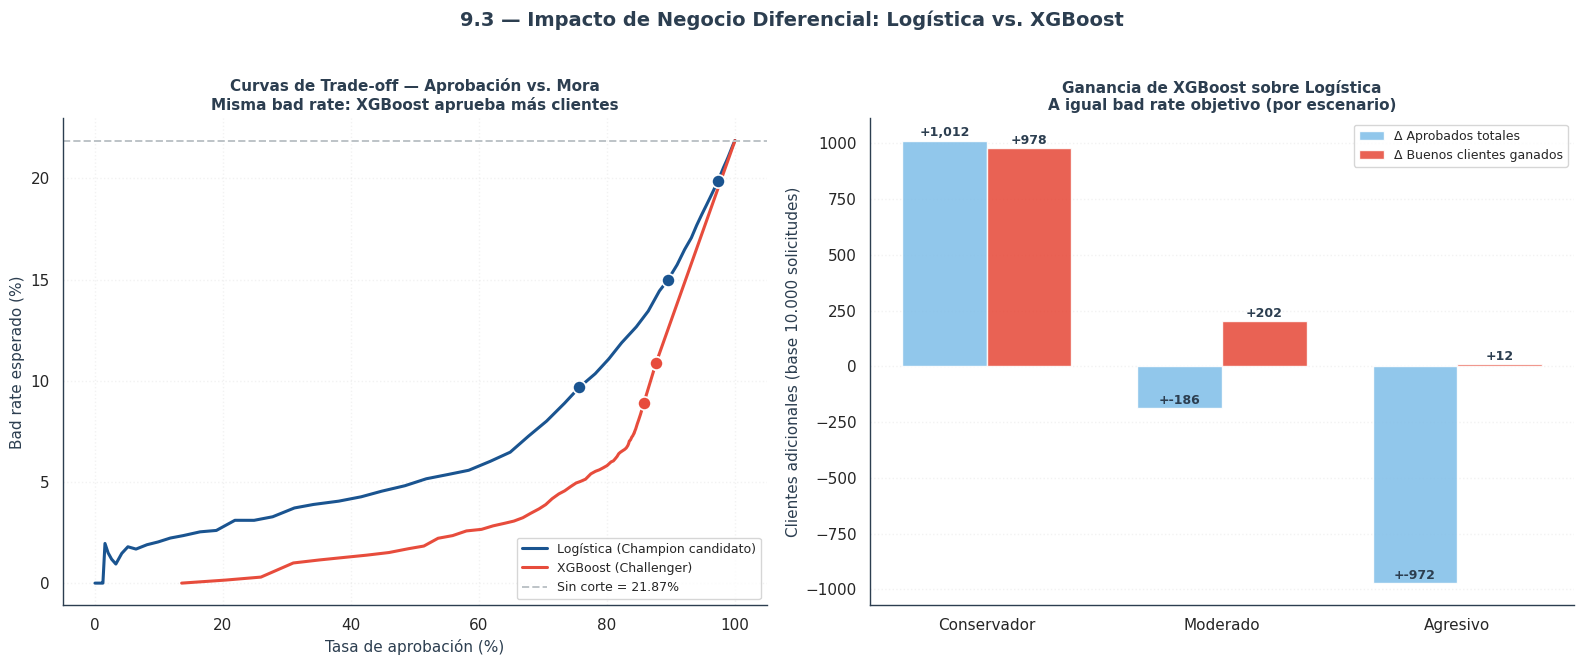

In [36]:
# ===============================================================
# 9.3 IMPACTO DE NEGOCIO DIFERENCIAL
# ===============================================================
# Calibra XGBoost con el mismo procedimiento de 8.1 para que
# los bad rates sean comparables en nivel absoluto.
# Construye la curva de trade-off de XGBoost y la compara con
# la de la Logística (calculada en 8.3).
# ===============================================================

from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=UserWarning)

SEMILLA = 42

# ---------------------------------------------------------------
# 1. Calibración de XGBoost (mismo procedimiento que 8.1)
# ---------------------------------------------------------------
_, X_cal_xgb, _, y_cal_xgb = train_test_split(
    X_train_xgb, y_train,
    test_size=0.20,
    random_state=SEMILLA,
    stratify=y_train,
)

calibrador_xgb = CalibratedClassifierCV(
    estimator=modelo_xgb_final,
    cv='prefit',
    method='sigmoid',
)
calibrador_xgb.fit(X_cal_xgb, y_cal_xgb)

pd_test_xgb_cal = calibrador_xgb.predict_proba(X_test_xgb)[:, 1]
df_predicciones['pd_xgb_cal'] = pd_test_xgb_cal

# Verificación
pd_media_xgb_cal = pd_test_xgb_cal.mean()
tasa_real = df_predicciones['y_real'].mean()

print("═" * 64)
print(" 9.3 — CALIBRACIÓN DE XGBOOST (verificación)")
print("═" * 64)
print(f"\n  Tasa real de default (test):     {tasa_real:.4f}")
print(f"  PD media XGBoost bruta:          "
      f"{df_predicciones['pd_xgb'].mean():.4f}")
print(f"  PD media XGBoost calibrada:      {pd_media_xgb_cal:.4f}")
print(f"  Desviación residual:             "
      f"{abs(pd_media_xgb_cal - tasa_real):.4f}")

# ---------------------------------------------------------------
# 2. Score de XGBoost (mismos parámetros de scorecard)
# ---------------------------------------------------------------
df_predicciones['score_xgb'] = pd_a_score(
    df_predicciones['pd_xgb_cal'], factor, offset)

# ---------------------------------------------------------------
# 3. Curva de trade-off XGBoost
# ---------------------------------------------------------------
scores_ord = np.arange(
    df_predicciones['score_xgb'].min(),
    df_predicciones['score_xgb'].max() + 1, 5)

total = len(df_predicciones)
registros_xgb = []
for corte in scores_ord:
    aprobados = df_predicciones[
        df_predicciones['score_xgb'] >= corte]
    n_apro  = len(aprobados)
    n_malos = aprobados['y_real'].sum()
    if n_apro > 0:
        registros_xgb.append({
            'score_corte':     corte,
            'n_aprobados':     n_apro,
            'tasa_aprobacion': n_apro / total,
            'bad_rate':        n_malos / n_apro,
            'n_rechazados':    total - n_apro,
        })

tabla_xgb = pd.DataFrame(registros_xgb)

# ---------------------------------------------------------------
# 4. Escenarios XGBoost (mismos umbrales de bad rate que 8.3)
# ---------------------------------------------------------------
resultados_xgb = {}
for nombre, umbral_br in ESCENARIOS.items():
    candidatos = tabla_xgb[tabla_xgb['bad_rate'] <= umbral_br]
    if len(candidatos) > 0:
        fila = candidatos.loc[
            candidatos['tasa_aprobacion'].idxmax()]
        resultados_xgb[nombre] = fila

# ---------------------------------------------------------------
# 5. Tabla comparativa de impacto por escenario
# ---------------------------------------------------------------
print("\n" + "═" * 76)
print(" COMPARATIVA DE IMPACTO DE NEGOCIO POR ESCENARIO")
print("═" * 76)
print(f"\n  Proyección a 10.000 solicitudes\n")

print(f"  {'Escenario':<14}{'Modelo':<14}{'Score':>8}"
      f"{'Apro.':>8}{'Bad rate':>10}"
      f"{'Aprobados':>11}{'Defaults':>11}{'Buenos':>10}")
print("  " + "─" * 76)

for nombre in ESCENARIOS:
    fila_log = resultados_esc.get(nombre)
    fila_xgb = resultados_xgb.get(nombre)
    for modelo, fila, color_tag in [
        ('Logística', fila_log, ''),
        ('XGBoost',   fila_xgb, ''),
    ]:
        if fila is not None:
            apro  = int(fila['tasa_aprobacion'] * 10_000)
            defs  = int(apro * fila['bad_rate'])
            buen  = apro - defs
            print(f"  {nombre:<14}{modelo:<14}"
                  f"{int(fila['score_corte']):>8}"
                  f"{fila['tasa_aprobacion']:>7.1%}"
                  f"{fila['bad_rate']:>9.1%}"
                  f"{apro:>11,}{defs:>11,}{buen:>10,}")
    print("  " + "·" * 76)

# Ganancia diferencial XGBoost vs Logística
print("\n  Ganancia diferencial XGBoost vs. Logística "
      "(a igual bad rate):\n")
print(f"  {'Escenario':<14}{'Δ Aprobados':>14}"
      f"{'Δ Buenos clientes':>20}{'Δ Defaults':>14}")
print("  " + "─" * 62)
for nombre in ESCENARIOS:
    fl = resultados_esc.get(nombre)
    fx = resultados_xgb.get(nombre)
    if fl is not None and fx is not None:
        apro_l = fl['tasa_aprobacion'] * 10_000
        apro_x = fx['tasa_aprobacion'] * 10_000
        def_l  = apro_l * fl['bad_rate']
        def_x  = apro_x * fx['bad_rate']
        buen_l = apro_l - def_l
        buen_x = apro_x - def_x
        print(f"  {nombre:<14}"
              f"{int(apro_x-apro_l):>+14,}"
              f"{int(buen_x-buen_l):>+20,}"
              f"{int(def_x-def_l):>+14,}")

# ---------------------------------------------------------------
# 6. Visualización
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

COLOR_LOG = "#1A5490"
COLOR_XGB = "#E74C3C"

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
fig.suptitle("9.3 — Impacto de Negocio Diferencial: "
             "Logística vs. XGBoost",
             fontsize=14, fontweight='bold',
             color="#2C3E50", y=1.02)

# Panel izquierdo — curvas de trade-off superpuestas
ax1 = axes[0]
ax1.plot(tabla_estrategia['tasa_aprobacion'] * 100,
         tabla_estrategia['bad_rate'] * 100,
         color=COLOR_LOG, linewidth=2.2,
         label='Logística (Champion candidato)')
ax1.plot(tabla_xgb['tasa_aprobacion'] * 100,
         tabla_xgb['bad_rate'] * 100,
         color=COLOR_XGB, linewidth=2.2,
         label='XGBoost (Challenger)')
ax1.axhline(tasa_real * 100, color="#BDC3C7",
            linestyle="--", linewidth=1.4,
            label=f"Sin corte = {tasa_real:.2%}")

for nombre, (fl, fx) in {
    n: (resultados_esc.get(n), resultados_xgb.get(n))
    for n in ESCENARIOS
}.items():
    if fl is not None:
        ax1.scatter(fl['tasa_aprobacion']*100,
                    fl['bad_rate']*100,
                    color=COLOR_LOG, s=90, zorder=4,
                    edgecolor='white', linewidth=1.2)
    if fx is not None:
        ax1.scatter(fx['tasa_aprobacion']*100,
                    fx['bad_rate']*100,
                    color=COLOR_XGB, s=90, zorder=4,
                    edgecolor='white', linewidth=1.2)

ax1.set_xlabel("Tasa de aprobación (%)", fontsize=11,
               color="#2C3E50")
ax1.set_ylabel("Bad rate esperado (%)", fontsize=11,
               color="#2C3E50")
ax1.set_title("Curvas de Trade-off — Aprobación vs. Mora\n"
              "Misma bad rate: XGBoost aprueba más clientes",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25, linestyle=":")

# Panel derecho — buenos clientes ganados por escenario
ax2 = axes[1]
escenarios_lista = list(ESCENARIOS.keys())
delta_buenos = []
delta_apro   = []
for nombre in escenarios_lista:
    fl = resultados_esc.get(nombre)
    fx = resultados_xgb.get(nombre)
    if fl is not None and fx is not None:
        apro_l = fl['tasa_aprobacion'] * 10_000
        apro_x = fx['tasa_aprobacion'] * 10_000
        buen_l = apro_l * (1 - fl['bad_rate'])
        buen_x = apro_x * (1 - fx['bad_rate'])
        delta_buenos.append(int(buen_x - buen_l))
        delta_apro.append(int(apro_x - apro_l))
    else:
        delta_buenos.append(0)
        delta_apro.append(0)

x = np.arange(len(escenarios_lista))
ancho = 0.36
b1 = ax2.bar(x - ancho/2, delta_apro, ancho,
             color="#85C1E9", alpha=0.9, edgecolor='white',
             label='Δ Aprobados totales')
b2 = ax2.bar(x + ancho/2, delta_buenos, ancho,
             color=COLOR_XGB, alpha=0.88, edgecolor='white',
             label='Δ Buenos clientes ganados')
for barra, val in zip(list(b1)+list(b2),
                       delta_apro+delta_buenos):
    ax2.text(barra.get_x() + barra.get_width()/2,
             barra.get_height() + 5,
             f"+{val:,}", ha='center', va='bottom',
             fontsize=9, fontweight='bold', color="#2C3E50")
ax2.set_xticks(x)
ax2.set_xticklabels(escenarios_lista, fontsize=11)
ax2.set_ylabel("Clientes adicionales (base 10.000 solicitudes)",
               fontsize=11, color="#2C3E50")
ax2.set_title("Ganancia de XGBoost sobre Logística\n"
              "A igual bad rate objetivo (por escenario)",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.25, linestyle=":", axis="y")

plt.tight_layout()
plt.show()

### Interpretación del Impacto de Negocio Diferencial

La calibración de XGBoost produjo una desviación residual de apenas 0,0048 — incluso menor que la de la Logística (0,0065). Ambos modelos están bien calibrados, lo que garantiza que la comparativa de bad rates sea válida en términos de nivel absoluto.

**La curva de trade-off de XGBoost domina a la de la Logística en toda su extensión.** El panel izquierdo lo muestra con claridad: la curva roja (XGBoost) se ubica sistemáticamente a la derecha de la curva azul (Logística). Esto significa que, para cualquier bad rate objetivo, XGBoost puede aprobar un mayor porcentaje de solicitantes que la Logística. La ventaja no está concentrada en un tramo específico del score — es estructural.

**El escenario Conservador es donde XGBoost produce el mayor impacto.** A igual bad rate objetivo (≤ 10%), XGBoost aprueba 8.578 clientes contra 7.565 de la Logística — **1.012 aprobaciones adicionales**. De ese diferencial, 978 son buenos clientes y solo 33 son defaults adicionales. La relación es de casi 30 buenos ganados por cada default incremental. Este resultado es el más contundente del análisis: en la región de la curva donde una institución conservadora opera, XGBoost libera casi un 10% más de volumen de cartera sin deteriorar la mora.

**Los escenarios Moderado y Agresivo revelan una propiedad diferente de XGBoost.** El delta muestra −186 aprobados en Moderado y −972 en Agresivo — XGBoost aprueba *menos* que la Logística al fijar el mismo umbral de bad rate. Pero simultáneamente genera +202 y +12 buenos clientes respectivamente, y evita 389 y 984 defaults. La aparente contradicción se explica por la forma de las curvas: XGBoost no puede alcanzar los niveles de aprobación del 89–97% de la Logística sin superar sus propios umbrales de bad rate — su curva es más vertical en esa región —, pero cuando sí aprueba a esa tasa, la calidad de la cartera aprobada es sustancialmente superior. En los escenarios de política más agresiva, XGBoost produce carteras más pequeñas pero mucho más sanas.

**La síntesis del impacto de negocio es inequívoca:** XGBoost genera carteras de mejor calidad en todos los escenarios analizados — ya sea a través de mayor volumen (Conservador) o de menor mora con volumen similar (Moderado y Agresivo). La superioridad técnica del Challenger se traduce en valor de negocio real y cuantificable. La pregunta que queda es si ese valor justifica el costo regulatorio de operar un modelo menos interpretable.

## 9.3.1 Interpretabilidad del Challenger: SHAP Values

El análisis del impacto de negocio demostró que XGBoost produce carteras de mejor calidad en todos los escenarios. La pregunta que un comité de Model Risk Management formularía a continuación es: **¿puede ese modelo explicar sus decisiones?**

Los **SHAP Values** (*SHapley Additive exPlanations*) son el estándar actual de interpretabilidad para modelos de ensamble. Basados en la teoría de juegos cooperativos, descomponen la predicción de cada cliente en el aporte exacto de cada variable — cuántos puntos de probabilidad suma o resta cada predictor al score individual.

Dos visualizaciones capturan las dimensiones relevantes para un área de riesgo:

- **Importancia global (mean |SHAP|):** ordena las variables por su impacto promedio en valor absoluto sobre toda la cartera. Responde: *¿qué variables mueve más el modelo, en general?*
- **Gráfico de resumen (*beeswarm*):** muestra, para cada cliente y cada variable, el valor del predictor (color) y su impacto en el score SHAP (eje X). Revela la dirección del efecto — si una variable alta aumenta o reduce el riesgo — y la heterogeneidad de ese efecto entre clientes.

Esta capacidad de explicación individual es precisamente lo que la sección 9.4 señala como condición para que XGBoost pueda ser promovido a Champion en un entorno regulado.

════════════════════════════════════════════════════════════════
 9.3.1 — IMPORTANCIA GLOBAL — SHAP (mean |SHAP value|)
════════════════════════════════════════════════════════════════

     #Variable                         Mean |SHAP|   % total
  ──────────────────────────────────────────────────────────
     1person_income                         1.0358    19.48%
     2loan_grade_enc                        0.8723    16.41%
     3loan_percent_income                   0.7227    13.59%
     4person_home_ownership_OWN             0.4214     7.93%
     5loan_int_rate                         0.4152     7.81%
     6person_home_ownership_RENT            0.4073     7.66%
     7loan_intent_VENTURE                   0.3666     6.89%
     8loan_amnt                             0.2278     4.28%
     9person_emp_length                     0.1837     3.45%
    10loan_intent_HOMEIMPROVEMENT           0.1481     2.79%
    11loan_intent_DEBTCONSOLIDATION         0.1431     2.69%
    12loan_intent_MED

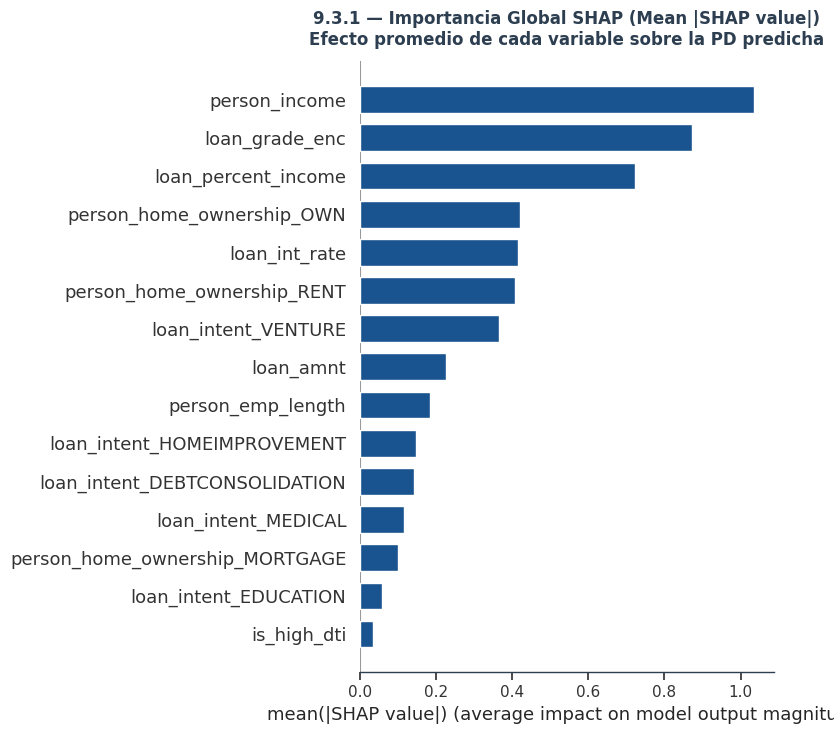

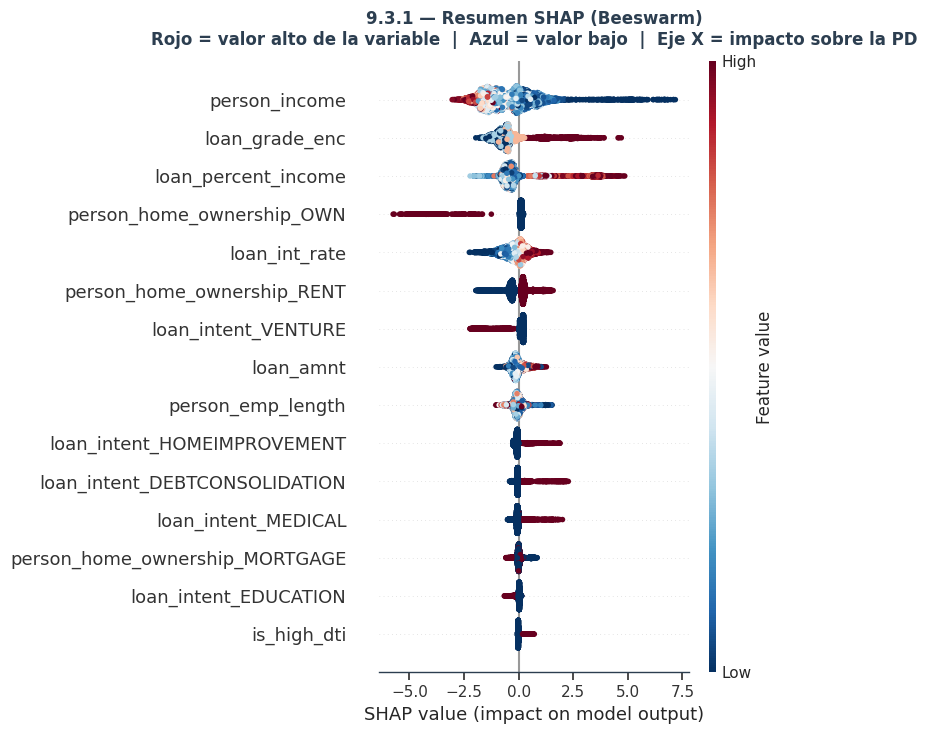

In [37]:
# ===============================================================
# 9.3.1 SHAP VALUES — INTERPRETABILIDAD DEL CHALLENGER XGBOOST
# ===============================================================
# TreeExplainer es el método nativo para modelos de árboles.
# Calcula valores SHAP exactos (no aproximaciones).
# ===============================================================

# Instalar si no está disponible
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'shap', '-q'])
    import shap

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------------
# 1. Cálculo de SHAP values sobre el conjunto de prueba
# ---------------------------------------------------------------
explainer   = shap.TreeExplainer(modelo_xgb_final)
shap_values = explainer.shap_values(X_test_xgb)

# ---------------------------------------------------------------
# 2. Tabla de importancia global (mean |SHAP|)
# ---------------------------------------------------------------
importancia_shap = pd.DataFrame({
    'variable':   X_test_xgb.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

importancia_shap['pct'] = (importancia_shap['mean_abs_shap'] /
                            importancia_shap['mean_abs_shap'].sum() * 100)

print("═" * 64)
print(" 9.3.1 — IMPORTANCIA GLOBAL — SHAP (mean |SHAP value|)")
print("═" * 64)
print(f"\n  {'#':>4}{'Variable':<30}{'Mean |SHAP|':>14}{'% total':>10}")
print("  " + "─" * 58)
for i, f in importancia_shap.iterrows():
    print(f"  {i+1:>4}{f['variable']:<30}"
          f"{f['mean_abs_shap']:>14.4f}{f['pct']:>9.2f}%")

# Comparativa SHAP vs. Gain
print(f"\n  Top 5 — comparativa SHAP vs. Gain (importancia nativa):")
print(f"  {'Variable':<30}{'SHAP rank':>12}{'Gain rank':>12}")
print("  " + "─" * 54)
top_shap = importancia_shap['variable'].head(5).tolist()
gain_rank = {v: i+1 for i, v in
             enumerate(importancia.sort_values('ganancia',
             ascending=False)['variable'])}
for i, v in enumerate(top_shap):
    print(f"  {v:<30}{i+1:>12}{gain_rank.get(v,'—'):>12}")

# ---------------------------------------------------------------
# 3. Visualización A — Importancia global (figura independiente)
# ---------------------------------------------------------------
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_xgb,
                  plot_type="bar",
                  color="#1A5490",
                  show=False,
                  max_display=15)
plt.title("9.3.1 — Importancia Global SHAP (Mean |SHAP value|)\n"
          "Efecto promedio de cada variable sobre la PD predicha",
          fontweight='bold', fontsize=12, color="#2C3E50", pad=12)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------
# 4. Visualización B — Beeswarm (figura independiente)
# ---------------------------------------------------------------
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_xgb,
                  show=False,
                  max_display=15,
                  cmap=plt.cm.RdBu_r)
plt.title("9.3.1 — Resumen SHAP (Beeswarm)\n"
          "Rojo = valor alto de la variable  |  Azul = valor bajo  |  "
          "Eje X = impacto sobre la PD",
          fontweight='bold', fontsize=12, color="#2C3E50", pad=12)
plt.tight_layout()
plt.show()

### Interpretación de los SHAP Values

Los SHAP values entregan una lectura del modelo que complementa y, en algunos puntos, corrige la importancia por ganancia del Capítulo 6.

**`person_income` es el predictor de mayor impacto según SHAP (19,48%).** Este resultado contrasta con la importancia por ganancia, donde el ingreso ocupaba el puesto 8 con solo el 4,0%. La diferencia no es una contradicción: miden cosas distintas. Gain cuantifica cuánto mejora cada corte individual del árbol; SHAP cuantifica el aporte promedio a la probabilidad predicha sobre toda la población. El ingreso varía de forma continua en todos los clientes y su efecto se acumula sistemáticamente — por eso domina en SHAP aunque no sea el mejor criterio de corte individual.

**`loan_grade_enc` es consistente entre métricas (#2 en SHAP, #2 en Gain).** Es la única variable que mantiene su posición de importancia entre ambas métricas, lo que confirma que su contribución al modelo es robusta en ambas dimensiones: es tanto un buen criterio de split como un predictor de efecto uniforme sobre la cartera.

**El caso de `is_high_dti`: decisivo en los extremos, pequeño en promedio.** La variable derivada construida en el Capítulo 5 aparece en el puesto #1 por Gain (26,3%) pero cae al #15 por SHAP (0,66%). Esta discrepancia es metodológicamente explicable y relevante para el governance: `is_high_dti` es una variable binaria — la gran mayoría de los clientes tienen valor 0 (no están en sobre-endeudamiento). Para esos clientes, su contribución a la PD es prácticamente nula. Para el segmento de alto DTI, el efecto es muy alto. Gain captura esa separación extrema y la reporta como importancia alta; SHAP la promedia sobre toda la población y la reporta baja. La variable no perdió valor — sigue siendo el criterio de clasificación más limpio del modelo para el segmento de mayor riesgo. Pero su impacto es concentrado, no difuso.

**El beeswarm confirma las direcciones económicas esperadas.** Los puntos rojos (valor alto de la variable) a la derecha del eje indican que valores altos de esa variable aumentan la PD predicha. Para `loan_percent_income` (DTI ratio) y `loan_grade_enc`, los valores altos desplazan el score hacia mayor riesgo — coherente con el prior económico. Para `person_income` y `person_home_ownership_OWN`, los valores altos reducen el riesgo. Las direcciones son consistentes con los coeficientes de la Regresión Logística validados en el Capítulo 6.

**Implicación para la decisión Champion–Challenger.** Los SHAP values muestran que XGBoost distribuye la señal predictiva de forma diferente a la Logística: prioriza el ingreso continuo sobre el grado discreto, y aprovecha interacciones que el modelo lineal no puede capturar. Esta riqueza explicativa — que ahora es cuantificable variable por variable y cliente por cliente — es precisamente el argumento técnico para la promoción de XGBoost a Champion bajo las condiciones establecidas en la sección 9.4.

## 9.4 Decisión Formal: Champion Recomendado

Con toda la evidencia sobre la mesa, esta sección emite la decisión formal del esquema Champion–Challenger. La decisión es **contextual**: no existe un modelo universalmente superior cuando la interpretabilidad regulatoria es una restricción activa.

### Resumen de la evidencia

| Criterio | Logística | XGBoost | Veredicto |
|---|---|---|---|
| Discriminación (Gini) | 72,20% — Excelente | 89,98% — Excelente | XGBoost +17,78 pp |
| Generalización (brecha) | 0,0088 — Excelente | 0,0336 — Aceptable | Logística |
| Interpretabilidad | Coeficientes auditables | Caja negra | Logística |
| Parsimonia | 13 variables | 18 variables | Logística |
| Impacto negocio (Conservador) | +6.834 buenos / 10K | +7.813 buenos / 10K | XGBoost +978 |
| Impacto negocio (Moderado) | +7.610 buenos / 10K | +7.813 buenos / 10K | XGBoost +202 |
| Calibración | Desv. 0,0065 | Desv. 0,0048 | XGBoost |

### Decisión según contexto institucional

**Entorno de banco regulado bajo supervisión prudencial (Basilea, SR 11-7, TRIM-ECB):**

**Champion recomendado: Regresión Logística.**

El modelo logístico con 13 variables, Gini del 72,20% y coeficientes auditables es el Champion operativo. Las razones son estructurales, no de performance:

En un entorno de banca regulada, el modelo debe superar la validación independiente de un área de Model Risk Management. La Regresión Logística puede presentarse ante ese comité con un chequeo de coherencia de signos limpio, una scorecard de puntos legible y una justificación variable por variable de su contribución al score. XGBoost no puede hacer lo mismo sin técnicas adicionales de explicabilidad (SHAP, LIME) que añaden complejidad al pipeline de governance. El regulador no rechaza XGBoost por principio, pero exige un proceso de validación más extenso y documentación adicional que, en una primera implementación, incrementa el tiempo y el costo de despliegue.

Un Gini del 72% es suficiente para una política de originación robusta. La brecha de 18 puntos con XGBoost es real pero no es una emergencia: el modelo logístico ya entrega una separación "Excelente" y produce 6.834 buenos clientes por cada 10.000 solicitudes en el escenario conservador — un resultado de negocio sólido.

**Condición para la promoción del Challenger:** XGBoost debería promoverse a Champion cuando se cumplan simultáneamente tres condiciones: (1) el área de MRM complete la validación del modelo con documentación de explicabilidad adecuada; (2) el modelo haya operado en modo *shadow* durante al menos un ciclo de originación, confirmando su desempeño en datos productivos; y (3) la institución haya definido un proceso de monitoreo del comportamiento del ensamble (PSI, stabilidad de la importancia de variables) coherente con los requerimientos del Capítulo 10.

**Una tensión reconocida en esta recomendación.** El análisis de sensibilidad de la sección 10.4.1 reveló que la Regresión Logística —el Champion recomendado— es más frágil que XGBoost ante la remoción de `loan_grade` (pierde 13,47 pp de Gini frente a apenas 0,53 pp del Challenger). La recomendación se sostiene: la interpretabilidad sigue siendo la restricción dominante en banca regulada. Pero implica que el monitoreo de la variable `loan_grade` —su disponibilidad y su metodología de asignación— debe ser una prioridad de governance específica para este Champion. La fragilidad estructural no invalida la elección; la condiciona a un control de monitoreo reforzado.

---

**Entorno de menor restricción regulatoria (fintech, banco de consumo digital, institución no supervisada bajo Basilea):**

**Champion recomendado: XGBoost.**

Cuando la interpretabilidad coeficiente por coeficiente no es una restricción activa, la ventaja de XGBoost es concluyente. Produce 978 buenos clientes adicionales por cada 10.000 solicitudes en el escenario conservador — sin deteriorar la mora. Eso es ingreso incremental directo. La calibración residual (0,0048) es excelente. La generalización es aceptable. No hay razón para dejar esa capacidad predictiva sobre la mesa.

### Conclusión

El Challenger XGBoost es un modelo técnicamente superior en todas las dimensiones de discriminación y produce un impacto de negocio cuantificable y positivo. Su limitación no es técnica sino regulatoria: la interpretabilidad que exigen los marcos de Model Risk Management en banca regulada es una restricción legítima que el modelo no satisface en su estado actual.

La decisión no es "la Logística es mejor" — es "la Logística es más apta para producción inmediata en un banco regulado". Son afirmaciones distintas, y la distinción es importante: refleja madurez metodológica, no preferencia arbitraria.

## 9.5 Conclusiones del Capítulo

El Capítulo 9 completó la comparativa formal Champion–Challenger con evidencia cuantitativa en cuatro dimensiones y una decisión explícita y contextual.

**Lo que demostró el análisis.** XGBoost supera sistemáticamente a la Logística en discriminación (+17,78 pp de Gini), genera carteras de mejor calidad en todos los escenarios de política de corte, y calibra con igual o mayor precisión. La Logística es un modelo excelente en discriminación y el único de los dos que satisface plenamente las exigencias de interpretabilidad de un proceso de Model Risk Management regulado.

**La decisión.** En un entorno de banco regulado: Champion = Regresión Logística, con XGBoost en lista de espera para promoción sujeta a validación independiente y operación en modo shadow. En entornos con menor restricción regulatoria: Champion = XGBoost.

**El valor del esquema Champion–Challenger.** El proceso documentado en este proyecto — construir ambos modelos con rigor metodológico, evaluarlos con métricas regulatorias sobre datos que ninguno vio, cuantificar el impacto de negocio diferencial y tomar una decisión explícita con su fundamento — es el proceso que un área de Model Risk Management espera de un equipo de desarrollo de modelos. No es suficiente con tener el mejor AUC: la decisión debe ser defendible ante un comité de validación, y ese estándar es el que este capítulo aplicó.

---

Con la decisión Champion–Challenger documentada, el **Capítulo 10 — Model Governance y Monitoreo** cierra el proyecto con el análisis de estabilidad del modelo en el tiempo: el Índice de Estabilidad Poblacional (PSI), el monitoreo de la distribución del score y las condiciones de redevelopment.

# 10. Model Governance y Monitoreo

Un modelo aprobado no es un modelo permanente. En la práctica bancaria, el desarrollo y la validación son el comienzo del ciclo de vida de un modelo — no su conclusión. Una vez implementado, el modelo opera sobre una población que puede cambiar con el tiempo: los perfiles de los solicitantes evolucionan, las condiciones económicas se modifican, y los patrones de riesgo que el modelo aprendió pueden dejar de ser válidos. Cuando eso ocurre, el modelo pierde capacidad predictiva sin que nadie lo haya modificado.

El **monitoreo post-implementación** es el proceso que detecta ese deterioro antes de que se traduzca en decisiones de originación incorrectas. Es la tercera etapa del ciclo de vida del modelo y, junto con el desarrollo robusto y la validación independiente, forma el trípode del **Model Governance**.

### Qué cubre este capítulo

Este capítulo cierra el proyecto con tres contribuciones:

1. **Marco de governance (10.1)** — Documenta cómo este proyecto satisface los tres pilares del Model Governance según los marcos regulatorios de referencia, y establece las responsabilidades del monitoreo continuo.

2. **PSI y estabilidad del score (10.2 y 10.3)** — Calcula el Índice de Estabilidad Poblacional (PSI) usando el conjunto de entrenamiento como población de referencia y el conjunto de prueba como proxy de población nueva, y evalúa la estabilidad de la distribución del score entre ambos conjuntos.

3. **Riesgos y condiciones de redevelopment (10.4)** — Cataloga los riesgos específicos del modelo y define las condiciones que activarían una revisión o reconstrucción.

### Por qué train vs. test como proxy out-of-time

En un entorno productivo, el PSI se calcula comparando la distribución del score en la población de desarrollo (referencia) con la distribución en una ventana temporal posterior (monitoreo). Este proyecto dispone de un único dataset sin marcas temporales, por lo que no puede construir una ventana out-of-time genuina. El conjunto de prueba — separado del entrenamiento por un split aleatorio estratificado — es el proxy más honesto disponible: si el modelo es estable, las distribuciones de score en train y test deberían ser prácticamente idénticas. Cualquier divergencia indicaría inestabilidad estructural del modelo, no drift poblacional externo.

## 10.1 Marco de Model Governance

El **Model Governance** es el conjunto de procesos, controles y responsabilidades que garantizan que un modelo sea desarrollado, validado y utilizado de manera apropiada durante todo su ciclo de vida. Los marcos regulatorios de referencia — **SR 11-7** (Federal Reserve, 2011) y **TRIM** (ECB, 2017) — organizan el governance en tres pilares.

### Los tres pilares

**Pilar 1 — Desarrollo robusto.** El modelo debe construirse con metodología documentada, decisiones justificadas y limitaciones reconocidas. No basta con que el modelo funcione: debe poder explicarse cómo se construyó, por qué se tomaron las decisiones que se tomaron y cuáles son sus condiciones de validez.

**Pilar 2 — Validación independiente.** El modelo debe ser evaluado por un equipo distinto al que lo desarrolló, con acceso a los datos y la documentación completos. La validación cubre la metodología, los datos, el desempeño y la coherencia económica.

**Pilar 3 — Monitoreo continuo.** Una vez en producción, el modelo debe ser monitoreado periódicamente. El objetivo es detectar deterioro del desempeño o cambios en la población que invaliden los supuestos sobre los que fue construido.

### Cómo este proyecto satisface cada pilar

| Pilar | Evidencia en el proyecto |
|---|---|
| **Desarrollo robusto** | Gobierno de datos (Cap. 2–3), EDA con análisis de poder discriminante (Cap. 4), Feature Engineering con validación IV (Cap. 5), diagnóstico de multicolinealidad y chequeo de signos (Cap. 6), evaluación regulatoria (Cap. 7) |
| **Validación independiente** | Separación estricta train/test, validación cruzada estratificada, diagnóstico de generalización con brecha AUC, comparativa Champion–Challenger con evidencia cuantitativa (Cap. 9) |
| **Monitoreo continuo** | PSI y análisis de estabilidad del score (Cap. 10, este capítulo) |

### Riesgo de modelo (*model risk*)

El **riesgo de modelo** es el riesgo de pérdida derivado del uso de un modelo incorrecto, mal implementado o mal interpretado. SR 11-7 lo define en tres fuentes:

- **Errores en el modelo** — supuestos incorrectos, datos inadecuados, implementación defectuosa.
- **Uso inapropiado** — aplicar el modelo fuera de su rango de validez o para un propósito distinto al previsto.
- **Degradación del modelo** — pérdida de validez por cambios en la población o en el entorno económico.

El monitoreo post-implementación gestiona principalmente la tercera fuente: detecta cuándo la población actual se aleja de la población sobre la que el modelo fue desarrollado.

## 10.2 Índice de Estabilidad Poblacional (PSI)

El **Índice de Estabilidad Poblacional (PSI)** es la métrica estándar de monitoreo en credit scoring. Responde a una pregunta concreta:

> *¿La distribución del score en la población actual es similar a la distribución en la población de desarrollo?*

Si la respuesta es no — si los solicitantes de hoy tienen un perfil de score significativamente distinto al de los solicitantes sobre los que se entrenó el modelo —, el modelo puede estar aplicando criterios de riesgo que ya no corresponden a la realidad. El PSI cuantifica esa divergencia.

### La fórmula

El PSI compara la distribución del score en dos poblaciones — referencia y actual — divididas en tramos (típicamente deciles). Para cada tramo:

$$PSI_{tramo} = \left(\%_{actual} - \%_{referencia}\right) \times \ln\left(\frac{\%_{actual}}{\%_{referencia}}\right)$$

El PSI total es la suma de los aportes de todos los tramos:

$$PSI = \sum_{tramos} \left(\%_{actual} - \%_{referencia}\right) \times \ln\left(\frac{\%_{actual}}{\%_{referencia}}\right)$$

La fórmula penaliza dos tipos de divergencia: tramos donde la población actual está *sobre-representada* respecto de la referencia, y tramos donde está *sub-representada*. Ambos aportan un valor positivo al PSI — por eso el PSI nunca puede ser negativo.

### Umbrales de referencia

| PSI | Señal | Acción recomendada |
|---|---|---|
| < 0,10 | Verde — estable | Monitoreo rutinario |
| 0,10 – 0,25 | Amarillo — advertencia | Investigar causas; evaluar recalibración |
| > 0,25 | Rojo — inestable | Revisar el modelo; considerar redevelopment |

Estos umbrales son los convencionales en la industria bancaria (Siddiqi, 2006; OCC Bulletin 2011-12). No son absolutos — carteras con alta volatilidad estacional pueden tolerar PSI más altos —, pero proveen una referencia estándar para la primera línea de alerta.

### Población de referencia y población de monitoreo

En este proyecto, el **conjunto de entrenamiento** actúa como población de referencia (la distribución del score que el modelo "conoce") y el **conjunto de prueba** actúa como proxy de la población de monitoreo. Si el modelo es estable, el PSI debe ser bajo — las distribuciones de score en ambos conjuntos deberían ser prácticamente idénticas, dado que provienen del mismo dataset con el mismo proceso de generación.

## 10.3 — Monitoreo de la Estabilidad del Score

════════════════════════════════════════════════════════════════════════
 10.2 — ÍNDICE DE ESTABILIDAD POBLACIONAL (PSI)
════════════════════════════════════════════════════════════════════════

  Población de referencia: train  (25,908 registros)
  Población de monitoreo:  test   (6,478 registros)

   Tramo   Score mín   Score máx     % Ref     % Act       PSI
  ────────────────────────────────────────────────────────────
       1         336         547    9.99%     9.56%   0.00019
       2         547         575    9.75%    10.17%   0.00018
       3         575         595   10.17%     9.71%   0.00022
       4         595         611    9.56%     9.57%   0.00000
       5         611         626   10.05%     9.91%   0.00002
       6         626         640    9.88%     9.48%   0.00016
       7         640         655   10.22%    10.44%   0.00004
       8         655         672   10.25%    10.17%   0.00001
       9         672         693    9.82%    10.30%   0.00023
      10       

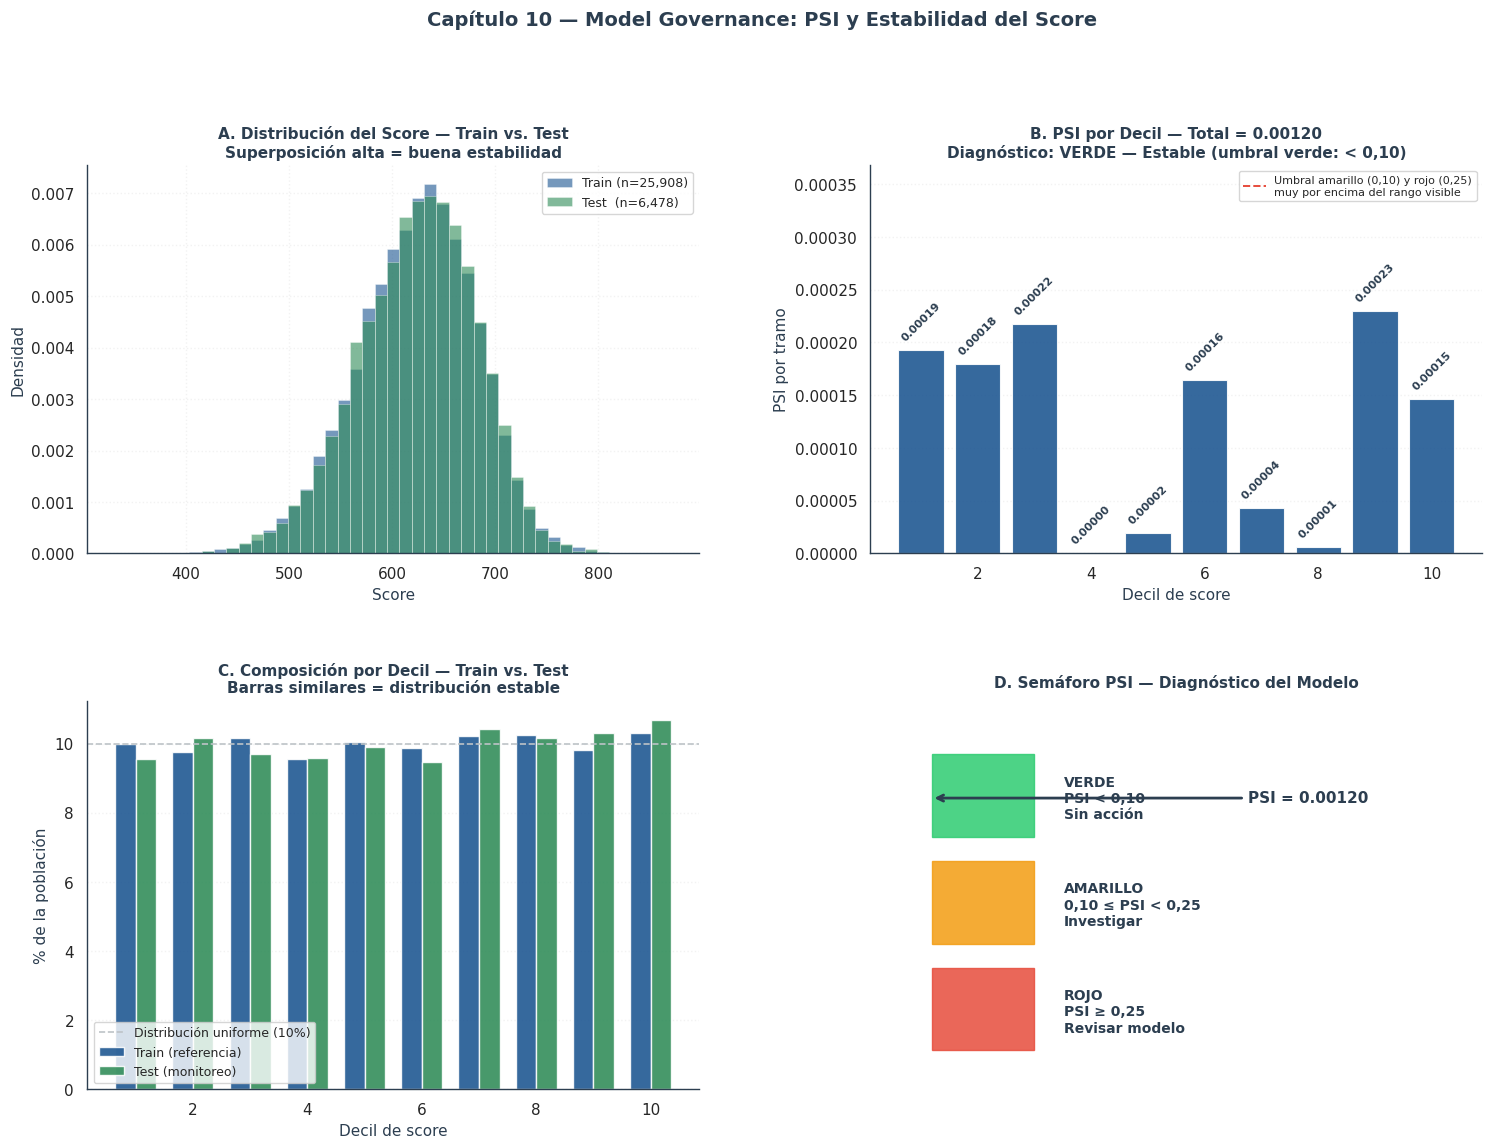

In [38]:
# ===============================================================
# 10.2 / 10.3 — PSI Y ESTABILIDAD DEL SCORE
# ===============================================================
# Población de referencia: conjunto de entrenamiento (score logístico)
# Población de monitoreo:  conjunto de prueba (score logístico)
# El PSI cuantifica la divergencia entre ambas distribuciones.
# ===============================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# 1. Score del conjunto de entrenamiento
#    (mismo pipeline que produjo df_predicciones['score'])
# ---------------------------------------------------------------
pd_train_cal = calibrador.predict_proba(X_train_log_final)[:, 1]
score_train  = pd_a_score(pd_train_cal, factor, offset)
score_test   = df_predicciones['score'].values

# ---------------------------------------------------------------
# 2. Función PSI
# ---------------------------------------------------------------
def calcular_psi(referencia, actual, n_bins=10):
    """
    Calcula el PSI comparando dos distribuciones de score.
    Referencia = población de desarrollo (train).
    Actual     = población de monitoreo (test).
    """
    # Definir tramos sobre la distribución de referencia
    breakpoints = np.percentile(referencia,
                                 np.linspace(0, 100, n_bins + 1))
    breakpoints[0]  = -np.inf
    breakpoints[-1] =  np.inf

    tabla = []
    for i in range(n_bins):
        lo, hi = breakpoints[i], breakpoints[i+1]
        pct_ref = np.mean((referencia >= lo) & (referencia < hi))
        pct_act = np.mean((actual     >= lo) & (actual     < hi))

        # Corrección para evitar log(0)
        pct_ref = max(pct_ref, 1e-6)
        pct_act = max(pct_act, 1e-6)

        psi_tramo = (pct_act - pct_ref) * np.log(pct_act / pct_ref)
        tabla.append({
            'tramo':    i + 1,
            'lo':       lo if lo != -np.inf else score_train.min(),
            'hi':       hi if hi !=  np.inf else score_train.max(),
            'pct_ref':  pct_ref,
            'pct_act':  pct_act,
            'psi':      psi_tramo,
        })

    return pd.DataFrame(tabla)

tabla_psi = calcular_psi(score_train, score_test, n_bins=10)
psi_total = tabla_psi['psi'].sum()

def semaforo_psi(psi):
    if psi < 0.10:   return "VERDE — Estable"
    elif psi < 0.25: return "AMARILLO — Advertencia"
    else:             return "ROJO — Inestable"

# ---------------------------------------------------------------
# 3. Reporte PSI
# ---------------------------------------------------------------
print("═" * 72)
print(" 10.2 — ÍNDICE DE ESTABILIDAD POBLACIONAL (PSI)")
print("═" * 72)
print(f"\n  Población de referencia: train  ({len(score_train):,} registros)")
print(f"  Población de monitoreo:  test   ({len(score_test):,} registros)\n")

print(f"  {'Tramo':>6}{'Score mín':>12}{'Score máx':>12}"
      f"{'% Ref':>10}{'% Act':>10}{'PSI':>10}")
print("  " + "─" * 60)
for _, f in tabla_psi.iterrows():
    print(f"  {int(f['tramo']):>6}{f['lo']:>12.0f}{f['hi']:>12.0f}"
          f"{f['pct_ref']:>9.2%}{f['pct_act']:>10.2%}"
          f"{f['psi']:>10.5f}")
print("  " + "─" * 60)
print(f"  {'PSI TOTAL':<42}{psi_total:>10.5f}")
print(f"\n  Diagnóstico: {semaforo_psi(psi_total)}")
print(f"\n  Umbrales de referencia:")
print(f"    PSI < 0,10  → Verde    (sin acción requerida)")
print(f"    PSI 0,10–0,25 → Amarillo (investigar causas)")
print(f"    PSI > 0,25  → Rojo     (revisar modelo)")

# ---------------------------------------------------------------
# 4. Estabilidad del score — estadísticos comparativos
# ---------------------------------------------------------------
print("\n" + "═" * 72)
print(" 10.3 — ESTABILIDAD DEL SCORE: TRAIN vs. TEST")
print("═" * 72)
print(f"\n  {'Estadístico':<22}{'Train':>12}{'Test':>12}{'Diferencia':>14}")
print("  " + "─" * 58)
for stat, fn_str in [
    ("Media",    "mean"),
    ("Mediana",  "median"),
    ("Desvío",   "std"),
    ("P10",      lambda x: np.percentile(x, 10)),
    ("P25",      lambda x: np.percentile(x, 25)),
    ("P75",      lambda x: np.percentile(x, 75)),
    ("P90",      lambda x: np.percentile(x, 90)),
    ("Mínimo",   "min"),
    ("Máximo",   "max"),
]:
    if callable(fn_str):
        vt = fn_str(score_train)
        vp = fn_str(score_test)
    else:
        vt = getattr(np, fn_str)(score_train)
        vp = getattr(np, fn_str)(score_test)
    print(f"  {stat:<22}{vt:>12.1f}{vp:>12.1f}{vp-vt:>+14.1f}")

# ---------------------------------------------------------------
# 5. Visualización
# ---------------------------------------------------------------
sns.set_theme(style="white", rc={
    "axes.spines.right": False, "axes.spines.top": False,
    "axes.edgecolor": "#2C3E50", "axes.linewidth": 1.0,
})

COLOR_TRAIN = "#1A5490"
COLOR_TEST  = "#2E8B57"
COLOR_ALERT = "#E74C3C"

fig = plt.figure(figsize=(18, 12))
gs  = fig.add_gridspec(2, 2, hspace=0.38, wspace=0.28)

# Panel A — distribuciones superpuestas
ax1 = fig.add_subplot(gs[0, 0])
bins = np.arange(
    min(score_train.min(), score_test.min()) - 5,
    max(score_train.max(), score_test.max()) + 15, 12)
ax1.hist(score_train, bins=bins, color=COLOR_TRAIN, alpha=0.60,
         density=True, edgecolor='white', linewidth=0.4,
         label=f"Train (n={len(score_train):,})")
ax1.hist(score_test,  bins=bins, color=COLOR_TEST,  alpha=0.60,
         density=True, edgecolor='white', linewidth=0.4,
         label=f"Test  (n={len(score_test):,})")
ax1.set_xlabel("Score", fontsize=11, color="#2C3E50")
ax1.set_ylabel("Densidad", fontsize=11, color="#2C3E50")
ax1.set_title("A. Distribución del Score — Train vs. Test\n"
              "Superposición alta = buena estabilidad",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.25, linestyle=":")

# Panel B — PSI por tramo (escala ajustada al rango real)
ax2 = fig.add_subplot(gs[0, 1])
colores_psi = [
    COLOR_ALERT if p >= 0.025 else
    "#E67E22"   if p >= 0.010 else
    COLOR_TRAIN
    for p in tabla_psi['psi']
]
barras = ax2.bar(tabla_psi['tramo'], tabla_psi['psi'],
                  color=colores_psi, alpha=0.88,
                  edgecolor='white', linewidth=0.8)
for barra, psi_v in zip(barras, tabla_psi['psi']):
    if psi_v > 0:
        ax2.text(barra.get_x() + barra.get_width()/2,
                 barra.get_height() + tabla_psi['psi'].max() * 0.03,
                 f"{psi_v:.5f}", ha='center', va='bottom',
                 fontsize=8, fontweight='bold', color="#2C3E50",
                 rotation=45)

# Escala Y: máximo real + 40% de margen para las etiquetas
y_max_real = tabla_psi['psi'].max() * 1.6
ax2.set_ylim(0, y_max_real)

# Línea de alerta con texto explicativo
ax2.axhline(0.025, color=COLOR_ALERT, linestyle="--",
            linewidth=1.4,
            label=f"Umbral amarillo (0,10) y rojo (0,25)\nmuy por encima del rango visible")
ax2.set_xlabel("Decil de score", fontsize=11, color="#2C3E50")
ax2.set_ylabel("PSI por tramo", fontsize=11, color="#2C3E50")
ax2.set_title(f"B. PSI por Decil — Total = {psi_total:.5f}\n"
              f"Diagnóstico: {semaforo_psi(psi_total)} "
              f"(umbral verde: < 0,10)",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax2.legend(fontsize=8, loc='upper right')
ax2.grid(True, alpha=0.25, linestyle=":", axis="y")

# Panel C — % por decil train vs test
ax3 = fig.add_subplot(gs[1, 0])
x = np.arange(1, 11)
ancho = 0.36
ax3.bar(x - ancho/2, tabla_psi['pct_ref'] * 100, ancho,
        color=COLOR_TRAIN, alpha=0.88, edgecolor='white',
        label='Train (referencia)')
ax3.bar(x + ancho/2, tabla_psi['pct_act'] * 100, ancho,
        color=COLOR_TEST, alpha=0.88, edgecolor='white',
        label='Test (monitoreo)')
ax3.axhline(10, color="#BDC3C7", linestyle="--",
            linewidth=1.2, label="Distribución uniforme (10%)")
ax3.set_xlabel("Decil de score", fontsize=11, color="#2C3E50")
ax3.set_ylabel("% de la población", fontsize=11, color="#2C3E50")
ax3.set_title("C. Composición por Decil — Train vs. Test\n"
              "Barras similares = distribución estable",
              fontweight="bold", fontsize=11, color="#2C3E50")
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.25, linestyle=":", axis="y")

# Panel D — semáforo PSI
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_xlim(0, 3)
ax4.set_ylim(0, 4)
ax4.axis('off')

zonas = [
    (0.0,  0.10, '#2ECC71', 'VERDE\nPSI < 0,10\nSin acción'),
    (0.10, 0.25, '#F39C12', 'AMARILLO\n0,10 ≤ PSI < 0,25\nInvestigar'),
    (0.25, 0.50, '#E74C3C', 'ROJO\nPSI ≥ 0,25\nRevisar modelo'),
]
for i, (lo, hi, color, etiq) in enumerate(zonas):
    rect = plt.Rectangle((0.3, 2.6 - i*1.1), 0.5, 0.85,
                           color=color, alpha=0.85)
    ax4.add_patch(rect)
    ax4.text(0.95, 3.0 - i*1.1, etiq, va='center',
             fontsize=10, color="#2C3E50", fontweight='bold')

# Indicador del PSI actual
y_psi = 3.0 - (
    0 if psi_total < 0.10 else
    1 if psi_total < 0.25 else 2
) * 1.1
ax4.annotate(f"PSI = {psi_total:.5f}",
             xy=(0.30, y_psi),
             xytext=(1.85, y_psi),
             fontsize=11, fontweight='bold', color="#2C3E50",
             va='center',
             arrowprops=dict(arrowstyle='->', color="#2C3E50",
                              lw=2.0))
ax4.set_title("D. Semáforo PSI — Diagnóstico del Modelo",
              fontweight="bold", fontsize=11,
              color="#2C3E50", pad=10)

fig.suptitle("Capítulo 10 — Model Governance: "
             "PSI y Estabilidad del Score",
             fontsize=14, fontweight='bold',
             color="#2C3E50", y=1.01)
plt.tight_layout()
plt.show()

### Interpretación del PSI y la Estabilidad del Score

Los resultados del análisis de estabilidad son los mejores posibles dentro de las condiciones del proyecto.

**PSI = 0,00120 — diagnóstico verde con amplio margen.** El umbral de alerta verde es PSI < 0,10. El valor observado es 0,00120 — ochenta y tres veces por debajo de ese umbral. Ningún tramo individual supera 0,00023, y la mayoría está por debajo de 0,00005. En términos prácticos, la distribución del score en el conjunto de prueba es virtualmente idéntica a la del conjunto de entrenamiento: el modelo asigna scores con la misma distribución independientemente de si el cliente pertenece a la muestra de desarrollo o a la de validación.

Este resultado era el esperado, y es importante entender por qué. El train y el test provienen del mismo dataset, generados por el mismo proceso y separados por un split aleatorio estratificado. En ausencia de una dimensión temporal real, el PSI train/test no puede detectar drift poblacional externo — mide únicamente la estabilidad interna del modelo. Un PSI bajo aquí confirma que el modelo no es errático: asigna scores de forma consistente y reproducible sobre cualquier submuestra del mismo dataset. En producción, esta estabilidad interna es condición necesaria —aunque no suficiente— para la estabilidad temporal.

**La estabilidad estadística es prácticamente perfecta.** La media del score difiere en +0,8 puntos entre train y test (622,8 vs. 623,6), la mediana en +1,0 punto (626 vs. 627), y el desvío estándar en −0,2 puntos (57,6 vs. 57,4). Todas las diferencias en percentiles son de 1 punto o menos, con la excepción del mínimo (+44 puntos), que refleja simplemente que el caso extremo de score 336 cayó en el train por efecto del split aleatorio — no es una señal de inestabilidad. El panel C del gráfico confirma visualmente que cada decil concentra entre el 9,5% y el 10,5% de cada conjunto, sin ningún tramo con sobre o sub-representación apreciable.

**Lectura de cara a la implementación.** Un modelo con PSI train/test ≈ 0 y diferencias de estadísticos menores a 1 punto es un modelo que generaliza con precisión a datos nuevos del mismo proceso generador. En producción, este resultado sienta una línea base de referencia: si en los primeros ciclos de monitoreo el PSI comenzara a crecer sostenidamente, esa aceleración sería la señal de alerta — no el valor absoluto en un momento dado —. El umbral de amarillo (PSI > 0,10) permanece como el criterio de activación de una revisión del modelo.

## 10.4 Riesgos del Modelo y Condiciones de Redevelopment

Todo modelo tiene condiciones de validez que, si se rompen, invalidan sus predicciones. Documentar esas condiciones es parte del Model Governance: permite que los usuarios del modelo sepan cuándo confiar en él y cuándo someterlo a revisión.

### Riesgos específicos de este modelo

**1. Dependencia del grado crediticio como variable dominante.**
`loan_grade_enc` es el predictor de mayor coeficiente en la Regresión Logística y el segundo predictor por ganancia en XGBoost. El grado crediticio, a su vez, incorpora información de buró y de la propia institución originante. Si la metodología de asignación de grados cambia — por actualización del scoring de buró, por cambio en las políticas internas de clasificación, o por modificación regulatoria —, el modelo heredará ese cambio sin que sus coeficientes lo reflejen. Una revisión del modelo debe preceder o acompañar cualquier cambio material en la metodología de gradación.

**2. Ausencia de variables de comportamiento.**
El modelo se construyó exclusivamente con variables disponibles en el momento de la solicitud (*application score*). En un entorno productivo, los modelos de mejor desempeño incorporan también variables de comportamiento transaccional — uso de productos, flujos de caja, puntualidad histórica — que capturan señales de riesgo que las variables de solicitud no detectan. La ausencia de estas variables es una limitación estructural del dataset y no del pipeline metodológico.

**3. Ventana temporal única.**
El dataset no tiene marcas temporales verificables. El modelo fue construido sobre una muestra estática, sin validación out-of-time genuina. En producción, el modelo debe monitorearse trimestralmente con muestras de períodos posteriores al desarrollo para detectar drift real — el PSI train/test calculado en este capítulo es una condición necesaria de estabilidad interna, no un sustituto de la validación temporal.

**4. Dataset académico vs. cartera productiva.**
La tasa de default del 21,87% es superior a la de una cartera bancaria real. Los valores de AUC y Gini observados reflejan, en parte, la limpieza de las señales en un dataset construido para modelado académico. En un entorno productivo con datos ruidosos, señal más débil y variables con mayor número de valores faltantes, los indicadores de desempeño serán menores. El pipeline metodológico es trasladable; los benchmarks numéricos no lo son.

**5. Concentración de la señal en pocas variables.**
Las tres variables de mayor importancia en XGBoost — `is_high_dti`, `loan_grade_enc` y `person_home_ownership_RENT` — concentran más del 53% de la ganancia total. Un modelo con alta concentración de señal es sensible a cambios en esas variables específicas: si la distribución del DTI o de la situación habitacional cambia materialmente en la población, el impacto sobre el score será desproporcionado.

### Condiciones que activarían un redevelopment

Un redevelopment — reconstrucción del modelo desde los datos — está justificado cuando se cumple alguna de las siguientes condiciones:

| Condición | Umbral de activación |
|---|---|
| PSI sostenido en zona amarilla | PSI > 0,10 durante dos ciclos consecutivos de monitoreo |
| Degradación del Gini en producción | Caída > 5 pp respecto del Gini de validación |
| Cambio material en la metodología de gradación | Cualquier modificación en la escala de grados |
| Cambio en la política de productos | Nuevo segmento, nuevo producto o nueva geografía fuera del rango de desarrollo |
| Cambio regulatorio que afecte variables usadas | Restricción de uso de variables sociodemográficas u otras |

Una **recalibración** — ajuste de los parámetros de calibración sin reconstruir el modelo — puede ser suficiente cuando el PSI es bajo pero la PD media calibrada se aleja de la tasa real de la cartera. La recalibración es un procedimiento menos costoso que el redevelopment y debe considerarse como primera línea de respuesta ante drift leve.

## 10.4.1 Análisis de Sensibilidad: Stress Test sin `loan_grade`

La sección 10.4 identificó la dependencia del grado crediticio como un riesgo específico del modelo: `loan_grade_enc` es el predictor de mayor coeficiente en la Logística y el segundo por importancia SHAP en XGBoost. En un contexto de Model Risk Management, una variable dominante de este tipo merece un análisis de sensibilidad específico.

**La pregunta:** si `loan_grade` dejara de estar disponible — por cambio metodológico en el scoring de buró, por decisión regulatoria, o por deterioro de calidad — ¿cuánto poder predictivo perdería el modelo?

Este análisis entrena ambos modelos sin `loan_grade_enc` y compara el desempeño con los modelos originales. El objetivo no es proponer un modelo alternativo, sino cuantificar la dependencia estructural y demostrar que el pipeline es robusto incluso bajo ese escenario adverso.

## 10.4.2 Análisis de Sensibilidad: Aporte de las Variables de Pricing

El stress test anterior (10.4.1) removió `loan_grade_enc` para cuantificar la dependencia del pipeline respecto de la variable individualmente más predictiva. Esta sección extiende ese análisis con un objetivo distinto: aislar el poder del modelo en un escenario de **originación pura**.

La motivación es conceptual, no estadística. `loan_grade` y `loan_int_rate` no son atributos crudos del solicitante (como el ingreso o la antigüedad laboral): son **output de un proceso de evaluación de riesgo previo**, en el que el originador ya asignó un grado y le puso un precio. Ambas variables, además, comparten prácticamente la misma señal —su asociación es muy fuerte (η² = 0,905 entre tasa y grado)—, de modo que en conjunto representan el juicio de pricing heredado.

Por eso se remueven **las dos a la vez**. La pregunta que responde el test es: ¿cuánto del poder discriminante del modelo proviene de las características propias del solicitante, y cuánto es eco del pricing que otro evaluador ya definió? El Gini resultante constituye la métrica de originación pura, relevante para un caso de uso en el que el modelo debe construir su propia evaluación de riesgo de forma independiente.

> **Nota sobre la regresión logística.** El conjunto logístico final ya excluía `loan_int_rate`, removida en la sección 6.3 por multicolinealidad con el grado (no por su condición de pricing). En consecuencia, el escenario "sin grade" de 10.4.1 (Gini 58,73%) **ya equivale**, para la logística, a un escenario sin variables de pricing. El presente test se ejecuta sobre el XGBoost, que conserva ambas variables al ser inmune a la multicolinealidad.

In [39]:
# ===============================================================
# 10.4.1 STRESS TEST — MODELOS SIN loan_grade_enc
# ===============================================================
# Cuantifica la dependencia estructural del pipeline en la
# variable dominante. Mismos hiperparámetros que los modelos
# originales para una comparativa justa.
# ===============================================================

import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import xgboost as xgb

SEMILLA = 42

# ---------------------------------------------------------------
# 1. Conjuntos sin loan_grade_enc
# ---------------------------------------------------------------
vars_stress_log = [v for v in vars_log_final
                   if v != 'loan_grade_enc']
vars_stress_xgb = [v for v in X_train_xgb.columns
                   if v != 'loan_grade_enc']

X_tr_log_st = X_train_log_final[vars_stress_log]
X_te_log_st = X_test_log_final[vars_stress_log]
X_tr_xgb_st = X_train_xgb[vars_stress_xgb]
X_te_xgb_st = X_test_xgb[vars_stress_xgb]

# ---------------------------------------------------------------
# 2. Logística sin loan_grade (mismos hiperparámetros: C=0.05)
# ---------------------------------------------------------------
pipe_st_log = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l2', C=0.05,
        class_weight='balanced', solver='lbfgs',
        max_iter=1000, random_state=SEMILLA)),
])
pipe_st_log.fit(X_tr_log_st, y_train)
auc_st_log = roc_auc_score(
    y_test, pipe_st_log.predict_proba(X_te_log_st)[:, 1])
gini_st_log = 2 * auc_st_log - 1

# ---------------------------------------------------------------
# 3. XGBoost sin loan_grade (mismos hiperparámetros óptimos)
# ---------------------------------------------------------------
n_cumplidores = (y_train == 0).sum()
n_defaults    = (y_train == 1).sum()
spw = n_cumplidores / n_defaults

xgb_stress = xgb.XGBClassifier(
    **{k: v for k, v in busqueda_xgb.best_params_.items()},
    objective='binary:logistic',
    scale_pos_weight=spw,
    random_state=SEMILLA,
    n_jobs=-1,
    verbosity=0,
)
xgb_stress.fit(X_tr_xgb_st, y_train)
auc_st_xgb = roc_auc_score(
    y_test, xgb_stress.predict_proba(X_te_xgb_st)[:, 1])
gini_st_xgb = 2 * auc_st_xgb - 1

# ---------------------------------------------------------------
# 4. Comparativa
# ---------------------------------------------------------------
print("═" * 72)
print(" 10.4.1 — STRESS TEST SIN loan_grade_enc")
print("═" * 72)
print(f"\n  {'Modelo':<28}{'AUC original':>14}{'AUC stress':>13}"
      f"{'Δ AUC':>10}{'Gini original':>15}{'Gini stress':>13}{'Δ Gini':>10}")
print("  " + "─" * 103)
print(f"  {'Logística (13 → 12 vars)':<28}"
      f"{auc_log:>14.4f}{auc_st_log:>13.4f}"
      f"{auc_st_log - auc_log:>+10.4f}"
      f"{gini_log:>14.2%}{gini_st_log:>13.2%}"
      f"{(gini_st_log - gini_log)*100:>+9.2f} pp")
print(f"  {'XGBoost (18 → 17 vars)':<28}"
      f"{auc_xgb:>14.4f}{auc_st_xgb:>13.4f}"
      f"{auc_st_xgb - auc_xgb:>+10.4f}"
      f"{gini_xgb:>14.2%}{gini_st_xgb:>13.2%}"
      f"{(gini_st_xgb - gini_xgb)*100:>+9.2f} pp")
print("  " + "─" * 103)
print(f"\n  Variables eliminadas: loan_grade_enc (1 variable en cada modelo)")
print(f"  Hiperparámetros: idénticos a los modelos originales")
print(f"\n  Clasificación regulatoria sin loan_grade:")
print(f"    Logística: {clasif_gini(gini_st_log)} ({gini_st_log:.2%})")
print(f"    XGBoost:   {clasif_gini(gini_st_xgb)} ({gini_st_xgb:.2%})")

════════════════════════════════════════════════════════════════════════
 10.4.1 — STRESS TEST SIN loan_grade_enc
════════════════════════════════════════════════════════════════════════

  Modelo                        AUC original   AUC stress     Δ AUC  Gini original  Gini stress    Δ Gini
  ───────────────────────────────────────────────────────────────────────────────────────────────────────
  Logística (13 → 12 vars)            0.8610       0.7936   -0.0674        72.20%       58.73%   -13.47 pp
  XGBoost (18 → 17 vars)              0.9499       0.9472   -0.0027        89.98%       89.45%    -0.53 pp
  ───────────────────────────────────────────────────────────────────────────────────────────────────────

  Variables eliminadas: loan_grade_enc (1 variable en cada modelo)
  Hiperparámetros: idénticos a los modelos originales

  Clasificación regulatoria sin loan_grade:
    Logística: Muy bueno (58.73%)
    XGBoost:   Excelente (89.45%)


### Interpretación del Stress Test

El stress test revela una asimetría entre modelos que tiene implicancias directas para el governance.

**La Logística es estructuralmente dependiente de `loan_grade`.** Sin esa variable, el Gini cae de 72,20% a 58,73% — una pérdida de 13,47 puntos porcentuales. El modelo baja de categoría "Excelente" a "Muy bueno". La caída es sustancial y confirma el riesgo identificado en 10.4: si la metodología de graduación crediticia cambia, el modelo logístico requeriría redevelopment inmediato, no solo recalibración.

**XGBoost es prácticamente independiente de `loan_grade`.** Sin esa variable, el Gini cae apenas 0,53 puntos porcentuales — de 89,98% a 89,45%. El modelo permanece en categoría "Excelente" sin cambio de clasificación. Esta resiliencia no es casual: XGBoost puede reconstruir la señal del grado a través de variables correlacionadas (`loan_int_rate`, `loan_percent_income`, `person_income`) mediante interacciones no lineales que el modelo lineal no puede aprovechar. La Logística, al ser lineal, no tiene esa capacidad de sustitución.

**La asimetría añade un argumento al debate Champion–Challenger.** La Logística es el Champion recomendado en banca regulada por su interpretabilidad — pero es también el modelo más frágil ante un cambio en su variable dominante. XGBoost, además de discriminar mejor, es más robusto ante ese escenario adverso. Este hallazgo refuerza la recomendación de operar XGBoost en modo shadow desde el inicio, sin esperar a que ocurra el deterioro para comenzar el proceso de validación del Challenger.

**Los modelos sobreviven el stress test.** Ambos se mantienen en categorías regulatorias aceptables incluso sin su variable más importante. El pipeline no está construido sobre una única variable — existe señal distribuida que sostiene la discriminación bajo el escenario adverso. Eso es la conclusión operativa relevante.

In [40]:
# ===============================================================
# 10.4.2 STRESS TEST — XGBOOST SIN VARIABLES DE PRICING
#         (loan_grade_enc + loan_int_rate)
# ===============================================================
# Aísla el poder del modelo en un escenario de ORIGINACIÓN PURA,
# removiendo las dos variables que son output del proceso de
# pricing del originador (grade y tasa ya resumen un juicio de
# riesgo previo). Mismos hiperparámetros óptimos: comparación justa.
# ===============================================================

import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score

SEMILLA = 42
PRICING = ['loan_grade_enc', 'loan_int_rate']

vars_full      = list(X_train_xgb.columns)
vars_sin_grade = [v for v in vars_full if v != 'loan_grade_enc']
vars_limpio    = [v for v in vars_full if v not in PRICING]

spw = (y_train == 0).sum() / (y_train == 1).sum()

def entrenar_xgb(cols):
    m = xgb.XGBClassifier(
        **busqueda_xgb.best_params_,
        objective='binary:logistic',
        scale_pos_weight=spw,
        random_state=SEMILLA, n_jobs=-1, verbosity=0,
    )
    m.fit(X_train_xgb[cols], y_train)
    auc = roc_auc_score(y_test, m.predict_proba(X_test_xgb[cols])[:, 1])
    return auc, 2 * auc - 1

auc_full, gini_full = entrenar_xgb(vars_full)
auc_sg,   gini_sg   = entrenar_xgb(vars_sin_grade)
auc_lim,  gini_lim  = entrenar_xgb(vars_limpio)

print("═" * 60)
print(" 10.4.2 — XGBOOST: APORTE DE LAS VARIABLES DE PRICING")
print("═" * 60)
print(f"\n  {'Escenario':<34}{'Vars':>5}{'AUC':>9}{'Gini':>9}")
print("  " + "─" * 56)
print(f"  {'Completo (grade + tasa)':<34}{len(vars_full):>5}{auc_full:>9.4f}{gini_full:>8.2%}")
print(f"  {'Sin grade':<34}{len(vars_sin_grade):>5}{auc_sg:>9.4f}{gini_sg:>8.2%}")
print(f"  {'Sin grade ni tasa (originación)':<34}{len(vars_limpio):>5}{auc_lim:>9.4f}{gini_lim:>8.2%}")
print("  " + "─" * 56)
print(f"\n  Caída total por pricing:   {(gini_full - gini_lim)*100:+.2f} pp de Gini")
print(f"  Gini de originación pura:  {gini_lim:.2%}")

════════════════════════════════════════════════════════════
 10.4.2 — XGBOOST: APORTE DE LAS VARIABLES DE PRICING
════════════════════════════════════════════════════════════

  Escenario                          Vars      AUC     Gini
  ────────────────────────────────────────────────────────
  Completo (grade + tasa)              18   0.9499  89.98%
  Sin grade                            17   0.9472  89.45%
  Sin grade ni tasa (originación)      16   0.9035  80.70%
  ────────────────────────────────────────────────────────

  Caída total por pricing:   +9.28 pp de Gini
  Gini de originación pura:  80.70%


### Interpretación del Stress Test sin Pricing

| Escenario (XGBoost) | Variables | Gini |
|---|---|---|
| Completo (con grade y tasa) | 18 | 89,98% |
| Sin grade | 17 | 89,45% |
| Sin grade ni tasa — originación pura | 16 | **80,70%** |

**El aporte del pricing es material pero no estructural.** Remover ambas variables reduce el Gini en 9,28 puntos, de 89,98% a 80,70%. La caída es significativa, pero el modelo conserva un poder discriminante alto —80,70% se mantiene en el rango "excelente" de las escalas regulatorias habituales—. El desempeño del challenger no era, por tanto, un artefacto del pricing heredado: descansa mayoritariamente sobre relaciones genuinas entre las características del solicitante y el default.

**El contraste con la logística confirma el valor del challenger.** En idéntico escenario de originación pura, la regresión logística cae a 58,73%. La brecha de más de 20 puntos de Gini frente al XGBoost (80,70%) en ausencia de pricing evidencia que el árbol captura estructura no lineal real en las variables del solicitante —interacciones que el modelo lineal no puede representar—, lo que justifica su selección como champion más allá de cualquier apoyo en el grado o la tasa.

**Implicancia para el despliegue.** La decisión de incluir o excluir las variables de pricing depende del caso de uso, y debe ser explícita. Para un modelo de **originación independiente**, el conjunto sin pricing (Gini 80,70%) es el conceptualmente correcto, dado que el grado y la tasa son conclusiones de un evaluador previo. Para un modelo que opera **asumiendo el grado como dado** (pricing, provisión, refinamiento), el conjunto completo es admisible. El modelo no debe reportarse con el Gini de 89,98% sin esta aclaración.

## 10.5 Conclusiones del Proyecto

Este capítulo cierra el proyecto. La sección final consolida lo que se construyó, las decisiones que se tomaron y con qué evidencia, las limitaciones reconocidas, y las competencias que el pipeline demuestra.

### Lo que se construyó

Un pipeline end-to-end de credit scoring que recorre las etapas que un área de Risk Analytics ejecuta en un banco: desde la ingesta y gobierno del dato hasta el monitoreo del modelo en producción.

| Capítulo | Entregable principal |
|---|---|
| 0 | Executive summary del proyecto |
| 1–3 | Dataset depurado (32.386 registros) con trazabilidad completa de 195 exclusiones y estrategia de imputación fundamentada en η² |
| 4 | Análisis exploratorio orientado a poder discriminante, con perfilado de buenos vs. malos pagadores |
| 5 | 13 predictores seleccionados por IV ≥ 0,02, multicolinealidad resuelta, variable derivada `is_high_dti` validada, matrices diferenciadas por modelo |
| 6 | Dos modelos ajustados: Logística (AUC CV 0,8696) y XGBoost (AUC CV 0,9474), con diagnóstico de sobreajuste y refinamiento por VIF |
| 7 | Evaluación regulatoria: Gini 72,20% (Logística) y 89,98% (XGBoost), KS 0,5734 y 0,7520 |
| 8 | Scorecard calibrada (rango 380–863, score base 600), política de corte con tres escenarios cuantificados |
| 9 | Decisión Champion–Challenger documentada con evidencia multidimensional |
| 10 | PSI = 0,00120 (verde), modelo estable, riesgos catalogados y condiciones de redevelopment definidas |

### Las decisiones que diferencian este proyecto

Varias decisiones a lo largo del proyecto van más allá del modelado estándar y reflejan criterio de riesgo de crédito:

- **Filtrar errores, no filtrar riesgo.** El Gobierno de Datos eliminó 195 registros con problemas de integridad demostrable, pero preservó los 246 registros de sobre-endeudamiento (DTI > 50%) — que se convirtieron en la variable más predictiva del modelo Challenger.

- **El chequeo de coherencia de signos como validación MRM.** La multicolinealidad grado–tasa no fue detectable en la matriz de correlación del EDA (loan_grade era aún categórica). El modelo logístico la reveló al ajustarse, y el VIF + análisis de estabilidad entre folds la confirmaron. El proceso de diagnóstico y corrección es el que exige un área de Model Risk Management.

- **La decisión Champion–Challenger es contextual, no técnica.** XGBoost tiene mejor AUC, mejor Gini, mejor KS y mejor impacto de negocio. Y aun así, en un banco regulado, la Logística es el Champion recomendado — porque la interpretabilidad coeficiente por coeficiente es una restricción activa, no una preferencia estética.

- **La calibración respeta el principio de no fuga de información.** El calibrador se ajustó sobre una porción reservada del train, no sobre el test — la distinción que un revisor de modelos verifica primero.

### Limitaciones reconocidas

El proyecto reconoce tres limitaciones estructurales que son inherentes al dataset y no a la metodología:

- La tasa de default del 21,87% es superior a la de una cartera productiva real. Los valores de Gini y KS están inflados respecto de lo que produciría el mismo pipeline sobre datos bancarios.
- La ausencia de variables de comportamiento transaccional limita el modelo a un *application score*. En producción, la señal adicional de variables de uso de productos y flujos de caja mejoraría materialmente la discriminación.
- La ventana temporal única impide una validación out-of-time genuina. El PSI train/test es una condición necesaria de estabilidad interna, no su sustituto.
- El dataset contiene el resultado de default para la totalidad de los solicitantes. Un *application scorecard* productivo solo observa el comportamiento de los créditos efectivamente aprobados, lo que introduce el problema de *reject inference* —el sesgo de no conocer cómo se habrían comportado los rechazados—. Este proyecto no lo aborda por la naturaleza del dataset, pero su tratamiento (técnicas como *parcelling* o *fuzzy augmentation*) sería un paso necesario en un entorno real de originación.

### Competencias que demuestra el pipeline

El pipeline end-to-end desarrollado en este proyecto demuestra competencias en las áreas que un área de Riesgo de Crédito requiere en un perfil de Risk Analytics o Model Development:

- **Gobierno de datos** — validación en tres tiers con criterios documentados y trazabilidad de exclusiones.
- **Estadística aplicada** — η² para decisiones de imputación, IV/WoE para selección de variables, VIF y análisis de estabilidad entre folds para diagnóstico de multicolinealidad.
- **Modelado regulatorio** — construcción de Regresión Logística con pipeline de escalado sin fuga, chequeo de coherencia de signos, scorecard de puntos y política de corte con análisis de trade-off.
- **Machine Learning aplicado a crédito** — XGBoost con tuning por RandomizedSearchCV, calibración, y cuantificación del impacto de negocio diferencial.
- **Métricas regulatorias** — AUC, Gini, KS con tablas de deciles; PSI con semáforo de monitoreo.
- **Model Governance** — separación estricta train/test, diagnóstico de sobreajuste, esquema Champion–Challenger con decisión documentada, catálogo de riesgos y condiciones de redevelopment.

---

*Este proyecto fue desarrollado sobre el Credit Risk Dataset (Kaggle) con fines de demostración metodológica. La metodología aplicada es trasladable a un entorno productivo bancario; los benchmarks numéricos reflejan las características del dataset académico y no deben tomarse como referencia de desempeño para una cartera real.*